# Kiértekelendő esetek kiválasztása

In [62]:
today_str = "2025-09-28"
today_str_lin = "2025-12-20"

#különböző gerjesztési idők összehasonlításához
today_str_2 = "2025-12-13"
today_str_lin_2 = "2025-12-13"

In [66]:
import sympy as sp
import numpy as np
from tqdm import tqdm
from scipy.optimize import fsolve
import csv
import os
import matplotlib.pyplot as plt
from scipy.optimize import newton
from operator import itemgetter
import os
import json
from datetime import date

plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.serif": ["Computer Modern Roman"]})
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{bm} \usepackage[utf8]{inputenc}')

FontSize = 20
plt.rc('font', size=FontSize) # alapértelmezett betűméret
plt.rc('axes', titlesize=FontSize) # cím betűmérete
plt.rc('axes', labelsize=24) # x- és y-tengelyfelirat betűmérete
plt.rc('xtick', labelsize=FontSize) # x-tengely értékek betűmérete
plt.rc('ytick', labelsize=FontSize) # y-tengely értékek betűmérete
plt.rc('legend', fontsize=FontSize) # jelmagyarázat betűméete

Dg = 0.02 # m

v = 0.4e-3 # m

P_heating =3.85e-3 # 3.85# W

t_heating = 10 # s

Lh = 0.1 # m

print(str(P_heating) + " W")

R_belso = Dg / 2 -v

V_gomb = 4/3 * np.pi *R_belso**3

print("A gömb belső sugara: "+str(R_belso) + " m")
print(str(V_gomb) + " m3")

Rh = np.sqrt(V_gomb / np.pi / Lh) #henger sugara

A_km = Rh**2 * np.pi

print("henger sugara: " + str(Rh) + " m")
print(str(A_km) + " m2")

A_check = V_gomb / Lh 
print(str(A_check) + " m2")

Q_total = P_heating * t_heating

print(str(Q_total) + " J")

#a henger x=0 végét melegítjük csak

q0 = P_heating / A_km

print(str(q0) + " W/m2")

# Critical properties for CO2
Tc = 304.1282  # K
Pc = 7.3773e6  # Pa
Rhoc = 467.6 # kg/m3
R_universal = 8.314462618  # J/(mol·K)
M = 0.04401  # kg/mol

# Specific gas constant for CO2
R = R_universal / M  # J/(kg·K) = 188.9 J/(kg·K)

#Tr = T_proba / Tc
#Delta = Rho_proba / Rhoc

Lk = [0.0151874307, 0.0280674040, 0.0228564190, -0.00741624210]

B1 = [0.0100128, 0.0560488, -0.0811620, 0.0624337, -0.0206336, 0.00253248]

B2 = [0.00430829, -0.0358563, 0.0671460, -0.0522855, 0.0174571, -0.00196414]

a0i = [8.37304456, -3.70454304, 2.5, 1.99427042, 0.62105248, 0.41195293, 1.04028922, 0.08327678]

Theta0i = [0, 0, 0, 3.15163, 6.11190, 6.77708, 11.32384, 27.08792]

#span wagner table 27
ni = [0.38856823203161, 2.9385475942741, -5.5867188534934, -0.76753199592477, 0.31729005580416, 0.54803315897767, 0.12279411220335 , 2.1658961543220, 1.5841735109724, -0.23132705405503, 0.058116916431436, -0.55369137205382, 0.48946615909422, -0.024275739843501, 0.062494790501678, -0.12175860225246, -0.37055685270086, -0.016775879700426, -0.11960736637987, -0.045619362508778, 0.035612789270346, -0.007442772713252, -0.0017395704902432, -0.021810121289527, 0.024332166559236, -0.037440133423463, 0.14338715756878, -0.13491969083286, -0.023151225053480, 0.012363125492901, 0.0021058321972940, -0.00033958519026368, 0.0055993651771592, -0.00030335118055646 , -213.65488688320, 26641.569149272, -24027.212204557, -283.41603423999, 212.47284400179 , -0.66642276540751, 0.72608632349897, 0.055068612842]
di = [1, 1, 1, 1, 2, 2, 3 , 1, 2, 4, 5, 5, 5, 6, 6, 6, 1, 1, 4, 4, 4, 7, 8, 2, 3, 3, 5, 5, 6, 7, 8, 10, 4, 8 , 2, 2, 2, 3, 3 , 0, 0, 0]
ti = [0, 0.75, 1, 2, 0.75, 2, 0.75 , 1.5, 1.5, 2.5, 0, 1.5, 2, 0, 1, 2, 3, 6, 3, 6, 8, 6, 0, 7, 12, 16, 22, 24, 16, 24, 8, 2, 28, 14 , 1, 0, 1, 3, 3, 0, 0, 0]

ai = [0] * 39
ai_append = [3.5, 3.5, 3]
ai.extend(ai_append)

bi = [0] * 39
bi_append = [0.875, 0.925, 0.875]
bi.extend(bi_append)

ci = [0] * 7
ci_append = [1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4, 4, 4, 5, 6, 0, 0, 0, 0 , 0, 0, 0, 0 ]
ci.extend(ci_append)

Betai = [0] * 34
Betai_append = [325, 300, 300, 275, 275, 0.3, 0.3, 0.3]
Betai.extend(Betai_append)

Alphai = [0] * 34
Alphai_append = [25, 25, 25, 15, 20, 0, 0, 0]
Alphai.extend(Alphai_append)

Ai = [0] * 39
Ai_append = [0.7, 0.7, 0.7]
Ai.extend(Ai_append)

Bi = [0] * 39
Bi_append = [0.3, 0.3, 1]
Bi.extend(Bi_append)

Ci = [0] * 39
Ci_append = [10, 10, 12.5]
Ci.extend(Ci_append)

Di = [0] * 39
Di_append = [275, 275, 275]
Di.extend(Di_append)

Gammai = [0] * 34
Gammai_append = [1.16, 1.19, 1.19, 1.25, 1.22, 0, 0, 0]
Gammai.extend(Gammai_append)

Epsiloni = [0] * 34
Epsiloni_append = [1,1,1,1,1, 0, 0, 0]
Epsiloni.extend(Epsiloni_append)

a_bin = [ -7.0602087, 1.9391218, -1.6463597, -3.2995634 ]

t_bin = [ 1, 1.5, 2, 4 ]

def vapor_pressure(T):
    vapor_sum = 0
    for i in range(len(a_bin)):
        vapor_sum += Tc / T * (a_bin[i] * (1 - T/Tc)**t_bin[i] )
    vapor_p = Pc * np.exp(vapor_sum)
    return vapor_p

T_vapor = np.linspace(0,Tc, 1000)

p_vapor = np.zeros(len(T_vapor))

for i in range(len(T_vapor)):
    p_vapor[i] = vapor_pressure(T_vapor[i])

#print(p_vapor)


#triple point

Tt = 216.592 #K

pt = 518500 #/ 1e6 #MPa

def density_from_pressure(Rho0, T0, p0):

    Delta = Rho0 / Rhoc
    Tau = Tc / T0

    Fi0_sum = 0
    for i in range (3, 8):
        Fi0_sum += a0i[i] * np.log(1 - np.exp(-Tau*Theta0i[i]))
    Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum

    #span wagner eqation 6.3

    #span-wagner table 31

    #i=0
    #Fir_term1 = 0
    #for i in range(0, 7):
     #   Fir_term1 += ni[i] * Delta**di[i]*Tau**ti[i]

    #i=0
    #Fir_term2 = 0
    #for i in range(7, 34):
    #    Fir_term2 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Delta**ci[i])

    #i=0
    #Fir_term3 = 0
    #for i in range(34, 39):
    #    Fir_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)

    i=0
    Theta = [0] * 42
    for i in range(39,42):
        Theta[i] = (1-Tau) + Ai[i]*((Delta-1)**2)**(1/(2*Betai[i]))

    i=0
    Lapl = [0] * 42
    for i in range(39,42):
        Lapl[i] = Theta[i]**2 + Bi[i]*((Delta-1)**2)**ai[i]

    i=0
    Psi = [0] * 42
    for i in range(39, 42):
        Psi[i] = np.exp(-Ci[i]*(Delta-1)**2-Di[i]*(Tau-1)**2)

    #i=0
    #Fir_term4 = 0
    #for i in range(39, 42):
    #    Fir_term4 += ni[i]*Lapl[i]**bi[i]*Delta*Psi[i]

    #Fir = Fir_term1 + Fir_term2 + Fir_term3 + Fir_term4

    #Fi = Fi0 + Fir

    #span wagener equation 6.5

    #innentől jön a deriváltak meghatározása-------------------------------------------------------

    i=0
    dFirdDelta_term1 = 0
    for i in range(0, 7):
        dFirdDelta_term1 += ni[i] *di[i]* Delta**(di[i]-1)*Tau**ti[i]

    i=0
    dFirdDelta_term2 = 0
    for i in range(7, 34):
        dFirdDelta_term2 += ni[i] * np.exp(-Delta**ci[i])*(Delta**(di[i]-1)*Tau**ti[i]*(di[i]-ci[i]*Delta**ci[i]))

    i=0
    dFirdDelta_term3 = 0
    for i in range(34, 39):
        dFirdDelta_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*(di[i]/Delta-2*Alphai[i]*(Delta-Epsiloni[i]))

    i=0
    dPsidTau = [0]*42
    for i in range(39,42):
        dPsidTau[i] = -2*Di[i]*(Tau-1)*Psi[i]

    i=0
    d2PsidDeltadTau = [0]*42
    for i in range(39,42):
        d2PsidDeltadTau[i] = 4*Ci[i] *Di[i]*(Delta-1)*(Tau-1)*Psi[i]

    i = 0
    dPsidDelta = [0]*42
    for i in range(39,42):
        dPsidDelta[i] = -2*Ci[i]*(Delta-1)*Psi[i]

    i=0
    dLapldDelta = [0]*42
    for i in range(39,42):
        dLapldDelta[i] = (Delta-1)*(Ai[i]*Theta[i]*2/Betai[i]*((Delta-1)**2)**(1/(2*Betai[i])-1)+2*Betai[i]*ai[i]*((Delta-1)**2)**(ai[i]-1))

    i=0
    dLapl_bi_dDelta = [0]*42
    for i in range(39,42):
        dLapl_bi_dDelta[i] = bi[i]*Lapl[i]**(bi[i]-1)*dLapldDelta[i]

    i=0
    dFirdDelta_term4 = 0
    for i in range(39,42):
        dFirdDelta_term4 +=ni[i]*(Lapl[i]**bi[i]*(Psi[i] + Delta*dPsidDelta[i])+dLapl_bi_dDelta[i]*Delta*Psi[i])

    dFirdDelta = dFirdDelta_term1 + dFirdDelta_term2 + dFirdDelta_term3 + dFirdDelta_term4

    p_guess = Rho0*R*T0*(1+Delta*dFirdDelta)
    
    return p_guess - p0

def thermal_conductivity(T0, Rho0):

    #Lambda0 meghatározása
    Tr = T0 / Tc
    Delta = Rho0 / Rhoc

    Lambda0_sum = 0
    i = 0
    for i in range(0,4):
        Lambda0_sum += Lk[i] / Tr**i
        #print(i)
        #print(Lk[i])

    Lambda0 = np.sqrt(Tr) / (Lambda0_sum) * 0.001
    #print(Lambda0)

    Lambda_res = 0
    i = 0
    #range 0-6, kitevobe i+1 ??
    for i in range(0,6):
        Lambda_res += (B1[i] + B2[i] * Tr) * Delta**(i +1)
        #print(B1[i])
        #print(i+1)
    #print(Lambda_res)

    Lamdba_c = 0.001*(-17.47-44.88*(T0/Tc -1)) / (0.8563-np.exp(8.865*(T0/Tc -1) + 4.16*(Rho0/Rhoc -1)**2 + 2.303*(T0/Tc -1)*(Rho0/Rhoc -1)- (Rho0/Rhoc -1)**3) - 0.4503*(Rho0/Rhoc -1) - 7.197*(T0/Tc -1))
    #print(Lamdba_c)

    Lambda = Lambda0 + Lambda_res + Lamdba_c

    return Lambda

    #print('Lambda : ' + str(Lambda))

def get_cp(T0, Rho0):

    #Lambda0 meghatározása
    Tau =   Tc / T0
    Delta = Rho0 / Rhoc

    Fi0_sum = 0
    for i in range (3, 8):
        Fi0_sum += a0i[i] * np.log(1 - np.exp(-Tau*Theta0i[i]))
    Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum

    #span wagner eqation 6.3

    #span-wagner table 31

    #i=0
    #Fir_term1 = 0
    #for i in range(0, 7):
     #   Fir_term1 += ni[i] * Delta**di[i]*Tau**ti[i]

    #i=0
    #Fir_term2 = 0
    #for i in range(7, 34):
    #    Fir_term2 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Delta**ci[i])

    #i=0
    #Fir_term3 = 0
    #for i in range(34, 39):
    #    Fir_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)

    i=0
    Theta = [0] * 42
    for i in range(39,42):
        Theta[i] = (1-Tau) + Ai[i]*((Delta-1)**2)**(1/(2*Betai[i]))

    i=0
    Lapl = [0] * 42
    for i in range(39,42):
        Lapl[i] = Theta[i]**2 + Bi[i]*((Delta-1)**2)**ai[i]

    i=0
    Psi = [0] * 42
    for i in range(39, 42):
        Psi[i] = np.exp(-Ci[i]*(Delta-1)**2-Di[i]*(Tau-1)**2)

    #i=0
    #Fir_term4 = 0
    #for i in range(39, 42):
    #    Fir_term4 += ni[i]*Lapl[i]**bi[i]*Delta*Psi[i]

    #Fir = Fir_term1 + Fir_term2 + Fir_term3 + Fir_term4

    #Fi = Fi0 + Fir

    #span wagener equation 6.5

    #innentől jön a deriváltak meghatározása-------------------------------------------------------

    i=0
    dFirdDelta_term1 = 0
    for i in range(0, 7):
        dFirdDelta_term1 += ni[i] *di[i]* Delta**(di[i]-1)*Tau**ti[i]

    i=0
    dFirdDelta_term2 = 0
    for i in range(7, 34):
        dFirdDelta_term2 += ni[i] * np.exp(-Delta**ci[i])*(Delta**(di[i]-1)*Tau**ti[i]*(di[i]-ci[i]*Delta**ci[i]))

    i=0
    dFirdDelta_term3 = 0
    for i in range(34, 39):
        dFirdDelta_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*(di[i]/Delta-2*Alphai[i]*(Delta-Epsiloni[i]))

    i=0
    dPsidTau = [0]*42
    for i in range(39,42):
        dPsidTau[i] = -2*Di[i]*(Tau-1)*Psi[i]

    i=0
    d2PsidDeltadTau = [0]*42
    for i in range(39,42):
        d2PsidDeltadTau[i] = 4*Ci[i] *Di[i]*(Delta-1)*(Tau-1)*Psi[i]

    i = 0
    dPsidDelta = [0]*42
    for i in range(39,42):
        dPsidDelta[i] = -2*Ci[i]*(Delta-1)*Psi[i]

    i=0
    dLapldDelta = [0]*42
    for i in range(39,42):
        dLapldDelta[i] = (Delta-1)*(Ai[i]*Theta[i]*2/Betai[i]*((Delta-1)**2)**(1/(2*Betai[i])-1)+2*Betai[i]*ai[i]*((Delta-1)**2)**(ai[i]-1))

    i=0
    dLapl_bi_dDelta = [0]*42
    for i in range(39,42):
        dLapl_bi_dDelta[i] = bi[i]*Lapl[i]**(bi[i]-1)*dLapldDelta[i]

    i=0
    dFirdDelta_term4 = 0
    for i in range(39,42):
        dFirdDelta_term4 +=ni[i]*(Lapl[i]**bi[i]*(Psi[i] + Delta*dPsidDelta[i])+dLapl_bi_dDelta[i]*Delta*Psi[i])

    dFirdDelta = dFirdDelta_term1 + dFirdDelta_term2 + dFirdDelta_term3 + dFirdDelta_term4

    d2FirdTau2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdTau2_term1 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)

    d2FirdTau2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdTau2_term2 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)*np.exp(-Delta**ci[i])

    d2FirdTau2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdTau2_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*((ti[i] / Tau - 2*Betai[i]*(Tau-Gammai[i]))**2-ti[i]/Tau**2-2*Betai[i])

    d2Lapl_bidTau2 = [0] * 42
    i = 0
    for i in range(39,42):
        d2Lapl_bidTau2[i] = 2*bi[i]*Lapl[i]**(bi[i]-1) + 4*Theta[i]**2*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)

    dLapl_bidTau = [0] * 42
    i = 0
    for i in range(39,42):
        dLapl_bidTau[i] = -2*Theta[i]*bi[i]*Lapl[i]**(bi[i]-1)

    d2PsidTau2 = [0] * 42
    i=0
    for i in range(39,42):
        d2PsidTau2[i] = (2*Di[i]*(Tau-1)**2-1)*2*Di[i]*Psi[i]

    d2FirdTau2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdTau2_term4 += ni[i]*Delta* (d2Lapl_bidTau2[i]*Psi[i] + 2 * dLapl_bidTau[i]*dPsidTau[i] + Lapl[i]**bi[i]* d2PsidTau2[i])

    d2FirdTau2 = d2FirdTau2_term1 + d2FirdTau2_term2 + d2FirdTau2_term3 + d2FirdTau2_term4
    #print("d2FirdTau2: "+str(d2FirdTau2))

    d2FirdDelta2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdDelta2_term1 += ni[i]*di[i]*(di[i]-1)*Delta**(di[i]-2)*Tau**ti[i]

    d2FirdDelta2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdDelta2_term2 += ni[i]*np.exp(-Delta**ci[i])*(Delta**(di[i]-2)*Tau**ti[i]*((di[i]-ci[i]*Delta**ci[i])*(di[i]-1-ci[i]*Delta**ci[i])-ci[i]**2*Delta**ci[i]))

    d2FirdDelta2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdDelta2_term3 += ni[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2) * (-2*Alphai[i]*Delta**di[i] + 4*Alphai[i]**2*Delta**di[i]*(Delta-Epsiloni[i])**2-4*di[i]*Alphai[i]*Delta**(di[i]-1)*(Delta-Epsiloni[i]) + di[i]*(di[i]-1)*Delta**(di[i]-2) )

    d2PsidDelta2 = [0] * 42
    i=0
    for i in range(39, 42):
        d2PsidDelta2[i] = (2 * Ci[i] * (Delta -1)**2 -1)*2*Ci[i]*Psi[i]

    d2LapldDelta2 = [0]*42
    i = 0
    for i in range(39,42):
        d2LapldDelta2[i] = 1/ ( Delta - 1) * dLapldDelta[i] + (Delta-1)**2 * (4*Bi[i]*ai[i]*(ai[i]-1)*((Delta-1)**2)**(ai[i]-2) + 2* Ai[i]**2*(1 / Betai[i])**2* ( ( (Delta-1)**2 )**(1/(2*Betai[i])-1) )**2 + Ai[i]*Theta[i]*4/Betai[i]* (1/(2*Betai[i]-1)) * ( (Delta-1)**2 )**(1/(2*Betai[i])-2) )

    d2Lapl_bidDelta2 = [0]*42
    i = 0
    for i in range(39,42):
        d2Lapl_bidDelta2[i] = bi[i]*(Lapl[i]**(bi[i]-1)*d2LapldDelta2[i] + (bi[i]-1)*Lapl[i]**(bi[i]-2) * dLapldDelta[i]**2)

    d2FirdDelta2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdDelta2_term4 += ni[i] * (Lapl[i]**bi[i]* ( 2*dPsidDelta[i] + Delta * d2PsidDelta2[i]) + 2* dLapl_bi_dDelta[i]*(Psi[i] + Delta * dPsidDelta[i]) + d2Lapl_bidDelta2[i]*Delta*Psi[i] )

    d2FirdDelta2 = d2FirdDelta2_term1 + d2FirdDelta2_term2 + d2FirdDelta2_term3 + d2FirdDelta2_term4
    #print("d2FirdDelta2: "+str(d2FirdDelta2))

    d2Fi0dTau2_sum = 0
    i=0
    for i in range(3,8):
        d2Fi0dTau2_sum += a0i[i]*Theta0i[i]**2*np.exp(-Theta0i[i]*Tau)*(1-np.exp(-Theta0i[i]*Tau))**(-2)

    d2Fi0dTau2 = -a0i[2]/Tau**2 - d2Fi0dTau2_sum
    #print("d2Fi0dTau2: "+str(d2Fi0dTau2))

    d2FirdDeltaTau_term1 = 0
    i=0
    for i in range(0,7):
        d2FirdDeltaTau_term1 += ni[i]*di[i]*ti[i]*Delta**(di[i]-1)*Tau**(ti[i]-1)

    d2FirdDeltaTau_term2 = 0
    i=0
    for i in range(7,34):
        d2FirdDeltaTau_term2 += ni[i]*np.exp(-Delta**ci[i])*Delta**(di[i]-1)*ti[i]*Tau**(ti[i]-1)*(di[i]-ci[i]*Delta**ci[i])

    d2FirdDeltaTau_term3 = 0
    i=0
    for i in range(34,39):
        d2FirdDeltaTau_term3 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2) * (di[i]/ Delta - 2*Alphai[i]*(Delta-Epsiloni[i])) * (ti[i]/ Tau -2*Betai[i]*(Tau-Gammai[i]))

    d2Lapl_bidDeltaTau = [0]*42
    i=0
    for i in range(39, 42):
        d2Lapl_bidDeltaTau[i] = -Ai[i]*bi[i]*2/Betai[i]*Lapl[i]**(bi[i]-1)*(Delta-1)* ((Delta-1)**2)**(1/(2*Betai[i])-1)-2*Theta[i]*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)*dLapldDelta[i]

    d2FirdDeltaTau_term4 = 0
    i=0
    for i in range(39,42):
        d2FirdDeltaTau_term4 += ni[i]* (Lapl[i]**bi[i] * (dPsidTau[i] + Delta* d2PsidDeltadTau[i]) + Delta*dLapl_bi_dDelta[i]*dPsidTau[i] + dLapl_bidTau[i]*(Psi[i] + Delta*dPsidDelta[i]) + d2Lapl_bidDeltaTau[i]*Delta*Psi[i])

    d2FirdDeltaTau = d2FirdDeltaTau_term1 + d2FirdDeltaTau_term2 + d2FirdDeltaTau_term3 + d2FirdDeltaTau_term4
    #print("d2FirdDeltaTau: "+str(d2FirdDeltaTau))

    cp = R*(-Tau**2*( d2Fi0dTau2 + d2FirdTau2 ) + (1 + Delta * dFirdDelta - Delta*Tau* d2FirdDeltaTau)**2 / (1 + 2*Delta* dFirdDelta + Delta**2* d2FirdDelta2))
    return cp
    #print("cp: " + str(cp))

    #kiadta a NIST-et 0.1MPa -ra és 293K-re viszont 7.5MPa,305K -nél kb 56000 adott 67000 helyett

    #itt is csináljam meg VDW modellel is hogy látszódjon hogy nem jó / elég jó a VDW cp-re ----> Wagner2001-ben elég jó volt úgy emlékszem -a kritikus pont közelében

def get_cv(T0,Rho0):

    Tau =   Tc / T0
    Delta = Rho0 / Rhoc
    
    i=0
    Theta = [0] * 42
    for i in range(39,42):
        Theta[i] = (1-Tau) + Ai[i]*((Delta-1)**2)**(1/(2*Betai[i]))

    i=0
    Lapl = [0] * 42
    for i in range(39,42):
        Lapl[i] = Theta[i]**2 + Bi[i]*((Delta-1)**2)**ai[i]

    i=0
    Psi = [0] * 42
    for i in range(39, 42):
        Psi[i] = np.exp(-Ci[i]*(Delta-1)**2-Di[i]*(Tau-1)**2)


    
    i=0
    dPsidTau = [0]*42
    for i in range(39,42):
        dPsidTau[i] = -2*Di[i]*(Tau-1)*Psi[i]

    i=0
    d2PsidDeltadTau = [0]*42
    for i in range(39,42):
        d2PsidDeltadTau[i] = 4*Ci[i] *Di[i]*(Delta-1)*(Tau-1)*Psi[i]

    i = 0
    dPsidDelta = [0]*42
    for i in range(39,42):
        dPsidDelta[i] = -2*Ci[i]*(Delta-1)*Psi[i]

    i=0
    dLapldDelta = [0]*42
    for i in range(39,42):
        dLapldDelta[i] = (Delta-1)*(Ai[i]*Theta[i]*2/Betai[i]*((Delta-1)**2)**(1/(2*Betai[i])-1)+2*Betai[i]*ai[i]*((Delta-1)**2)**(ai[i]-1))

    i=0
    dLapl_bi_dDelta = [0]*42
    for i in range(39,42):
        dLapl_bi_dDelta[i] = bi[i]*Lapl[i]**(bi[i]-1)*dLapldDelta[i]

    
    d2FirdTau2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdTau2_term1 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)

    d2FirdTau2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdTau2_term2 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)*np.exp(-Delta**ci[i])

    d2FirdTau2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdTau2_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*((ti[i] / Tau - 2*Betai[i]*(Tau-Gammai[i]))**2-ti[i]/Tau**2-2*Betai[i])

    d2Lapl_bidTau2 = [0] * 42
    i = 0
    for i in range(39,42):
        d2Lapl_bidTau2[i] = 2*bi[i]*Lapl[i]**(bi[i]-1) + 4*Theta[i]**2*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)

    dLapl_bidTau = [0] * 42
    i = 0
    for i in range(39,42):
        dLapl_bidTau[i] = -2*Theta[i]*bi[i]*Lapl[i]**(bi[i]-1)

    d2PsidTau2 = [0] * 42
    i=0
    for i in range(39,42):
        d2PsidTau2[i] = (2*Di[i]*(Tau-1)**2-1)*2*Di[i]*Psi[i]

    d2FirdTau2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdTau2_term4 += ni[i]*Delta* (d2Lapl_bidTau2[i]*Psi[i] + 2 * dLapl_bidTau[i]*dPsidTau[i] + Lapl[i]**bi[i]* d2PsidTau2[i])

    d2FirdTau2 = d2FirdTau2_term1 + d2FirdTau2_term2 + d2FirdTau2_term3 + d2FirdTau2_term4
    #print("d2FirdTau2: "+str(d2FirdTau2))

    
    d2Fi0dTau2_sum = 0
    i=0
    for i in range(3,8):
        d2Fi0dTau2_sum += a0i[i]*Theta0i[i]**2*np.exp(-Theta0i[i]*Tau)*(1-np.exp(-Theta0i[i]*Tau))**(-2)

    d2Fi0dTau2 = -a0i[2]/Tau**2 - d2Fi0dTau2_sum
    #print("d2Fi0dTau2: "+str(d2Fi0dTau2))



    cv = R * (-Tau**2 *( d2Fi0dTau2 + d2FirdTau2))

    return cv


def speed_of_sound(T0, Rho0):

    #Lambda0 meghatározása
    Tau =   Tc / T0
    Delta = Rho0 / Rhoc

    Fi0_sum = 0
    for i in range (3, 8):
        Fi0_sum += a0i[i] * np.log(1 - np.exp(-Tau*Theta0i[i]))
    Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum



    i=0
    Theta = [0] * 42
    for i in range(39,42):
        Theta[i] = (1-Tau) + Ai[i]*((Delta-1)**2)**(1/(2*Betai[i]))

    i=0
    Lapl = [0] * 42
    for i in range(39,42):
        Lapl[i] = Theta[i]**2 + Bi[i]*((Delta-1)**2)**ai[i]

    i=0
    Psi = [0] * 42
    for i in range(39, 42):
        Psi[i] = np.exp(-Ci[i]*(Delta-1)**2-Di[i]*(Tau-1)**2)


    i=0
    dFirdDelta_term1 = 0
    for i in range(0, 7):
        dFirdDelta_term1 += ni[i] *di[i]* Delta**(di[i]-1)*Tau**ti[i]

    i=0
    dFirdDelta_term2 = 0
    for i in range(7, 34):
        dFirdDelta_term2 += ni[i] * np.exp(-Delta**ci[i])*(Delta**(di[i]-1)*Tau**ti[i]*(di[i]-ci[i]*Delta**ci[i]))

    i=0
    dFirdDelta_term3 = 0
    for i in range(34, 39):
        dFirdDelta_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*(di[i]/Delta-2*Alphai[i]*(Delta-Epsiloni[i]))

    i=0
    dPsidTau = [0]*42
    for i in range(39,42):
        dPsidTau[i] = -2*Di[i]*(Tau-1)*Psi[i]

    i=0
    d2PsidDeltadTau = [0]*42
    for i in range(39,42):
        d2PsidDeltadTau[i] = 4*Ci[i] *Di[i]*(Delta-1)*(Tau-1)*Psi[i]

    i = 0
    dPsidDelta = [0]*42
    for i in range(39,42):
        dPsidDelta[i] = -2*Ci[i]*(Delta-1)*Psi[i]

    i=0
    dLapldDelta = [0]*42
    for i in range(39,42):
        dLapldDelta[i] = (Delta-1)*(Ai[i]*Theta[i]*2/Betai[i]*((Delta-1)**2)**(1/(2*Betai[i])-1)+2*Betai[i]*ai[i]*((Delta-1)**2)**(ai[i]-1))

    i=0
    dLapl_bi_dDelta = [0]*42
    for i in range(39,42):
        dLapl_bi_dDelta[i] = bi[i]*Lapl[i]**(bi[i]-1)*dLapldDelta[i]

    i=0
    dFirdDelta_term4 = 0
    for i in range(39,42):
        dFirdDelta_term4 +=ni[i]*(Lapl[i]**bi[i]*(Psi[i] + Delta*dPsidDelta[i])+dLapl_bi_dDelta[i]*Delta*Psi[i])

    dFirdDelta = dFirdDelta_term1 + dFirdDelta_term2 + dFirdDelta_term3 + dFirdDelta_term4

    d2FirdTau2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdTau2_term1 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)

    d2FirdTau2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdTau2_term2 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)*np.exp(-Delta**ci[i])

    d2FirdTau2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdTau2_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*((ti[i] / Tau - 2*Betai[i]*(Tau-Gammai[i]))**2-ti[i]/Tau**2-2*Betai[i])

    d2Lapl_bidTau2 = [0] * 42
    i = 0
    for i in range(39,42):
        d2Lapl_bidTau2[i] = 2*bi[i]*Lapl[i]**(bi[i]-1) + 4*Theta[i]**2*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)

    dLapl_bidTau = [0] * 42
    i = 0
    for i in range(39,42):
        dLapl_bidTau[i] = -2*Theta[i]*bi[i]*Lapl[i]**(bi[i]-1)

    d2PsidTau2 = [0] * 42
    i=0
    for i in range(39,42):
        d2PsidTau2[i] = (2*Di[i]*(Tau-1)**2-1)*2*Di[i]*Psi[i]

    d2FirdTau2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdTau2_term4 += ni[i]*Delta* (d2Lapl_bidTau2[i]*Psi[i] + 2 * dLapl_bidTau[i]*dPsidTau[i] + Lapl[i]**bi[i]* d2PsidTau2[i])

    d2FirdTau2 = d2FirdTau2_term1 + d2FirdTau2_term2 + d2FirdTau2_term3 + d2FirdTau2_term4
    #print("d2FirdTau2: "+str(d2FirdTau2))

    d2FirdDelta2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdDelta2_term1 += ni[i]*di[i]*(di[i]-1)*Delta**(di[i]-2)*Tau**ti[i]

    d2FirdDelta2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdDelta2_term2 += ni[i]*np.exp(-Delta**ci[i])*(Delta**(di[i]-2)*Tau**ti[i]*((di[i]-ci[i]*Delta**ci[i])*(di[i]-1-ci[i]*Delta**ci[i])-ci[i]**2*Delta**ci[i]))

    d2FirdDelta2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdDelta2_term3 += ni[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2) * (-2*Alphai[i]*Delta**di[i] + 4*Alphai[i]**2*Delta**di[i]*(Delta-Epsiloni[i])**2-4*di[i]*Alphai[i]*Delta**(di[i]-1)*(Delta-Epsiloni[i]) + di[i]*(di[i]-1)*Delta**(di[i]-2) )

    d2PsidDelta2 = [0] * 42
    i=0
    for i in range(39, 42):
        d2PsidDelta2[i] = (2 * Ci[i] * (Delta -1)**2 -1)*2*Ci[i]*Psi[i]

    d2LapldDelta2 = [0]*42
    i = 0
    for i in range(39,42):
        d2LapldDelta2[i] = 1/ ( Delta - 1) * dLapldDelta[i] + (Delta-1)**2 * (4*Bi[i]*ai[i]*(ai[i]-1)*((Delta-1)**2)**(ai[i]-2) + 2* Ai[i]**2*(1 / Betai[i])**2* ( ( (Delta-1)**2 )**(1/(2*Betai[i])-1) )**2 + Ai[i]*Theta[i]*4/Betai[i]* (1/(2*Betai[i]-1)) * ( (Delta-1)**2 )**(1/(2*Betai[i])-2) )

    d2Lapl_bidDelta2 = [0]*42
    i = 0
    for i in range(39,42):
        d2Lapl_bidDelta2[i] = bi[i]*(Lapl[i]**(bi[i]-1)*d2LapldDelta2[i] + (bi[i]-1)*Lapl[i]**(bi[i]-2) * dLapldDelta[i]**2)

    d2FirdDelta2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdDelta2_term4 += ni[i] * (Lapl[i]**bi[i]* ( 2*dPsidDelta[i] + Delta * d2PsidDelta2[i]) + 2* dLapl_bi_dDelta[i]*(Psi[i] + Delta * dPsidDelta[i]) + d2Lapl_bidDelta2[i]*Delta*Psi[i] )

    d2FirdDelta2 = d2FirdDelta2_term1 + d2FirdDelta2_term2 + d2FirdDelta2_term3 + d2FirdDelta2_term4
    #print("d2FirdDelta2: "+str(d2FirdDelta2))

    d2Fi0dTau2_sum = 0
    i=0
    for i in range(3,8):
        d2Fi0dTau2_sum += a0i[i]*Theta0i[i]**2*np.exp(-Theta0i[i]*Tau)*(1-np.exp(-Theta0i[i]*Tau))**(-2)

    d2Fi0dTau2 = -a0i[2]/Tau**2 - d2Fi0dTau2_sum
    #print("d2Fi0dTau2: "+str(d2Fi0dTau2))

    d2FirdDeltaTau_term1 = 0
    i=0
    for i in range(0,7):
        d2FirdDeltaTau_term1 += ni[i]*di[i]*ti[i]*Delta**(di[i]-1)*Tau**(ti[i]-1)

    d2FirdDeltaTau_term2 = 0
    i=0
    for i in range(7,34):
        d2FirdDeltaTau_term2 += ni[i]*np.exp(-Delta**ci[i])*Delta**(di[i]-1)*ti[i]*Tau**(ti[i]-1)*(di[i]-ci[i]*Delta**ci[i])

    d2FirdDeltaTau_term3 = 0
    i=0
    for i in range(34,39):
        d2FirdDeltaTau_term3 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2) * (di[i]/ Delta - 2*Alphai[i]*(Delta-Epsiloni[i])) * (ti[i]/ Tau -2*Betai[i]*(Tau-Gammai[i]))

    d2Lapl_bidDeltaTau = [0]*42
    i=0
    for i in range(39, 42):
        d2Lapl_bidDeltaTau[i] = -Ai[i]*bi[i]*2/Betai[i]*Lapl[i]**(bi[i]-1)*(Delta-1)* ((Delta-1)**2)**(1/(2*Betai[i])-1)-2*Theta[i]*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)*dLapldDelta[i]

    d2FirdDeltaTau_term4 = 0
    i=0
    for i in range(39,42):
        d2FirdDeltaTau_term4 += ni[i]* (Lapl[i]**bi[i] * (dPsidTau[i] + Delta* d2PsidDeltadTau[i]) + Delta*dLapl_bi_dDelta[i]*dPsidTau[i] + dLapl_bidTau[i]*(Psi[i] + Delta*dPsidDelta[i]) + d2Lapl_bidDeltaTau[i]*Delta*Psi[i])

    d2FirdDeltaTau = d2FirdDeltaTau_term1 + d2FirdDeltaTau_term2 + d2FirdDeltaTau_term3 + d2FirdDeltaTau_term4
    #print("d2FirdDeltaTau: "+str(d2FirdDeltaTau))

    a_s = np.sqrt( R* T0 * ( 1 + 2*Delta * dFirdDelta + Delta**2 * d2FirdDelta2 - ( 1 + Delta * dFirdDelta - Delta * Tau * d2FirdDeltaTau )**2 / ( Tau**2 *( d2Fi0dTau2 + d2FirdTau2 ) ) ))

    return a_s
    
def joule_thompson(T0,Rho0):

    #Lambda0 meghatározása
    Tau =   Tc / T0
    Delta = Rho0 / Rhoc

    Fi0_sum = 0
    for i in range (3, 8):
        Fi0_sum += a0i[i] * np.log(1 - np.exp(-Tau*Theta0i[i]))
    Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum

    #span wagner eqation 6.3

    #span-wagner table 31

    #i=0
    #Fir_term1 = 0
    #for i in range(0, 7):
     #   Fir_term1 += ni[i] * Delta**di[i]*Tau**ti[i]

    #i=0
    #Fir_term2 = 0
    #for i in range(7, 34):
    #    Fir_term2 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Delta**ci[i])

    #i=0
    #Fir_term3 = 0
    #for i in range(34, 39):
    #    Fir_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)

    i=0
    Theta = [0] * 42
    for i in range(39,42):
        Theta[i] = (1-Tau) + Ai[i]*((Delta-1)**2)**(1/(2*Betai[i]))

    i=0
    Lapl = [0] * 42
    for i in range(39,42):
        Lapl[i] = Theta[i]**2 + Bi[i]*((Delta-1)**2)**ai[i]

    i=0
    Psi = [0] * 42
    for i in range(39, 42):
        Psi[i] = np.exp(-Ci[i]*(Delta-1)**2-Di[i]*(Tau-1)**2)

    #i=0
    #Fir_term4 = 0
    #for i in range(39, 42):
    #    Fir_term4 += ni[i]*Lapl[i]**bi[i]*Delta*Psi[i]

    #Fir = Fir_term1 + Fir_term2 + Fir_term3 + Fir_term4

    #Fi = Fi0 + Fir

    #span wagener equation 6.5

    #innentől jön a deriváltak meghatározása-------------------------------------------------------

    i=0
    dFirdDelta_term1 = 0
    for i in range(0, 7):
        dFirdDelta_term1 += ni[i] *di[i]* Delta**(di[i]-1)*Tau**ti[i]

    i=0
    dFirdDelta_term2 = 0
    for i in range(7, 34):
        dFirdDelta_term2 += ni[i] * np.exp(-Delta**ci[i])*(Delta**(di[i]-1)*Tau**ti[i]*(di[i]-ci[i]*Delta**ci[i]))

    i=0
    dFirdDelta_term3 = 0
    for i in range(34, 39):
        dFirdDelta_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*(di[i]/Delta-2*Alphai[i]*(Delta-Epsiloni[i]))

    i=0
    dPsidTau = [0]*42
    for i in range(39,42):
        dPsidTau[i] = -2*Di[i]*(Tau-1)*Psi[i]

    i=0
    d2PsidDeltadTau = [0]*42
    for i in range(39,42):
        d2PsidDeltadTau[i] = 4*Ci[i] *Di[i]*(Delta-1)*(Tau-1)*Psi[i]

    i = 0
    dPsidDelta = [0]*42
    for i in range(39,42):
        dPsidDelta[i] = -2*Ci[i]*(Delta-1)*Psi[i]

    i=0
    dLapldDelta = [0]*42
    for i in range(39,42):
        dLapldDelta[i] = (Delta-1)*(Ai[i]*Theta[i]*2/Betai[i]*((Delta-1)**2)**(1/(2*Betai[i])-1)+2*Betai[i]*ai[i]*((Delta-1)**2)**(ai[i]-1))

    i=0
    dLapl_bi_dDelta = [0]*42
    for i in range(39,42):
        dLapl_bi_dDelta[i] = bi[i]*Lapl[i]**(bi[i]-1)*dLapldDelta[i]

    i=0
    dFirdDelta_term4 = 0
    for i in range(39,42):
        dFirdDelta_term4 +=ni[i]*(Lapl[i]**bi[i]*(Psi[i] + Delta*dPsidDelta[i])+dLapl_bi_dDelta[i]*Delta*Psi[i])

    dFirdDelta = dFirdDelta_term1 + dFirdDelta_term2 + dFirdDelta_term3 + dFirdDelta_term4

    d2FirdTau2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdTau2_term1 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)

    d2FirdTau2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdTau2_term2 += ni[i]*ti[i]*(ti[i]-1)*Delta**di[i]*Tau**(ti[i]-2)*np.exp(-Delta**ci[i])

    d2FirdTau2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdTau2_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*((ti[i] / Tau - 2*Betai[i]*(Tau-Gammai[i]))**2-ti[i]/Tau**2-2*Betai[i])

    d2Lapl_bidTau2 = [0] * 42
    i = 0
    for i in range(39,42):
        d2Lapl_bidTau2[i] = 2*bi[i]*Lapl[i]**(bi[i]-1) + 4*Theta[i]**2*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)

    dLapl_bidTau = [0] * 42
    i = 0
    for i in range(39,42):
        dLapl_bidTau[i] = -2*Theta[i]*bi[i]*Lapl[i]**(bi[i]-1)

    d2PsidTau2 = [0] * 42
    i=0
    for i in range(39,42):
        d2PsidTau2[i] = (2*Di[i]*(Tau-1)**2-1)*2*Di[i]*Psi[i]

    d2FirdTau2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdTau2_term4 += ni[i]*Delta* (d2Lapl_bidTau2[i]*Psi[i] + 2 * dLapl_bidTau[i]*dPsidTau[i] + Lapl[i]**bi[i]* d2PsidTau2[i])

    d2FirdTau2 = d2FirdTau2_term1 + d2FirdTau2_term2 + d2FirdTau2_term3 + d2FirdTau2_term4
    #print("d2FirdTau2: "+str(d2FirdTau2))

    d2FirdDelta2_term1 = 0
    i = 0
    for i in range(0,7):
        d2FirdDelta2_term1 += ni[i]*di[i]*(di[i]-1)*Delta**(di[i]-2)*Tau**ti[i]

    d2FirdDelta2_term2 = 0
    i = 0
    for i in range(7,34):
        d2FirdDelta2_term2 += ni[i]*np.exp(-Delta**ci[i])*(Delta**(di[i]-2)*Tau**ti[i]*((di[i]-ci[i]*Delta**ci[i])*(di[i]-1-ci[i]*Delta**ci[i])-ci[i]**2*Delta**ci[i]))

    d2FirdDelta2_term3 = 0
    i = 0
    for i in range(34,39):
        d2FirdDelta2_term3 += ni[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2) * (-2*Alphai[i]*Delta**di[i] + 4*Alphai[i]**2*Delta**di[i]*(Delta-Epsiloni[i])**2-4*di[i]*Alphai[i]*Delta**(di[i]-1)*(Delta-Epsiloni[i]) + di[i]*(di[i]-1)*Delta**(di[i]-2) )

    d2PsidDelta2 = [0] * 42
    i=0
    for i in range(39, 42):
        d2PsidDelta2[i] = (2 * Ci[i] * (Delta -1)**2 -1)*2*Ci[i]*Psi[i]

    d2LapldDelta2 = [0]*42
    i = 0
    for i in range(39,42):
        d2LapldDelta2[i] = 1/ ( Delta - 1) * dLapldDelta[i] + (Delta-1)**2 * (4*Bi[i]*ai[i]*(ai[i]-1)*((Delta-1)**2)**(ai[i]-2) + 2* Ai[i]**2*(1 / Betai[i])**2* ( ( (Delta-1)**2 )**(1/(2*Betai[i])-1) )**2 + Ai[i]*Theta[i]*4/Betai[i]* (1/(2*Betai[i]-1)) * ( (Delta-1)**2 )**(1/(2*Betai[i])-2) )

    d2Lapl_bidDelta2 = [0]*42
    i = 0
    for i in range(39,42):
        d2Lapl_bidDelta2[i] = bi[i]*(Lapl[i]**(bi[i]-1)*d2LapldDelta2[i] + (bi[i]-1)*Lapl[i]**(bi[i]-2) * dLapldDelta[i]**2)

    d2FirdDelta2_term4 = 0
    i = 0
    for i in range(39,42):
        d2FirdDelta2_term4 += ni[i] * (Lapl[i]**bi[i]* ( 2*dPsidDelta[i] + Delta * d2PsidDelta2[i]) + 2* dLapl_bi_dDelta[i]*(Psi[i] + Delta * dPsidDelta[i]) + d2Lapl_bidDelta2[i]*Delta*Psi[i] )

    d2FirdDelta2 = d2FirdDelta2_term1 + d2FirdDelta2_term2 + d2FirdDelta2_term3 + d2FirdDelta2_term4
    #print("d2FirdDelta2: "+str(d2FirdDelta2))

    d2Fi0dTau2_sum = 0
    i=0
    for i in range(3,8):
        d2Fi0dTau2_sum += a0i[i]*Theta0i[i]**2*np.exp(-Theta0i[i]*Tau)*(1-np.exp(-Theta0i[i]*Tau))**(-2)

    d2Fi0dTau2 = -a0i[2]/Tau**2 - d2Fi0dTau2_sum
    #print("d2Fi0dTau2: "+str(d2Fi0dTau2))

    d2FirdDeltaTau_term1 = 0
    i=0
    for i in range(0,7):
        d2FirdDeltaTau_term1 += ni[i]*di[i]*ti[i]*Delta**(di[i]-1)*Tau**(ti[i]-1)

    d2FirdDeltaTau_term2 = 0
    i=0
    for i in range(7,34):
        d2FirdDeltaTau_term2 += ni[i]*np.exp(-Delta**ci[i])*Delta**(di[i]-1)*ti[i]*Tau**(ti[i]-1)*(di[i]-ci[i]*Delta**ci[i])

    d2FirdDeltaTau_term3 = 0
    i=0
    for i in range(34,39):
        d2FirdDeltaTau_term3 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2) * (di[i]/ Delta - 2*Alphai[i]*(Delta-Epsiloni[i])) * (ti[i]/ Tau -2*Betai[i]*(Tau-Gammai[i]))

    d2Lapl_bidDeltaTau = [0]*42
    i=0
    for i in range(39, 42):
        d2Lapl_bidDeltaTau[i] = -Ai[i]*bi[i]*2/Betai[i]*Lapl[i]**(bi[i]-1)*(Delta-1)* ((Delta-1)**2)**(1/(2*Betai[i])-1)-2*Theta[i]*bi[i]*(bi[i]-1)*Lapl[i]**(bi[i]-2)*dLapldDelta[i]

    d2FirdDeltaTau_term4 = 0
    i=0
    for i in range(39,42):
        d2FirdDeltaTau_term4 += ni[i]* (Lapl[i]**bi[i] * (dPsidTau[i] + Delta* d2PsidDeltadTau[i]) + Delta*dLapl_bi_dDelta[i]*dPsidTau[i] + dLapl_bidTau[i]*(Psi[i] + Delta*dPsidDelta[i]) + d2Lapl_bidDeltaTau[i]*Delta*Psi[i])

    d2FirdDeltaTau = d2FirdDeltaTau_term1 + d2FirdDeltaTau_term2 + d2FirdDeltaTau_term3 + d2FirdDeltaTau_term4
    #print("d2FirdDeltaTau: "+str(d2FirdDeltaTau))

    mu_JT =  1 / ( R * Rho0) * (-1)*(Delta * dFirdDelta + Delta**2 * d2FirdDelta2 +  Delta * Tau * d2FirdDeltaTau ) / ( ( 1 + Delta * dFirdDelta - Delta * Tau* d2FirdDeltaTau )**2 - Tau**2 * ( d2Fi0dTau2 + d2FirdTau2 ) * ( 1 + 2* Delta * dFirdDelta + Delta**2 * d2FirdDelta2 ) )
    #1e6 os szorzás kivéve

    return mu_JT
    
    

0.00385 W
A gömb belső sugara: 0.009600000000000001 m
3.705973490621893e-06 m3
henger sugara: 0.0034346004134396774 m
3.7059734906218934e-05 m2
3.705973490621893e-05 m2
0.0385 J
103.88633404266305 W/m2


C:\Users\krist\AppData\Local\Temp\ipykernel_11936\4131403098.py:143: RuntimeWarning: divide by zero encountered in scalar divide
  vapor_sum += Tc / T * (a_bin[i] * (1 - T/Tc)**t_bin[i] )
C:\Users\krist\AppData\Local\Temp\ipykernel_11936\4131403098.py:143: RuntimeWarning: invalid value encountered in scalar add
  vapor_sum += Tc / T * (a_bin[i] * (1 - T/Tc)**t_bin[i] )


# Chapter 1 –Non-linear Data Import

In [3]:

# folder where your results are saved
#today_str = date.today().isoformat()

folder = "results_" + today_str

# dictionary to store loaded lists
loaded_lists = {}

# loop through all .json files in the folder
for filename in tqdm(os.listdir(folder)):
    if filename.endswith(".json"):
        var_name = filename.replace(".json", "")
        file_path = os.path.join(folder, filename)
        with open(file_path, "r") as f:
            loaded_lists[var_name] = json.load(f)
        print(f"Loaded {var_name} from {filename}")

# Example: access your lists
T_all_cases = loaded_lists["T_all_cases"]
p_all_cases = loaded_lists["p_all_cases"]
rho_all_cases = loaded_lists["rho_all_cases"]
Delta_t_list = loaded_lists["Delta_t_list"]
num_steps_list = loaded_lists["num_steps_list"]
tau_diff_list = loaded_lists["tau_diff_list"]
t_heating_list = loaded_lists["t_heating_list"]
tau_acustic_list = loaded_lists["tau_acustic_list"]

cp_all_cases = loaded_lists["cp_all_cases"]
cv_all_cases = loaded_lists["cv_all_cases"]
lambda_all_cases = loaded_lists["lambda_all_cases"]
muJT_all_cases = loaded_lists["muJT_all_cases"]
as_all_cases = loaded_lists["as_all_cases"]
betap_all_cases = loaded_lists["betap_all_cases"]
khit_all_cases = loaded_lists["khit_all_cases"]


IC_all_cases = loaded_lists["IC"]

print(type(T_all_cases))  # should be <class 'list'>
print(len(T_all_cases))   # number of cases



L_star = 100
Nx = 20
p_all_cases = [np.array(case) for case in p_all_cases]
print(p_all_cases[0])
T_all_cases = [np.array(case) for case in T_all_cases]
print(T_all_cases[0][:, int(Nx-1)])


  6%|▌         | 1/18 [00:12<03:33, 12.58s/it]

Loaded as_all_cases from as_all_cases.json


 11%|█         | 2/18 [00:24<03:19, 12.47s/it]

Loaded betap_all_cases from betap_all_cases.json
Loaded beta_p0_list from beta_p0_list.json
Loaded chi_T0_list from chi_T0_list.json


 28%|██▊       | 5/18 [00:39<01:29,  6.91s/it]

...

 78%|███████▊  | 14/18 [01:44<00:27,  7.00s/it]

Loaded rho_all_cases from rho_all_cases.json
Loaded tau_acustic_list from tau_acustic_list.json
Loaded tau_diff_list from tau_diff_list.json


100%|██████████| 18/18 [01:56<00:00,  6.46s/it]

Loaded T_all_cases from T_all_cases.json
Loaded t_heating_list from t_heating_list.json
<class 'list'>
1
[ 7380000.          7679204.07410427  7960725.18738239 ...
 10864634.36106427 10864634.36106427 10864634.36106427]


[305.         307.41044151 309.60984176 ... 335.54974469 335.54974469
 335.54974469]


In [4]:
print(Delta_t_list[0])

1.0


## nonlin plots

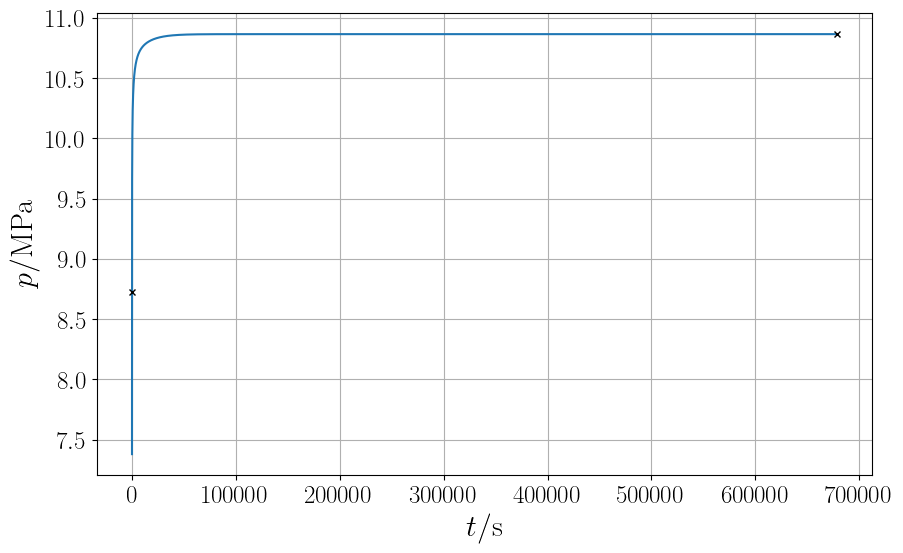

In [5]:
#pressure vs time

x_star = np.linspace(0, L_star, Nx)

plt.figure(figsize=(10, 6))
for i in range(len(Delta_t_list)):
    time_record = np.arange(0, int(tau_diff_list[i]), Delta_t_list[i])  # 2025.10.25. ezt átírtam sima ...,tau_diff_list[i],... -ről mert kerekítési hiba miatt nem futott le
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    time_record = np.linspace(0,tau_diff_list[i],num_steps_list[i]+1)
    plt.plot(time_record, p_all_cases[i]*1e-6, label=f'Case {i+1}')

    #plt.plot(time_record, p_all_cases[i] / 1e6, label=f'Case {i+1}')
    #plt.figure(figsize=(10, 6))
    plt.plot( 10*Delta_t_list[i],p_all_cases[i][10]/1e6 , marker='x',markersize=5, color='black')
    plt.plot( num_steps_list[i]*Delta_t_list[i],p_all_cases[i][num_steps_list[i]]/1e6 , marker='x',markersize=5, color='black')
zoom_time = 0.0001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
#plt.axvline(x=time_record[int(t_heating/(Delta_t_star_list[0]*tau_diff_list[0]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ t / \rm{s} $')
plt.ylabel(r'$ p / \rm{MPa} $')
#plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.show()

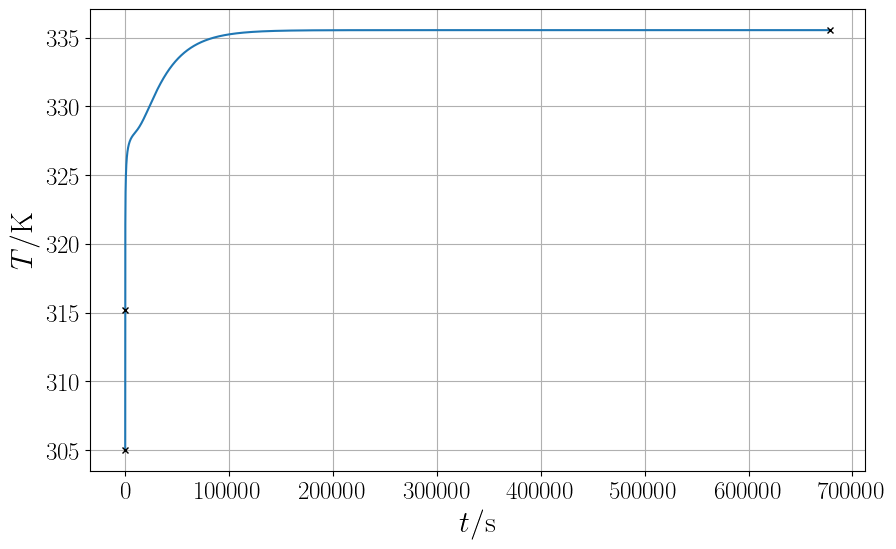

In [6]:
#temperature vs time

x_star = np.linspace(0, L_star, Nx)

plt.figure(figsize=(10, 6))
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(time_record, T_all_cases[i][ : , int(19)  ], label=f'Case {i+1}') #int(Nx/2) int(Nx/3)
    #plt.figure(figsize=(10, 6))
    plt.plot( 0*Delta_t_list[i],T_all_cases[i][ 0 , int(Nx-1)  ], marker='x',markersize=5, color='black')
    plt.plot( 11*Delta_t_list[i],T_all_cases[i][ 10 , int(Nx-1)  ] , marker='x',markersize=5, color='black')
    plt.plot( num_steps_list[i]*Delta_t_list[i],T_all_cases[i][ num_steps_list[i] , int(Nx-1)  ] , marker='x',markersize=5, color='black')
zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
#plt.axvline(x=time_record[int(t_heating/(Delta_t_star_list[0]*tau_diff_list[0]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ t / \rm{s} $')
plt.ylabel(r'$ T / \rm{K} $')
#plt.legend(loc='lower left')
#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.show()

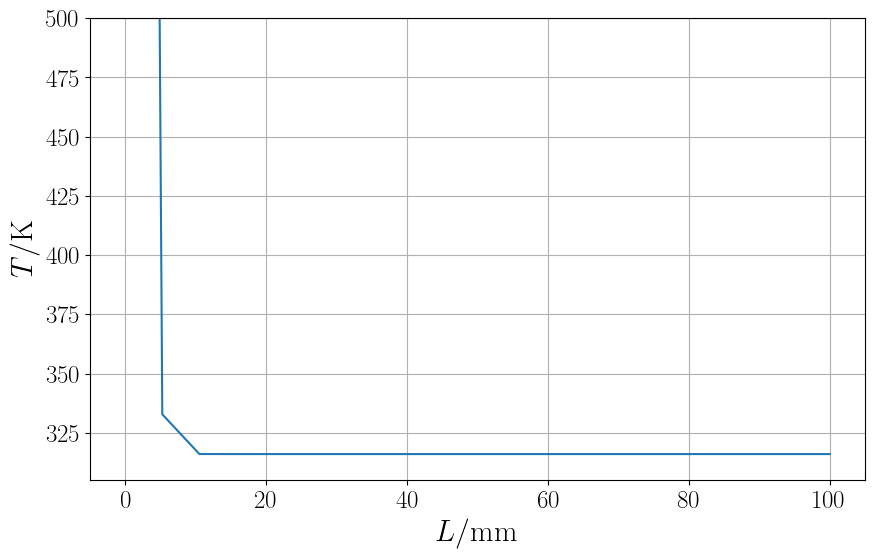

In [7]:
# temperature vs space

x_star = np.linspace(0, L_star, Nx)
plt.figure(figsize=(10, 6))

for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star, T_all_cases[i][ 12 ,:  ],label=f'Case {i+1}')
#plt.plot(x_star, T_star[4, :], label='j = 4')
#plt.plot(x_star, T_star[9, :], label='j = 9')
#plt.plot(x_star, T_star[int(num_steps*0.01), :], label=f'j = {int(num_steps*0.01)}')
#plt.plot(x_star, T_star[int(num_steps*0.1), :], label=f'j = {int(num_steps*0.1)}')
#plt.plot(x_star, T_star[int(num_steps*0.5), :], label=f'j = {int(num_steps*0.5)}')
#plt.plot(x_star, T_star[int(num_steps*0.9), :], label=f'j = {int(num_steps*0.9)}')

plt.ylim(bottom=305, top=500)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ T / \rm{K} $')
#plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.show()

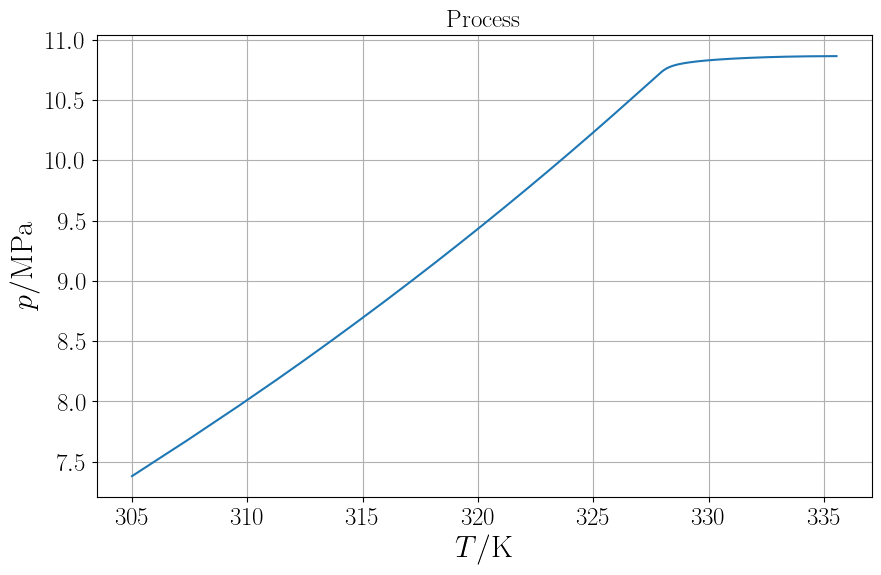

In [8]:
#process

plt.figure(figsize=(10, 6))
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot( T_all_cases[i][ : , int(19)  ], p_all_cases[i]/1e6,label=f'Case {i+1}') #int(Nx/2) int(Nx/3)
    #plt.figure(figsize=(10, 6))
    #plt.plot( 0*Delta_t_list[i],T_all_cases[i][ 0 , int(Nx-1)  ], marker='x',markersize=5, color='black')
    #plt.plot( 11*Delta_t_list[i],T_all_cases[i][ 10 , int(Nx-1)  ] , marker='x',markersize=5, color='black')
    #plt.plot( num_steps_list[i]*Delta_t_list[i],T_all_cases[i][ num_steps_list[i] , int(Nx-1)  ] , marker='x',markersize=5, color='black')
#zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
#plt.axvline(x=time_record[int(t_heating/(Delta_t_star_list[0]*tau_diff_list[0]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ T / \rm{K} $')
plt.ylabel(r'$ p / \rm{MPa} $')
plt.title('Process')
#plt.legend(loc='lower left')
#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.show()

Itt kiszámolom az nwat_pistonos képpletek ereményeit a nemlineaáris esetre

In [9]:
T0ic = IC_all_cases[0]#[ 305.0 , 310.0 , 315.0 , 320.0 , 325.0 ]           # Initial temperature (K)  
p0 = IC_all_cases[1]  

if today_str == "2025-09-28": IC_all_cases.append(38.5)
Q_total = IC_all_cases[2] #EZT KIKOMMENTELNI 2025.09.28. után futtatott szimulációknál

rho0 = np.zeros((2,len(T0ic)))

#DENSITY
#IZOBÁR ESET, azaz hőmérséklet változik
rho_guess  = Rhoc  # starting point
for i in range(len(T0ic)):

    try:
            rho0[1][i] = newton(
            density_from_pressure,
            rho_guess,
            args=(T0ic[i], p0[0]),
            tol=1e-9,
            maxiter=50000
        )
    except RuntimeError:
        # Fallback: if Newton fails, try a small perturbation
        rho0[1][i] = newton(
            density_from_pressure,
            rho_guess * 1.05,
            args=(T0ic[i], p0[0]),
            tol=1e-9,
            maxiter=50000
        )
    rho_guess = rho0[1][i]

#IZOTERM ESET, a nyomás változik
for i in range(len(T0ic)):

    try:
            rho0[0][i] = newton(
            density_from_pressure,
            rho_guess,
            args=(T0ic[0], p0[i]),
            tol=1e-9,
            maxiter=50000
        )
    except RuntimeError:
        # Fallback: if Newton fails, try a small perturbation
        rho0[0][i] = newton(
            density_from_pressure,
            rho_guess * 1.05,
            args=(T0ic[0], p0[i]),
            tol=1e-9,
            maxiter=50000
        )
    rho_guess = rho0[0][i]

print(rho0)

#IZOBÁR ESET, hőméerséklet változik
lambda0 = np.zeros((2, len(T0ic)))
for i in range(len(T0ic)):
    lambda0[1,i] = thermal_conductivity(T0ic[i],rho0[1][i])

#IZOTERM ESET, nyomás változik
for i in range(len(T0ic)):
    lambda0[0,i] = thermal_conductivity(T0ic[0],rho0[0][i])

print(lambda0)

#IZOBÁR ESET, azaz hőmérséklet változik
cp0 = np.zeros((2, len(T0ic)))
for i in range(len(T0ic)):
    cp0[1,i] = get_cp(T0ic[i],rho0[1][i])

#IZOTERM ESET, azaz nyomás változik
for i in range(len(T0ic)):
    cp0[0,i] = get_cp(T0ic[0],rho0[0][i])

print(cp0)

#IZOBÁR ESET, azaz hőmérséklet változik
cv0 = np.zeros((2, len(T0ic)))
for i in range(len(T0ic)):
    cv0[1,i] = get_cv(T0ic[i],rho0[1][i])

#IZOTERM ESET, azaz nyomás változik
for i in range(len(T0ic)):
    cv0[0,i] = get_cv(T0ic[0],rho0[0][i])

print(cv0)

#IZOBÁR ESET, azaz hőmérséklet változik
as0 = np.zeros((2, len(T0ic)))
for i in range(len(T0ic)):
    as0[1,i] = speed_of_sound(T0ic[i],rho0[1][i])

#IZOTERM ESET, azaz nyomás változik
for i in range(0,len(T0ic)):
    as0[0,i] = speed_of_sound(T0ic[0],rho0[0][i])

print(as0)

#IZOBÁR ESET, azaz hőmérséklet változik
mu_JT0 = np.zeros((2, len(T0ic)))
for i in range(len(T0ic)):
    mu_JT0[1,i] = joule_thompson(T0ic[i],rho0[1][i])

#IZOTERM ESET, azaz nyomás változik
for i in range(len(T0ic)):
    mu_JT0[0,i] = joule_thompson(T0ic[0],rho0[0][i])

print(mu_JT0)


[[312.77614609]
 [312.77614609]]
[[0.0586878]
 [0.0586878]]
[[12725.57042842]
 [12725.57042842]]
[[1243.30717746]
 [1243.30717746]]
[[186.7123742]
 [186.7123742]]
[[7.80493856e-06]
 [7.80493856e-06]]


C:\Users\krist\AppData\Local\Temp\ipykernel_13360\1417689070.py:171: RuntimeWarning: invalid value encountered in log
  Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum


In [10]:
Tinf_T0_calc = np.zeros(len(T0ic))

pinf_p0_calc = np.zeros(len(T0ic))

pinf_p0_calc_check = np.zeros(len(T0ic))

T0_T0_calc = np.zeros(len(T0ic))

T0_T0_calc_check = np.zeros(len(T0ic))


# a pdf -ben Rin szerepel ami a gömbre vonatkozik viszont először kipröbálom Rh henger sugárral mert a szimuláció is ezzel futott le
#azt tapasztaltam, hogy a számolt értékek 20szor nagyobbak voltak a szimuláciból kapottaknál

#ugyhogy lefuttatom az eredeti gömb belső sugarával

for i in range(len(T0ic)):
    Tinf_T0_calc[i] = 1 / (rho0[1][i] * 4 *np.pi / 3 * R_belso**3 * cv0[1][i]) * Q_total


for i in range(len(T0ic)):
    pinf_p0_calc[i] = betap_all_cases[i][0][0] / khit_all_cases[i][0][0] * Tinf_T0_calc[i]


#ez a check nem biztos hogy jó mert hangsebesség van benne
for i in range(len(T0ic)):
    pinf_p0_calc_check[i] = betap_all_cases[i][0][0]* as0[1][i]**2 / cp0[1][i] * 1 / (4 * np.pi /3 * R_belso**3) * Q_total


for i in range(len(T0ic)):
    T0_T0_calc[i] = T0ic[i]* 1/rho0[1][i] * betap_all_cases[i][0][0] / cp0[1][i] * pinf_p0_calc[i]



for i in range(len(T0ic)):
    T0_T0_calc_check[i] = T0ic[i]* 1/rho0[1][i] * ( betap_all_cases[i][0][0]* as0[1][i] / cp0[1][i])**2 * 1 / (4 * np.pi /3 * R_belso**3) * Q_total


In [11]:
Tinf_T0_sim = np.zeros(len(T0ic))

pinf_p0_sim = np.zeros(len(T0ic))

T0_T0_sim = np.zeros(len(T0ic))


for i in range(len(T0ic)):
    Tinf_T0_sim[i] = ( T_all_cases[i][ num_steps_list[i] , int(Nx-1)  ] - T_all_cases[i][ 0 , int(Nx-1)  ] )
    #print(T_all_cases[i][0, int(Nx-1)])
    #print(num_steps_list[i])

for i in range(len(T0ic)):
    pinf_p0_sim[i] = ( p_all_cases[i][num_steps_list[i]] -  p_all_cases[i][0] )


for i in range(len(T0ic)):
    T0_T0_sim[i] = ( T_all_cases[i][ 10 , int(Nx-1)  ] - T_all_cases[i][ 0 , int(Nx-1)  ] )
#theát ez a szimulációs eredmény Kelvin ben

print("Tinf_T0 szimulált: " + str(Tinf_T0_sim) + " K")
print("Tinf_T0 számított: " + str(Tinf_T0_calc) + " K")

print("pinf_p0 szimulált: " + str(pinf_p0_sim) + " Pa")
print("pinf_T0 számított: " + str(pinf_p0_calc) + " Pa")
print("pinf_T0 számított hangsebességgel: " + str(pinf_p0_calc_check) + " Pa")
print("T0_T0 szimulált: " + str(T0_T0_sim) + " K")
print("T0_T0 számított: " + str(T0_T0_calc) + " K")
print("T0_T0 számított hangsebességgel: " + str(T0_T0_calc_check) + " K")



Tinf_T0 szimulált: [30.54974469] K
Tinf_T0 számított: [26.71445731] K
pinf_p0 szimulált: [3484634.36106427] Pa
pinf_T0 számított: [2992040.74104293] Pa
pinf_T0 számított hangsebességgel: [2992040.74104293] Pa
T0_T0 szimulált: [10.22507318] K
T0_T0 számított: [24.10441506] K
T0_T0 számított hangsebességgel: [24.10441506] K


In [12]:


rho_all_cases = [np.array(case) for case in rho_all_cases]

print(rho_all_cases[0][:, int(Nx-1)])


[312.77614609 320.90014361 328.3311356  ... 329.19933265 329.19933265
 329.19933265]


<Figure size 1000x600 with 0 Axes>

<Figure size 590.551x590.551 with 0 Axes>

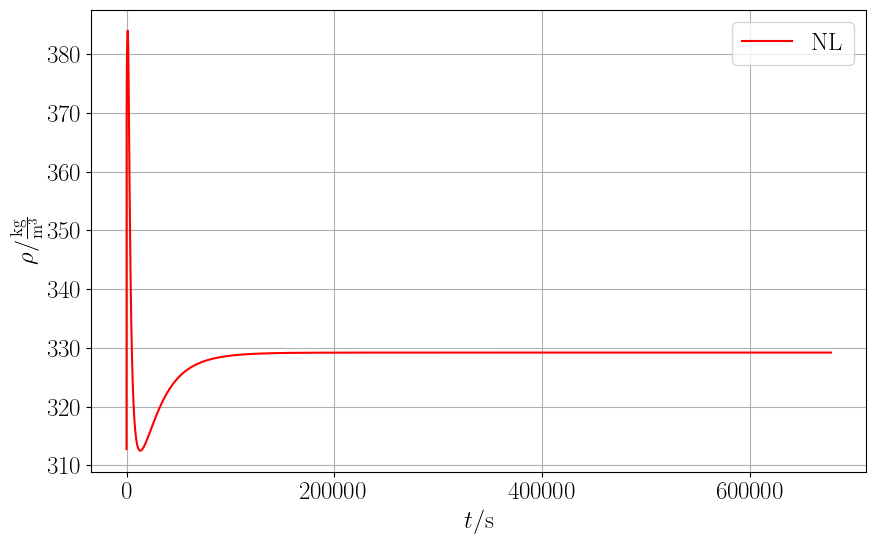

In [13]:
#Density vs time

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
plt.rcParams.update({
    "font.size": 18,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})

x_star = np.linspace(0, L_star, Nx)

plt.figure(figsize=(10, 6))
for i in range(len(Delta_t_list)):
    
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(time_record, rho_all_cases[i][ : , int(8)  ], color='r', label=f'NL') #int(Nx/2) int(Nx/3)
zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
#plt.axvline(x=time_record[int(t_heating/(Delta_t_list[i]*tau_diff_list[i]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ t / \rm{s} $')
plt.ylabel(r'$ \rho / \rm{\frac{kg}{m^3}} $')
#plt.title('Density evolution over time')
plt.legend()
#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.locator_params(axis='x', nbins=4)  # try 4–6 for clean article figures
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/rho_t_vege.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/rho_t_eleje.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

In [14]:
cp_all_cases = [np.array(case) for case in cp_all_cases]

print(cp_all_cases[0][:, int(Nx-1)])


[12725.57042842 10611.70023429  9304.63386239 ...  3343.09015695
  3343.09015695  3343.09015695]


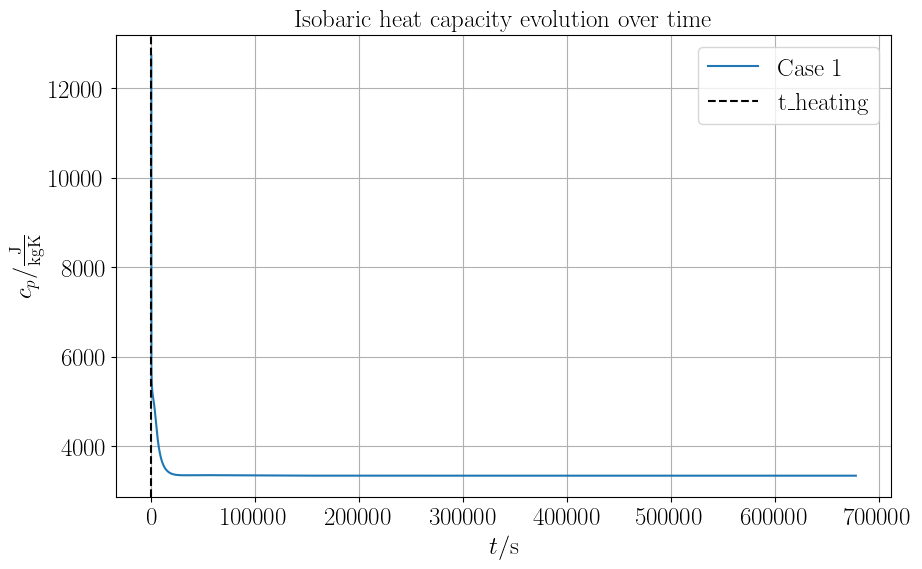

In [15]:

x_star = np.linspace(0, L_star, Nx)

plt.figure(figsize=(10, 6))
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(time_record, cp_all_cases[i][ : , int(10)  ], label=f'Case {i+1}') #int(Nx/2) int(Nx/3)
zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
plt.axvline(x=time_record[int(t_heating/(Delta_t_list[i]*tau_diff_list[i]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ t / \rm{s} $')
plt.ylabel(r'$ c_p / \rm{\frac{J}{kgK}} $')
plt.title('Isobaric heat capacity evolution over time')
plt.legend()
#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.show()

In [16]:
cv_all_cases = [np.array(case) for case in cv_all_cases]

print(cv_all_cases[0][:, int(Nx-1)])


[1243.30717746 1194.9811238  1158.86159781 ...  953.15496587  953.15496587
  953.15496587]


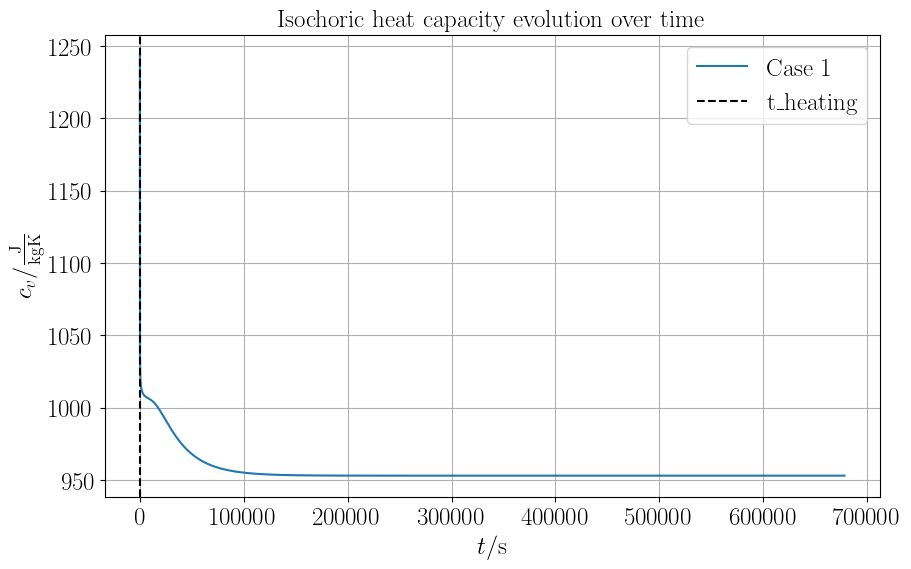

In [17]:
x_star = np.linspace(0, L_star, Nx)

plt.figure(figsize=(10, 6))
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(time_record, cv_all_cases[i][ : , int(19)  ], label=f'Case {i+1}') #int(Nx/2) int(Nx/3)
zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
plt.axvline(x=time_record[int(t_heating/(Delta_t_list[i]*tau_diff_list[i]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ t / \rm{s} $')
plt.ylabel(r'$ c_v / \rm{\frac{J}{kgK}} $')
plt.title('Isochoric heat capacity evolution over time')
plt.legend()
#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.show()

In [18]:
lambda_all_cases = [np.array(case) for case in lambda_all_cases]

print(lambda_all_cases[0][:, int(Nx-1)])


[0.0586878  0.05704834 0.05583742 ... 0.04348405 0.04348405 0.04348405]


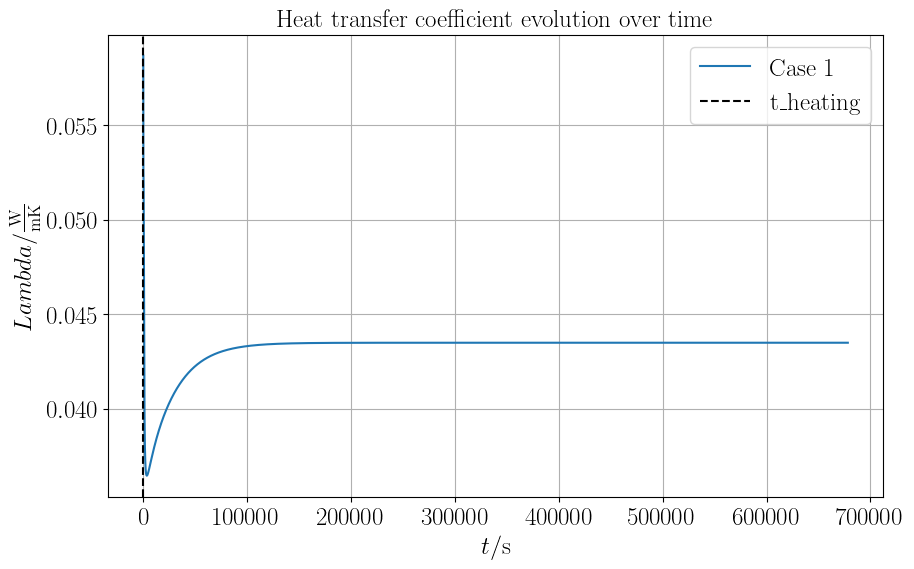

In [19]:
#lambda t

x_star = np.linspace(0, L_star, Nx)

plt.figure(figsize=(10, 6))
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(time_record, lambda_all_cases[i][ : , int(5)  ], label=f'Case {i+1}') #int(Nx/2) int(Nx/3)
zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
plt.axvline(x=time_record[int(t_heating/(Delta_t_list[i]*tau_diff_list[i]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ t / \rm{s} $')
plt.ylabel(r'$ Lambda / \rm{\frac{W}{mK}} $')
plt.title('Heat transfer coefficient evolution over time')
plt.legend()
#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.show()

In [20]:
muJT_all_cases = [np.array(case) for case in muJT_all_cases]

print(muJT_all_cases[0][:, int(Nx-1)])


[7.80493856e-06 7.51889860e-06 7.25986123e-06 ... 5.63084692e-06
 5.63084692e-06 5.63084692e-06]


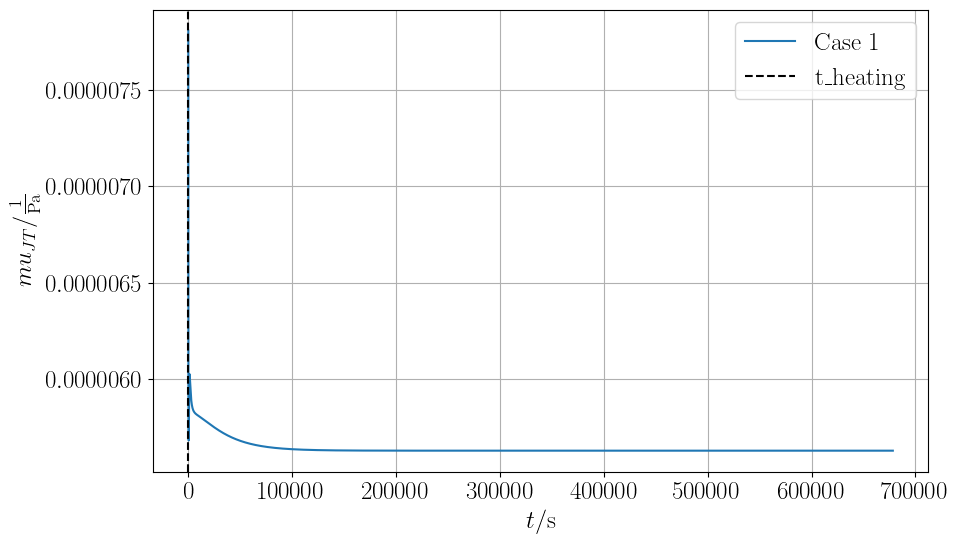

In [21]:
#JT-t
x_star = np.linspace(0, L_star, Nx)

plt.figure(figsize=(10, 6))
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(time_record, muJT_all_cases[i][ : , int(5)  ], label=f'Case {i+1}') #int(Nx/2) int(Nx/3)
zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
plt.axvline(x=time_record[int(t_heating/(Delta_t_list[i]*tau_diff_list[i]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ t / \rm{s} $')
plt.ylabel(r'$ mu_{JT} / \rm{\frac{1}{Pa}} $')
#plt.title('Joule Thompson coefficient evolution over time')
plt.legend()
#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.show()

In [22]:
betap_all_cases = [np.array(case) for case in betap_all_cases]

print(betap_all_cases[0][:, int(Nx-1)])


[0.10513326 0.08654253 0.07486481 ... 0.02144835 0.02144835 0.02144835]


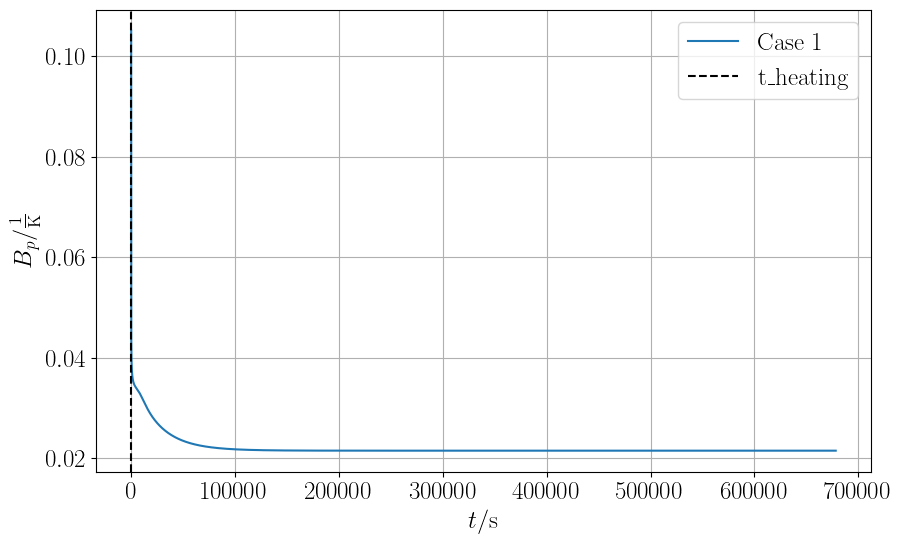

In [23]:
#Bp-t
x_star = np.linspace(0, L_star, Nx)

plt.figure(figsize=(10, 6))
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(time_record, betap_all_cases[i][ : , int(15)  ], label=f'Case {i+1}') #int(Nx/2) int(Nx/3)
zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
plt.axvline(x=time_record[int(t_heating/(Delta_t_list[i]*tau_diff_list[i]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ t / \rm{s} $')
plt.ylabel(r'$ B_p / \rm{\frac{1}{K}} $')
#plt.title('Isobaric thermal expansion coefficient evolution over time')
plt.legend()
#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.show()

In [24]:
khit_all_cases = [np.array(case) for case in khit_all_cases]

print(khit_all_cases[0][:, int(Nx-1)])


[9.38683083e-07 7.61917988e-07 6.48822540e-07 ... 1.96200337e-07
 1.96200337e-07 1.96200337e-07]


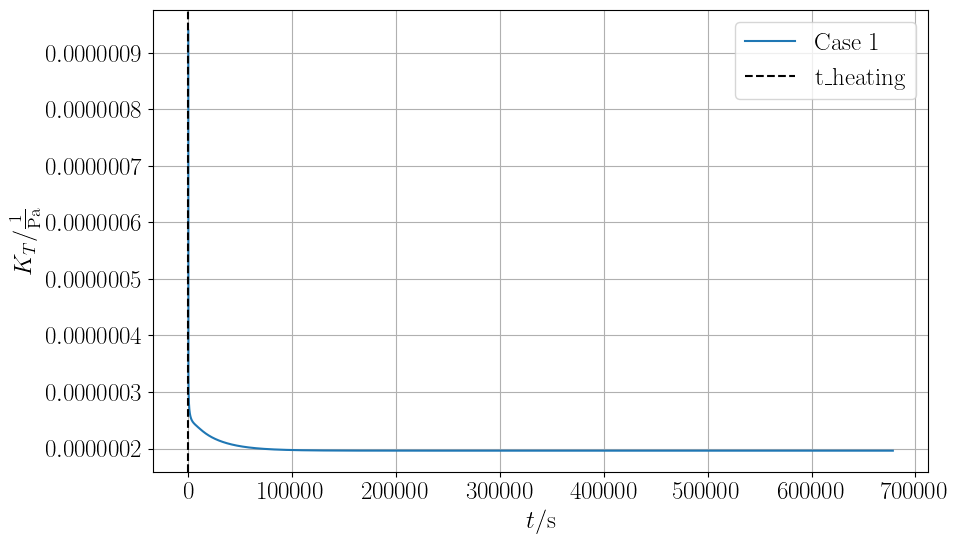

In [25]:
#khiT-t
x_star = np.linspace(0, L_star, Nx)

plt.figure(figsize=(10, 6))
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(time_record, khit_all_cases[i][ : , int(15)  ], label=f'Case {i+1}') #int(Nx/2) int(Nx/3)
zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
plt.axvline(x=time_record[int(t_heating/(Delta_t_list[i]*tau_diff_list[i]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ t / \rm{s} $')
plt.ylabel(r'$ K_T / \rm{\frac{1}{Pa}} $')
#plt.title('Isothermal compressibility evolution over time')
plt.legend()
#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.show()

## Nemlineáris Szimulációban levő időskálák összegyűjtése

In [26]:
for i in range(len(tau_diff_list)):
    print('Diffúziós időskála:'+str(tau_diff_list[i])+' s')
    print('Pulzus időskála: '+str(t_heating_list[i])+' s')
    print('Akusztikus időskála: '+str(tau_acustic_list[i])+ ' s')

Diffúziós időskála:678208.1839310066 s
Pulzus időskála: 10 s
Akusztikus időskála: 0.0005355831418642394 s


# Chapter 2 –Linear Data Import

Itt betöltöm a lineáris szimuláció eredményeit

In [67]:

# folder where your results are saved
#today_str = date.today().isoformat()

folder = "linear_results_" + today_str_lin

# dictionary to store loaded lists
loaded_lists = {}

# loop through all .json files in the folder
for filename in tqdm(os.listdir(folder)):
    if filename.endswith(".json"):
        var_name = filename.replace(".json", "")
        file_path = os.path.join(folder, filename)
        with open(file_path, "r") as f:
            loaded_lists[var_name] = json.load(f)
        print(f"Loaded {var_name} from {filename}")

# Example: access your lists
T_all_cases_lin = loaded_lists["T_all_cases_lin"]
p_all_cases_lin = loaded_lists["p_all_cases_lin"]
Delta_t_star_list_lin = loaded_lists["Delta_t_star_list_lin"]
num_steps_lis_lin = loaded_lists["num_steps_list_lin"]
tau_diff_list_lin = loaded_lists["tau_diff_list_lin"]
t_heating_star_list_lin = loaded_lists["t_heating_star_list_lin"]
beta_p0_list_lin = loaded_lists["beta_p0_list_lin"]
chi_T0_list_lin = loaded_lists["chi_T0_list_lin"]

print(type(T_all_cases_lin))  # should be <class 'list'>
print(len(T_all_cases_lin))   # number of cases

L_star = 100
Nx = 20

p_all_cases_lin = [np.array(case) for case in p_all_cases_lin]

#print(p_all_cases_lin[0])

T_all_cases_lin = [np.array(case) for case in T_all_cases_lin]

#print(T_all_cases_lin[0][:, int(Nx-1)])


if len(T_all_cases_lin[0][0,:])==100:
    Nx_lin=100
else:
    Nx_lin=Nx

print(Nx_lin)


  0%|          | 0/8 [00:00<?, ?it/s]

Loaded beta_p0_list_lin from beta_p0_list_lin.json
Loaded chi_T0_list_lin from chi_T0_list_lin.json
Loaded Delta_t_star_list_lin from Delta_t_star_list_lin.json
Loaded num_steps_list_lin from num_steps_list_lin.json


 62%|██████▎   | 5/8 [00:00<00:00,  5.45it/s]

Loaded p_all_cases_lin from p_all_cases_lin.json
Loaded tau_diff_list_lin from tau_diff_list_lin.json


100%|██████████| 8/8 [00:48<00:00,  6.06s/it]

Loaded T_all_cases_lin from T_all_cases_lin.json
Loaded t_heating_star_list_lin from t_heating_star_list_lin.json
<class 'list'>
1


100


## lin plots

<>:31: SyntaxWarning: invalid escape sequence '\ '
<>:31: SyntaxWarning: invalid escape sequence '\ '
C:\Users\krist\AppData\Local\Temp\ipykernel_13208\2308437901.py:31: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(time_record_dim, p_all_cases_lin[i]/1e6 -p_all_cases_lin[i][0]/1e6 , color= rainbow[i],label=f'$T_0={T_all_cases_lin[i][0, int(Nx_lin-1)]}\ \mathrm{{K}}$') #ITT HA P=áll eset van 0 index ha T=áll akkor i #itt kiszedtem - p0[i], mert abszolut nyomást szerettem volna később öszehasonlítani 2025.09.29.


<Figure size 1000x600 with 0 Axes>

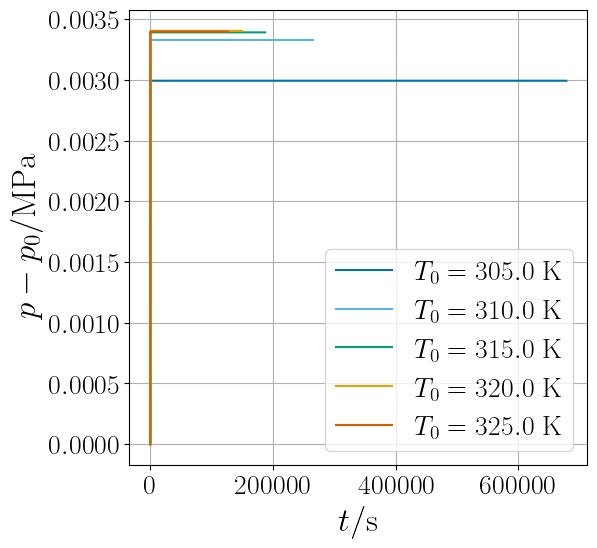

In [ ]:
#lin pressure vs time
#ennek van értelme azonos nyomás más hőm. esetekre

cbforange = (230/255, 159/255, 0/255)
cbfmagenta = (204/255, 121/255, 167/255)
cbfyellow = (240/255, 228/255, 66/255)
cbflightblue = (86/255, 180/255, 233/255)
cbfgreen = (0/255, 158/255, 115/255)
cbfblue = (0/255, 114/255, 178/255) 
cbfred = (213/255, 94/255, 0/255)
cbfred_dark = (160/255, 45/255, 55/255)#(178/255, 76/255, 0/255)

rainbow = [cbfblue,cbflightblue,cbfgreen,cbforange,cbfred,cbfred_dark] #,cbfyellow


plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(T_all_cases_lin)):
#for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk

    #time_record_dim = np.arange(0, tau_diff_list_lin[i], Delta_t_star_list_lin[i]*tau_diff_list_lin[i])
    time_record_dim = np.linspace(0, tau_diff_list_lin[i],num_steps_lis_lin[i]+1)
    plt.plot(time_record_dim, p_all_cases_lin[i]/1e6 -p_all_cases_lin[i][0]/1e6 , color= rainbow[i],label=f'$T_0={T_all_cases_lin[i][0, int(Nx_lin-1)]}\ \mathrm{{K}}$') #ITT HA P=áll eset van 0 index ha T=áll akkor i #itt kiszedtem - p0[i], mert abszolut nyomást szerettem volna később öszehasonlítani 2025.09.29.
    #plt.plot( 10*Delta_t_star_list_lin[i]*tau_diff_list_lin[i],p_all_cases_lin[i][10]*Pc/1e6 , marker='x',markersize=5, color='black')
    #plt.plot( num_steps_lis_lin[i]*Delta_t_star_list_lin[i]*tau_diff_list_lin[i],p_all_cases_lin[i][num_steps_lis_lin[i]]*Pc/1e6 , marker='x',markersize=5, color='black')
#plt.figure(figsize=(10, 6))
#zoom_time = 0.0001 * time_record_dim[-1]  # Calculate 20% of the total time
#plt.xlim(0, 15)
#plt.axvline(x=time_record_dim[int(t_heating/(Delta_t_star*tau_diff))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$t/\rm{s}$')
plt.ylabel(r'$p-p_0/\rm{MPa}$')
#plt.title('Pressure difference evolution over time')
plt.legend() #Itt ez kelleni fog amikor több esetet futtatunk ebből a kezdeti feltételek hatásának feltérképezésére (hf)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
#plt.savefig("D:/School/7. Félév/JCAM cikk/figs/p_t_p_allando_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/p_t_p_allando.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/p_738_T305_lin_p.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/p_738_T305_lin_p_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\ '
<>:31: SyntaxWarning: invalid escape sequence '\ '
C:\Users\krist\AppData\Local\Temp\ipykernel_11936\4241545458.py:31: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(time_record_dim, p_all_cases_lin[i]/1e6 -p_all_cases_lin[i][0]/1e6 , color= rainbow[i],label=f'$p_0={p_all_cases_lin[i][0]/1e6}\ \mathrm{{MPa}}$') #ITT HA P=áll eset van 0 index ha T=áll akkor i #itt kiszedtem - p0[i], mert abszolut nyomást szerettem volna később öszehasonlítani 2025.09.29.


<Figure size 1000x600 with 0 Axes>

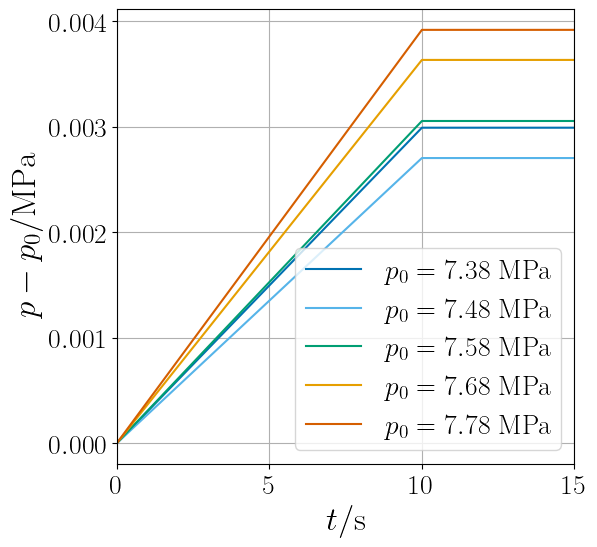

In [35]:
#lin pressure vs time
#ennek van értelme azonos nyomás más hőm. esetekre

cbforange = (230/255, 159/255, 0/255)
cbfmagenta = (204/255, 121/255, 167/255)
cbfyellow = (240/255, 228/255, 66/255)
cbflightblue = (86/255, 180/255, 233/255)
cbfgreen = (0/255, 158/255, 115/255)
cbfblue = (0/255, 114/255, 178/255) 
cbfred = (213/255, 94/255, 0/255)
cbfred_dark = (160/255, 45/255, 55/255)#(178/255, 76/255, 0/255)

rainbow = [cbfblue,cbflightblue,cbfgreen,cbforange,cbfred,cbfred_dark] #,cbfyellow


plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(T_all_cases_lin)):
#for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk

    #time_record_dim = np.arange(0, tau_diff_list_lin[i], Delta_t_star_list_lin[i]*tau_diff_list_lin[i])
    time_record_dim = np.linspace(0, tau_diff_list_lin[i],num_steps_lis_lin[i]+1)
    plt.plot(time_record_dim, p_all_cases_lin[i]/1e6 -p_all_cases_lin[i][0]/1e6 , color= rainbow[i],label=f'$p_0={p_all_cases_lin[i][0]/1e6}\ \mathrm{{MPa}}$') #ITT HA P=áll eset van 0 index ha T=áll akkor i #itt kiszedtem - p0[i], mert abszolut nyomást szerettem volna később öszehasonlítani 2025.09.29.
    #plt.plot( 10*Delta_t_star_list_lin[i]*tau_diff_list_lin[i],p_all_cases_lin[i][10]*Pc/1e6 , marker='x',markersize=5, color='black')
    #plt.plot( num_steps_lis_lin[i]*Delta_t_star_list_lin[i]*tau_diff_list_lin[i],p_all_cases_lin[i][num_steps_lis_lin[i]]*Pc/1e6 , marker='x',markersize=5, color='black')
#plt.figure(figsize=(10, 6))
#zoom_time = 0.0001 * time_record_dim[-1]  # Calculate 20% of the total time
plt.xlim(0, 15)
#plt.axvline(x=time_record_dim[int(t_heating/(Delta_t_star*tau_diff))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$t/\rm{s}$')
plt.ylabel(r'$p-p_0/\rm{MPa}$')
#plt.title('Pressure difference evolution over time')
plt.legend(loc='lower right') #Itt ez kelleni fog amikor több esetet futtatunk ebből a kezdeti feltételek hatásának feltérképezésére (hf)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/p_t_T_allando_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/p_t_p_allando.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/p_738_T305_lin_p.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/p_738_T305_lin_p_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\ '
<>:11: SyntaxWarning: invalid escape sequence '\ '
C:\Users\krist\AppData\Local\Temp\ipykernel_11936\2453872878.py:11: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(time_record_dim, T_all_cases_lin[i][:,int(Nx_lin-1)]-T_all_cases_lin[i][0,int(Nx_lin-1)], color= rainbow[i], label=f'$p_0={p_all_cases_lin[i][0]/1e6:.2f}\ \mathrm{{MPa}}$')


<Figure size 1000x600 with 0 Axes>

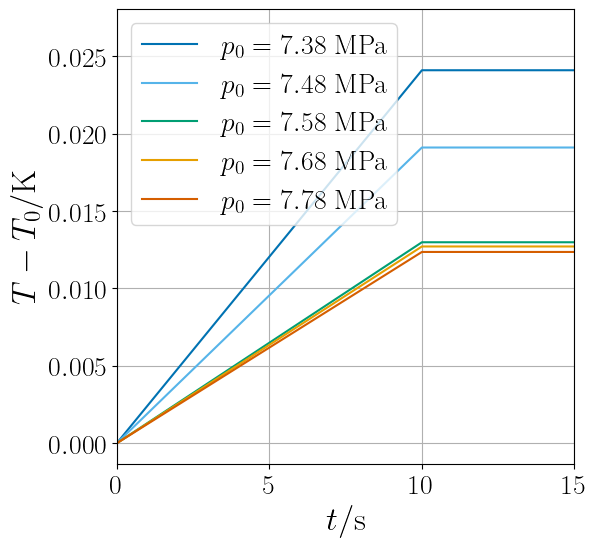

In [41]:
#lin temperature vs time
#ennek van értelme azonos hőm. más nyomás esetekre

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))

for i in range(len(T_all_cases_lin)):
#for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
    #time_record_dim = np.arange(0, tau_diff_list_lin[i], Delta_t_star_list_lin[i]*tau_diff_list[i])
    time_record_dim = np.linspace(0, tau_diff_list_lin[i],num_steps_lis_lin[i]+1)
    plt.plot(time_record_dim, T_all_cases_lin[i][:,int(Nx_lin-1)]-T_all_cases_lin[i][0,int(Nx_lin-1)], color= rainbow[i], label=f'$p_0={p_all_cases_lin[i][0]/1e6:.2f}\ \mathrm{{MPa}}$')
plt.xlim(0, 15)
#plt.axvline(x=time_record_dim[int(t_heating/(Delta_t_star_list_lin[i]*tau_diff_list_lin[i]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$t/\rm{s}$')
plt.locator_params(axis='x', nbins=4)  # try 4–6 for clean article figures
plt.ylabel(r'$T-T_0/\rm{K}$')
#plt.title('Temperature evolution over time')
#plt.ylim(bottom=0, top=0.1)
plt.legend(loc='upper left') #Itt ez kelleni fog amikor több esetet futtatunk ebből a kezdeti feltételek hatásának feltérképezésére (hf)
#plt.legend(loc='lower right')
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/T_t_T_allando_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/JCAM cikk/figs/T_t_T_allando.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/p_738_T305_lin_T.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/p_738_T305_lin_T_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\ '
<>:18: SyntaxWarning: invalid escape sequence '\ '
C:\Users\krist\AppData\Local\Temp\ipykernel_11936\1343076178.py:18: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(time_record_dim, T_all_cases_lin[i][:,int(Nx_lin-1)]-T_all_cases_lin[i][0,int(Nx_lin-1)] , color= rainbow[i], label=f'$T_0={T_all_cases_lin[i][0, int(Nx_lin-1)]}\ \mathrm{{K}}$') #ITT HA P=áll eset van i index ha T=áll akkor 0


<Figure size 1000x600 with 0 Axes>

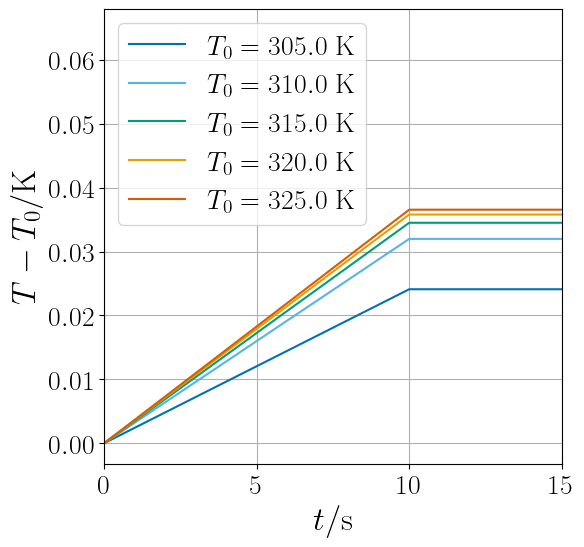

In [30]:
#lin temperature-T0 vs time
#ennek van értelme azonos nyomás más hőm esetekre

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(T_all_cases_lin)):
#for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
    #time_record_dim = np.arange(0, tau_diff_list_lin[i], Delta_t_star_list_lin[i]*tau_diff_list[i])
    time_record_dim = np.linspace(0, tau_diff_list_lin[i],num_steps_lis_lin[i]+1)
    plt.plot(time_record_dim, T_all_cases_lin[i][:,int(Nx_lin-1)]-T_all_cases_lin[i][0,int(Nx_lin-1)] , color= rainbow[i], label=f'$T_0={T_all_cases_lin[i][0, int(Nx_lin-1)]}\ \mathrm{{K}}$') #ITT HA P=áll eset van i index ha T=áll akkor 0
    #plt.plot( 10*Delta_t_star_list_lin[i]*tau_diff_list_lin[i],T_all_cases_lin[i][ 10 , int(Nx_lin-1)  ]*Tc , marker='x',markersize=5, color='black')
    #plt.plot( num_steps_lis_lin[i]*Delta_t_star_list_lin[i]*tau_diff_list_lin[i],T_all_cases_lin[i][ num_steps_lis_lin[i] , int(Nx_lin-1)  ]* Tc, marker='x',markersize=5, color='black')
#zoom_time = 0.0001 * time_record_dim[-1]  # Calculate 20% of the total time
plt.xlim(0, 15)
#plt.axvline(x=time_record_dim[int(t_heating/(Delta_t_star_list_lin[i]*tau_diff_list_lin[i]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$t/\rm{s}$')
plt.ylabel(r'$T-T_0/\rm{K}$')
#plt.title('Temperature evolution over time')
#plt.ylim(bottom=0, top=0.1)
#plt.legend(loc='upper left') #Itt ez kelleni fog amikor több esetet futtatunk ebből a kezdeti feltételek hatásának feltérképezésére (hf)
plt.legend() 
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
#plt.savefig("D:/School/7. Félév/JCAM cikk/figs/TT0_t_p_allando_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/JCAM cikk/figs/TT0_t_p_allando.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/p_738_T305_lin_T.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/p_738_T305_lin_T_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:26: SyntaxWarning: invalid escape sequence '\ '
<>:42: SyntaxWarning: invalid escape sequence '\ '
<>:43: SyntaxWarning: invalid escape sequence '\ '
<>:44: SyntaxWarning: invalid escape sequence '\ '
<>:45: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:26: SyntaxWarning: invalid escape sequence '\ '
<>:42: SyntaxWarning: invalid escape sequence '\ '
<>:43: SyntaxWarning: invalid escape sequence '\ '
<>:44: SyntaxWarning: invalid escape sequence '\ '
<>:45: SyntaxWarning: invalid escape sequence '\ '
C:\Users\krist\AppData\Local\Temp\ipykernel_11936\195040731.py:9: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(x_star_lin, T_all_cases_lin[i][ 5,:  ], color= rainbow[i],label=f'$T_0={T_all_cases_lin[i][0, int(Nx_lin-1)]*Tc}\ \mathrm{{K}}$')
C:\Users\krist\AppData\Local\Temp\ipykernel_11936\195040731.py:26: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(x_star_lin, T_all

<Figure size 1000x600 with 0 Axes>

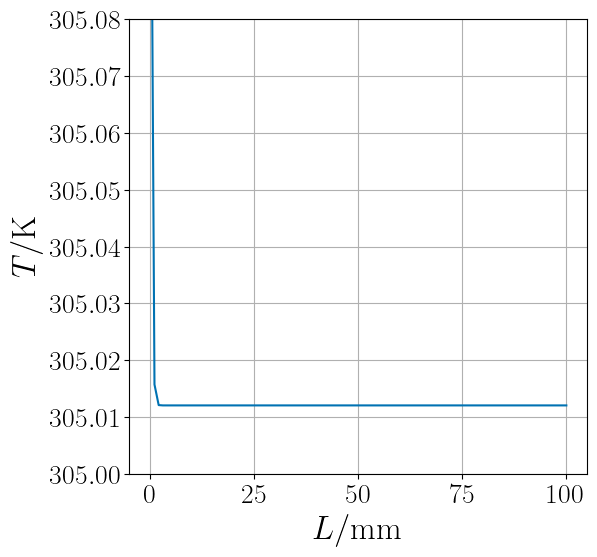

<Figure size 1000x600 with 0 Axes>

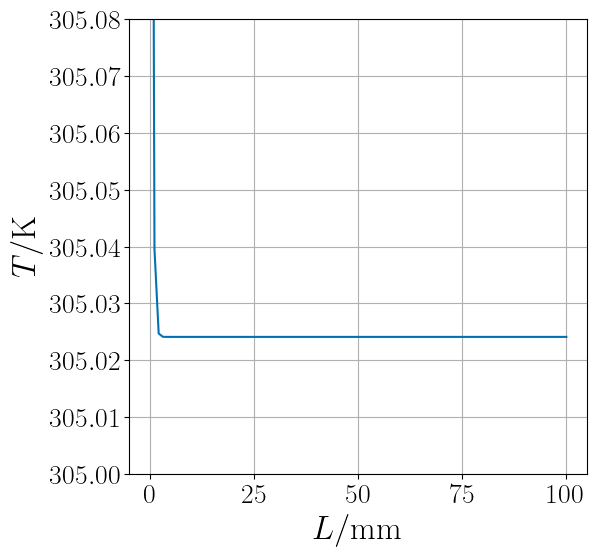

<Figure size 1000x600 with 0 Axes>

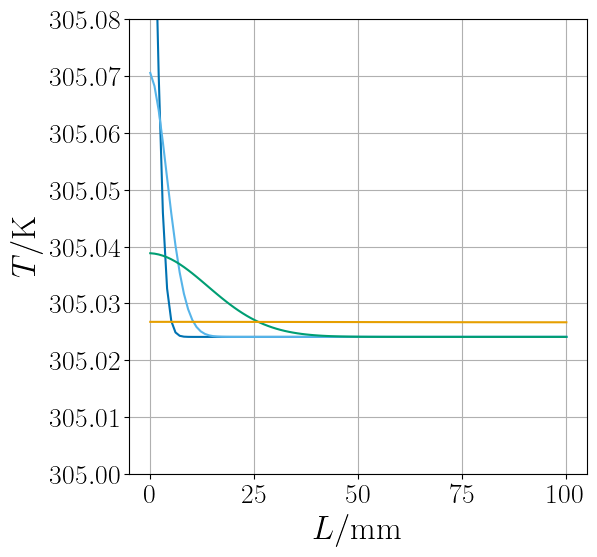

In [68]:
# temperature vs space
plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
x_star_lin=np.linspace(0,L_star, Nx_lin)

#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, T_all_cases_lin[i][ 5,:  ], color= rainbow[i],label=f'$T_0={T_all_cases_lin[i][0, int(Nx_lin-1)]*Tc}\ \mathrm{{K}}$')
plt.ylim(top=305.08, bottom=305)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ T / \rm{K} $')
#plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/TL_2t_4_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()



plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, T_all_cases_lin[i][ 10,:  ], color= rainbow[i],label=f'$T_0={T_all_cases_lin[i][0, int(Nx_lin-1)]*Tc}\ \mathrm{{K}}$')
plt.ylim(top=305.08, bottom=305)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ T / \rm{K} $')
#plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/TL_4t_4_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()


plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, T_all_cases_lin[i][ int(num_steps_lis_lin[i]/5000),:  ], color= rainbow[0],label=f'$t={T_all_cases_lin[i][0, int(Nx_lin-1)]*Tc}\ \mathrm{{K}}$')
    plt.plot(x_star_lin, T_all_cases_lin[i][ int(num_steps_lis_lin[i]/1000),:  ], color= rainbow[1],label=f'$t={T_all_cases_lin[i][0, int(Nx_lin-1)]*Tc}\ \mathrm{{K}}$')
    plt.plot(x_star_lin, T_all_cases_lin[i][ int(num_steps_lis_lin[i]/100),:  ], color= rainbow[2],label=f'$t={T_all_cases_lin[i][0, int(Nx_lin-1)]*Tc}\ \mathrm{{K}}$')
    plt.plot(x_star_lin, T_all_cases_lin[i][ int(num_steps_lis_lin[i]/2),:  ], color= rainbow[3],label=f'$t={T_all_cases_lin[i][0, int(Nx_lin-1)]*Tc}\ \mathrm{{K}}$')
#plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ T / \rm{K} $')
#plt.legend()
plt.grid(True)
plt.ylim(top=305.08, bottom=305)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/TL_diff.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()


In [33]:
Tinf_T0_sim_lin = np.zeros(len(T_all_cases_lin))

pinf_p0_sim_lin = np.zeros(len(T_all_cases_lin))

T0_T0_sim_lin = np.zeros(len(T_all_cases_lin))


for i in range(len(T_all_cases_lin)):
    Tinf_T0_sim_lin[i] = ( T_all_cases_lin[i][ num_steps_lis_lin[i] , int(Nx_lin-1)  ] - T_all_cases_lin[i][ 0 , int(Nx_lin-1)  ] ) * Tc
    #print(T_all_cases[i][0, int(Nx-1)])
    #print(num_steps_list[i])

for i in range(len(T_all_cases_lin)):
    pinf_p0_sim_lin[i] = ( p_all_cases_lin[i][num_steps_lis_lin[i]] -  p_all_cases_lin[i][0] ) * Pc


for i in range(len(T_all_cases_lin)):
    T0_T0_sim_lin[i] = ( T_all_cases_lin[i][ 10 , int(Nx_lin-1)  ] - T_all_cases_lin[i][ 0 , int(Nx_lin-1)  ] ) * Tc
#theát ez a szimulációs eredmény Kelvin ben

print("Tinf_T0 linearis szimulált: " + str(Tinf_T0_sim_lin) + " K")
print("pinf_p0 linearis szimulált: " + str(pinf_p0_sim_lin) + " Pa")
print("T0_T0 szimulált: " + str(T0_T0_sim_lin) + " K")

#a check ek valóban rosszak
#tehát viszonylag közeli eredményt kaptam az eredeti gömb belső sugarával

#az eltérés oka az (is) lehet, hogy plotok vizsgálatánál kdierült hogy nem 10 hanem 11 másodpercig melegítettem
#mert valahogy olyan logikai műveletet hasznéltam a loop ban

Tinf_T0 linearis szimulált: [26.71417753] K
pinf_p0 linearis szimulált: [2992040.07553455] Pa
T0_T0 szimulált: [24.10440912] K


Itt összehasonlytom a lineáris és nemlineáris eseteket, p-t, T-t, közös diagramokban és különbségüket véve

## lin vs nonlin

<Figure size 1000x600 with 0 Axes>

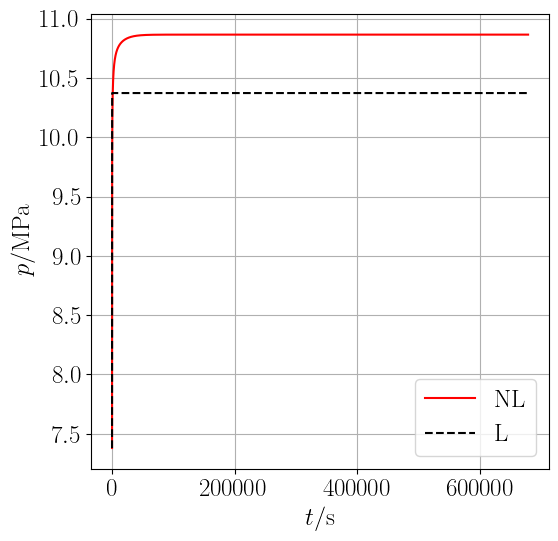

In [34]:
#pressure vs time
x_star = np.linspace(0, L_star, Nx)

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(time_record, p_all_cases[i]*1e-6,'r', label=f'NL') #{i+1} kivéve Case után
    plt.plot(time_record_dim, p_all_cases_lin[i]*Pc*1e-6 ,'k--', label=f'L')
    
    #plt.plot( 10*Delta_t_list[i],p_all_cases[i][10]/1e6 , marker='x',markersize=5, color='black')
    #plt.plot( num_steps_list[i]*Delta_t_list[i],p_all_cases[i][num_steps_list[i]]/1e6 , marker='x',markersize=5, color='black')
zoom_time = 0.0001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
#plt.axvline(x=time_record[int(t_heating/(Delta_t_star_list[0]*tau_diff_list[0]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ t / \rm{s} $')
plt.locator_params(axis='x', nbins=4)  # try 4–6 for clean article figures
plt.ylabel(r'$ p / \rm{MPa} $')
#plt.title('Pressure evolution over time')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/L_NL_385_pt.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/L_NL_385_pt_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/L_NL_385e-3_pt.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/L_NL_385e-3_pt_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

In [35]:
print(IC_all_cases[1])

[7380000.0]


In [36]:
print(len(T_all_cases_lin[0][0,:]))
print(len(T_all_cases[0][0,:]))
#azonos számú cella lin és nemlin esetben

20
20


<Figure size 1000x600 with 0 Axes>

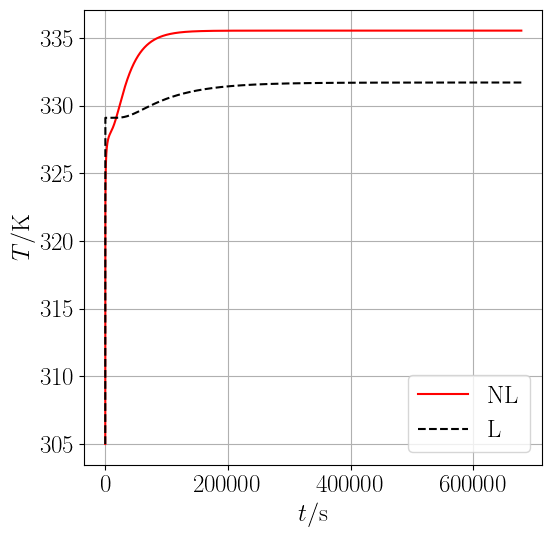

In [37]:
#temperature vs time

x_star = np.linspace(0, L_star, Nx)

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(time_record[:], T_all_cases[i][ : , int(19)  ],'r', label=f'NL') #int(Nx/2) int(Nx/3)
    plt.plot(time_record_dim, T_all_cases_lin[i][:,19]*Tc,'k--' , label=f'L') #ITT HA P=áll eset van i index ha T=áll akkor 0
    #plt.plot( 0*Delta_t_list[i],T_all_cases[i][ 0 , int(Nx-1)  ], marker='x',markersize=5, color='black')
    #plt.plot( 11*Delta_t_list[i],T_all_cases[i][ 10 , int(Nx-1)  ] , marker='x',markersize=5, color='black')
    #plt.plot( num_steps_list[i]*Delta_t_list[i],T_all_cases[i][ num_steps_list[i] , int(Nx-1)  ] , marker='x',markersize=5, color='black')
zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
#plt.axvline(x=time_record[int(t_heating/(Delta_t_star_list[0]*tau_diff_list[0]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ t / \rm{s} $')
plt.locator_params(axis='x', nbins=4) 
plt.ylabel(r'$ T / \rm{K} $')
#plt.title('Temperature evolution over time')
plt.legend(loc='lower right')
#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/L_NL_385_Tt.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/L_NL_385_Tt_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/L_NL_385e-3_Tt.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/L_NL_385e-3_Tt_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

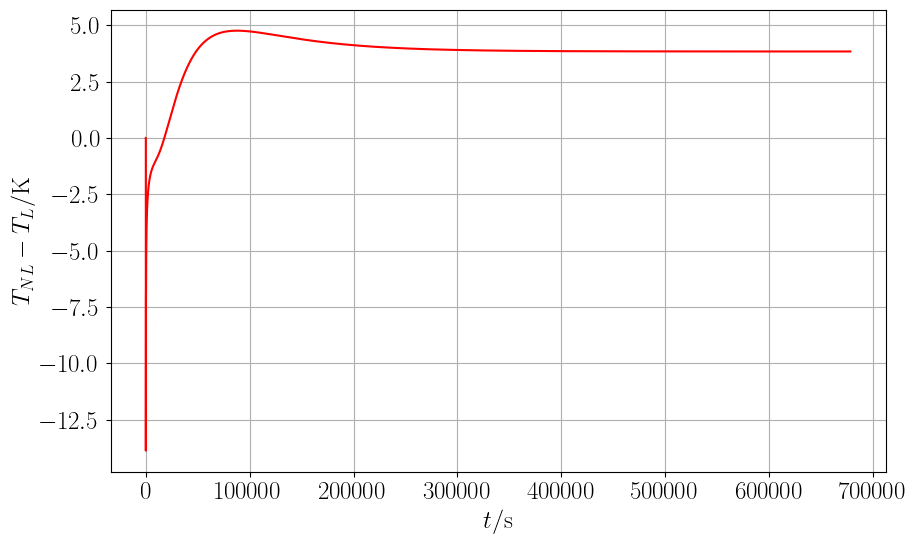

In [38]:
#temperature difference vs time

x_star = np.linspace(0, L_star, Nx)
plt.figure(figsize=(10, 6))
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(time_record, T_all_cases[i][ : , int(19)  ]- T_all_cases_lin[i][:1130347,19]*Tc,'r') #int(Nx/2) int(Nx/3)
    #2025.10.25. itt csaltam azzal, hogy T_all_cases_lin[i][:1130347,19] hogy egyenlő hosszúságú legyen a két tömb

    #plt.plot( 0*Delta_t_list[i],T_all_cases[i][ 0 , int(Nx-1)  ], marker='x',markersize=5, color='black')
    #plt.plot( 11*Delta_t_list[i],T_all_cases[i][ 10 , int(Nx-1)  ] , marker='x',markersize=5, color='black')
    #plt.plot( num_steps_list[i]*Delta_t_list[i],T_all_cases[i][ num_steps_list[i] , int(Nx-1)  ] , marker='x',markersize=5, color='black')
zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
#plt.axvline(x=time_record[int(t_heating/(Delta_t_star_list[0]*tau_diff_list[0]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ t / \rm{s} $')
plt.ylabel(r'$ T_{NL}-T_L / \rm{K} $')
#plt.title('Temperature difference evolution over time')

#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.show()

<Figure size 1000x600 with 0 Axes>

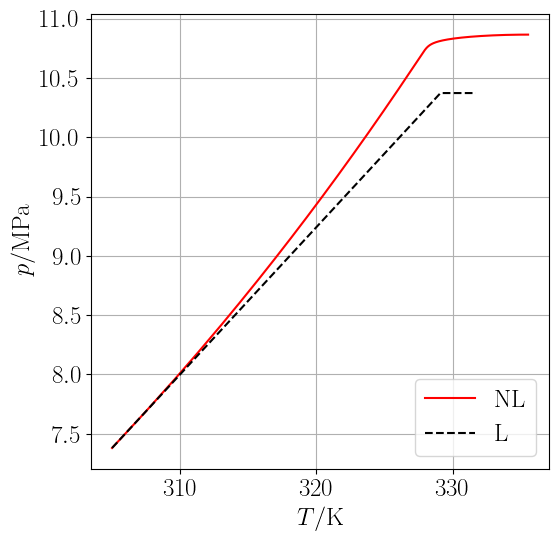

In [39]:
#process

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot( T_all_cases[i][ : , int(19)  ], p_all_cases[i]/1e6,'r',label=f'NL') #int(Nx/2) int(Nx/3)
    plt.plot( T_all_cases_lin[i][ : , int(19)  ]*Tc,  p_all_cases_lin[i]*Pc*1e-6 ,'k--',label=f'L') #int(Nx/2) int(Nx/3)
    #plt.figure(figsize=(10, 6))
    #plt.plot( 0*Delta_t_list[i],T_all_cases[i][ 0 , int(Nx-1)  ], marker='x',markersize=5, color='black')
    #plt.plot( 11*Delta_t_list[i],T_all_cases[i][ 10 , int(Nx-1)  ] , marker='x',markersize=5, color='black')
    #plt.plot( num_steps_list[i]*Delta_t_list[i],T_all_cases[i][ num_steps_list[i] , int(Nx-1)  ] , marker='x',markersize=5, color='black')
#zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
#plt.axvline(x=time_record[int(t_heating/(Delta_t_star_list[0]*tau_diff_list[0]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ T / \rm{K} $')
plt.ylabel(r'$ p / \rm{MPa} $')
#plt.title('Process')
plt.legend(loc='lower right')
#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/L_NL_385_p_T.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

<Figure size 1000x600 with 0 Axes>

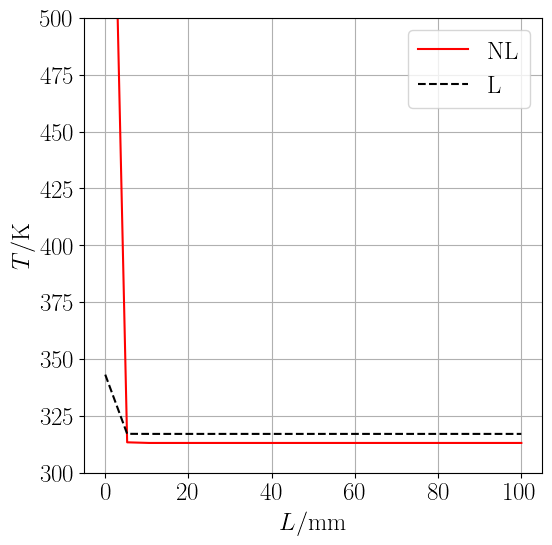

<Figure size 1000x600 with 0 Axes>

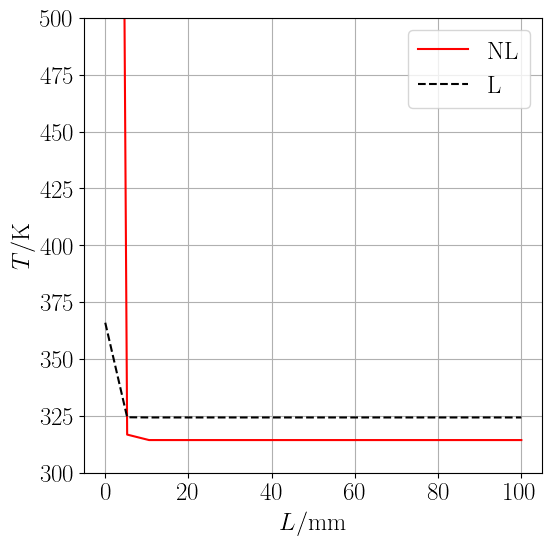

<Figure size 1000x600 with 0 Axes>

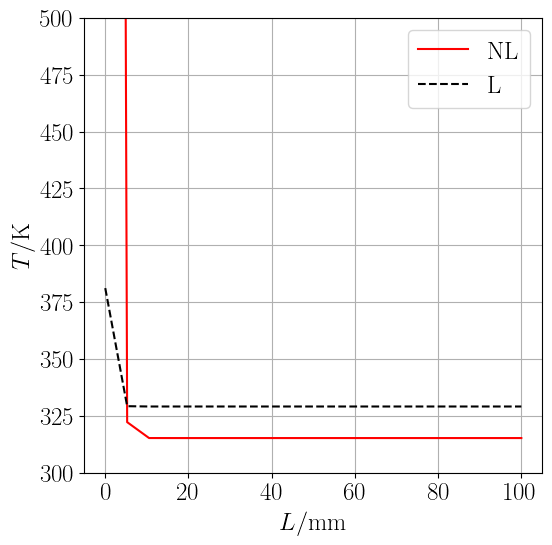

<Figure size 1000x600 with 0 Axes>

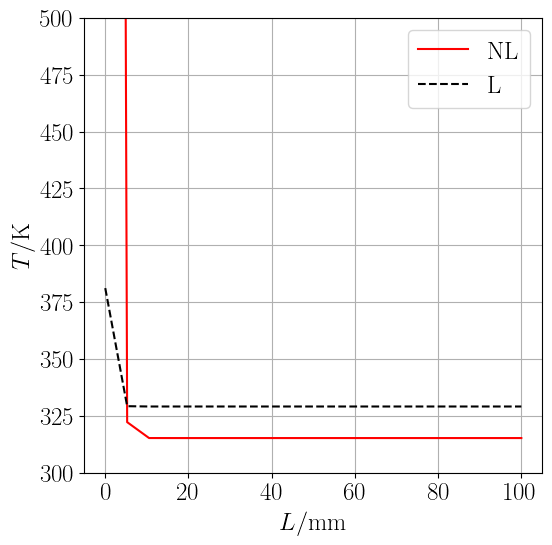

<Figure size 1000x600 with 0 Axes>

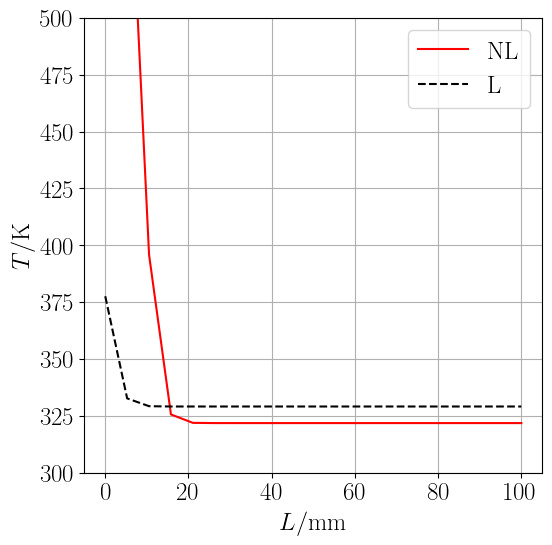

<Figure size 1000x600 with 0 Axes>

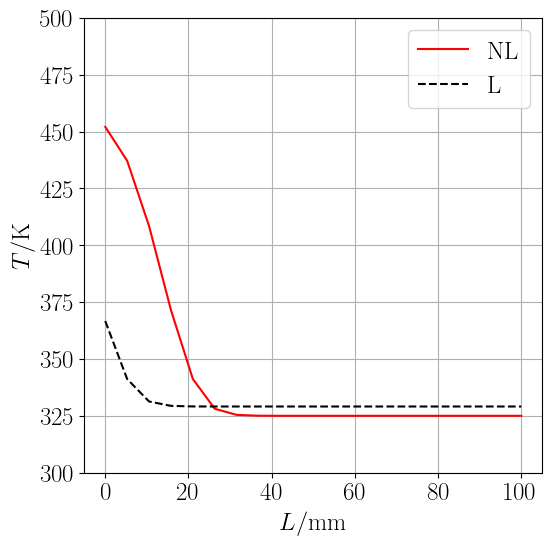

<Figure size 1000x600 with 0 Axes>

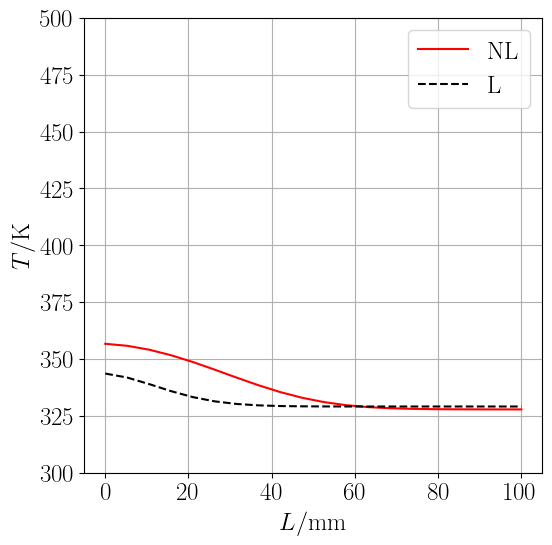

<Figure size 1000x600 with 0 Axes>

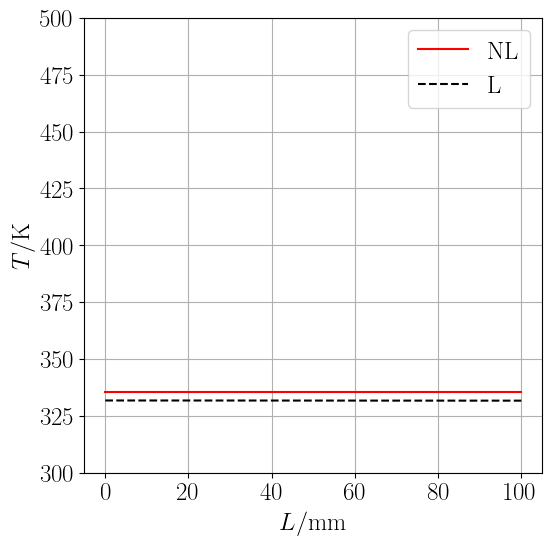

In [40]:
# temperature vs space
plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
x_star_lin=np.linspace(0,L_star, Nx_lin)

#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, T_all_cases[i][ 5,:  ] , color= 'r',label=f'NL') 
    plt.plot(x_star_lin, T_all_cases_lin[i][ 5,:  ]*Tc, color= 'k',linestyle='--',label=f'L')
plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ T / \rm{K} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/TNL_2t_4_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, T_all_cases[i][ 8,:  ] , color= 'r',label=f'NL') 
    plt.plot(x_star_lin, T_all_cases_lin[i][ 8,:  ]*Tc, color= 'k',linestyle='--',label=f'L')
plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ T / \rm{K} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/TNL_3t_4_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, T_all_cases[i][ 10,:  ] , color= 'r',label=f'NL') 
    plt.plot(x_star_lin, T_all_cases_lin[i][ 10,:  ]*Tc, color= 'k',linestyle='--',label=f'L')
plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ T / \rm{K} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/TNL_4t_4_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, T_all_cases[i][ 10,:  ] , color= 'r',label=f'NL') 
    plt.plot(x_star_lin, T_all_cases_lin[i][ 10,:  ]*Tc, color= 'k',linestyle='--',label=f'L')
plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ T / \rm{K} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/TNL_5t_4_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, T_all_cases[i][ int(tau_diff_list[i]/5000),:  ] , color= 'r',label=f'NL') 
    plt.plot(x_star_lin, T_all_cases_lin[i][  int(tau_diff_list[i]/5000),:  ]*Tc, color= 'k',linestyle='--',label=f'L')
plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ T / \rm{K} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/TNL_tau1_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, T_all_cases[i][  int(tau_diff_list[i]/1000),:  ] , color= 'r',label=f'NL') 
    plt.plot(x_star_lin, T_all_cases_lin[i][  int(tau_diff_list[i]/1000),:  ]*Tc, color= 'k',linestyle='--',label=f'L')
plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ T / \rm{K} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/TNL_tau2_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, T_all_cases[i][  int(tau_diff_list[i]/100),:  ] , color= 'r',label=f'NL') 
    plt.plot(x_star_lin, T_all_cases_lin[i][  int(tau_diff_list[i]/100),:  ]*Tc, color= 'k',linestyle='--',label=f'L')
plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ T / \rm{K} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/TNL_tau3_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, T_all_cases[i][  int(tau_diff_list[i]/2),:  ] , color= 'r',label=f'NL') 
    plt.plot(x_star_lin, T_all_cases_lin[i][  int(tau_diff_list[i]/2),:  ]*Tc, color= 'k',linestyle='--',label=f'L')
plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ T / \rm{K} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/TNL_tau4_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

<Figure size 1000x600 with 0 Axes>

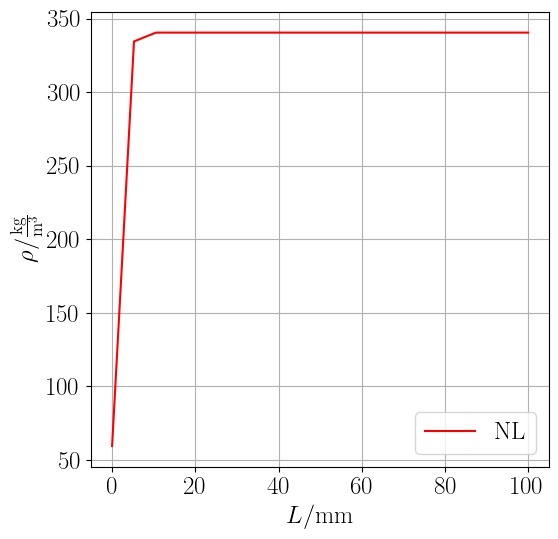

<Figure size 1000x600 with 0 Axes>

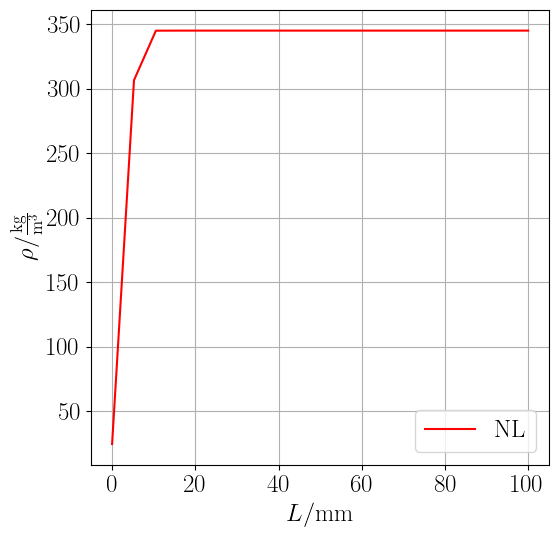

<Figure size 1000x600 with 0 Axes>

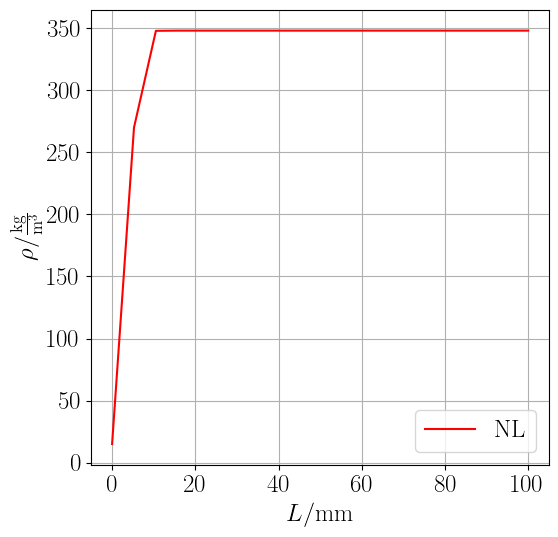

<Figure size 1000x600 with 0 Axes>

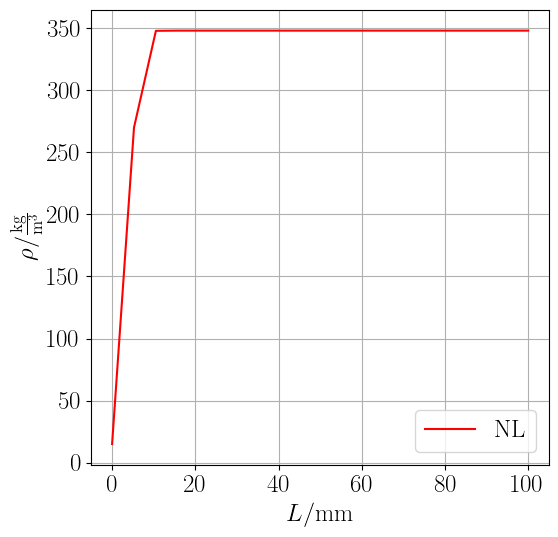

<Figure size 1000x600 with 0 Axes>

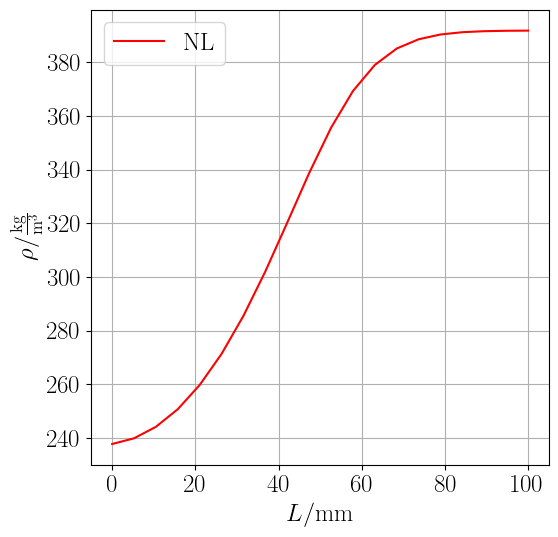

<Figure size 1000x600 with 0 Axes>

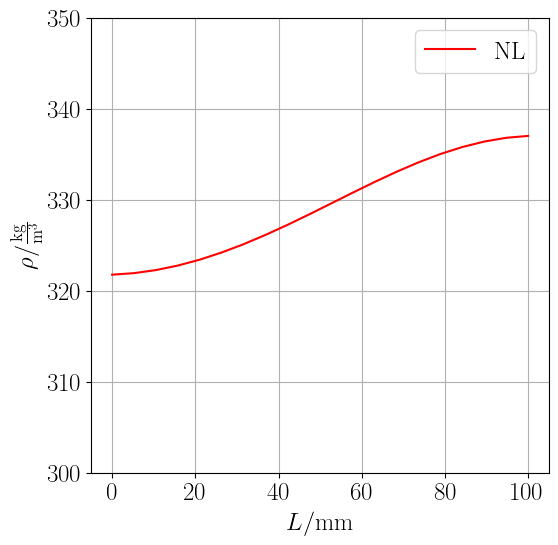

<Figure size 1000x600 with 0 Axes>

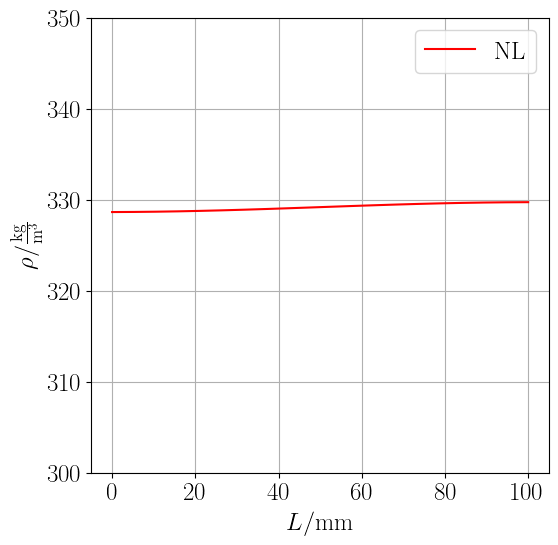

<Figure size 1000x600 with 0 Axes>

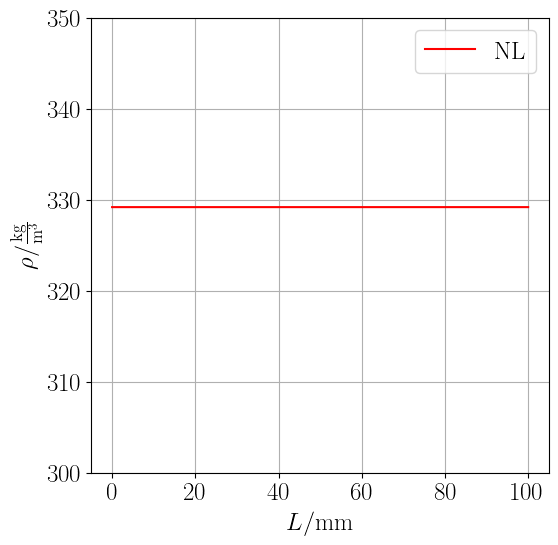

In [41]:
# density vs space
plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
plt.rcParams.update({
    "font.size": 18,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})
x_star_lin=np.linspace(0,L_star, Nx_lin)

#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, rho_all_cases[i][ 5,:  ] , color= 'r',label=f'NL') 
#plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ \rho / \rm{\frac{kg}{m^3}} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/rhoNL_2t_4_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
plt.rcParams.update({
    "font.size": 18,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, rho_all_cases[i][ 8,:  ] , color= 'r',label=f'NL') 
#plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ \rho / \rm{\frac{kg}{m^3}} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/rhoNL_3t_4_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
plt.rcParams.update({
    "font.size": 18,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, rho_all_cases[i][ 10,:  ] , color= 'r',label=f'NL') 
#plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ \rho / \rm{\frac{kg}{m^3}} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/rhoNL_4t_4_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
plt.rcParams.update({
    "font.size": 18,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, rho_all_cases[i][ 10,:  ] , color= 'r',label=f'NL') 
#plt.ylim(top=500, bottom=300)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ \rho / \rm{\frac{kg}{m^3}} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/rhoNL_5t_4_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
plt.rcParams.update({
    "font.size": 18,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, rho_all_cases[i][ int(tau_diff_list[i]/100),:  ] , color= 'r',label=f'NL') 
#plt.ylim(top=300, bottom=350)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ \rho / \rm{\frac{kg}{m^3}} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/rhoNL_tau1_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
plt.rcParams.update({
    "font.size": 18,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, rho_all_cases[i][  int(tau_diff_list[i]/10),:  ] , color= 'r',label=f'NL') 
plt.ylim(300, 350)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ \rho / \rm{\frac{kg}{m^3}} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/rhoNL_tau2_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
plt.rcParams.update({
    "font.size": 18,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, rho_all_cases[i][  int(tau_diff_list[i]/5),:  ] , color= 'r',label=f'NL') 
plt.ylim(300, 350)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ \rho / \rm{\frac{kg}{m^3}} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/rhoNL_tau3_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
plt.rcParams.update({
    "font.size": 18,          # base font size
    "axes.titlesize": 18,     # title
    "axes.labelsize": 18,     # x/y labels
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
})
#for i in range(len(T_all_cases_lin)):
for i in range(1): #ez akkor használandó amikor a lineáris jellemző esetet vizsgáljuk
#time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(x_star_lin, rho_all_cases[i][  int(tau_diff_list[i]/2),:  ] , color= 'r',label=f'NL') 
plt.ylim(300, 350)
plt.xlabel(r'$ L / \rm{mm} $')
plt.ylabel(r'$ \rho / \rm{\frac{kg}{m^3}} $')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/rhoNL_tau4_lin.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

## Más gerjesztési idejű esetek betöltése

In [42]:

# folder where your results are saved
#today_str = date.today().isoformat()

folder = "results_" + today_str_2
# dictionary to store loaded lists
loaded_lists = {}
# loop through all .json files in the folder
for filename in tqdm(os.listdir(folder)):
    if filename.endswith(".json"):
        var_name = filename.replace(".json", "")
        file_path = os.path.join(folder, filename)
        with open(file_path, "r") as f:
            loaded_lists[var_name] = json.load(f)
        print(f"Loaded {var_name} from {filename}")
# Example: access your lists
T_all_cases_2 = loaded_lists["T_all_cases"]
p_all_cases_2 = loaded_lists["p_all_cases"]
rho_all_cases_2 = loaded_lists["rho_all_cases"]
Delta_t_list_2 = loaded_lists["Delta_t_list"]
num_steps_list_2 = loaded_lists["num_steps_list"]
tau_diff_list_2 = loaded_lists["tau_diff_list"]
t_heating_list_2 = loaded_lists["t_heating_list"]
tau_acustic_list_2 = loaded_lists["tau_acustic_list"]
cp_all_cases_2 = loaded_lists["cp_all_cases"]
cv_all_cases_2 = loaded_lists["cv_all_cases"]
lambda_all_cases_2 = loaded_lists["lambda_all_cases"]
muJT_all_cases_2 = loaded_lists["muJT_all_cases"]
as_all_cases_2 = loaded_lists["as_all_cases"]
betap_all_cases_2 = loaded_lists["betap_all_cases"]
khit_all_cases_2 = loaded_lists["khit_all_cases"]
IC_all_cases_2 = loaded_lists["IC"]
print(type(T_all_cases_2))  # should be <class 'list'>
print(len(T_all_cases_2))   # number of cases
p_all_cases_2 = [np.array(case) for case in p_all_cases_2]
#print(p_all_cases_lin[0])
T_all_cases_2 = [np.array(case) for case in T_all_cases_2]
#print(T_all_cases_lin[0][:, int(Nx-1)])



# folder where your results are saved
#today_str = date.today().isoformat()

folder = "linear_results_" + today_str_lin_2
# dictionary to store loaded lists
loaded_lists = {}
# loop through all .json files in the folder
for filename in tqdm(os.listdir(folder)):
    if filename.endswith(".json"):
        var_name = filename.replace(".json", "")
        file_path = os.path.join(folder, filename)
        with open(file_path, "r") as f:
            loaded_lists[var_name] = json.load(f)
        print(f"Loaded {var_name} from {filename}")
# Example: access your lists
T_all_cases_lin_2 = loaded_lists["T_all_cases_lin"]
p_all_cases_lin_2 = loaded_lists["p_all_cases_lin"]
Delta_t_star_list_lin_2 = loaded_lists["Delta_t_star_list_lin"]
num_steps_lis_lin_2 = loaded_lists["num_steps_list_lin"]
tau_diff_list_lin_2 = loaded_lists["tau_diff_list_lin"]
t_heating_star_list_lin_2 = loaded_lists["t_heating_star_list_lin"]
beta_p0_list_lin_2 = loaded_lists["beta_p0_list_lin"]
chi_T0_list_lin_2 = loaded_lists["chi_T0_list_lin"]
print(type(T_all_cases_lin_2))  # should be <class 'list'>
print(len(T_all_cases_lin_2))   # number of cases
p_all_cases_lin_2 = [np.array(case) for case in p_all_cases_lin_2]
#print(p_all_cases_lin[0])
T_all_cases_lin_2 = [np.array(case) for case in T_all_cases_lin_2]
#print(T_all_cases_lin[0][:, int(Nx-1)])


  6%|▋         | 1/16 [00:01<00:22,  1.48s/it]

Loaded as_all_cases from as_all_cases.json


 12%|█▎        | 2/16 [00:02<00:19,  1.39s/it]

Loaded betap_all_cases from betap_all_cases.json


 19%|█▉        | 3/16 [00:04<00:17,  1.34s/it]

...

Loaded T_all_cases from T_all_cases.json
Loaded t_heating_list from t_heating_list.json
<class 'list'>
1



  0%|          | 0/8 [00:00<?, ?it/s]

Loaded beta_p0_list_lin from beta_p0_list_lin.json
Loaded chi_T0_list_lin from chi_T0_list_lin.json
Loaded Delta_t_star_list_lin from Delta_t_star_list_lin.json
Loaded num_steps_list_lin from num_steps_list_lin.json
Loaded p_all_cases_lin from p_all_cases_lin.json
Loaded tau_diff_list_lin from tau_diff_list_lin.json


100%|██████████| 8/8 [00:00<00:00, 19.62it/s]

Loaded T_all_cases_lin from T_all_cases_lin.json
Loaded t_heating_star_list_lin from t_heating_star_list_lin.json
<class 'list'>
1


<Figure size 1000x600 with 0 Axes>

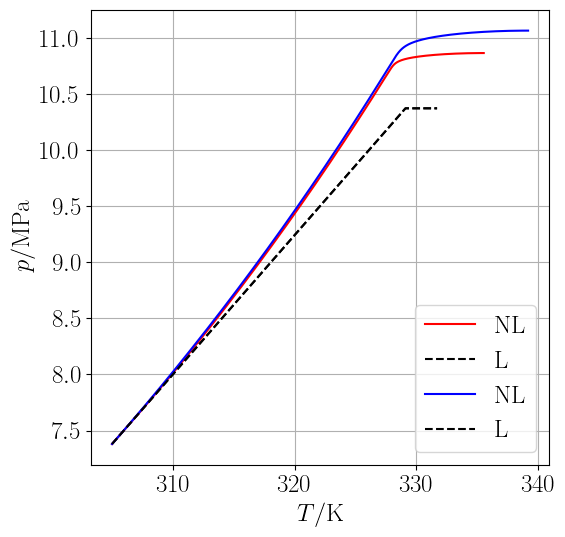

In [43]:
#process
plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(Delta_t_list)):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot( T_all_cases[i][ : , int(19)  ], p_all_cases[i]/1e6,'r',label=f'NL') #int(Nx/2) int(Nx/3)
    plt.plot( T_all_cases_lin[i][ : , int(19)  ]*Tc,  p_all_cases_lin[i]*Pc*1e-6 ,'k--',label=f'L') #int(Nx/2) int(Nx/3)
    plt.plot( T_all_cases_2[i][ : , int(19)  ], p_all_cases_2[i]/1e6,'b',label=f'NL') #int(Nx/2) int(Nx/3)
    plt.plot( T_all_cases_lin_2[i][ : , int(19)  ]*Tc,  p_all_cases_lin_2[i]*Pc*1e-6 ,'k--',label=f'L') #int(Nx/2) int(Nx/3)
    #plt.figure(figsize=(10, 6))
    #plt.plot( 0*Delta_t_list[i],T_all_cases[i][ 0 , int(Nx-1)  ], marker='x',markersize=5, color='black')
    #plt.plot( 11*Delta_t_list[i],T_all_cases[i][ 10 , int(Nx-1)  ] , marker='x',markersize=5, color='black')
    #plt.plot( num_steps_list[i]*Delta_t_list[i],T_all_cases[i][ num_steps_list[i] , int(Nx-1)  ] , marker='x',markersize=5, color='black')
#zoom_time = 0.001 * time_record[-1]  # Calculate 20% of the total time
#plt.xlim(0, zoom_time)
#plt.axvline(x=time_record[int(t_heating/(Delta_t_star_list[0]*tau_diff_list[0]))], color='k', linestyle='--', label='t_heating')
plt.xlabel(r'$ T / \rm{K} $')
plt.ylabel(r'$ p / \rm{MPa} $')
#plt.title('Process')
plt.legend(loc='lower right')
#plt.ylim(bottom=1.035, top=1.036)
plt.grid(True)
plt.ticklabel_format(style='plain', useOffset=False, axis='y')
plt.ticklabel_format(style='plain', useOffset=False, axis='x')
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/NL_NL_1000.pdf", bbox_inches='tight') 
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/NL_NL_100.pdf", bbox_inches='tight') 
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/NL_NL_2.pdf", bbox_inches='tight')  
plt.show()

Itt kiszámítom a Bp,as,cp nwat_piston tagokat a fenti process (p,T) pontjai alapján

In [44]:

tau_diff_list = [np.array(case) for case in tau_diff_list]

Delta_t_list = [np.array(case) for case in Delta_t_list]
print(tau_diff_list[0])

678208.1839310066


In [45]:
#itt kiszámolom újra a kezdeti feltételekhez tartozó menniységeket, hogy ábrázolhassam a lineáris esetet
# ebben a szekcióban fogom kiszámolni ugyan azokat az adatokat az állapotegyenlettel 
rho0 = np.zeros(len(IC_all_cases[0]))
T0ic = IC_all_cases[0]
#DENSITY
#IZOBÁR ESET, azaz hőmérséklet változik
rho_guess  = Rhoc  # starting point
for i in range(len(IC_all_cases[0])):

    try:
            rho0[i] = newton(
            density_from_pressure,
            rho_guess,
            args=(IC_all_cases[0][i], IC_all_cases[1][i]),
            tol=1e-9,
            maxiter=50000
        )
    except RuntimeError:
        # Fallback: if Newton fails, try a small perturbation
        rho0[i] = newton(
            density_from_pressure,
            rho_guess * 1.05,
            args=(IC_all_cases[0][i], IC_all_cases[1][i]),
            tol=1e-9,
            maxiter=50000
        )
    rho_guess = rho0[i]

print(rho0)

#IZOBÁR ESET, hőméerséklet változik
lambda0 = np.zeros( len(T0ic))
for i in range(len(T0ic)):
    lambda0[i] = thermal_conductivity(T0ic[i],rho0[i])

print(lambda0)

#IZOBÁR ESET, azaz hőmérséklet változik
cp0 = np.zeros(len(T0ic))
for i in range(len(T0ic)):
    cp0[i] = get_cp(T0ic[i],rho0[i])

print(cp0)

#IZOBÁR ESET, azaz hőmérséklet változik
cv0 = np.zeros( len(T0ic))
for i in range(len(T0ic)):
    cv0[i] = get_cv(T0ic[i],rho0[i])

print(cv0)

#IZOBÁR ESET, azaz hőmérséklet változik
as0 = np.zeros( len(T0ic))
for i in range(len(T0ic)):
    as0[i] = speed_of_sound(T0ic[i],rho0[i])

print(as0)

#IZOBÁR ESET, azaz hőmérséklet változik
mu_JT0 = np.zeros(len(T0ic))
for i in range(len(T0ic)):
    mu_JT0[i] = joule_thompson(T0ic[i],rho0[i])

print(mu_JT0)

#egészen jól működnek, viszont NIST-hez közelebbi eredményket adnak az izoterm esetekre

# CASE 3 futtatás után elég rossz lett ugyhogy megnézem újra a NIST-es peremekkel 

#rho0 = [ [ 313.9594362	, 317.4107576	, 321.0832514 , 325.0120484	 , 329.2416607 ] , [ 313.9594362	, 241.4523748	, 214.2308144 , 196.8502711, 184.0525757 ] ]      # [kg/m³]

#cp0 = [ [ 14387.91847, 15289.07012  , 16328.20465	, 17540.53958, 18974.47986 ] , [14387.91847	 , 	4031.134439 , 	2810.707132 , 2296.403053	, 	2006.175289] ]          # [J/kg·K]

#cv0 = [ [ 1246.895023 , 1257.442534	  , 1268.870840	, 1281.344334 , 1295.076404 ] , [ 1246.895023	,1006.165660, 935.9128560, 897.4695926 , 872.3218196 ] ]       # [J/kg K]

#lambda0 = [ [ 0.06284252011 , 0.06428784889 , 0.06587885046	 , 0.06764432539 , 0.06962197152 ] , [ 0.06284252011 ,0.03862510990	 , 0.03347178095 , 0.03102847239 , 0.02963813789 ] ]      # [W/m·K]

#as0 =  [ [ 185.5757251	, 184.8941389, 184.1644088, 183.3775833	, 182.5220048 ] , [ 185.5757251	, 206.6429998	, 217.0800772, 224.9807663	, 231.6254791 ]]          # [m/s]

#mu_JT0 = [ [ 7.891146867e-6 , 7.833355166e-6 , 7.771797071e-6 , 7.705915494e-6 , 7.635016936e-6  ] , [7.891146867e-6 ,8.609570974e-6 , 8.527626106e-6 , 8.311294320e-6 ,8.055633585e-6 ] 	]             # [K / Pa]

#nist paraméterekkel továbbra is sorba maradnak a nyomások, itt a legnagyobb eletérés talán lambda-ban van

[312.77614609]
[0.0586878]
[12725.57042842]
[1243.30717746]
[186.7123742]
[7.80493856e-06]


C:\Users\krist\AppData\Local\Temp\ipykernel_13360\1417689070.py:171: RuntimeWarning: invalid value encountered in log
  Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum


In [46]:
N_plot = Nx-1

Process_1 = np.zeros((len(IC_all_cases[0]), len(T_all_cases[0][:,0])))
Process_2 = np.zeros((len(IC_all_cases[0]), len(T_all_cases[0][:,0])))
Process_3 = np.zeros((len(IC_all_cases[0]), len(T_all_cases[0][:,0])))

Process_1_lin = np.zeros((len(IC_all_cases[0]), len(T_all_cases_lin[0][:,0])))
Process_2_lin = np.zeros((len(IC_all_cases[0]), len(T_all_cases_lin[0][:,0])))
Process_3_lin = np.zeros((len(IC_all_cases[0]), len(T_all_cases_lin[0][:,0])))

for k in range(len(IC_all_cases[0])):
    #time_record = np.arange(0, tau_diff_list[k], Delta_t_list[k])
    for j in tqdm(range(len(time_record))):
            Process_1[k,j] = T_all_cases[k][j][N_plot] / rho_all_cases[k][j][N_plot] * (betap_all_cases[k][j][19]*as_all_cases[k][j][N_plot]/cp_all_cases[k][j][N_plot])**2

            Process_2[k,j] = betap_all_cases[k][j][N_plot]* as_all_cases[k][j][N_plot]**2 / cp_all_cases[k][j][N_plot]

            Process_3[k,j] = 1 / ( rho_all_cases[k][j][N_plot]*cv_all_cases[k][j][N_plot] )

for k in range(len(IC_all_cases[0])):
    #time_record = np.arange(0, tau_diff_list[k], Delta_t_list[k])
    for j in tqdm(range(len(time_record_dim))):
            Process_1_lin[k,j] =IC_all_cases[0][k]/ rho0[k] * (beta_p0_list_lin[k]*as0[k]/cp0[k])**2

            Process_2_lin[k,j] = beta_p0_list_lin[k]* as0[k]**2 / cp0[k]

            Process_3_lin[k,j] = 1 / ( rho0[k]*cv0[k] )

100%|██████████| 678209/678209 [00:02<00:00, 255577.76it/s]


Itt kiszámítom a szükséges tagokat [p,T] függvényében Plotok_V2 alapján

## anyagjellemzők kiszámítása plotoláshoz

In [47]:

p        =  [0.8 * Pc, 1.05 * Pc , 1.2 * Pc ,1.35 * Pc , 1.5 * Pc] 
N = int((486 - 270)/0.1) + 1
T         = np.linspace(270, 486,  N)

p[0] = IC_all_cases[1][0]
p.append(p_all_cases_lin[0][num_steps_lis_lin[0]]*Pc)
p.append(p_all_cases[0][num_steps_list[0]])

rho_result = np.zeros((len(p), len(T)))


for j in tqdm(range(0,len(p))):
    rho_guess  = Rhoc  # starting point
    for i in range(0,len(T)):
        try:
            rho_result[j,len(T)-1-i] = newton(
                density_from_pressure,
                rho_guess,
                args=(T[len(T)-1-i], p[j]),
                tol=1e-1,
                maxiter=5000
            )
        except RuntimeError:
            # Fallback: if Newton fails, try a small perturbation
            rho_result[j,len(T)-1-i] = newton(
                density_from_pressure,
                rho_guess * 1.05,
                args=(T[len(T)-1-i], p[j]),
                tol=1e-1,
                maxiter=5000
            )
        rho_guess = rho_result[j,len(T)-1-i]

cp_result = np.zeros((len(p), len(T)))
for j in range(0,len(p)):
    for i in range(0,len(T)):
        cp_result[j,i] = get_cp(T[i],rho_result[j,i])

cv_result = np.zeros((len(p), len(T)))
for j in range(0,len(p)):
    for i in range(0,len(T)):
        cv_result[j,i] = get_cv(T[i],rho_result[j,i])

a_s_result = np.zeros((len(p), len(T)))
for j in range(0,len(p)):
    for i in range(0,len(T)):
        a_s_result[j,i] = speed_of_sound(T[i],rho_result[j,i])

mu_JT_result = np.zeros((len(p), len(T)))
for j in range(0,len(p)):
    for i in range(0,len(T)):
        mu_JT_result[j,i] = joule_thompson(T[i],rho_result[j,i])

Beta_p_result = np.zeros((len(p), len(T)))

for j in range(len(p)):
    for i in range(len(T)):
        Beta_p_result[j,i] = ( mu_JT_result[j,i] * cp_result[j,i] * rho_result[j,i] + 1 ) / T[i]

Khi_T_as = np.zeros((len(p), len(T)))

for j in range(len(p)):
    for i in range(len(T)):
        Khi_T_as[j,i] = cp_result[j,i] / ( cv_result[j,i] * rho_result[j,i] * a_s_result[j,i]**2 )



Plot_1 = np.zeros((len(p), len(T)))
Plot_2 = np.zeros((len(p), len(T)))
Plot_3 = np.zeros((len(p), len(T)))

for j in range(len(p)):
    for i in range(len(T)):
        Plot_1[j,i] = T[i] / rho_result[j,i] * (Beta_p_result[j,i]*a_s_result[j,i]/cp_result[j,i])**2

        Plot_2[j,i] = Beta_p_result[j,i] * a_s_result[j,i]**2 / cp_result[j,i]

        Plot_3[j,i] = 1 / (rho_result[j,i]*cv_result[j,i])



rho_point = newton(
                density_from_pressure,
                rho_guess,
                args=(IC_all_cases[0][0],IC_all_cases[1][0] ),
                tol=1e-9,
                maxiter=5000
                    )
cp_point = get_cp(IC_all_cases[0][0],rho_point)

cv_point = get_cv(IC_all_cases[0][0],rho_point)

as_point = speed_of_sound(IC_all_cases[0][0],rho_point)

mu_JT_point= joule_thompson(IC_all_cases[0][0],rho_point)

betap_point = ( mu_JT_point* cp_point * rho_point + 1 ) / IC_all_cases[0][0]

khi_T_as_point = cp_point / ( cv_point * rho_point * as_point**2 )

Point_1 = IC_all_cases[0][0] / rho_point * (betap_point*as_point/cp_point)**2

Point_2 = betap_point * as_point**2 / cp_point

Point_3= 1 / ( rho_point*cv_point)
#print(Beta_p_result)
#print(T)
#print(rho_result)


  0%|          | 0/7 [00:00<?, ?it/s]

C:\Users\krist\AppData\Local\Temp\ipykernel_13360\1417689070.py:171: RuntimeWarning: invalid value encountered in log
  Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum
100%|██████████| 7/7 [00:09<00:00,  1.38s/it]


In [48]:
#Ez csak ellenőrzésre van itt
# plt.figure(figsize=(40/2.54,30/2.54))
# for j in range(len(p)):
#     plt.plot(T, rho_result[j, :], lw=2, ls='-', label=f"{p[j]/Pc:.2f} pc")

# #axes = plt.gca()
# #plt.ylim([0,100])
# #plt.xlim([0,0.01])
# plt.grid()

# plt.xlabel(r'$ T / \ \rm{K} $')
# plt.ylabel(r'$ rho / \ \rm{\frac{kg}{m^3}} $')

# plt.legend(loc='upper right')


# plt.show()

Itt kiplotolom az nwat_pistonos szorzatok értékét adott nyomásokon és hőmérsékleteken, és velük együtt a fent meghatározott process menti menti értékeiket

## nwat plots

0.3
0.41666666666666663
0.5333333333333333
0.6499999999999999
0.7666666666666666
0.8833333333333333
0.9999999999999998


C:\Users\krist\AppData\Local\Temp\ipykernel_13360\60962211.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greys")


<Figure size 1000x600 with 0 Axes>

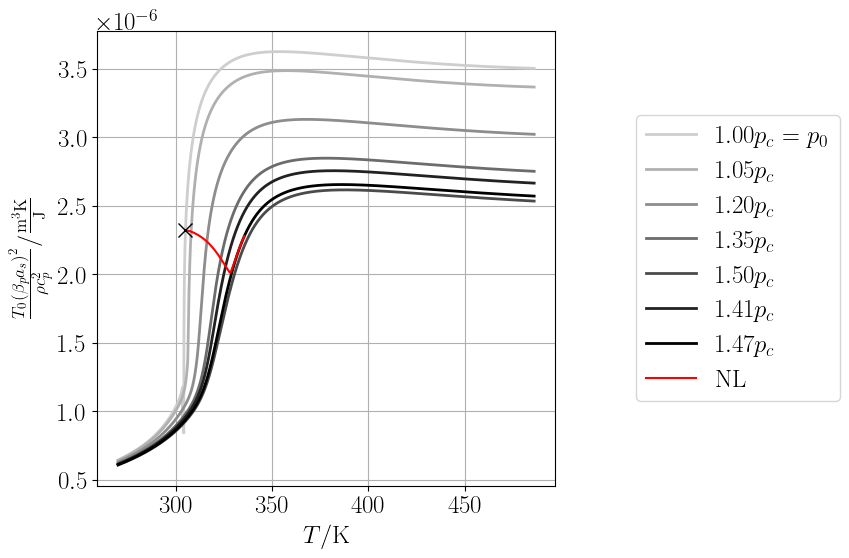

In [49]:

import matplotlib.cm as cm
plt.figure(figsize=(10, 6))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })



# normalize i between 0 and 1
cmap = cm.get_cmap("Greys")  


for i in range(len(p)):
    #color = cmap(i)   # pick the i-th grey shade

    # scale i into a restricted range [0.2, 0.8] instead of [0, 1]
    frac = 0.3 + (0.7 * i / (len(p)-1))
    print(frac)
    color = cmap(frac)

    plt.plot(
        T, Plot_1[i,:],
        lw=2,
        ls='-',
        color=color,
        label=f'${p[i]/Pc:.2f} p_c=p_0  $' if p[i] == IC_all_cases[1][0] else f'${p[i]/Pc:.2f} p_c$'    )

for i in range(len(IC_all_cases[0])):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(T_all_cases[i][:,N_plot], Process_1[i],'r', label=f'NL') #int(Nx/2) int(Nx/3)
    #plt.plot(T_all_cases_lin[i][:,N_plot]*Tc, Process_1_lin[i],'k--', label=f'Linear case') #int(Nx/2) int(Nx/3)
    

plt.plot( IC_all_cases[0][0],Point_1, marker='x',markersize=10, color='black')
axes = plt.gca()
plt.grid()

plt.ylabel(r'$ \frac{T_0(\beta_p a_s)^2}{\rho c_p^2}   \rm{  /  \frac{m^3 K}{J}}  $')
plt.xlabel(r'$ T / \rm{K} $')

plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
#plt.locator_params(axis='x', nbins=4)  # try 4–6 for clean article figures
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/nwat1_process.pdf", bbox_inches='tight')  # vector, best for LaTeX


# #BEZOOMOLÁS
#plt.xlim(290,350)
#plt.ylim(1.9e-6,2.5e-6)
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/nwat1_process_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()




0.3
0.41666666666666663
0.5333333333333333
0.6499999999999999
0.7666666666666666
0.8833333333333333
0.9999999999999998


C:\Users\krist\AppData\Local\Temp\ipykernel_13360\1699267254.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greys")


<Figure size 1574.8x1181.1 with 0 Axes>

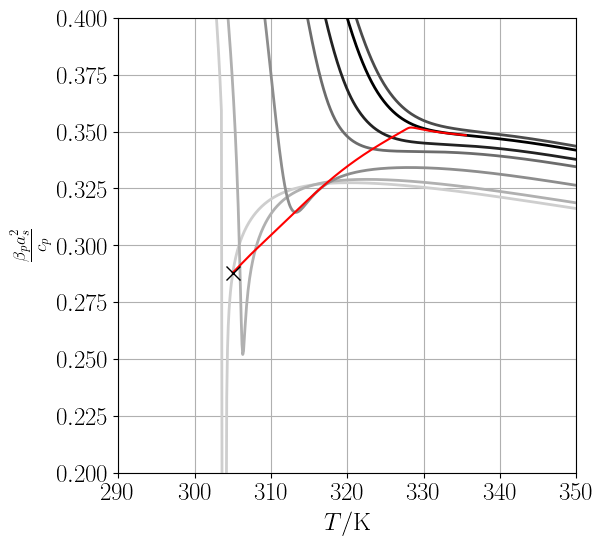

In [50]:

import matplotlib.cm as cm
plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
# normalize i between 0 and 1
cmap = cm.get_cmap("Greys")  


for i in range(len(p)):
    #color = cmap(i)   # pick the i-th grey shade

    # scale i into a restricted range [0.2, 0.8] instead of [0, 1]
    frac = 0.3 + (0.7 * i / (len(p)-1))
    print(frac)
    color = cmap(frac)

    plt.plot(
        T, Plot_2[i,:],
        lw=2,
        ls='-',
        color=color,
        label=f'${p[i]/Pc:.2f} p_c=p_0  $' if p[i] == IC_all_cases[1][0] else f'${p[i]/Pc:.2f} p_c$'    
    )

for i in range(len(IC_all_cases[0])):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(T_all_cases[i][:,N_plot], Process_2[i],'r', label=f'NL') #int(Nx/2) int(Nx/3)
    #plt.plot(T_all_cases_lin[i][:,N_plot]*Tc, Process_2_lin[i],'k--', label=f'Linear case') #int(Nx/2) int(Nx/3)
plt.plot( IC_all_cases[0][0],Point_2, marker='x',markersize=10, color='black')
axes = plt.gca()
plt.grid()

plt.ylabel(r'$ \frac{\beta_p a_s^2}{  c_p } $')
plt.xlabel(r'$ T / \rm{K} $')

# #BEZOOMOLÁS
plt.xlim(290,350)
plt.ylim(0.2,0.4)

#plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
#plt.locator_params(axis='x', nbins=4)  # try 4–6 for clean article figures
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/nwat2_process.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/nwat2_process_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX

plt.show()




In [51]:
print(IC_all_cases)

[[305.0], [7380000.0], 38.5]


0.3
0.41666666666666663
0.5333333333333333
0.6499999999999999
0.7666666666666666
0.8833333333333333
0.9999999999999998


C:\Users\krist\AppData\Local\Temp\ipykernel_13360\1924825782.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greys")


<Figure size 1574.8x1181.1 with 0 Axes>

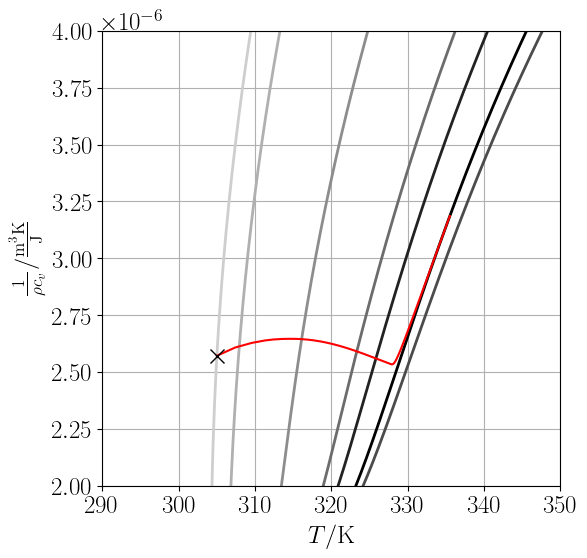

In [52]:

import matplotlib.cm as cm
plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
# normalize i between 0 and 1
cmap = cm.get_cmap("Greys")  


for i in range(len(p)):
    #color = cmap(i)   # pick the i-th grey shade

    # scale i into a restricted range [0.2, 0.8] instead of [0, 1]
    frac = 0.3 + (0.7 * i / (len(p)-1))
    print(frac)
    color = cmap(frac)

    plt.plot(
        T, Plot_3[i,:],
        lw=2,
        ls='-',
        color=color,
        label=f'${p[i]/Pc:.2f} p_c=p_0  $' if p[i] == IC_all_cases[1][0] else f'${p[i]/Pc:.2f} p_c$'    
    )

for i in range(len(IC_all_cases[0])):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(T_all_cases[i][:,N_plot], Process_3[i],'r', label=f'NL') #int(Nx/2) int(Nx/3)
    #plt.plot(T_all_cases_lin[i][:,N_plot]*Tc, Process_3_lin[i],'k--', label=f'Linear case') #int(Nx/2) int(Nx/3)

plt.plot( IC_all_cases[0][0],Point_3, marker='x',markersize=10, color='black')
axes = plt.gca()
plt.grid()

plt.ylabel(r'$\frac{ 1 } {\rho c_v} \rm{  /  \frac{m^3 K}{J}}$')
plt.xlabel(r'$ T / \rm{K} $')

#plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))

# #BEZOOMOLÁS
plt.xlim(290,350)
plt.ylim(0.2e-5,0.4e-5)
#plt.locator_params(axis='x', nbins=4)  # try 4–6 for clean article figures
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/nwat3_process.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/nwat3_process_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()




## lambda, alpha

In [53]:
lambda_result = np.zeros((len(p), len(T)))
for j in range(0,len(p)):
    for i in range(0,len(T)):
        lambda_result[j,i] = thermal_conductivity(T[i],rho_result[j,i])
alpha_result = np.zeros((len(p), len(T)))
for j in range(0,len(p)):
    for i in range(0,len(T)):
        alpha_result[j,i] = lambda_result[j,i] / (rho_result[j,i] * cp_result[j,i] ) 

In [54]:
T_all_cases = np.array(T_all_cases)
lambda_all_cases = np.array(lambda_all_cases)
rho_all_cases = np.array(rho_all_cases)
cp_all_cases = np.array(cp_all_cases)

0.3
0.41666666666666663
0.5333333333333333
0.6499999999999999
0.7666666666666666
0.8833333333333333
0.9999999999999998


C:\Users\krist\AppData\Local\Temp\ipykernel_13360\4088260218.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greys")


<Figure size 1574.8x1181.1 with 0 Axes>

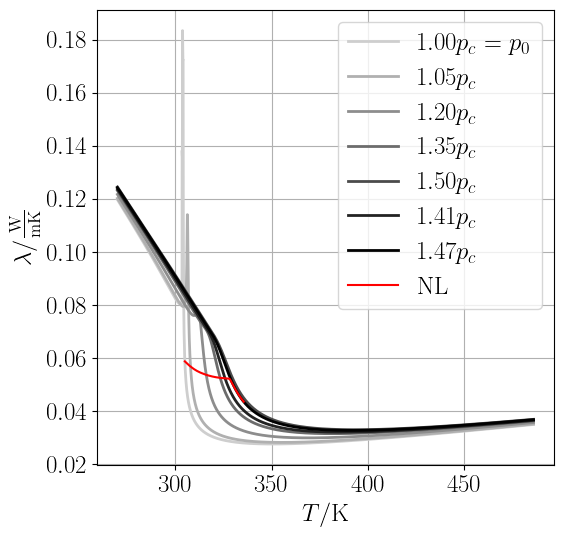

In [55]:

plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# normalize i between 0 and 1
cmap = cm.get_cmap("Greys")  


for i in range(len(p)):
    #color = cmap(i)   # pick the i-th grey shade

    # scale i into a restricted range [0.2, 0.8] instead of [0, 1]
    frac = 0.3 + (0.7 * i / (len(p)-1))
    print(frac)
    color = cmap(frac)

    plt.plot(
        T, lambda_result[i,:],
        lw=2,
        ls='-',
        color=color,
        label=f'${p[i]/Pc:.2f} p_c=p_0  $' if p[i] == IC_all_cases[1][0] else f'${p[i]/Pc:.2f} p_c$'    
    )

for i in range(len(IC_all_cases[0])):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(T_all_cases[i][:,N_plot], lambda_all_cases[i][:,N_plot],'r', label=f'NL') #int(Nx/2) int(Nx/3)
    #plt.plot(T_all_cases_lin[i][:,N_plot]*Tc, Process_1_lin[i],'k--', label=f'Linear case') #int(Nx/2) int(Nx/3)
    

axes = plt.gca()
plt.grid()

plt.ylabel(r'$ \lambda / \rm{\frac{W}{mK}} $')
plt.xlabel(r'$ T / \rm{K} $')

plt.legend(loc='upper right')


# #BEZOOMOLÁS
# plt.xlim(290,350)
# plt.ylim(1.0e-6,1.5e-6)
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/lambda_process.pdf", bbox_inches='tight') 
plt.show()




0.3
0.41666666666666663
0.5333333333333333
0.6499999999999999
0.7666666666666666
0.8833333333333333
0.9999999999999998


C:\Users\krist\AppData\Local\Temp\ipykernel_13360\713264197.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greys")


<Figure size 1574.8x1181.1 with 0 Axes>

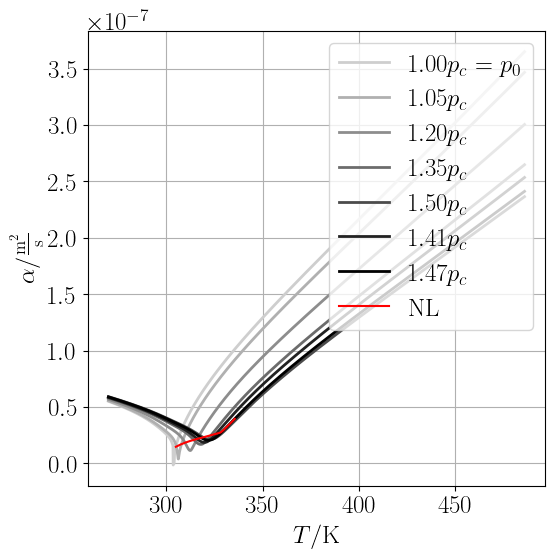

In [56]:

plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# normalize i between 0 and 1
cmap = cm.get_cmap("Greys")  


for i in range(len(p)):
    #color = cmap(i)   # pick the i-th grey shade

    # scale i into a restricted range [0.2, 0.8] instead of [0, 1]
    frac = 0.3 + (0.7 * i / (len(p)-1))
    print(frac)
    color = cmap(frac)

    plt.plot(
        T, alpha_result[i,:],
        lw=2,
        ls='-',
        color=color,
        label=f'${p[i]/Pc:.2f} p_c=p_0  $' if p[i] == IC_all_cases[1][0] else f'${p[i]/Pc:.2f} p_c$'  
    )

for i in range(len(IC_all_cases[0])):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    plt.plot(T_all_cases[i][:,N_plot], lambda_all_cases[i][:,N_plot]/ (rho_all_cases[i][:,N_plot] * cp_all_cases[i][:,N_plot] ),'r', label=f'NL') #int(Nx/2) int(Nx/3)
    #plt.plot(T_all_cases_lin[i][:,N_plot]*Tc, Process_1_lin[i],'k--', label=f'Linear case') #int(Nx/2) int(Nx/3)
    

axes = plt.gca()
plt.grid()

plt.ylabel(r'$ \alpha / \rm{ \frac{m^2}{s}} $')
plt.xlabel(r'$ T / \rm{K} $')

plt.legend(loc='upper right')


# #BEZOOMOLÁS
# plt.xlim(290,350)
# plt.ylim(1.0e-6,1.5e-6)
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/alpha_process.pdf", bbox_inches='tight') 
plt.show()




C:\Users\krist\AppData\Local\Temp\ipykernel_13360\265167745.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greys")
C:\Users\krist\AppData\Local\Temp\ipykernel_13360\265167745.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bmap = cm.get_cmap("Blues")


0.3
0.41666666666666663
0.5333333333333333
0.6499999999999999
0.7666666666666666
0.8833333333333333
0.9999999999999998
0.3
0.41666666666666663
0.5333333333333333
0.6499999999999999
0.7666666666666666
0.8833333333333333
0.9999999999999998


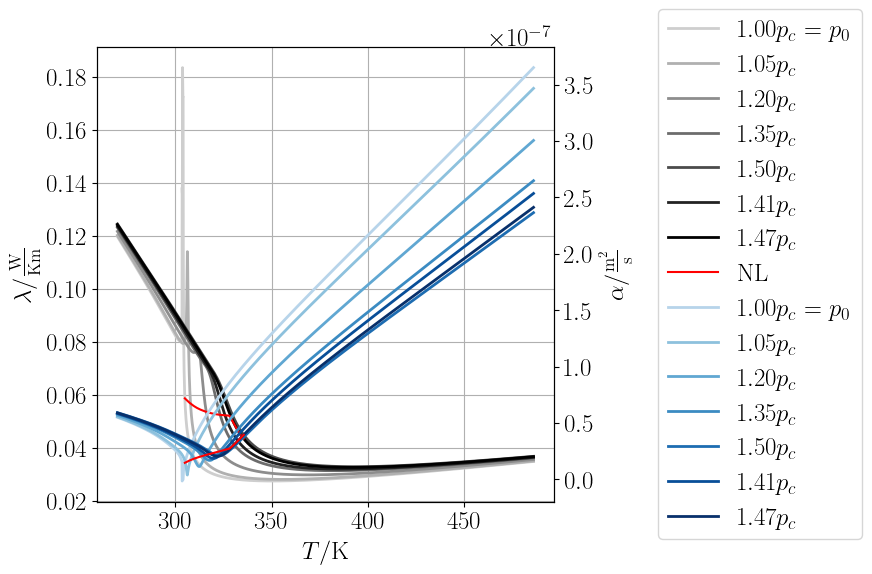

In [57]:
#fig, ax1 = plt.subplots(figsize=(40/2.54,30/2.54))
fig, ax1 = plt.subplots(figsize=(15/2.54,15/2.54))
#plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 30,          # base font size
#     "axes.titlesize": 30,     # title
#     "axes.labelsize": 30,     # x/y labels
#     "xtick.labelsize": 30,
#     "ytick.labelsize": 30,
#     "legend.fontsize": 30,
# })
# normalize i between 0 and 1
cmap = cm.get_cmap("Greys")  
bmap = cm.get_cmap("Blues")  
# blues = [
#     (198/255, 226/255, 255/255),  # very light blue
#     (173/255, 216/255, 230/255),  # light blue
#     (135/255, 206/255, 250/255),  # light sky blue
#     (100/255, 149/255, 237/255),  # cornflower blue
#     ( 30/255, 144/255, 255/255),  # dodger blue
#     (  0/255,   0/255, 139/255),  # dark blue
#     ( 25/255,  25/255, 112/255)   # midnight blue
# ]


for i in range(len(p)):
    #color = cmap(i)   # pick the i-th grey shade

    # scale i into a restricted range [0.2, 0.8] instead of [0, 1]
    frac = 0.3 + (0.7 * i / (len(p)-1))
    print(frac)
    color = cmap(frac)

    ax1.plot(
        T, lambda_result[i,:],
        lw=2,
        ls='-',
        color=color,
        label=f'${p[i]/Pc:.2f} p_c=p_0  $' if p[i] == IC_all_cases[1][0] else f'${p[i]/Pc:.2f} p_c$'    
    )
for i in range(len(IC_all_cases[0])):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    ax1.plot(T_all_cases[i][:,N_plot], lambda_all_cases[i][:,N_plot],'r', label=f'NL') #int(Nx/2) int(Nx/3)
    #plt.plot(T_all_cases_lin[i][:,N_plot]*Tc, Process_1_lin[i],'k--', label=f'Linear case') #int(Nx/2) int(Nx/3)
    
plt.ylabel(r'$ \lambda / \rm{ \frac{W}{Km}} $')
plt.xlabel(r'$ T / \rm{K} $')
axes = plt.gca()
plt.grid()



# Second y-axis
ax2 = ax1.twinx()  # create a twin Axes sharing the same x-axis
for i in range(len(p)):
    #color = cmap(i)   # pick the i-th grey shade

    # scale i into a restricted range [0.2, 0.8] instead of [0, 1]
    frac = 0.3 + (0.7 * i / (len(p)-1))
    print(frac)
    color = bmap(frac)

    ax2.plot(
        T, alpha_result[i,:],
        lw=2,
        ls='-',
        color=color, 
        label=f'${p[i]/Pc:.2f} p_c=p_0  $' if p[i] == IC_all_cases[1][0] else f'${p[i]/Pc:.2f} p_c$'    
    )
for i in range(len(IC_all_cases[0])):
    #time_record = np.arange(0, tau_diff_list[i], Delta_t_list[i])
    ax2.plot(T_all_cases[i][:,N_plot], lambda_all_cases[i][:,N_plot]/ (rho_all_cases[i][:,N_plot] * cp_all_cases[i][:,N_plot]  ),'r') #int(Nx/2) int(Nx/3)

plt.ylabel(r'$ \alpha / \rm{\frac{m^2}{s}} $')

# Optional: shared legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right',bbox_to_anchor=(1.7, 0.5)) #ez van a kicsihez
#ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right',bbox_to_anchor=(1.5, 0.5))
#plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))


#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/lambda_alpha_process.pdf", bbox_inches='tight')  # vector, best for LaTeX
#plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/lambda_alpha_process_large.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()


Itt betöltöm ezeket Widom_V3 finom felosztással egyszer kiszámoltam

In [58]:
folder = "widom"

# dictionary to store loaded lists
widom_lists = {}

# loop through all .json files in the folder
for filename in tqdm(os.listdir(folder)):
    if filename.endswith(".json"):
        var_name = filename.replace(".json", "")
        file_path = os.path.join(folder, filename)
        with open(file_path, "r") as f:
            widom_lists[var_name] = json.load(f)
        print(f"Loaded {var_name} from {filename}")

# Example: access your lists
pts_T_cp = widom_lists["pts_T_cp"]
pts_p_cp = widom_lists["pts_p_cp"]
pts_T_cv = widom_lists["pts_T_cv"]
pts_p_cv = widom_lists["pts_p_cv"]
pts_T_as = widom_lists["pts_T_as"]
pts_p_as = widom_lists["pts_p_as"]
pts_T_lambda = widom_lists["pts_T_lambda"]
pts_p_lambda = widom_lists["pts_p_lambda"]
pts_T_betap = widom_lists["pts_T_betap"]
pts_p_betap = widom_lists["pts_p_betap"]
pts_T_khit = widom_lists["pts_T_khit"]
pts_p_khit = widom_lists["pts_p_khit"]
T_vapor = widom_lists["T_vapor"]
p_vapor= widom_lists["p_vapor"]
Tt = widom_lists["Tt"]
pt = widom_lists["pt"]

#print(type(T_all_cases_lin))  # should be <class 'list'>
#print(len(T_all_cases_lin))   # number of cases


 56%|█████▋    | 9/16 [00:00<00:00, 45.15it/s]

Loaded pt from pt.json
Loaded pts_p_as from pts_p_as.json
Loaded pts_p_betap from pts_p_betap.json
Loaded pts_p_cp from pts_p_cp.json
Loaded pts_p_cv from pts_p_cv.json
Loaded pts_p_khit from pts_p_khit.json
Loaded pts_p_lambda from pts_p_lambda.json
Loaded pts_T_as from pts_T_as.json
Loaded pts_T_betap from pts_T_betap.json
Loaded pts_T_cp from pts_T_cp.json
Loaded pts_T_cv from pts_T_cv.json


100%|██████████| 16/16 [00:00<00:00, 47.12it/s]

Loaded pts_T_khit from pts_T_khit.json
Loaded pts_T_lambda from pts_T_lambda.json
Loaded p_vapor from p_vapor.json
Loaded Tt from Tt.json
Loaded T_vapor from T_vapor.json


Itt kiplotolom a Widom vonalakat és a folyamatot, hogy láthatóvá váljék mely Widom vonalakat metszi a folyamat

Itt különösen fontos lenne bezoomolni a kritikus pont / folyamat környékére mert alapjáraton nagyon nagy tartományt plotol ki

In [59]:

pts_T_khit = np.array(pts_T_khit, dtype=float)
pts_p_khit = np.array(pts_p_khit, dtype=float)
pts_T_lambda = np.array(pts_T_lambda, dtype=float)
pts_p_lambda = np.array(pts_p_lambda, dtype=float)
pts_T_cp = np.array(pts_T_cp, dtype=float)
pts_p_cp = np.array(pts_p_cp, dtype=float)
pts_T_cv = np.array(pts_T_cv, dtype=float)
pts_p_cv = np.array(pts_p_cv, dtype=float)
pts_T_as = np.array(pts_T_as, dtype=float)
pts_p_as = np.array(pts_p_as, dtype=float)
pts_T_betap = np.array(pts_T_betap, dtype=float)
pts_p_betap = np.array(pts_p_betap, dtype=float)
T_vapor = np.array(T_vapor, dtype=float)
p_vapor = np.array(p_vapor, dtype=float)

print(pts_T_khit)
print(len(pts_T_khit))

[304.7124371  304.7124371  304.92487419 ... 600.         600.
 600.        ]
1392


In [60]:
print(pt)

0.5185


# Chapter 3 –Widom lines

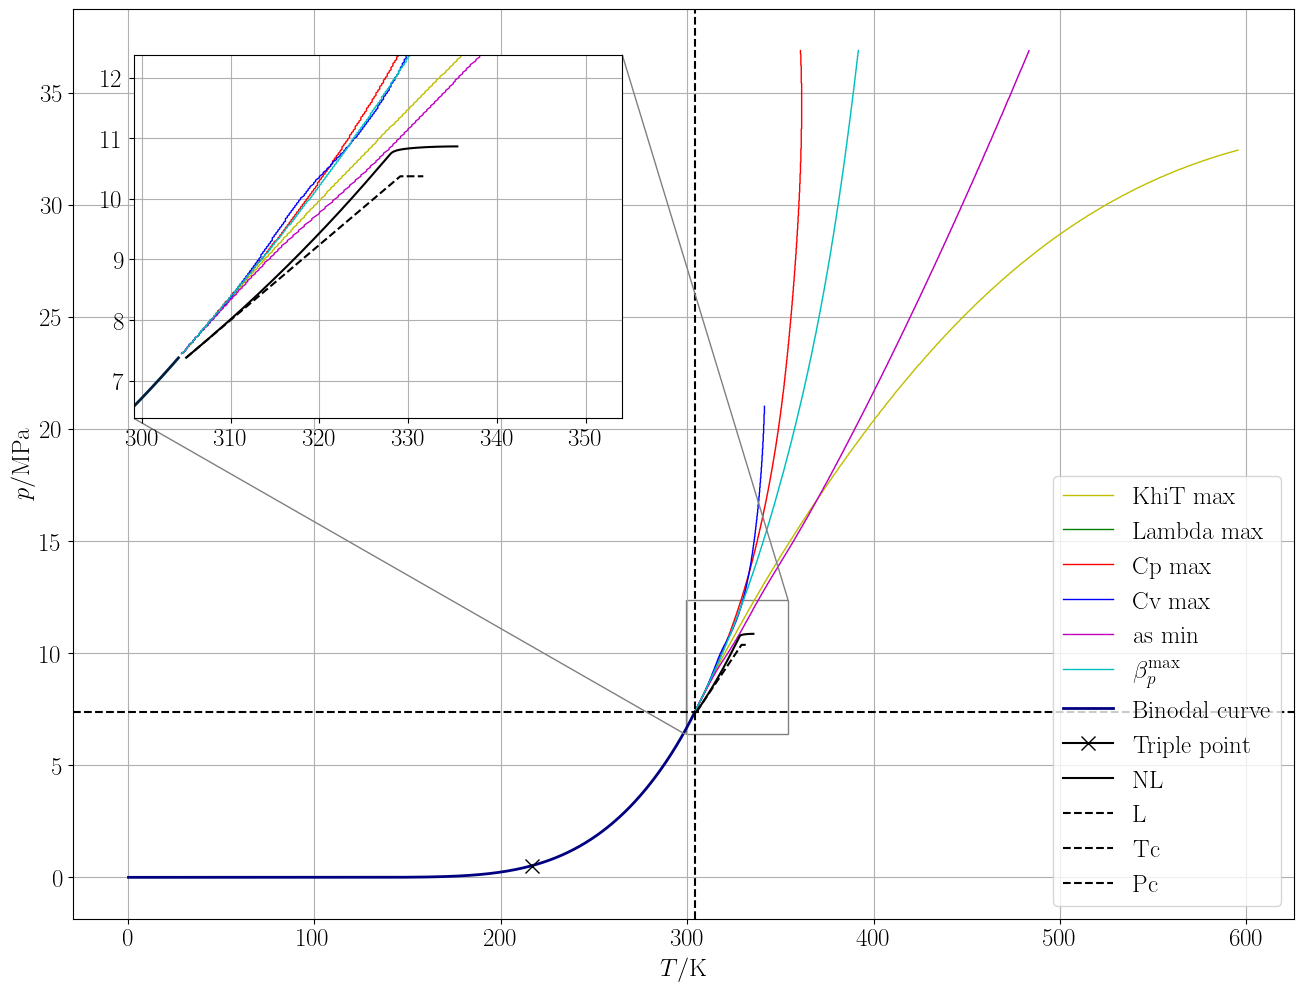

In [61]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
plt.figure(figsize=(40/2.54,30/2.54))

plt.plot(pts_T_khit[:-210],pts_p_khit[:-210]/1e6,c='y', lw=1,label=" KhiT max")
plt.plot(pts_T_lambda[:-2000],pts_p_lambda[:-2000]/1e6,c='g', lw=1,label=" Lambda max")
plt.plot(pts_T_cp,pts_p_cp/1e6,c='r', lw=1,label=" Cp max")
plt.plot(pts_T_cv[:-750],pts_p_cv[:-750]/1e6,c='b', lw=1,label=" Cv max")
plt.plot(pts_T_as,pts_p_as/1e6,c='m', lw=1,label=" as min")
plt.plot(pts_T_betap,pts_p_betap/1e6,c='c', lw=1,label=r'$\beta_p^{\mathrm{max}}$')

plt.plot(T_vapor, p_vapor / 1e6, lw=2, ls='-',c='navy', label = 'Binodal curve')
plt.plot(Tt, pt, marker='x', markersize=10, color='k', label='Triple point')

for i in range(len(IC_all_cases[0])):
    plt.plot( T_all_cases[i][ : , int(19)  ],  p_all_cases[i]*1e-6 ,'k',label=f'NL') #int(Nx/2) int(Nx/3)
    plt.plot( T_all_cases_lin[i][ : , int(19)  ]*Tc,  p_all_cases_lin[i]*Pc*1e-6 ,'k--',label=f'L') #int(Nx/2) int(Nx/3)

axes = plt.gca()
plt.grid()

plt.ylabel(r'$ p / \rm{MPa} $')
plt.xlabel(r'$ T / \rm{K} $')

plt.axvline(x=Tc, color='k', linestyle='--', linewidth=1.5, label='Tc')
plt.axhline(y=Pc/1e6, color='k', linestyle='--', linewidth=1.5, label='Pc')
plt.legend(loc='lower right')

# --- Create inset zoom ---
#axins = inset_axes(axes, width="40%", height="40%", loc='upper left')  # size and position of inset
axins = axes.inset_axes([0.05, 0.55, 0.4, 0.4])

for i in range(len(IC_all_cases[0])):
    axins.plot(T_all_cases[i][:,19], p_all_cases[i]*1e-6,'k')
    axins.plot( T_all_cases_lin[i][ : , int(19)  ]*Tc,  p_all_cases_lin[i]*Pc*1e-6 ,'k--',label=f'L') #int(Nx/2) int(Nx/3)

axins.plot(pts_T_khit[:-210],pts_p_khit[:-210]/1e6,c='y', lw=1)
axins.plot(pts_T_lambda[:-2000],pts_p_lambda[:-2000]/1e6,c='g', lw=1)
axins.plot(pts_T_cp,pts_p_cp/1e6,c='r', lw=1)
axins.plot(pts_T_cv[:-750],pts_p_cv[:-750]/1e6,c='b',lw=1)
axins.plot(pts_T_as,pts_p_as/1e6,c='m', lw=1)
axins.plot(pts_T_betap,pts_p_betap/1e6,c='c', lw=1)

axins.plot(T_vapor, p_vapor / 1e6, lw=2, ls='-',c='#001F3F')


# set zoomed-in limits around critical point
axins.set_xlim(Tc-5, Tc+50)   # zoom X
axins.set_ylim(Pc/1e6 - 1, Pc/1e6 + 5)  # zoom Y
axins.grid(True)

# draw connection lines between inset and main plot
mark_inset(axes, axins, loc1=1, loc2=3, fc="none", ec="0.5")


#plt.xlim(300,305)

plt.show()



## üres nagy

<Figure size 1574.8x1181.1 with 0 Axes>

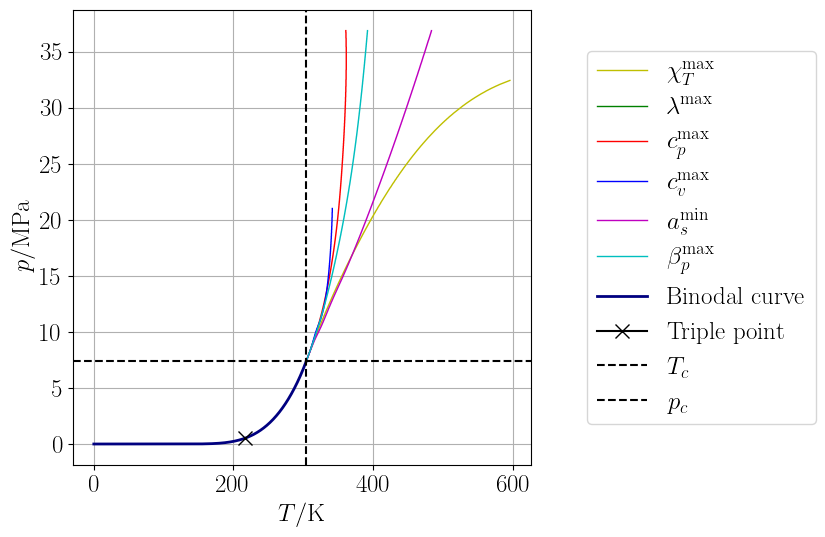

In [62]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
plt.plot(pts_T_khit[:-210],pts_p_khit[:-210]/1e6,c='y', lw=1,label=r'$\chi_T^{\mathrm{max}}$')
plt.plot(pts_T_lambda[:-2000],pts_p_lambda[:-2000]/1e6,c='g', lw=1,label=r'$\lambda^{\mathrm{max}}$')
plt.plot(pts_T_cp,pts_p_cp/1e6,c='r', lw=1,label=r'$c_p^{\mathrm{max}}$')
plt.plot(pts_T_cv[:-750],pts_p_cv[:-750]/1e6,c='b', lw=1,label=r'$c_v^{\mathrm{max}}$')
plt.plot(pts_T_as,pts_p_as/1e6,c='m', lw=1,label=r'$a_s^{\mathrm{min}}$')
plt.plot(pts_T_betap,pts_p_betap/1e6,c='c', lw=1,label=r'$\beta_p^{\mathrm{max}}$')
#plt.plot(T_vapor, p_vapor / 1e6, lw=2, ls='-',c='navy', label = 'Binodális')
#plt.plot(Tt, pt/1e6, marker='x', markersize=10, color='k', label='Hármas pont')
plt.plot(T_vapor, p_vapor / 1e6, lw=2, ls='-',c='navy', label = 'Binodal curve')
plt.plot(Tt, pt, marker='x', markersize=10, color='k', label='Triple point')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ p / \rm{MPa} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.axvline(x=Tc, color='k', linestyle='--', linewidth=1.5, label=f'$T_c$')
plt.axhline(y=Pc/1e6, color='k', linestyle='--', linewidth=1.5, label=f'$p_c$')
plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/lage_widom_empty.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()



In [63]:
print(IC_all_cases)

[[305.0], [7380000.0], 38.5]


In [64]:
#Ez a fenti diagram bezoomolása de mostmár erre van finom felbontású
# plt.figure(figsize=(40/2.54,30/2.54))

# plt.plot(pts_T_khit[:-210],pts_p_khit[:-210]/1e6,c='y', lw=2,label=" KhiT max")
# plt.plot(pts_T_lambda[:-2000],pts_p_lambda[:-2000]/1e6,c='g', lw=2,label=" Lambda max")
# plt.plot(pts_T_cp,pts_p_cp/1e6,c='r', lw=2,label=" Cp max")
# plt.plot(pts_T_cv[:-750],pts_p_cv[:-750]/1e6,c='b', lw=2,label=" Cv max")
# plt.plot(pts_T_as,pts_p_as/1e6,c='m', lw=2,label=" as min")
# plt.plot(pts_T_betap,pts_p_betap/1e6,c='c', lw=2,label=" Betap max")

# plt.plot(T_vapor, p_vapor / 1e6, lw=2, ls='-',c='navy', label = 'Binodal curve')
# plt.plot(Tt, pt, marker='x', markersize=10, color='k', label='Triple point')

# for i in range(len(IC_all_cases[0])):
#     plt.plot( T_all_cases[i][ : , int(19)  ],  p_all_cases[i]*1e-6 ,'k',label=f'NL') #int(Nx/2) int(Nx/3)
#     plt.plot( T_all_cases_lin[i][ : , int(19)  ]*Tc,  p_all_cases_lin[i]*Pc*1e-6 ,'k--',label=f'L') #int(Nx/2) int(Nx/3)

# plt.plot(312, 8.5, marker='x', markersize=10, color='k', label='Next IC')

# axes = plt.gca()
# plt.grid()

# plt.ylabel(r'$ p / \rm{MPa} $')
# plt.xlabel(r'$ T / \rm{K} $')

# plt.axvline(x=Tc, color='k', linestyle='--', linewidth=1.5, label='Tc')
# plt.axhline(y=Pc/1e6, color='k', linestyle='--', linewidth=1.5, label='Pc')
# plt.legend(loc='lower right')


# #BEZOOMOLÁS
# plt.xlim(290,350)
# plt.ylim(7,13)


# plt.show()



In [65]:
folder = "widom_ZOOM"

# dictionary to store loaded lists
widom_lists = {}

# loop through all .json files in the folder
for filename in tqdm(os.listdir(folder)):
    if filename.endswith(".json"):
        var_name = filename.replace(".json", "")
        file_path = os.path.join(folder, filename)
        with open(file_path, "r") as f:
            widom_lists[var_name] = json.load(f)
        print(f"Loaded {var_name} from {filename}")

# Example: access your lists
pts_T_cp_Z = widom_lists["pts_T_cp"]
pts_p_cp_Z = widom_lists["pts_p_cp"]
pts_T_cv_Z = widom_lists["pts_T_cv"]
pts_p_cv_Z = widom_lists["pts_p_cv"]
pts_T_as_Z = widom_lists["pts_T_as"]
pts_p_as_Z = widom_lists["pts_p_as"]
pts_T_lambda_Z = widom_lists["pts_T_lambda"]
pts_p_lambda_Z = widom_lists["pts_p_lambda"]
pts_T_betap_Z = widom_lists["pts_T_betap"]
pts_p_betap_Z = widom_lists["pts_p_betap"]
pts_T_khit_Z = widom_lists["pts_T_khit"]
pts_p_khit_Z = widom_lists["pts_p_khit"]


#print(type(T_all_cases_lin))  # should be <class 'list'>
#print(len(T_all_cases_lin))   # number of cases


  4%|▍         | 1/23 [00:07<02:54,  7.95s/it]

Loaded as_list from as_list.json


  9%|▊         | 2/23 [00:15<02:44,  7.83s/it]

Loaded betap_list from betap_list.json


 13%|█▎        | 3/23 [00:24<02:42,  8.14s/it]

...

Loaded pts_p_lambda from pts_p_lambda.json
Loaded pts_T_as from pts_T_as.json
Loaded pts_T_betap from pts_T_betap.json
Loaded pts_T_cp from pts_T_cp.json
Loaded pts_T_cv from pts_T_cv.json
Loaded pts_T_khit from pts_T_khit.json
Loaded pts_T_lambda from pts_T_lambda.json


 87%|████████▋ | 20/23 [00:51<00:02,  1.49it/s]

Loaded p_vapor from p_vapor.json


100%|██████████| 23/23 [01:00<00:00,  2.63s/it]

Loaded rho_list from rho_list.json
Loaded Tt from Tt.json
Loaded T_vapor from T_vapor.json


In [66]:
pts_T_khit_Z = np.array(pts_T_khit_Z, dtype=float)
pts_p_khit_Z = np.array(pts_p_khit_Z, dtype=float)
pts_T_lambda_Z= np.array(pts_T_lambda_Z, dtype=float)
pts_p_lambda_Z = np.array(pts_p_lambda_Z, dtype=float)
pts_T_cp_Z = np.array(pts_T_cp_Z, dtype=float)
pts_p_cp_Z = np.array(pts_p_cp_Z, dtype=float)
pts_T_cv_Z = np.array(pts_T_cv_Z, dtype=float)
pts_p_cv_Z = np.array(pts_p_cv_Z, dtype=float)
pts_T_as_Z = np.array(pts_T_as_Z, dtype=float)
pts_p_as_Z = np.array(pts_p_as_Z, dtype=float)
pts_T_betap_Z = np.array(pts_T_betap_Z, dtype=float)
pts_p_betap_Z = np.array(pts_p_betap_Z, dtype=float)


print(pts_T_khit_Z)
print(len(pts_T_khit_Z))

[304.55 304.55 304.6  ... 350.   350.   350.  ]
10000


## finer, zoomed in widom lines

<Figure size 1574.8x1181.1 with 0 Axes>

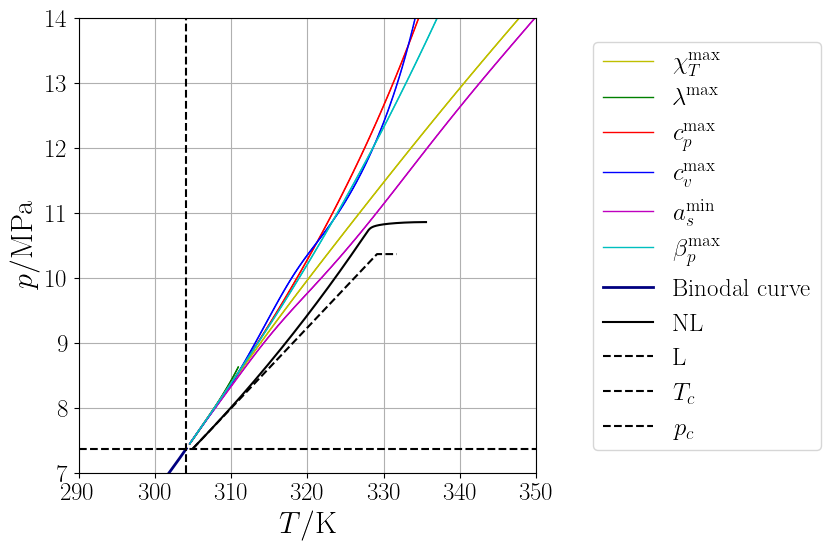

In [115]:

plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
plt.plot(pts_T_khit_Z,pts_p_khit_Z/1e6,c='y', lw=1,label=r'$\chi_T^{\mathrm{max}}$')
plt.plot(pts_T_lambda_Z[:-8430],pts_p_lambda_Z[:-8430]/1e6,c='g', lw=1,label=r'$\lambda^{\mathrm{max}}$')
plt.plot(pts_T_cp_Z,pts_p_cp_Z/1e6,c='r', lw=1,label=r'$c_p^{\mathrm{max}}$')
plt.plot(pts_T_cv_Z,pts_p_cv_Z/1e6,c='b', lw=1,label=r'$c_v^{\mathrm{max}}$')
plt.plot(pts_T_as_Z,pts_p_as_Z/1e6,c='m', lw=1,label=r'$a_s^{\mathrm{min}}$')
plt.plot(pts_T_betap_Z,pts_p_betap_Z/1e6,c='c', lw=1,label=r'$\beta_p^{\mathrm{max}}$')


plt.plot(T_vapor, p_vapor / 1e6, lw=2, ls='-',c='navy', label = 'Binodal curve')
#plt.plot(Tt, pt, marker='x', markersize=10, color='k', label='Triple point')

for i in range(len(IC_all_cases[0])):
    plt.plot( T_all_cases[i][ : , int(19)  ],  p_all_cases[i]*1e-6 ,'k',label=f'NL') #int(Nx/2) int(Nx/3)
    plt.plot( T_all_cases_lin[i][ : , int(19)  ]*Tc,  p_all_cases_lin[i]*Pc*1e-6 ,'k--',label=f'L') #int(Nx/2) int(Nx/3)

#plt.plot(312, 8.5, marker='x', markersize=10, color='k', label='(p0,T0)')

axes = plt.gca()
plt.grid()

plt.ylabel(r'$ p / \rm{MPa} $')
plt.xlabel(r'$ T / \rm{K} $')

plt.axvline(x=Tc, color='k', linestyle='--', linewidth=1.5, label=f'$T_c$')
plt.axhline(y=Pc/1e6, color='k', linestyle='--', linewidth=1.5, label=f'$p_c$')
plt.legend(loc='lower right')


#BEZOOMOLÁS
plt.xlim(290,350)
plt.ylim(7,14)
plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/small_widom_process.pdf", bbox_inches='tight')  # vector, best for LaTeX

plt.show()



## üres kicsi

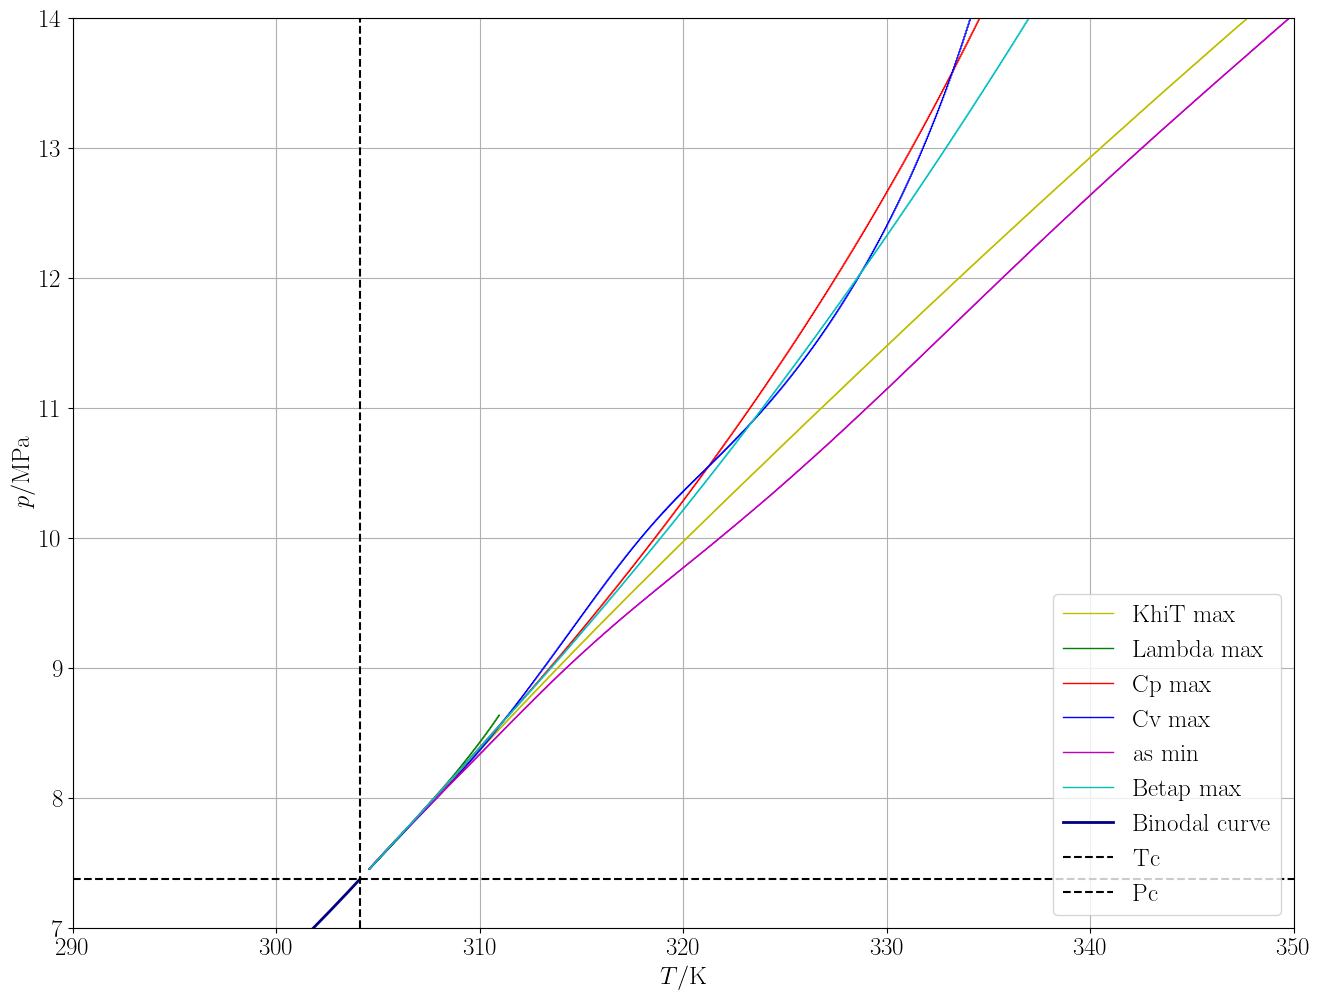

In [68]:

plt.figure(figsize=(40/2.54,30/2.54))

plt.plot(pts_T_khit_Z,pts_p_khit_Z/1e6,c='y', lw=1,label=" KhiT max")
plt.plot(pts_T_lambda_Z[:-8430],pts_p_lambda_Z[:-8430]/1e6,c='g', lw=1,label=" Lambda max")
plt.plot(pts_T_cp_Z,pts_p_cp_Z/1e6,c='r', lw=1,label=" Cp max")
plt.plot(pts_T_cv_Z,pts_p_cv_Z/1e6,c='b', lw=1,label=" Cv max")
plt.plot(pts_T_as_Z,pts_p_as_Z/1e6,c='m', lw=1,label=" as min")
plt.plot(pts_T_betap_Z,pts_p_betap_Z/1e6,c='c', lw=1,label=" Betap max")

plt.plot(T_vapor, p_vapor / 1e6, lw=2, ls='-',c='navy', label = 'Binodal curve')
#plt.plot(Tt, pt, marker='x', markersize=10, color='k', label='Triple point')

#plt.plot(312, 8.5, marker='x', markersize=10, color='k', label='(p0,T0)')

axes = plt.gca()
plt.grid()

plt.ylabel(r'$ p / \rm{MPa} $')
plt.xlabel(r'$ T / \rm{K} $')

plt.axvline(x=Tc, color='k', linestyle='--', linewidth=1.5, label='Tc')
plt.axhline(y=Pc/1e6, color='k', linestyle='--', linewidth=1.5, label='Pc')
plt.legend(loc='lower right')


#BEZOOMOLÁS
plt.xlim(290,350)
plt.ylim(7,14)


plt.show()



## saját 'widom' görbék

In [69]:


folder = "widom_ZOOM" 

# dictionary to store loaded lists
loaded_lists = {}

# loop through all .json files in the folder
for filename in tqdm(os.listdir(folder)):
    if filename.endswith(".json"):
        var_name = filename.replace(".json", "")
        file_path = os.path.join(folder, filename)
        with open(file_path, "r") as f:
            loaded_lists[var_name] = json.load(f)
        print(f"Loaded {var_name} from {filename}")

# Example: access your lists
rho_list = loaded_lists["rho_list"]
as_list = loaded_lists["as_list"]
cp_list = loaded_lists["cp_list"]
cv_list = loaded_lists["cv_list"]
khit_list = loaded_lists["khit_list"]
betap_list = loaded_lists["betap_list"]
lambda_list = loaded_lists["lambda_list"]

print(type(rho_list))  # should be <class 'list'>
print(len(rho_list))   # 


rho_list = [np.array(case) for case in rho_list]
cp_list = [np.array(case) for case in cp_list]
cv_list = [np.array(case) for case in cv_list]
as_list = [np.array(case) for case in as_list]
betap_list = [np.array(case) for case in betap_list]
khit_list = [np.array(case) for case in khit_list]
lambda_list = [np.array(case) for case in lambda_list]


  4%|▍         | 1/23 [00:08<03:01,  8.27s/it]

Loaded as_list from as_list.json


  9%|▊         | 2/23 [00:16<02:58,  8.49s/it]

Loaded betap_list from betap_list.json


 13%|█▎        | 3/23 [00:25<02:49,  8.47s/it]

...

Loaded khit_list from khit_list.json


 26%|██▌       | 6/23 [00:52<02:27,  8.69s/it]

Loaded lambda_list from lambda_list.json
Loaded pt from pt.json
Loaded pts_p_as from pts_p_as.json
Loaded pts_p_betap from pts_p_betap.json
Loaded pts_p_cp from pts_p_cp.json
Loaded pts_p_cv from pts_p_cv.json
Loaded pts_p_khit from pts_p_khit.json
Loaded pts_p_lambda from pts_p_lambda.json
Loaded pts_T_as from pts_T_as.json
Loaded pts_T_betap from pts_T_betap.json
Loaded pts_T_cp from pts_T_cp.json
Loaded pts_T_cv from pts_T_cv.json
Loaded pts_T_khit from pts_T_khit.json
Loaded pts_T_lambda from pts_T_lambda.json
Loaded p_vapor from p_vapor.json


100%|██████████| 23/23 [01:00<00:00,  2.62s/it]

Loaded rho_list from rho_list.json
Loaded Tt from Tt.json
Loaded T_vapor from T_vapor.json
<class 'list'>
10000


In [70]:
print(len(rho_list))  
print(len(rho_list[0]))  

10000
911


In [71]:
NT = int((350 - 304.5)/0.05) + 1 #int((400 - 304.5)/0.1) + 1  
     #ezt majd a szuperszámítógépen érdemes lenne lefuttatni finomabb felsoztásban pl 0.1
Np = 10000
pW = np.linspace(1.01*Pc, 15e6, Np) #5*Pc  Tehát megpróbálom kitágítani a tartományt
TW = np.linspace(304.5, 350,  NT) #el lethetne szeparálni T és p grid struktúráját pl 0.1K és 0.05pc lépésként megadni inkább

nwat_1W = np.zeros((len(rho_list), len(rho_list[i])))
nwat_2W = np.zeros((len(rho_list), len(rho_list[i])))
nwat_3W = np.zeros((len(rho_list), len(rho_list[i])))
alphaW = np.zeros((len(rho_list), len(rho_list[i])))

for j in tqdm(range(len(rho_list))):
    for i in range(len(rho_list[i])):
        nwat_1W[j,i] = TW[i] / rho_list[j][i] * (betap_list[j][i]*as_list[j][i]/cp_list[j][i])**2

        nwat_2W[j,i] = betap_list[j][i] * as_list[j][i]**2 / cp_list[j][i]

        nwat_3W[j,i] = 1 / (rho_list[j][i]*cv_list[j][i])

        alphaW[j,i]  = lambda_list[j][i] / (rho_list[j][i] * cp_list[j][i] ) 

100%|██████████| 10000/10000 [00:57<00:00, 174.43it/s]


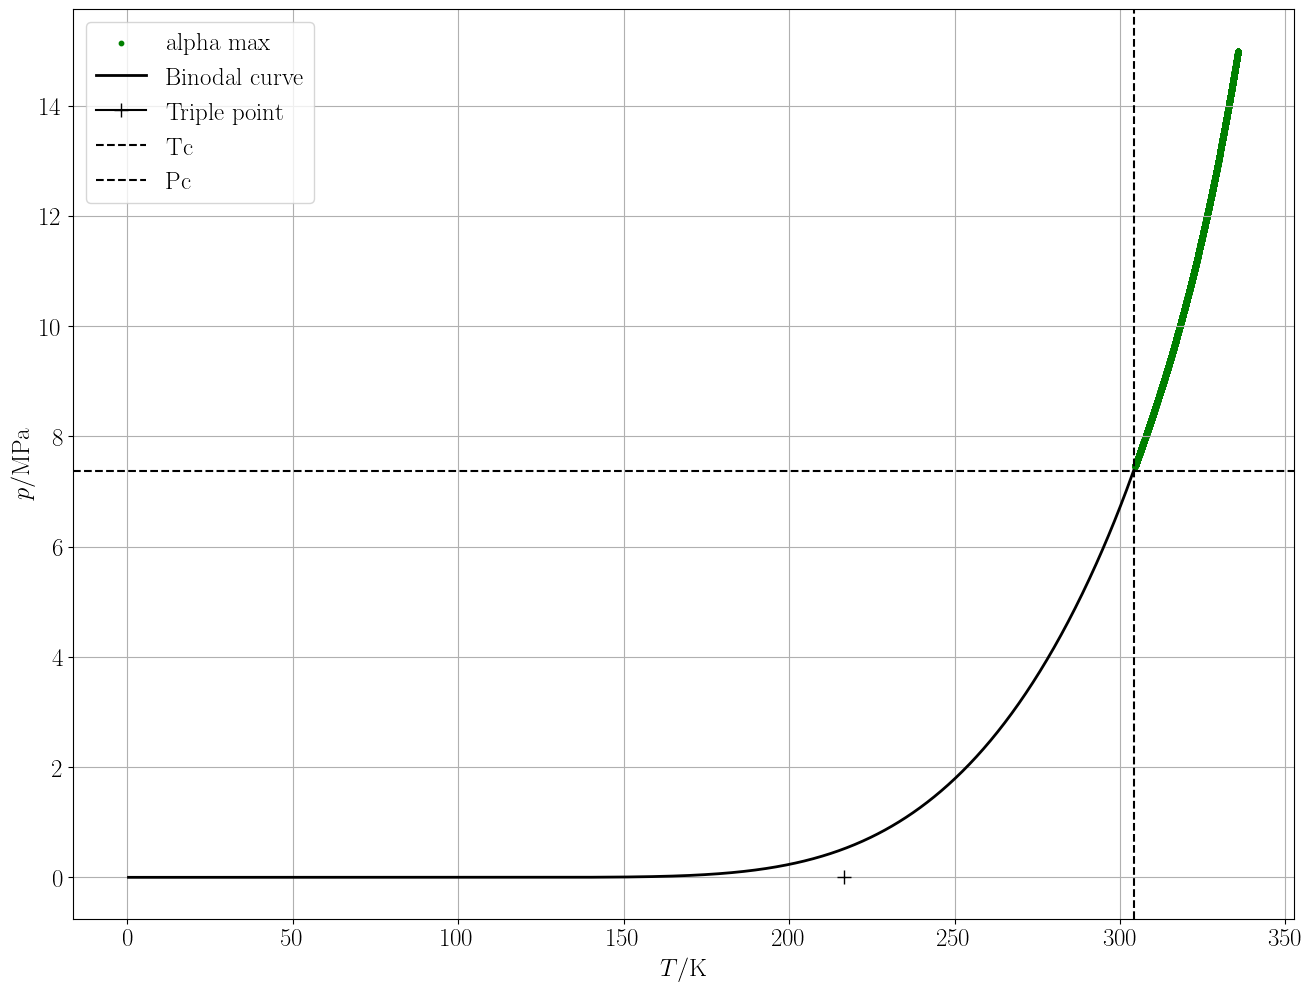

In [72]:
pts_T_alphaW = np.zeros(len(rho_list))
pts_p_alphaW = np.zeros(len(rho_list))
#als_alphaW  = np.zeros(len(rho_list))

for j in range(len(rho_list)):
    i = np.argmin(np.abs(alphaW[j])) 
    pts_T_alphaW[j] = TW[i]
    pts_p_alphaW[j] = pW[j]
    #pts_T_alphaW[j]  = Lambda_result[j, i]

plt.figure(figsize=(40/2.54,30/2.54))

plt.scatter(pts_T_alphaW,pts_p_alphaW/1e6,c='g', s=10,label=" alpha max")
plt.plot(T_vapor, p_vapor / 1e6, lw=2, ls='-',c='k', label = 'Binodal curve')
plt.plot(Tt, pt/1e6, marker='+', markersize=10, color='k', label='Triple point')

axes = plt.gca()
plt.grid()

plt.ylabel(r'$ p / \rm{MPa} $')
plt.xlabel(r'$ T / \rm{K} $')

plt.axvline(x=Tc, color='k', linestyle='--', linewidth=1.5, label='Tc')
plt.axhline(y=Pc/1e6, color='k', linestyle='--', linewidth=1.5, label='Pc')
plt.legend(loc='upper left')

#plt.xlim(300,305)

plt.show()




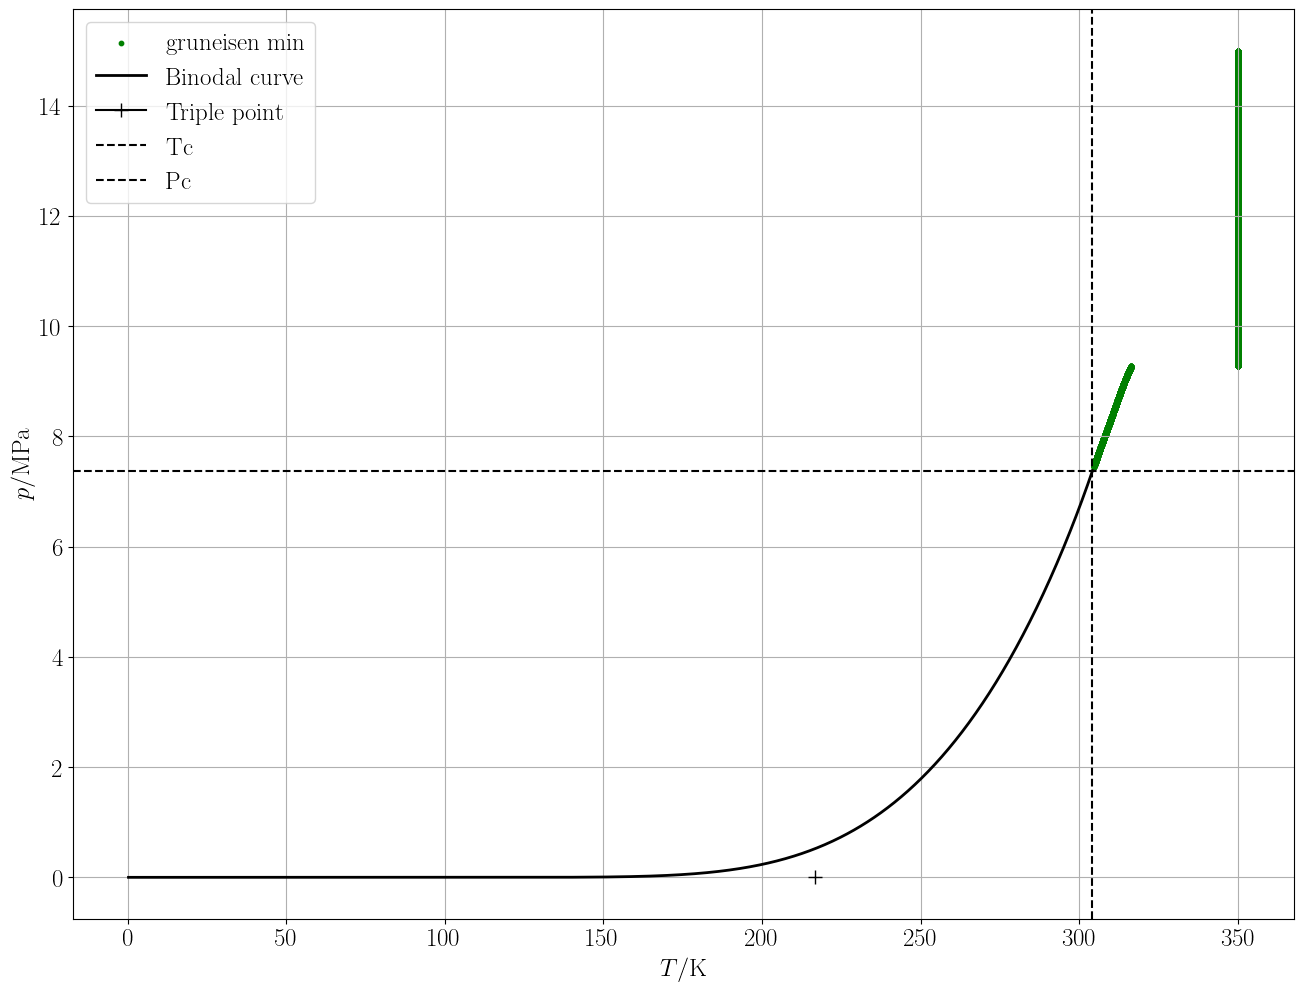

In [73]:
pts_T_gruneisenW = np.zeros(len(rho_list))
pts_p_gruneisenW = np.zeros(len(rho_list))
#als_alphaW  = np.zeros(len(rho_list))

for j in range(len(rho_list)):
    i = np.argmin(np.abs(nwat_2W[j])) 
    pts_T_gruneisenW[j] = TW[i]
    pts_p_gruneisenW[j] = pW[j]
    #pts_T_alphaW[j]  = Lambda_result[j, i]

plt.figure(figsize=(40/2.54,30/2.54))

plt.scatter(pts_T_gruneisenW,pts_p_gruneisenW/1e6,c='g', s=10,label=" gruneisen min")
plt.plot(T_vapor, p_vapor / 1e6, lw=2, ls='-',c='k', label = 'Binodal curve')
plt.plot(Tt, pt/1e6, marker='+', markersize=10, color='k', label='Triple point')

axes = plt.gca()
plt.grid()

plt.ylabel(r'$ p / \rm{MPa} $')
plt.xlabel(r'$ T / \rm{K} $')

plt.axvline(x=Tc, color='k', linestyle='--', linewidth=1.5, label='Tc')
plt.axhline(y=Pc/1e6, color='k', linestyle='--', linewidth=1.5, label='Pc')
plt.legend(loc='upper left')

#plt.xlim(300,305)

plt.show()




In [74]:
def second_derivative_non_uniform(x, y):
    d2y = np.zeros_like(y)
    # Computation for internal points
    for i in range(1, len(y) - 1):
        h_minus = x[i] - x[i-1]
        h_plus = x[i+1] - x[i]
        
        fwd_slope = (y[i+1] - y[i]) / h_plus
        bwd_slope = (y[i] - y[i-1]) / h_minus
        
        d2y[i] = 2 * (fwd_slope - bwd_slope) / (h_plus + h_minus)
        
    return d2y

In [75]:
y = np.array([[1.5, 2.0], 
              [3.5, 4.0], 
              [5.5, 6.0]])
print(len(y))
for j in tqdm(range(len(y))):
    #for i in range(len(proba[i])):
   d2proba= second_derivative_non_uniform(TW,y[j]) 

print(d2proba)

3


100%|██████████| 3/3 [00:00<?, ?it/s]

[0. 0.]


In [76]:
d2nwat1 = np.zeros((len(rho_list), len(rho_list[i])))

for j in tqdm(range(len(rho_list))):
    #for i in range(len(rho_list[i])):
   d2nwat1[j,:] = second_derivative_non_uniform(TW,nwat_1W[j]) 



100%|██████████| 10000/10000 [00:32<00:00, 311.57it/s]


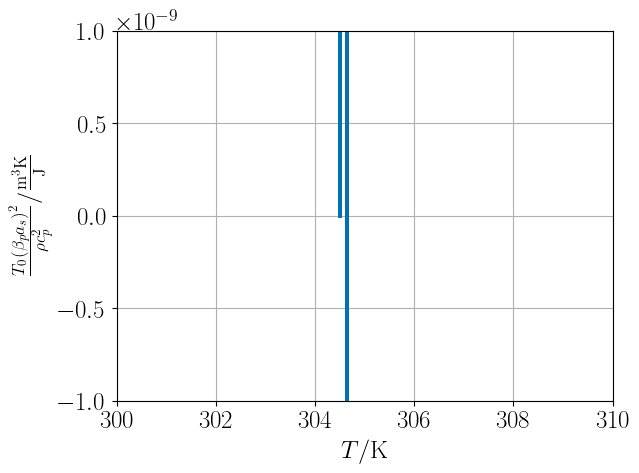

In [77]:
for i in range(len(TW)-1):
    plt.plot(TW,d2nwat1[10],lw=2,ls='-',color = rainbow[0])
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \frac{T_0(\beta_p a_s)^2}{\rho c_p^2}   \rm{  /  \frac{m^3 K}{J}}  $')
plt.xlabel(r'$ T / \rm{K} $')
plt.ylim(-0.000000001,0.000000001)
plt.xlim(300,310)
plt.show()

100%|██████████| 10000/10000 [00:01<00:00, 8037.26it/s]


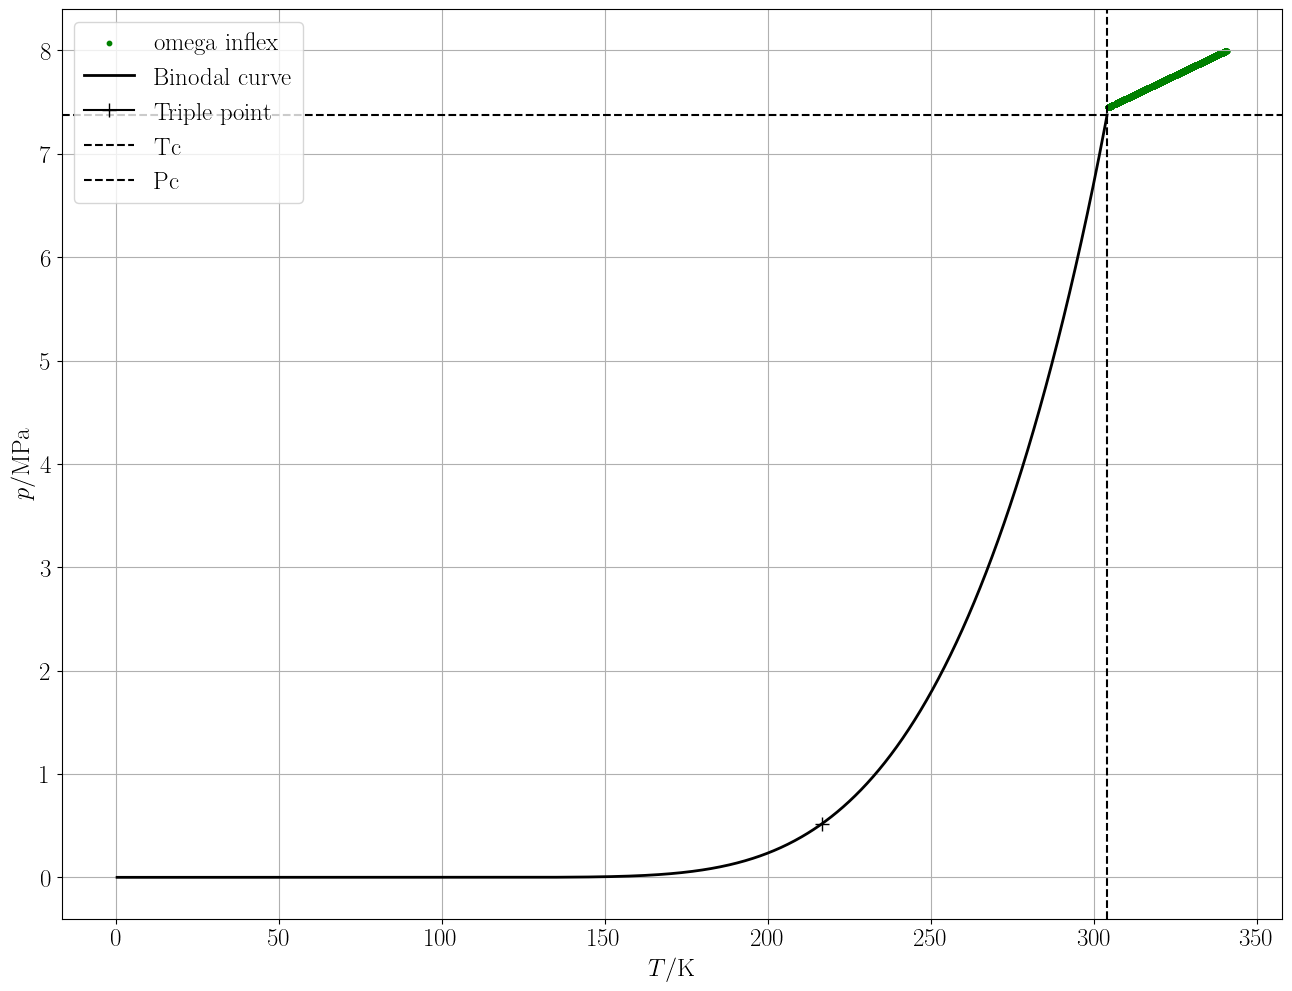

In [78]:
pts_T_d2nwat1 = np.zeros(len(rho_list))
pts_p_d2nwat1 = np.zeros(len(rho_list))

for j in tqdm(range(len(rho_list))):
    # 1. Grab the row of data (the derivative)
    # CHANGE 'd2nwat1' to 'nwat_2W' below if that is your intended variable
    y_data = d2nwat1[j,1:] 
    
    # 2. Find where the sign flips (returns indices where sign changes)
    # This identifies the interval [i, i+1] where the zero exists
    crossings = np.where(np.diff(np.sign(y_data)))[0]
    #print(crossings)
    pts_T_d2nwat1[j] = TW[crossings[0]]

    pts_p_d2nwat1[j] = pW[crossings[0]]

plt.figure(figsize=(40/2.54,30/2.54))

plt.scatter(pts_T_d2nwat1,pts_p_d2nwat1/1e6,c='g', s=10,label=" omega inflex")
plt.plot(T_vapor, p_vapor /1e6, lw=2, ls='-',c='k', label = 'Binodal curve')
plt.plot(Tt, pt, marker='+', markersize=10, color='k', label='Triple point')

axes = plt.gca()
plt.grid()

plt.ylabel(r'$ p / \rm{MPa} $')
plt.xlabel(r'$ T / \rm{K} $')

plt.axvline(x=Tc, color='k', linestyle='--', linewidth=1.5, label='Tc')
plt.axhline(y=Pc/1e6, color='k', linestyle='--', linewidth=1.5, label='Pc')
plt.legend(loc='upper left')

#plt.xlim(300,305)

plt.show()


100%|██████████| 10000/10000 [00:21<00:00, 465.49it/s]


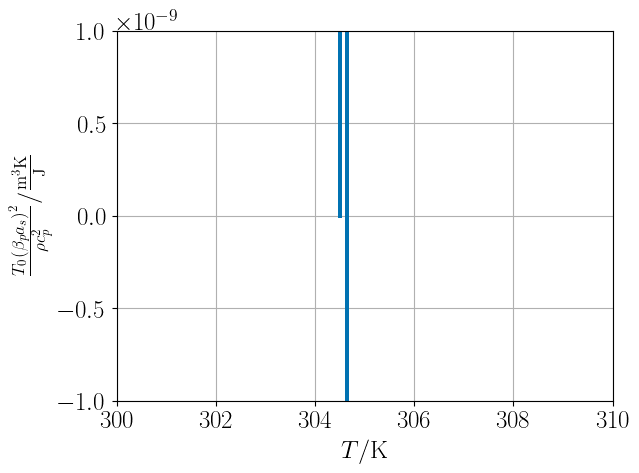

In [79]:
d2nwat3 = np.zeros((len(rho_list), len(rho_list[i])))

for j in tqdm(range(len(rho_list))):
    #for i in range(len(rho_list[i])):
   d2nwat3[j,:] = second_derivative_non_uniform(TW,nwat_3W[j]) 

for i in range(len(TW)-1):
    plt.plot(TW,d2nwat3[10],lw=2,ls='-',color = rainbow[0])
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \frac{T_0(\beta_p a_s)^2}{\rho c_p^2}   \rm{  /  \frac{m^3 K}{J}}  $')
plt.xlabel(r'$ T / \rm{K} $')
plt.ylim(-0.000000001,0.000000001)
plt.xlim(300,310)
plt.show()

100%|██████████| 10000/10000 [00:00<00:00, 33821.79it/s]


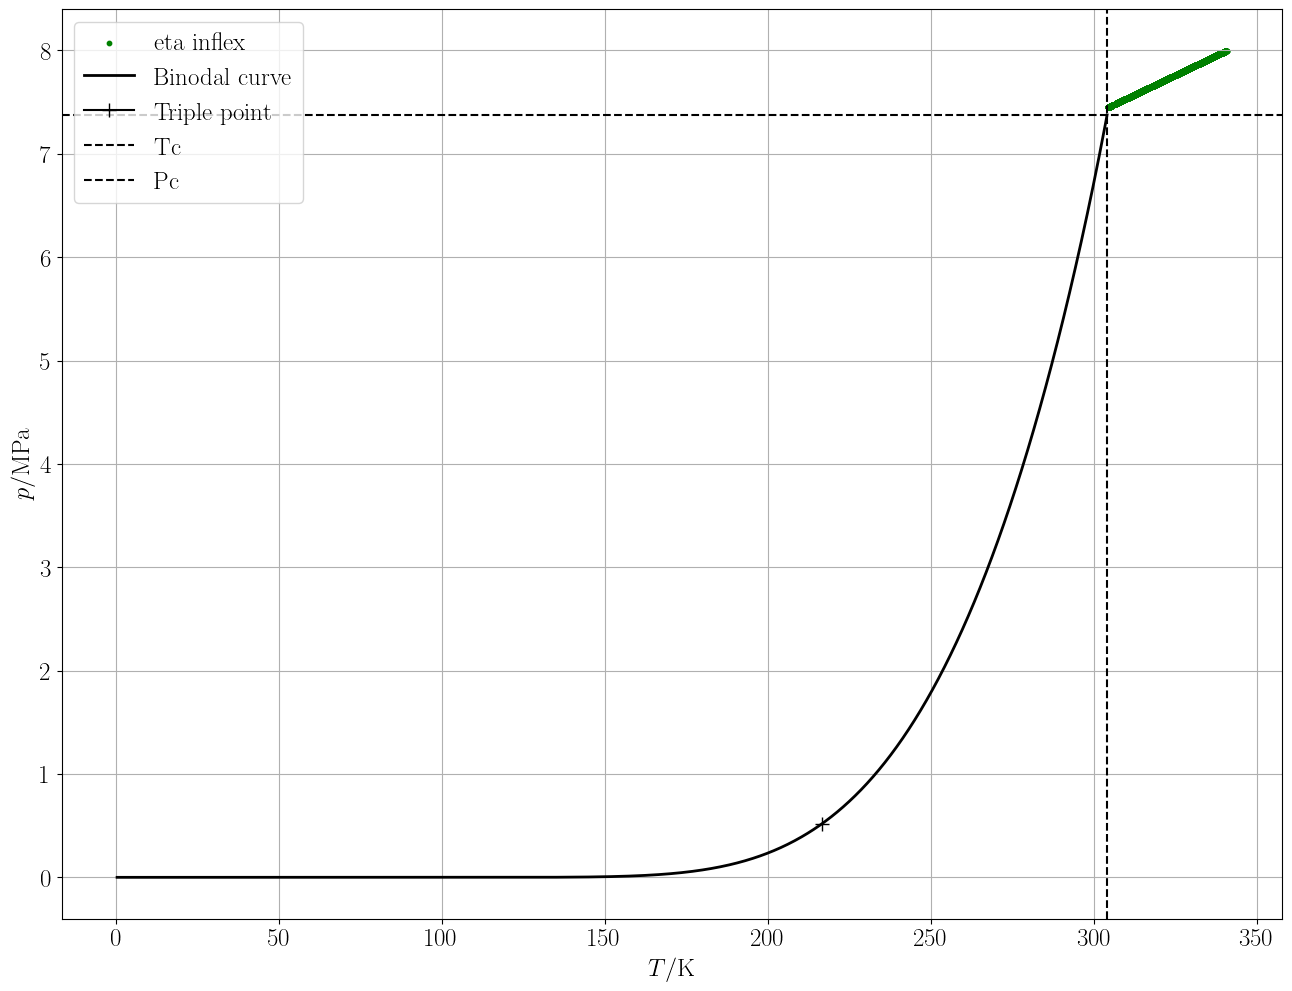

In [80]:
pts_T_d2nwat3 = np.zeros(len(rho_list))
pts_p_d2nwat3 = np.zeros(len(rho_list))

for j in tqdm(range(len(rho_list))):
    # 1. Grab the row of data (the derivative)
    # CHANGE 'd2nwat1' to 'nwat_2W' below if that is your intended variable
    y_data = d2nwat3[j,1:] 
    
    # 2. Find where the sign flips (returns indices where sign changes)
    # This identifies the interval [i, i+1] where the zero exists
    crossings = np.where(np.diff(np.sign(y_data)))[0]
    #print(crossings)
    pts_T_d2nwat3[j] = TW[crossings[0]]

    pts_p_d2nwat3[j] = pW[crossings[0]]

plt.figure(figsize=(40/2.54,30/2.54))

plt.scatter(pts_T_d2nwat1,pts_p_d2nwat1/1e6,c='g', s=10,label=" eta inflex")
plt.plot(T_vapor, p_vapor /1e6, lw=2, ls='-',c='k', label = 'Binodal curve')
plt.plot(Tt, pt, marker='+', markersize=10, color='k', label='Triple point')

axes = plt.gca()
plt.grid()

plt.ylabel(r'$ p / \rm{MPa} $')
plt.xlabel(r'$ T / \rm{K} $')

plt.axvline(x=Tc, color='k', linestyle='--', linewidth=1.5, label='Tc')
plt.axhline(y=Pc/1e6, color='k', linestyle='--', linewidth=1.5, label='Pc')
plt.legend(loc='upper left')

#plt.xlim(300,305)

plt.show()


### vegleges sajat gorbek

<Figure size 1574.8x1181.1 with 0 Axes>

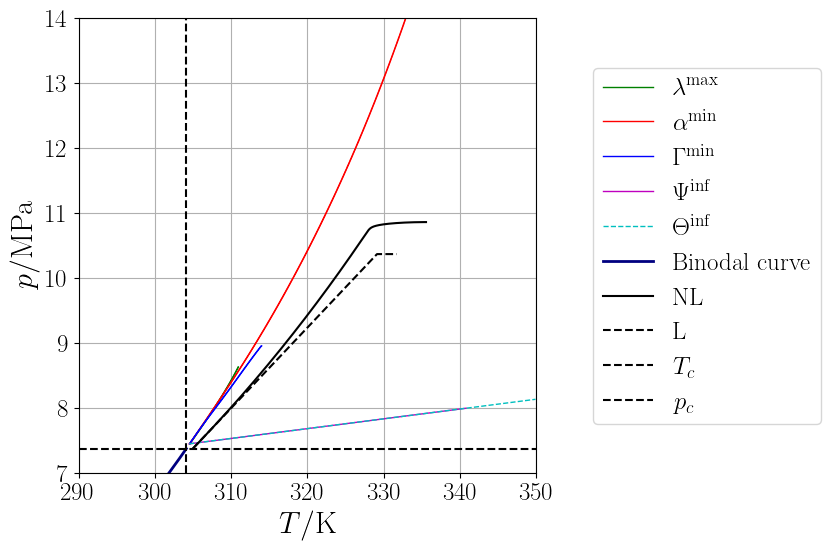

In [116]:

plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
plt.plot(pts_T_lambda_Z[:-8430],pts_p_lambda_Z[:-8430]/1e6,c='g', lw=1,label=r'$\lambda^{\mathrm{max}}$')
plt.plot(pts_T_alphaW,pts_p_alphaW/1e6,c='r', lw=1,label=r'$\alpha^{\mathrm{min}}$')
plt.plot(pts_T_gruneisenW[:-8000],pts_p_gruneisenW[:-8000]/1e6,c='b', lw=1,label=r'$\Gamma^{\mathrm{min}}$')
plt.plot(pts_T_d2nwat1,pts_p_d2nwat1/1e6,c='m', lw=1,label=r'$\Psi^{\mathrm{inf}}$')
plt.plot(pts_T_d2nwat3,pts_p_d2nwat3/1e6,c='c', lw=1,linestyle='--',label=r'$\Theta^{\mathrm{inf}}$')


plt.plot(T_vapor, p_vapor / 1e6, lw=2, ls='-',c='navy', label = 'Binodal curve')
#plt.plot(Tt, pt, marker='x', markersize=10, color='k', label='Triple point')

for i in range(len(IC_all_cases[0])):
    plt.plot( T_all_cases[i][ : , int(19)  ],  p_all_cases[i]*1e-6 ,'k',label=f'NL') #int(Nx/2) int(Nx/3)
    plt.plot( T_all_cases_lin[i][ : , int(19)  ]*Tc,  p_all_cases_lin[i]*Pc*1e-6 ,'k--',label=f'L') #int(Nx/2) int(Nx/3)

#plt.plot(312, 8.5, marker='x', markersize=10, color='k', label='(p0,T0)')

axes = plt.gca()
plt.grid()

plt.ylabel(r'$ p / \rm{MPa} $')
plt.xlabel(r'$ T / \rm{K} $')

plt.axvline(x=Tc, color='k', linestyle='--', linewidth=1.5, label=f'$T_c$')
plt.axhline(y=Pc/1e6, color='k', linestyle='--', linewidth=1.5, label=f'$p_c$')
plt.legend(loc='lower right')


#BEZOOMOLÁS
plt.xlim(290,350)
plt.ylim(7,14)
plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/small_widom_nwat.pdf", bbox_inches='tight')  # vector, best for LaTeX

plt.show()

# Chapter 4 - Rainbow Plots

## rainbow nwat

In [18]:
cbforange = (230/255, 159/255, 0/255)
cbfmagenta = (204/255, 121/255, 167/255)
cbfyellow = (240/255, 228/255, 66/255)
cbflightblue = (86/255, 180/255, 233/255)
cbfgreen = (0/255, 158/255, 115/255)
cbfblue = (0/255, 114/255, 178/255) 
cbfred = (213/255, 94/255, 0/255)
cbfred_dark = (160/255, 45/255, 55/255)#(178/255, 76/255, 0/255)

rainbow = [cbfblue,cbflightblue,cbfgreen,cbforange,cbfred,cbfred_dark] #,cbfyellow
greys   = [(229/255, 228/255, 226/255),(192/255, 192/255, 192/255),(169/255, 169/255, 169/255),(128/255, 128/255, 128/255),(0,0,0)]
greys = [
    (229/255, 228/255, 226/255),  # very light grey
    (192/255, 192/255, 192/255),  # light grey
    (169/255, 169/255, 169/255),  # mid-light grey
    (150/255, 150/255, 150/255),  # NEW: medium grey
    (128/255, 128/255, 128/255),  # mid-dark grey
    (0/255,   0/255,   0/255)     # black
]

In [4]:
pp        =  [ 7.38e6,  1.05 * Pc , 1.10 * Pc ,1.15 * Pc , 1.2 * Pc, 1.25 *Pc] 
N = int((486 - 270)/0.1) + 1
T         = np.linspace(270, 486,  N)
rho_result = np.zeros((len(pp), len(T)))


for j in tqdm(range(0,len(pp))):
    rho_guess  = Rhoc  # starting point
    for i in range(0,len(T)):
        try:
            rho_result[j,len(T)-1-i] = newton(
                density_from_pressure,
                rho_guess,
                args=(T[len(T)-1-i], pp[j]),
                tol=1e-1,
                maxiter=5000
            )
        except RuntimeError:
            # Fallback: if Newton fails, try a small perturbation
            rho_result[j,len(T)-1-i] = newton(
                density_from_pressure,
                rho_guess * 1.05,
                args=(T[len(T)-1-i], pp[j]),
                tol=1e-1,
                maxiter=5000
            )
        rho_guess = rho_result[j,len(T)-1-i]

cp_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        cp_result[j,i] = get_cp(T[i],rho_result[j,i])

cv_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        cv_result[j,i] = get_cv(T[i],rho_result[j,i])

lambda_result= np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        lambda_result[j,i] = thermal_conductivity(T[i],rho_result[j,i])

a_s_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        a_s_result[j,i] = speed_of_sound(T[i],rho_result[j,i])

mu_JT_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        mu_JT_result[j,i] = joule_thompson(T[i],rho_result[j,i])

Beta_p_result = np.zeros((len(pp), len(T)))

for j in range(len(pp)):
    for i in range(len(T)):
        Beta_p_result[j,i] = ( mu_JT_result[j,i] * cp_result[j,i] * rho_result[j,i] + 1 ) / T[i]

Khi_T_as = np.zeros((len(pp), len(T)))

for j in range(len(pp)):
    for i in range(len(T)):
        Khi_T_as[j,i] = cp_result[j,i] / ( cv_result[j,i] * rho_result[j,i] * a_s_result[j,i]**2 )



Plot_1 = np.zeros((len(pp), len(T)))
Plot_2 = np.zeros((len(pp), len(T)))
Plot_3 = np.zeros((len(pp), len(T)))

for j in range(len(pp)):
    for i in range(len(T)):
        Plot_1[j,i] = T[i] / rho_result[j,i] * (Beta_p_result[j,i]*a_s_result[j,i]/cp_result[j,i])**2

        Plot_2[j,i] = Beta_p_result[j,i] * a_s_result[j,i]**2 / cp_result[j,i]

        Plot_3[j,i] = 1 / (rho_result[j,i]*cv_result[j,i])


alpha_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        alpha_result[j,i] = lambda_result[j,i] / (rho_result[j,i] * cp_result[j,i] ) 

alpha_as= np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        alpha_as[j,i] = alpha_result[j,i] / a_s_result[j,i]

  0%|          | 0/6 [00:00<?, ?it/s]

C:\Users\krist\AppData\Local\Temp\ipykernel_11936\4131403098.py:171: RuntimeWarning: invalid value encountered in log
  Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum
100%|██████████| 6/6 [00:11<00:00,  1.99s/it]


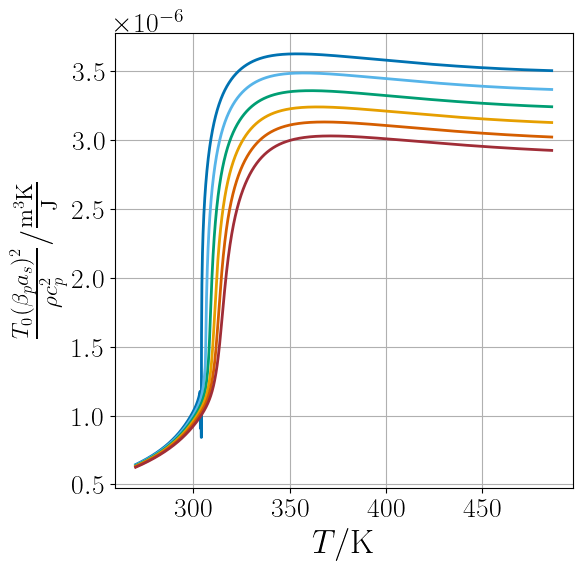

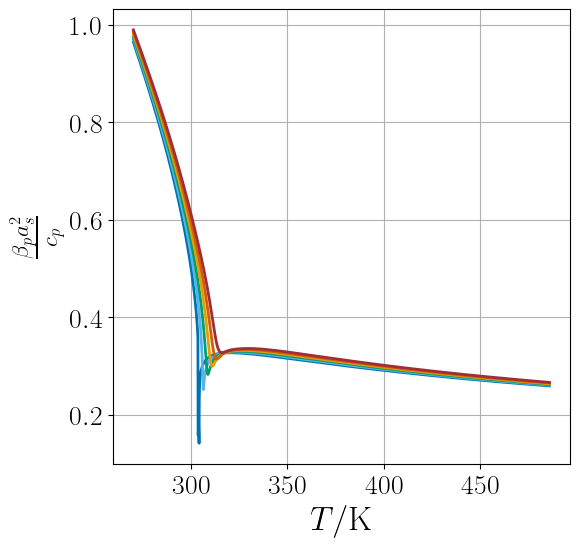

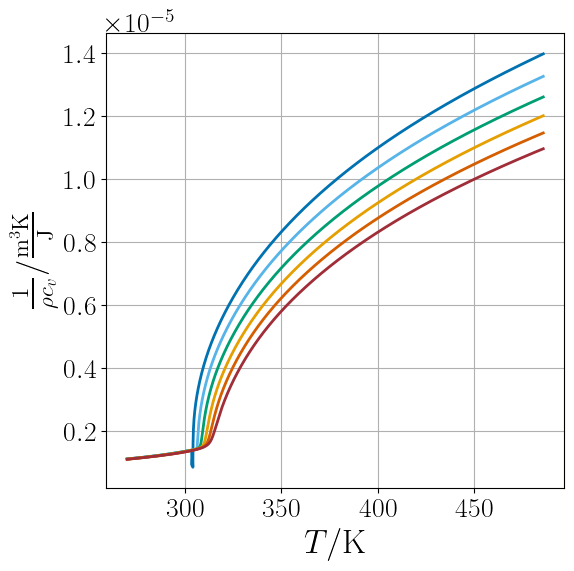

In [12]:
plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,Plot_1[i],lw=2,ls='-',color = rainbow[i], label = f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \frac{T_0(\beta_p a_s)^2}{\rho c_p^2}   \rm{  /  \frac{m^3 K}{J}}  $')
plt.xlabel(r'$ T / \rm{K} $')
#plt.legend(loc='lower right')
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/nwat1_rainbow.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,Plot_2[i],lw=2,ls='-',color = rainbow[i], label = f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
#plt.xlim(300,350)
#plt.ylim(0.2, 0.4)
plt.ylabel(r'$ \frac{\beta_p a_s^2}{  c_p } $')
plt.xlabel(r'$ T / \rm{K} $')
#plt.legend(loc='lower right')
#plt.savefig("D:/School/7. Félév/JCAM cikk/figs/nwat2_rainbow_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/nwat2_rainbow.pdf", bbox_inches='tight') 
plt.show()

plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(pp)):
    plt.plot(T,Plot_3[i],lw=2,ls='-',color = rainbow[i], label = f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$\frac{ 1 } {\rho c_v} \rm{  /  \frac{m^3 K}{J}}$')
plt.xlabel(r'$ T / \rm{K} $')
#plt.legend(loc='lower right')
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/nwat3_rainbow.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()


## Rainbow mat. props.

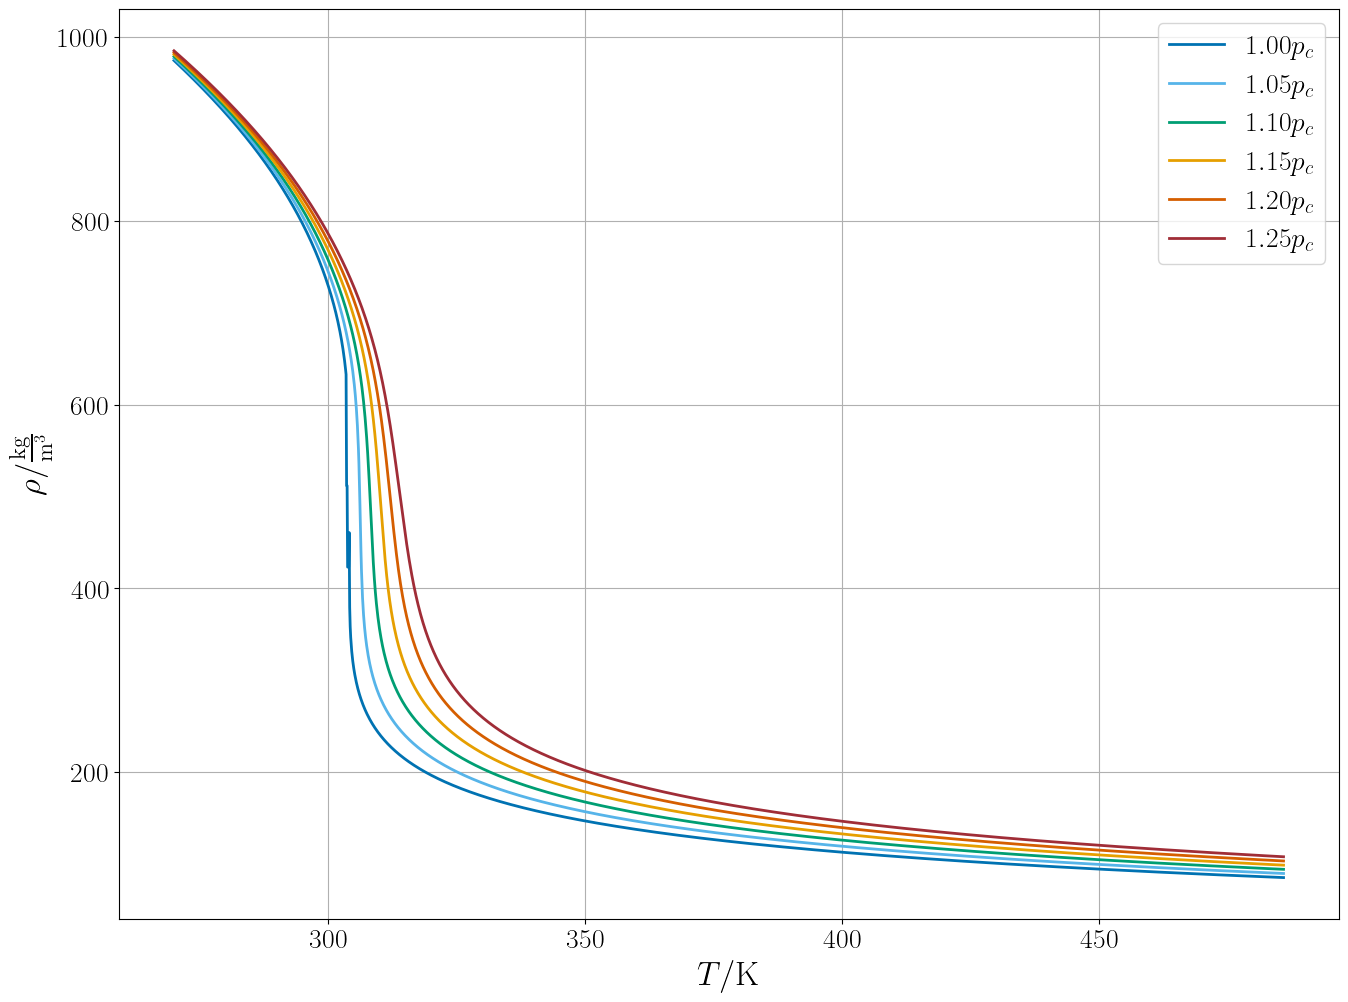

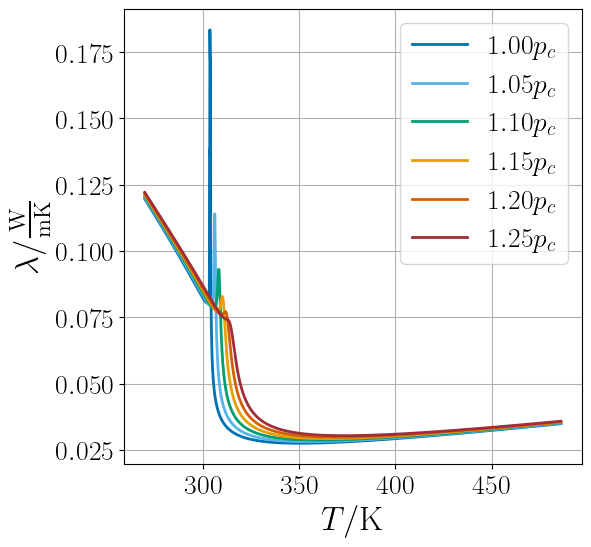

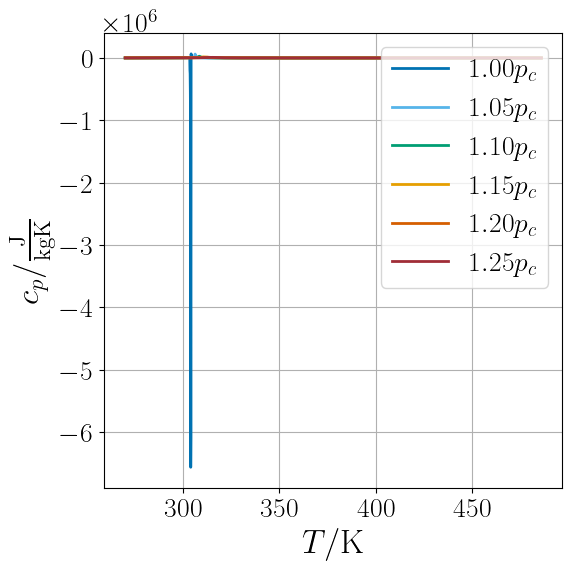

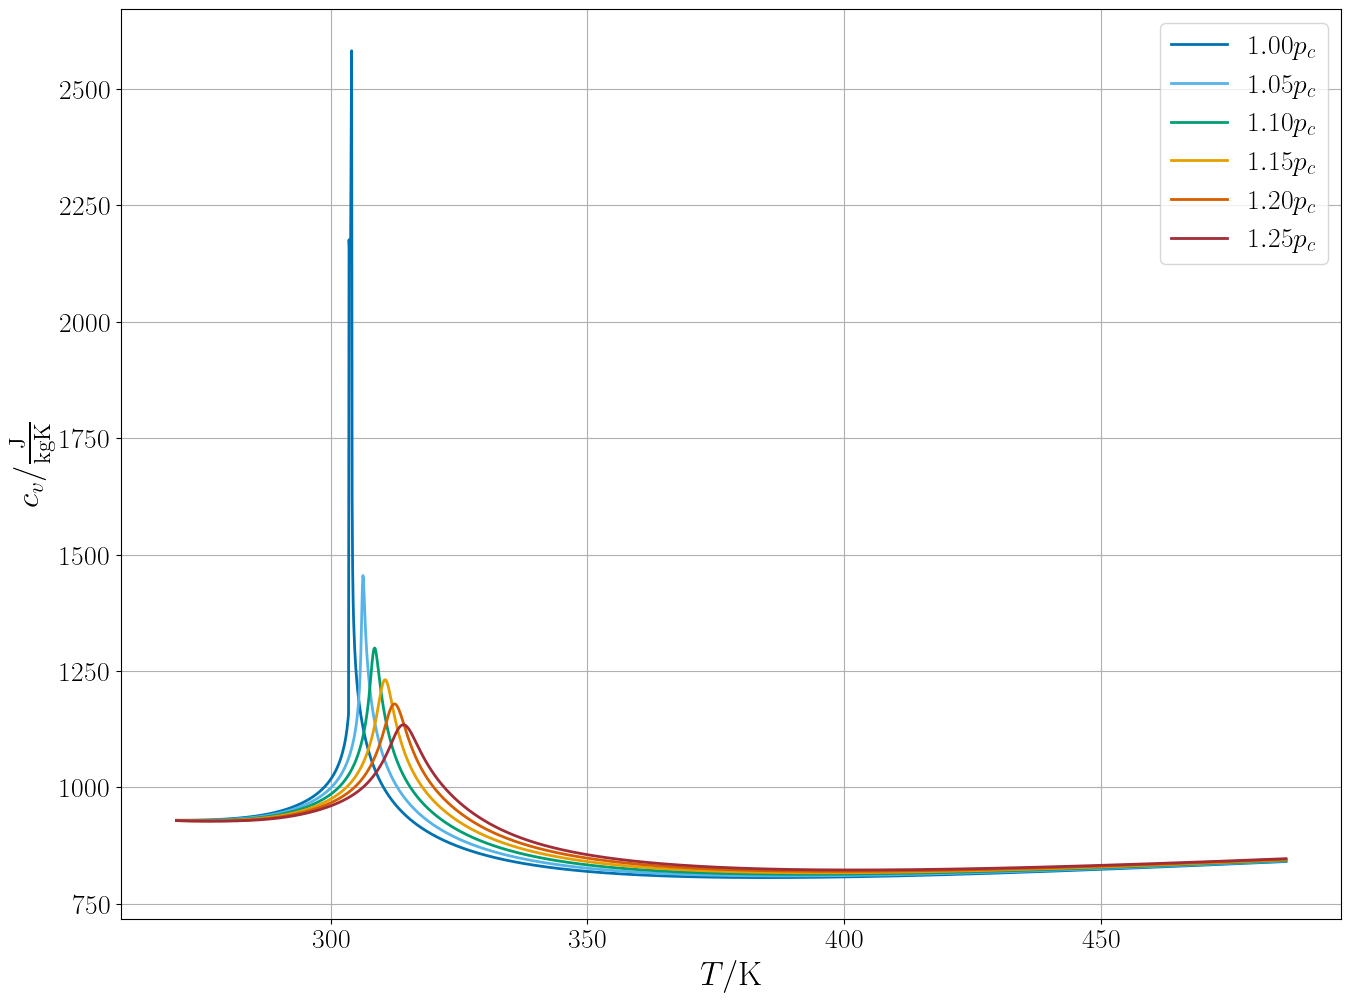

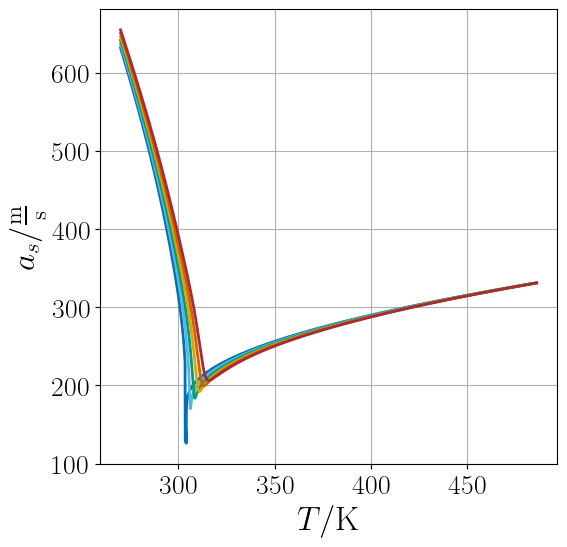

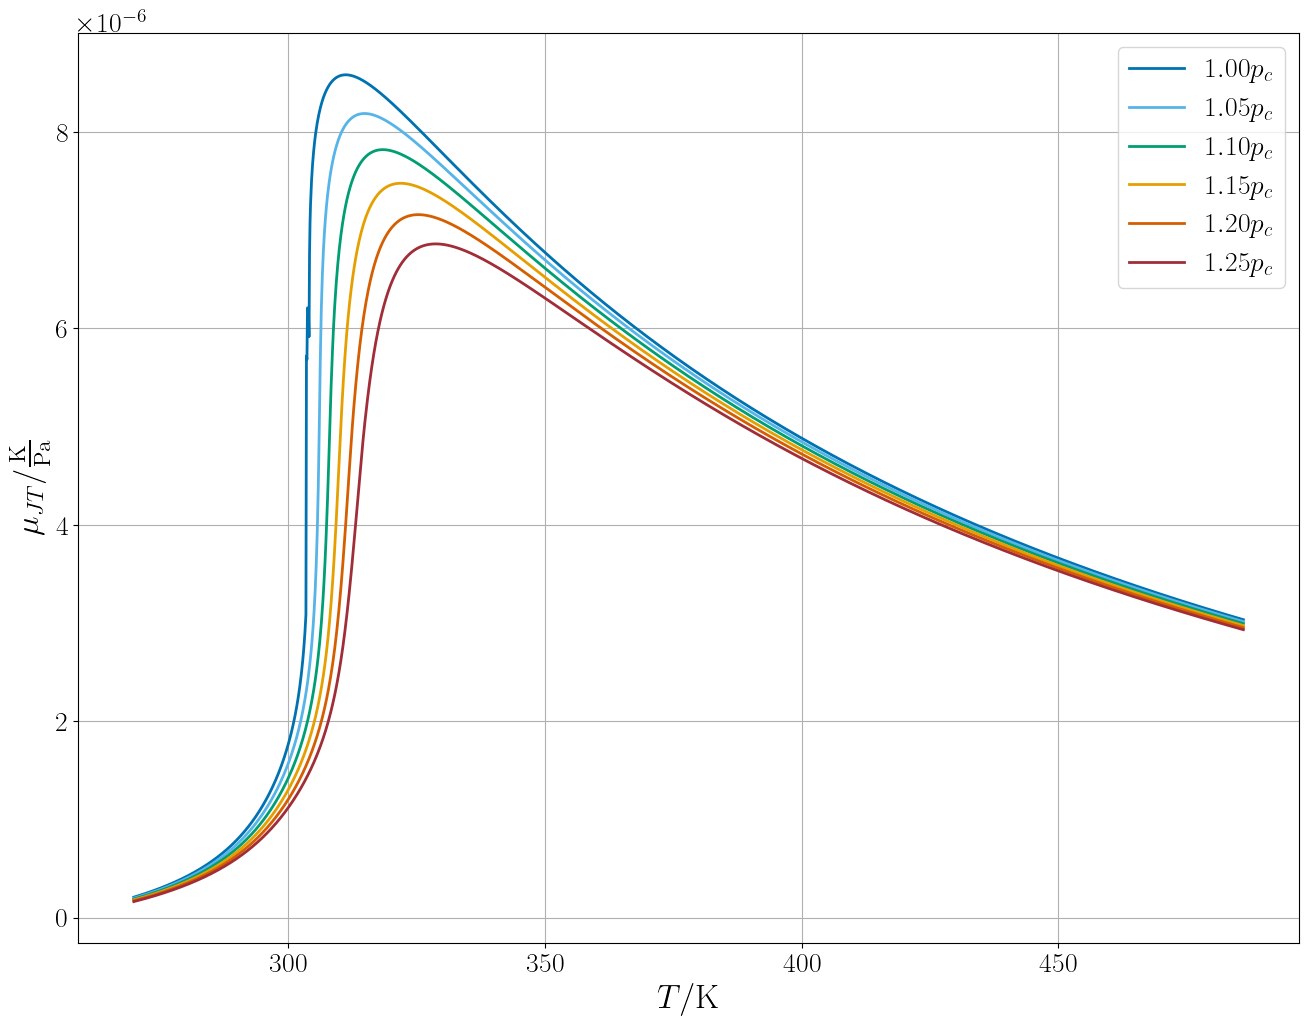

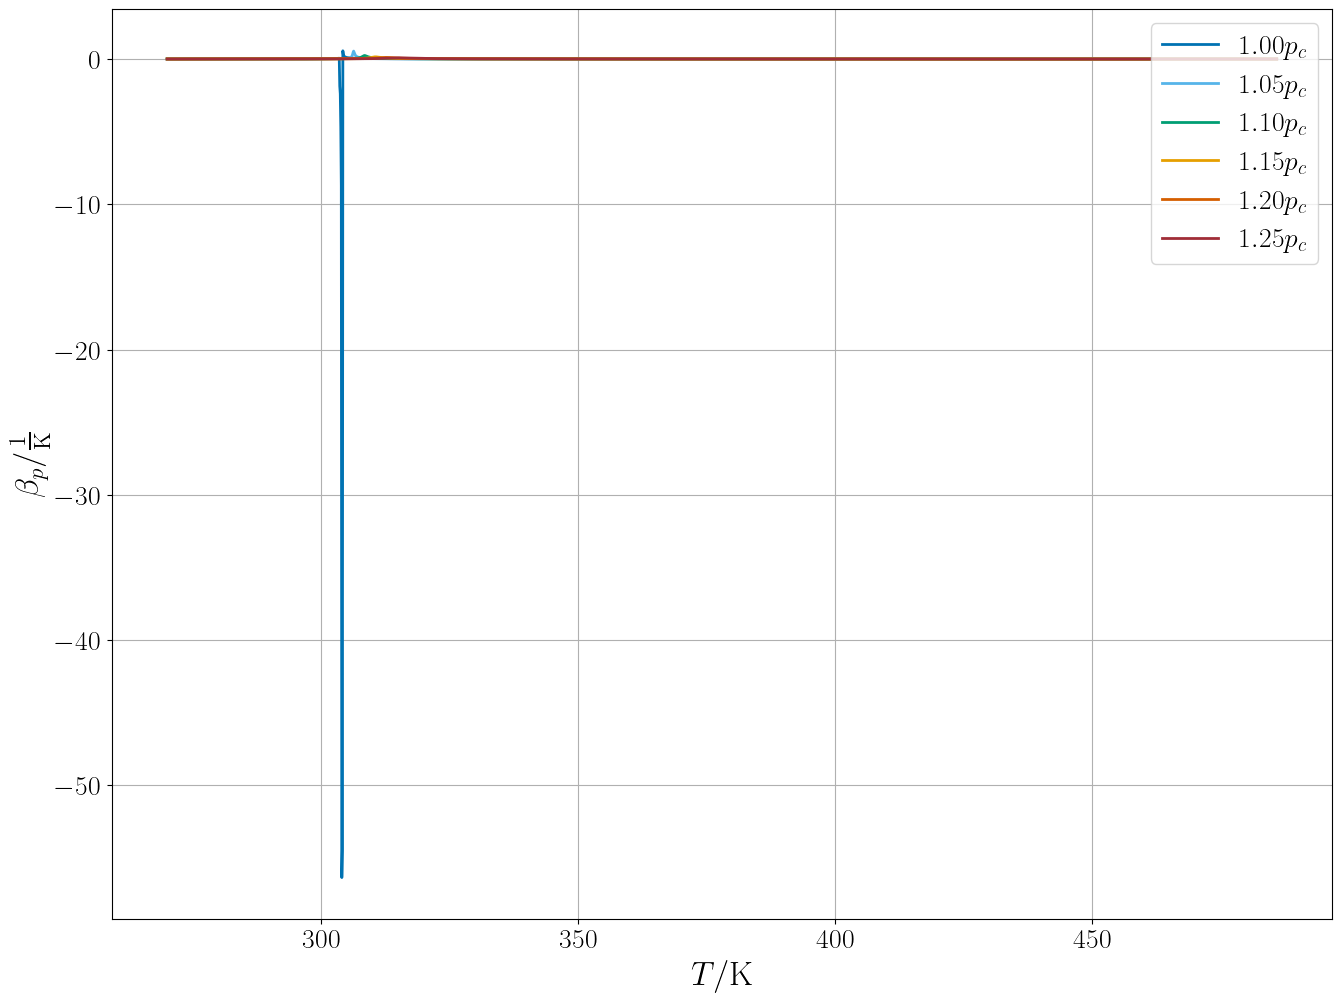

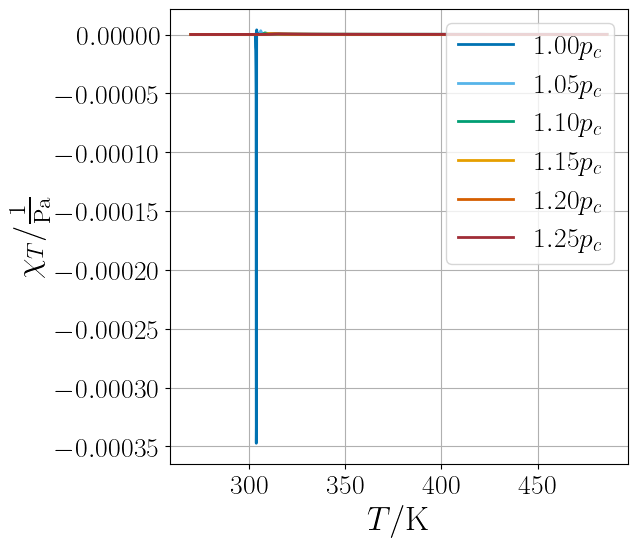

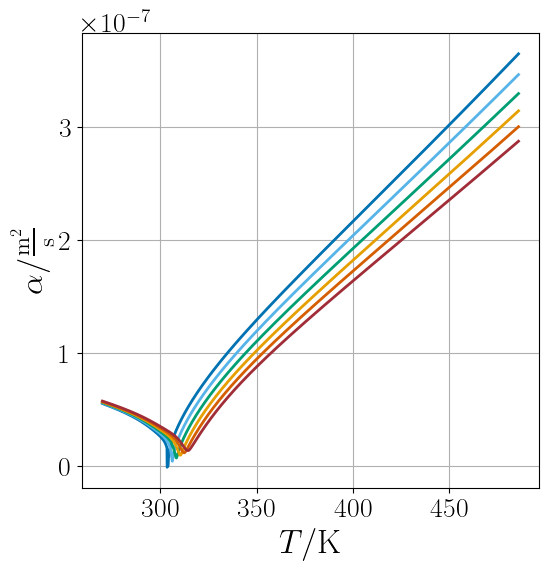

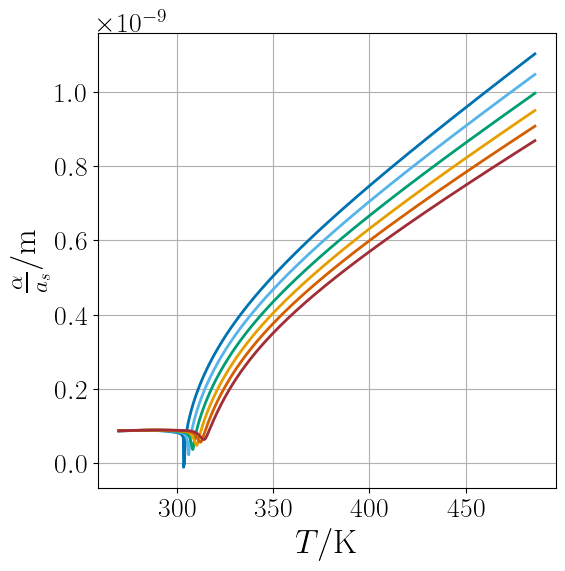

In [14]:
plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(pp)):
    plt.plot(T,rho_result[i,:],lw=2,color=rainbow[i],ls='-', label=f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \rho / \rm{\frac{kg}{m^3}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.show()

plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(pp)):
    plt.plot(T,lambda_result[i,:],lw=2,color=rainbow[i],ls='-', label=f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \lambda / \rm{\frac{W}{m K}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
#plt.savefig("D:/School/7. Félév/JCAM cikk/figs/rainbow_lambda.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(pp)):
    plt.plot(T,cp_result[i,:],lw=2,color=rainbow[i],ls='-', label=f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ c_p / \rm{\frac{J}{kg K}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
#plt.savefig("D:/School/7. Félév/JCAM cikk/figs/rainbow_cp.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(pp)):
    plt.plot(T,cv_result[i,:],lw=2,color=rainbow[i],ls='-', label=f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ c_v / \rm{\frac{J}{kg K}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.show()

plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(pp)):
    plt.plot(T,a_s_result[i,:],lw=2,color=rainbow[i],ls='-', label=f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ a_s / \rm{\frac{m}{s}} $')
plt.xlabel(r'$ T / \rm{K} $')
#plt.legend(loc='upper right')
#plt.savefig("D:/School/7. Félév/JCAM cikk/figs/rainbow_as.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(pp)):
    plt.plot(T,mu_JT_result[i,:],lw=2,color=rainbow[i],ls='-', label=f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \mu_{JT} / \rm{\frac{K}{Pa}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(pp)):
    plt.plot(T,Beta_p_result[i,:],lw=2,color=rainbow[i],ls='-', label=f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \beta_{p} / \rm{\frac{1}{K}}$')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.show()

plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,Khi_T_as[i,:],lw=2,color=rainbow[i],ls='-', label=f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$\chi_{T} / \rm{\frac{1}{Pa}}$')#,fontsize=18)
plt.xlabel(r'$ T / \rm{K} $')#,fontsize=18)
plt.legend(loc='upper right')#,fontsize=18)
#plt.savefig("D:/School/7. Félév/JCAM cikk/figs/rainbow_khit.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,alpha_result[i,:],lw=2,color=rainbow[i],ls='-', label=f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$\alpha / \rm{\frac{m^2}{s}}$')#,fontsize=18)
plt.xlabel(r'$ T / \rm{K} $')#,fontsize=18)
#plt.legend(loc='upper right')#,fontsize=18)
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/rainbow_alpha.pdf", bbox_inches='tight')  # vector, best for LaTeX

plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,alpha_as[i,:],lw=2,color=rainbow[i],ls='-', label=f'${pp[i]/Pc:.2f} p_c$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$\frac{\alpha}{a_s} / \rm{m}$')#,fontsize=18)
plt.xlabel(r'$ T / \rm{K} $')#,fontsize=18)
#plt.legend(loc='upper right')#,fontsize=18)
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/rainbow_alpha_as.pdf", bbox_inches='tight')  # vector, best for LaTeX
 

## nwat kezdeti értékekkel lineáris estekhez

In [51]:
Points = np.zeros((len(T_all_cases_lin), 3))
tau_acustic_IC = np.zeros(len(T_all_cases_lin))
tau_diff_IC = np.zeros(len(T_all_cases_lin))

for i in range(len(T_all_cases_lin)):
    rho_point = newton(
                    density_from_pressure,
                    rho_guess,
                    args=(T_all_cases_lin[i][0, int(Nx-1)],p_all_cases_lin[i][0] ),
                    tol=1e-9,
                    maxiter=5000
                        )
    print(rho_point)
    cp_point = get_cp(T_all_cases_lin[i][0, int(Nx-1)],rho_point)

    cv_point = get_cv(T_all_cases_lin[i][0, int(Nx-1)],rho_point)

    as_point = speed_of_sound(T_all_cases_lin[i][0, int(Nx-1)],rho_point)

    mu_JT_point= joule_thompson(T_all_cases_lin[i][0, int(Nx-1)],rho_point)

    betap_point = ( mu_JT_point* cp_point * rho_point + 1 ) / (T_all_cases_lin[i][0, int(Nx-1)])

    khi_T_as_point = cp_point / ( cv_point * rho_point * as_point**2 )

    Points[i,0] = T_all_cases_lin[i][0, int(Nx-1)] / rho_point * (betap_point*as_point/cp_point)**2

    Points[i,1] = betap_point * as_point**2 / cp_point

    Points[i,2]  = 1/ ( rho_point*cv_point)

    #időskálák a táblázathoz
    lambda_point= thermal_conductivity(T_all_cases_lin[i][0, int(Nx-1)],rho_point)
    tau_acustic_IC[i] = Lh / as_point
    tau_diff_IC[i] = (Lh**2 * rho_point * cp_point) / lambda_point

312.7761460922739
364.34920587258745
571.3701868622935
612.3752885339848
633.095340684451


### kezdeti érték táblázathoz

In [49]:
print(Points)


for i in range(len(T_all_cases_lin)):
    
    print('Diffúziós időskála:'+str(tau_diff_IC[i])+' s')
    #print('Pulzus időskála: '+str(t_heating_list[i])+' s')
    print('Akusztikus időskála: '+str(tau_acustic_IC[i])+ ' s')

[[2.32026814e-06 2.88011004e-01 2.57150833e-06]
 [1.83959600e-06 2.60325648e-01 1.92838780e-06]
 [1.25024830e-06 2.94144513e-01 1.34807892e-06]
 [1.22398340e-06 3.49890229e-01 1.40040503e-06]
 [1.18990673e-06 3.77329902e-01 1.40674936e-06]]
Diffúziós időskála:678208.1839310295 s
Akusztikus időskála: 0.0005355831418642412 s
Diffúziós időskála:1255735.1256868788 s
Akusztikus időskála: 0.0005694469411916633 s
Diffúziós időskála:1142663.9795940302 s
Akusztikus időskála: 0.0005202909275585107 s
Diffúziós időskála:693346.8781198435 s
Akusztikus időskála: 0.00044803800797382 s
Diffúziós időskála:577692.202232085 s
Akusztikus időskála: 0.0004165046717640303 s


### p=áll T=[...] esetekhez

In [17]:


pp        =  [ p_all_cases_lin[0][0],1.05 * Pc , 1.10 * Pc ,1.15 * Pc , 1.2 * Pc, 1.25 *Pc] 
rho_result = np.zeros((len(pp), len(T)))


for j in range(0,len(pp)):
    rho_guess  = Rhoc  # starting point
    for i in range(0,len(T)):
        try:
            rho_result[j,len(T)-1-i] = newton(
                density_from_pressure,
                rho_guess,
                args=(T[len(T)-1-i], pp[j]),
                tol=1e-1,
                maxiter=5000
            )
        except RuntimeError:
            # Fallback: if Newton fails, try a small perturbation
            rho_result[j,len(T)-1-i] = newton(
                density_from_pressure,
                rho_guess * 1.05,
                args=(T[len(T)-1-i], pp[j]),
                tol=1e-1,
                maxiter=5000
            )
        rho_guess = rho_result[j,len(T)-1-i]

cp_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        cp_result[j,i] = get_cp(T[i],rho_result[j,i])

cv_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        cv_result[j,i] = get_cv(T[i],rho_result[j,i])

a_s_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        a_s_result[j,i] = speed_of_sound(T[i],rho_result[j,i])

mu_JT_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        mu_JT_result[j,i] = joule_thompson(T[i],rho_result[j,i])

Beta_p_result = np.zeros((len(pp), len(T)))

for j in range(len(pp)):
    for i in range(len(T)):
        Beta_p_result[j,i] = ( mu_JT_result[j,i] * cp_result[j,i] * rho_result[j,i] + 1 ) / T[i]

Khi_T_as = np.zeros((len(pp), len(T)))

for j in range(len(pp)):
    for i in range(len(T)):
        Khi_T_as[j,i] = cp_result[j,i] / ( cv_result[j,i] * rho_result[j,i] * a_s_result[j,i]**2 )



Plot_1 = np.zeros((len(pp), len(T)))
Plot_2 = np.zeros((len(pp), len(T)))
Plot_3 = np.zeros((len(pp), len(T)))

for j in range(len(pp)):
    for i in range(len(T)):
        Plot_1[j,i] = T[i] / rho_result[j,i] * (Beta_p_result[j,i]*a_s_result[j,i]/cp_result[j,i])**2

        Plot_2[j,i] = Beta_p_result[j,i] * a_s_result[j,i]**2 / cp_result[j,i]

        Plot_3[j,i] = 1 / (rho_result[j,i]*cv_result[j,i])



C:\Users\krist\AppData\Local\Temp\ipykernel_11936\4131403098.py:171: RuntimeWarning: invalid value encountered in log
  Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum


<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:20: SyntaxWarning: invalid escape sequence '\ '
<>:35: SyntaxWarning: invalid escape sequence '\ '
<>:51: SyntaxWarning: invalid escape sequence '\ '
<>:67: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:20: SyntaxWarning: invalid escape sequence '\ '
<>:35: SyntaxWarning: invalid escape sequence '\ '
<>:51: SyntaxWarning: invalid escape sequence '\ '
<>:67: SyntaxWarning: invalid escape sequence '\ '
C:\Users\krist\AppData\Local\Temp\ipykernel_11936\879701233.py:6: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(T_all_cases_lin[i][0, int(Nx-1)], Points[i,0], marker='x',markersize=10, markeredgewidth=3, color = rainbow[i], label=f'$T_0={T_all_cases_lin[i][0, int(Nx-1)]}\  \mathrm{{ K}}$')
C:\Users\krist\AppData\Local\Temp\ipykernel_11936\879701233.py:20: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(T_all_cases_lin[i][0, int(Nx-1)], Points[i,0], marker='x',markersize=1

<Figure size 1574.8x1181.1 with 0 Axes>

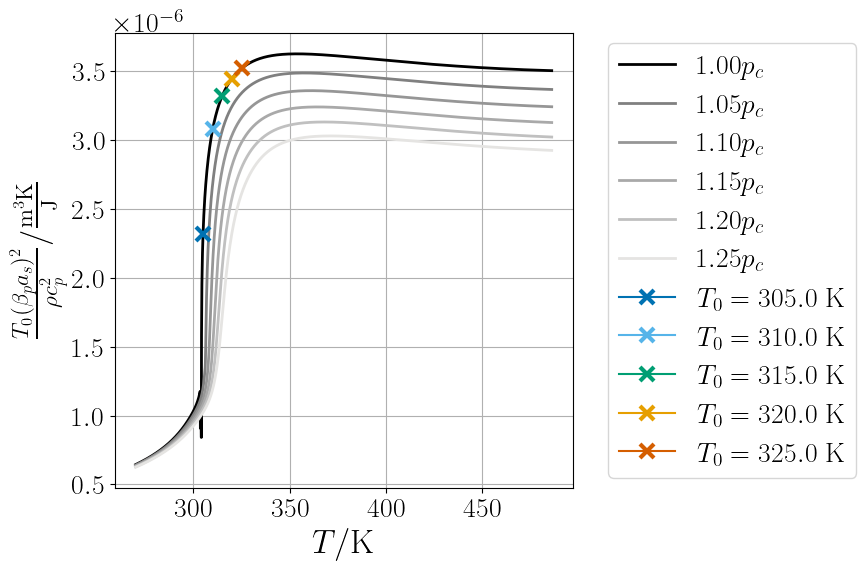

<Figure size 1574.8x1181.1 with 0 Axes>

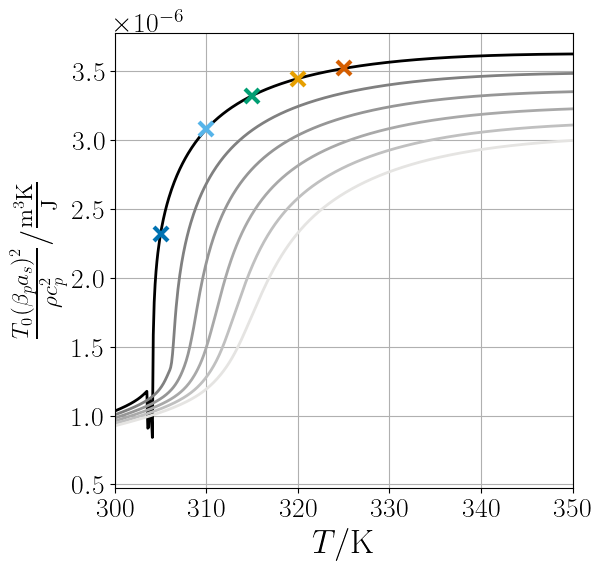

<Figure size 1574.8x1181.1 with 0 Axes>

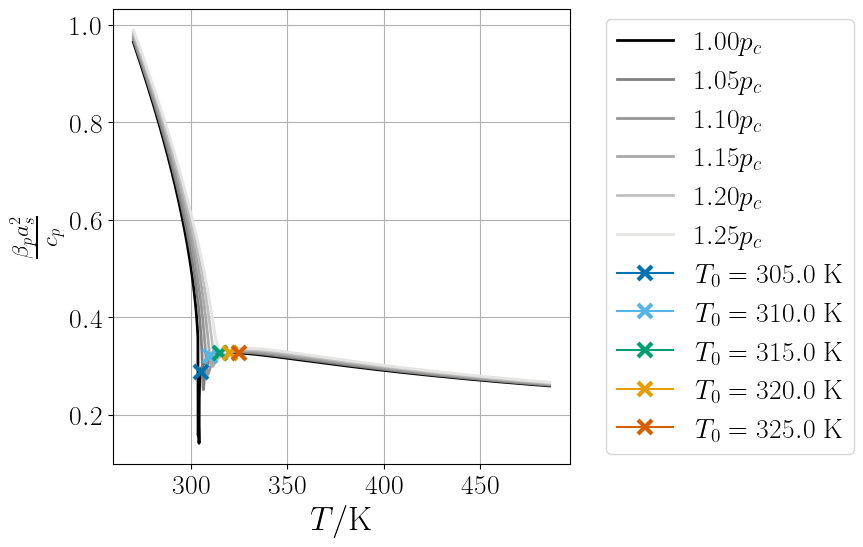

<Figure size 1574.8x1181.1 with 0 Axes>

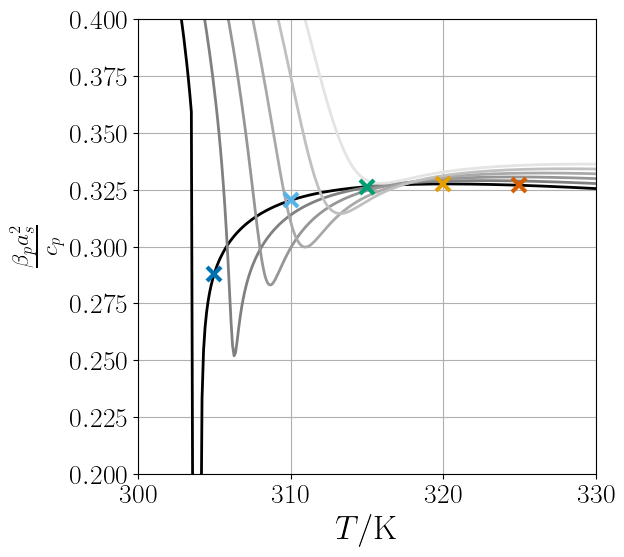

<Figure size 1574.8x1181.1 with 0 Axes>

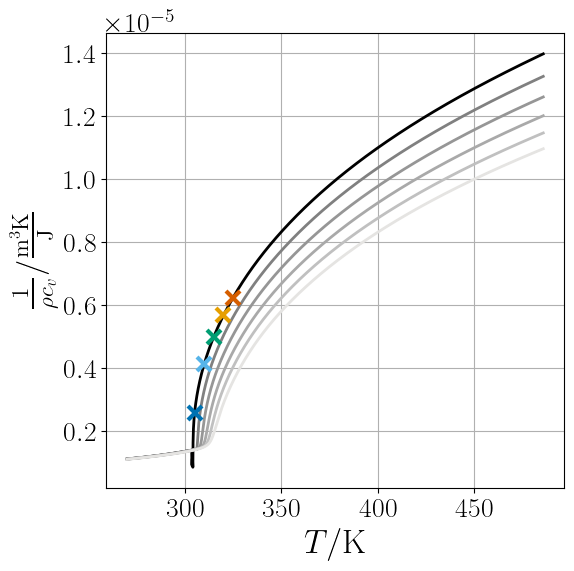

In [24]:
plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,Plot_1[i],lw=2,ls='-',color =greys[len(pp)-i-1], label = f'${pp[i]/Pc:.2f} p_c$')
for i in range(len(Points)):
    plt.plot(T_all_cases_lin[i][0, int(Nx-1)], Points[i,0], marker='x',markersize=10, markeredgewidth=3, color = rainbow[i], label=f'$T_0={T_all_cases_lin[i][0, int(Nx-1)]}\  \mathrm{{ K}}$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \frac{T_0(\beta_p a_s)^2}{\rho c_p^2}   \rm{  /  \frac{m^3 K}{J}}  $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/IC_nwat1_p.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,Plot_1[i],lw=2,ls='-',color =greys[len(pp)-i-1], label = f'${pp[i]/Pc:.2f} p_c$')
for i in range(len(Points)):
    plt.plot(T_all_cases_lin[i][0, int(Nx-1)], Points[i,0], marker='x',markersize=10, markeredgewidth=3, color = rainbow[i], label=f'$T_0={T_all_cases_lin[i][0, int(Nx-1)]}\  \mathrm{{ K}}$')
axes = plt.gca()
plt.grid()
plt.xlim(300,350)
plt.ylabel(r'$ \frac{T_0(\beta_p a_s)^2}{\rho c_p^2}   \rm{  /  \frac{m^3 K}{J}}  $')
plt.xlabel(r'$ T / \rm{K} $')
#plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/IC_nwat1_p_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,Plot_2[i],lw=2,ls='-',color =greys[len(pp)-i-1], label = f'${pp[i]/Pc:.2f} p_c$')
for i in range(len(Points)):
    plt.plot(T_all_cases_lin[i][0, int(Nx-1)], Points[i,1], marker='x',markersize=10, markeredgewidth=3, color = rainbow[i], label=f'$T_0={T_all_cases_lin[i][0, int(Nx-1)]}\ \mathrm{{ K}}$')
axes = plt.gca()
plt.grid()
#plt.xlim(300,350)
#plt.ylim(0.2, 0.4)
plt.ylabel(r'$ \frac{\beta_p a_s^2}{  c_p } $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/IC_nwat2_p.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,Plot_2[i],lw=2,ls='-',color =greys[len(pp)-i-1], label = f'${pp[i]/Pc:.2f} p_c$')
for i in range(len(Points)):
    plt.plot(T_all_cases_lin[i][0, int(Nx-1)], Points[i,1], marker='x',markersize=10, markeredgewidth=3, color = rainbow[i], label=f'$T_0={T_all_cases_lin[i][0, int(Nx-1)]}\ \mathrm{{ K}}$')
axes = plt.gca()
plt.grid()
plt.xlim(300,330)
plt.ylim(0.2,0.4)
plt.ylabel(r'$ \frac{\beta_p a_s^2}{  c_p } $')
plt.xlabel(r'$ T / \rm{K} $')
#plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/IC_nwat2_p_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,Plot_3[i],lw=2,ls='-',color =greys[len(pp)-i-1], label = f'${pp[i]/Pc:.2f} p_c$')
for i in range(len(Points)):
    plt.plot(T_all_cases_lin[i][0, int(Nx-1)], Points[i,2], marker='x',markersize=10, markeredgewidth=3, color = rainbow[i], label=f'$T_0={T_all_cases_lin[i][0, int(Nx-1)]}\ \mathrm{{ K}}$')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$\frac{ 1 } {\rho c_v} \rm{  /  \frac{m^3 K}{J}}$')
plt.xlabel(r'$ T / \rm{K} $')
#plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/IC_nwat3_p.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()


ezen látszik miért furcsa a 3-as eset, pont egy nagyobb nyomáshoz tartozó vonalon van rajta

### T=áll p=[...] esetekhez

In [55]:
pp        =  np.zeros(len(p_all_cases_lin))
for i in range(len(p_all_cases_lin)):
    pp[i]        =  p_all_cases_lin[i][0]
rho_result = np.zeros((len(pp), len(T)))


for j in range(0,len(pp)):
    rho_guess  = Rhoc  # starting point
    for i in range(0,len(T)):
        try:
            rho_result[j,len(T)-1-i] = newton(
                density_from_pressure,
                rho_guess,
                args=(T[len(T)-1-i], pp[j]),
                tol=1e-1,
                maxiter=5000
            )
        except RuntimeError:
            # Fallback: if Newton fails, try a small perturbation
            rho_result[j,len(T)-1-i] = newton(
                density_from_pressure,
                rho_guess * 1.05,
                args=(T[len(T)-1-i], pp[j]),
                tol=1e-1,
                maxiter=5000
            )
        rho_guess = rho_result[j,len(T)-1-i]

cp_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        cp_result[j,i] = get_cp(T[i],rho_result[j,i])

cv_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        cv_result[j,i] = get_cv(T[i],rho_result[j,i])

a_s_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        a_s_result[j,i] = speed_of_sound(T[i],rho_result[j,i])

mu_JT_result = np.zeros((len(pp), len(T)))
for j in range(0,len(pp)):
    for i in range(0,len(T)):
        mu_JT_result[j,i] = joule_thompson(T[i],rho_result[j,i])

Beta_p_result = np.zeros((len(pp), len(T)))

for j in range(len(pp)):
    for i in range(len(T)):
        Beta_p_result[j,i] = ( mu_JT_result[j,i] * cp_result[j,i] * rho_result[j,i] + 1 ) / T[i]

Khi_T_as = np.zeros((len(pp), len(T)))

for j in range(len(pp)):
    for i in range(len(T)):
        Khi_T_as[j,i] = cp_result[j,i] / ( cv_result[j,i] * rho_result[j,i] * a_s_result[j,i]**2 )



Plot_1 = np.zeros((len(pp), len(T)))
Plot_2 = np.zeros((len(pp), len(T)))
Plot_3 = np.zeros((len(pp), len(T)))

for j in range(len(pp)):
    for i in range(len(T)):
        Plot_1[j,i] = T[i] / rho_result[j,i] * (Beta_p_result[j,i]*a_s_result[j,i]/cp_result[j,i])**2

        Plot_2[j,i] = Beta_p_result[j,i] * a_s_result[j,i]**2 / cp_result[j,i]

        Plot_3[j,i] = 1 / (rho_result[j,i]*cv_result[j,i])



C:\Users\krist\AppData\Local\Temp\ipykernel_11936\4131403098.py:171: RuntimeWarning: invalid value encountered in log
  Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum


<Figure size 1574.8x1181.1 with 0 Axes>

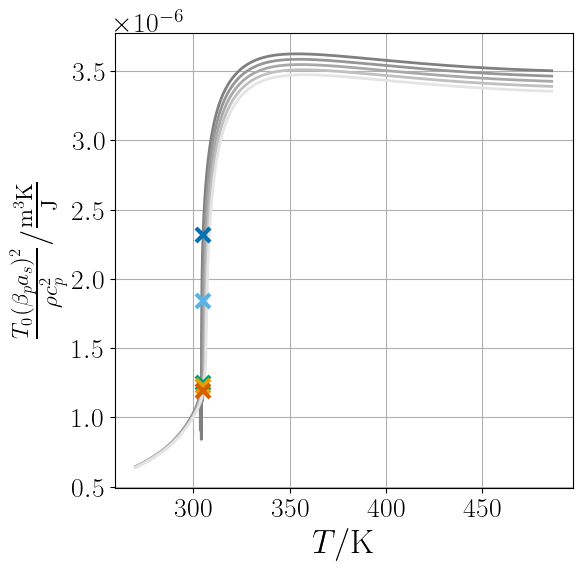

<Figure size 1574.8x1181.1 with 0 Axes>

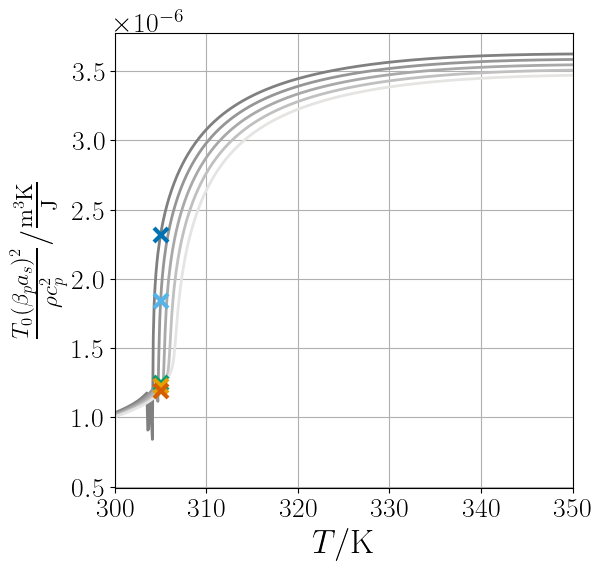

<Figure size 1574.8x1181.1 with 0 Axes>

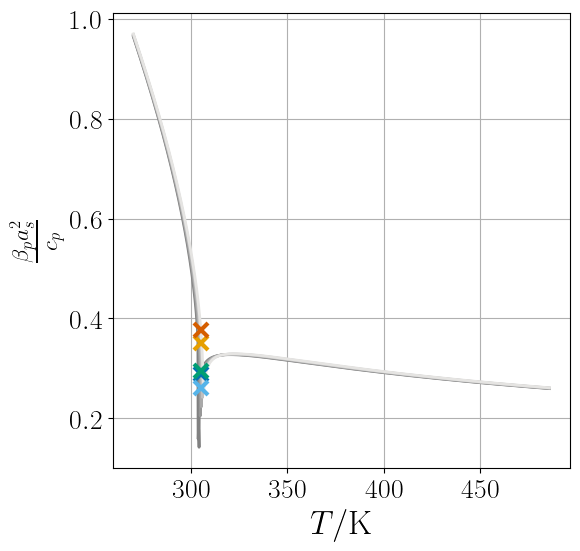

<Figure size 1574.8x1181.1 with 0 Axes>

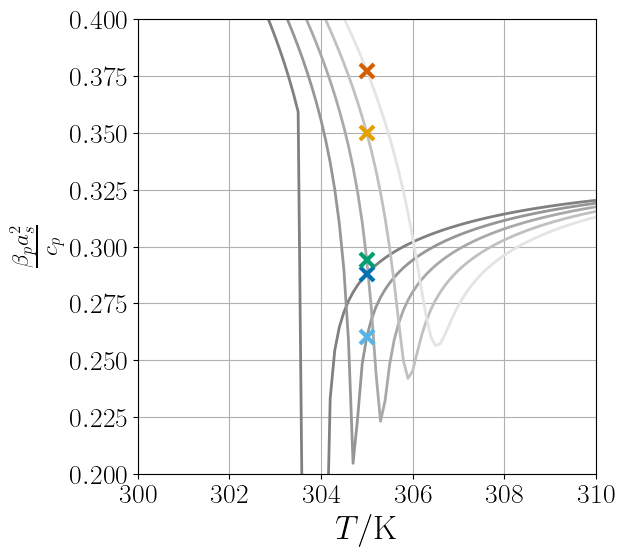

<Figure size 1574.8x1181.1 with 0 Axes>

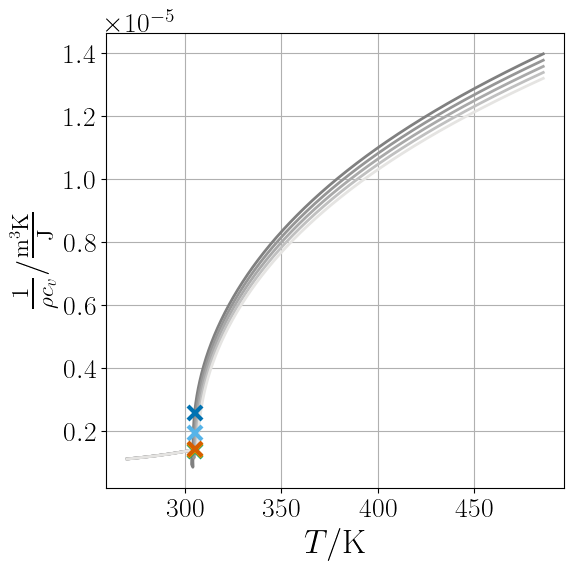

In [57]:
plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,Plot_1[i],lw=2,ls='-',color =greys[len(pp)-i-1], label = f'${pp[i]/Pc:.2f} p_c$')
for i in range(len(Points)):
    plt.plot(T_all_cases_lin[i][0, int(Nx-1)], Points[i,0], marker='x',markersize=10, markeredgewidth=3, color = rainbow[i],  label=f'$p_0={p_all_cases_lin[i][0]:.2f} p_c  $')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \frac{T_0(\beta_p a_s)^2}{\rho c_p^2}   \rm{  /  \frac{m^3 K}{J}}  $')
plt.xlabel(r'$ T / \rm{K} $')
#plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/IC_nwat1_T.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,Plot_1[i],lw=2,ls='-',color =greys[len(pp)-i-1], label = f'${pp[i]/Pc:.2f} p_c$')
for i in range(len(Points)):
    plt.plot(T_all_cases_lin[i][0, int(Nx-1)], Points[i,0], marker='x',markersize=10, markeredgewidth=3, color = rainbow[i],  label=f'$p_0={p_all_cases_lin[i][0]:.2f} p_c  $')
axes = plt.gca()
plt.grid()
plt.xlim(300,350)
plt.ylabel(r'$ \frac{T_0(\beta_p a_s)^2}{\rho c_p^2}   \rm{  /  \frac{m^3 K}{J}}  $')
plt.xlabel(r'$ T / \rm{K} $')
#plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/IC_nwat1_T_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,Plot_2[i],lw=2,ls='-',color =greys[len(pp)-i-1], label =  f'${pp[i]/Pc:.2f} p_c$')
for i in range(len(Points)):
    plt.plot(T_all_cases_lin[i][0, int(Nx-1)], Points[i,1], marker='x',markersize=10, markeredgewidth=3, color = rainbow[i], label=f'$p_0={p_all_cases_lin[i][0]:.2f} p_c  $')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \frac{\beta_p a_s^2}{  c_p } $')
plt.xlabel(r'$ T / \rm{K} $')
#plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/IC_nwat2_T.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
for i in range(len(pp)):
    plt.plot(T,Plot_2[i],lw=2,ls='-',color =greys[len(pp)-i-1], label =  f'${pp[i]/Pc:.2f} p_c$')
for i in range(len(Points)):
    plt.plot(T_all_cases_lin[i][0, int(Nx-1)], Points[i,1], marker='x',markersize=10, markeredgewidth=3, color = rainbow[i], label=f'$p_0={p_all_cases_lin[i][0]:.2f} p_c  $')
axes = plt.gca()
plt.grid()
plt.xlim(300,310)
plt.ylim(0.2,0.4)
plt.ylabel(r'$ \frac{\beta_p a_s^2}{  c_p } $')
plt.xlabel(r'$ T / \rm{K} $')
#plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/JCAM cikk/figs/IC_nwat2_T_zoom.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(pp)):
    plt.plot(T,Plot_3[i],lw=2,ls='-',color =greys[len(pp)-i-1], label = f'${pp[i]/Pc:.2f} p_c$')
for i in range(len(Points)):
    plt.plot(T_all_cases_lin[i][0, int(Nx-1)], Points[i,2], marker='x',markersize=10, markeredgewidth=3, color = rainbow[i],  label=f'$p_0={p_all_cases_lin[i][0]:.2f} p_c  $')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$\frac{ 1 } {\rho c_v} \rm{  /  \frac{m^3 K}{J}}$')
plt.xlabel(r'$ T / \rm{K} $')
#plt.legend(loc='center right',bbox_to_anchor=(1.65, 0.5))
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/IC_nwat3_T.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

# Capter 5 - nwat values along Widom lines

## along cp

In [92]:

rho_nwat = np.zeros(len(pts_p_cp_Z))


for j in tqdm(range(0,len(pts_p_cp_Z))):
    rho_guess  = Rhoc  # starting point
    rho_nwat[j] = newton(
        density_from_pressure,
        rho_guess,
        args=(pts_T_cp_Z[j], pts_p_cp_Z[j]),
        tol=1e-1,
        maxiter=5000
    )

cp_nwat = np.zeros(len(pts_p_cp_Z))
for j in tqdm(range(0,len(pts_p_cp_Z))):
    cp_nwat[j] = get_cp(pts_T_cp_Z[j],rho_nwat[j])

cv_nwat = np.zeros(len(pts_p_cp_Z))
for j in tqdm(range(0,len(pts_p_cp_Z))):
    cv_nwat[j] = get_cv(pts_T_cp_Z[i],rho_nwat[j])

a_s_nwat = np.zeros(len(pts_p_cp_Z))
for j in tqdm(range(0,len(pts_p_cp_Z))):
    a_s_nwat[j] = speed_of_sound(pts_T_cp_Z[i],rho_nwat[j])

mu_JT_nwat = np.zeros(len(pts_p_cp_Z))
for j in tqdm(range(0,len(pts_p_cp_Z))):
    mu_JT_nwat[j] = joule_thompson(pts_T_cp_Z[i],rho_nwat[j])

Beta_p_nwat = np.zeros(len(pts_p_cp_Z))

for j in tqdm(range(0,len(pts_p_cp_Z))):
    Beta_p_nwat[j] = ( mu_JT_nwat[j] * cp_nwat[j] * rho_nwat[j] + 1 ) / pts_T_cp_Z[j]




Plot_1_cp = np.zeros(len(pts_p_cp_Z))
Plot_2_cp = np.zeros(len(pts_p_cp_Z))
Plot_3_cp = np.zeros(len(pts_p_cp_Z))

for j in tqdm(range(len(pts_p_cp_Z))):
    Plot_1_cp[j] = pts_T_cp_Z[j] / rho_nwat[j] * (Beta_p_nwat[j]*a_s_nwat[j]/cp_nwat[j])**2

    Plot_2_cp[j] = Beta_p_nwat[j] * a_s_nwat[j]**2 / cp_nwat[j]

    Plot_3_cp[j] = 1 / (rho_nwat[j]*cv_nwat[j])




100%|██████████| 10000/10000 [00:00<00:00, 277810.79it/s]


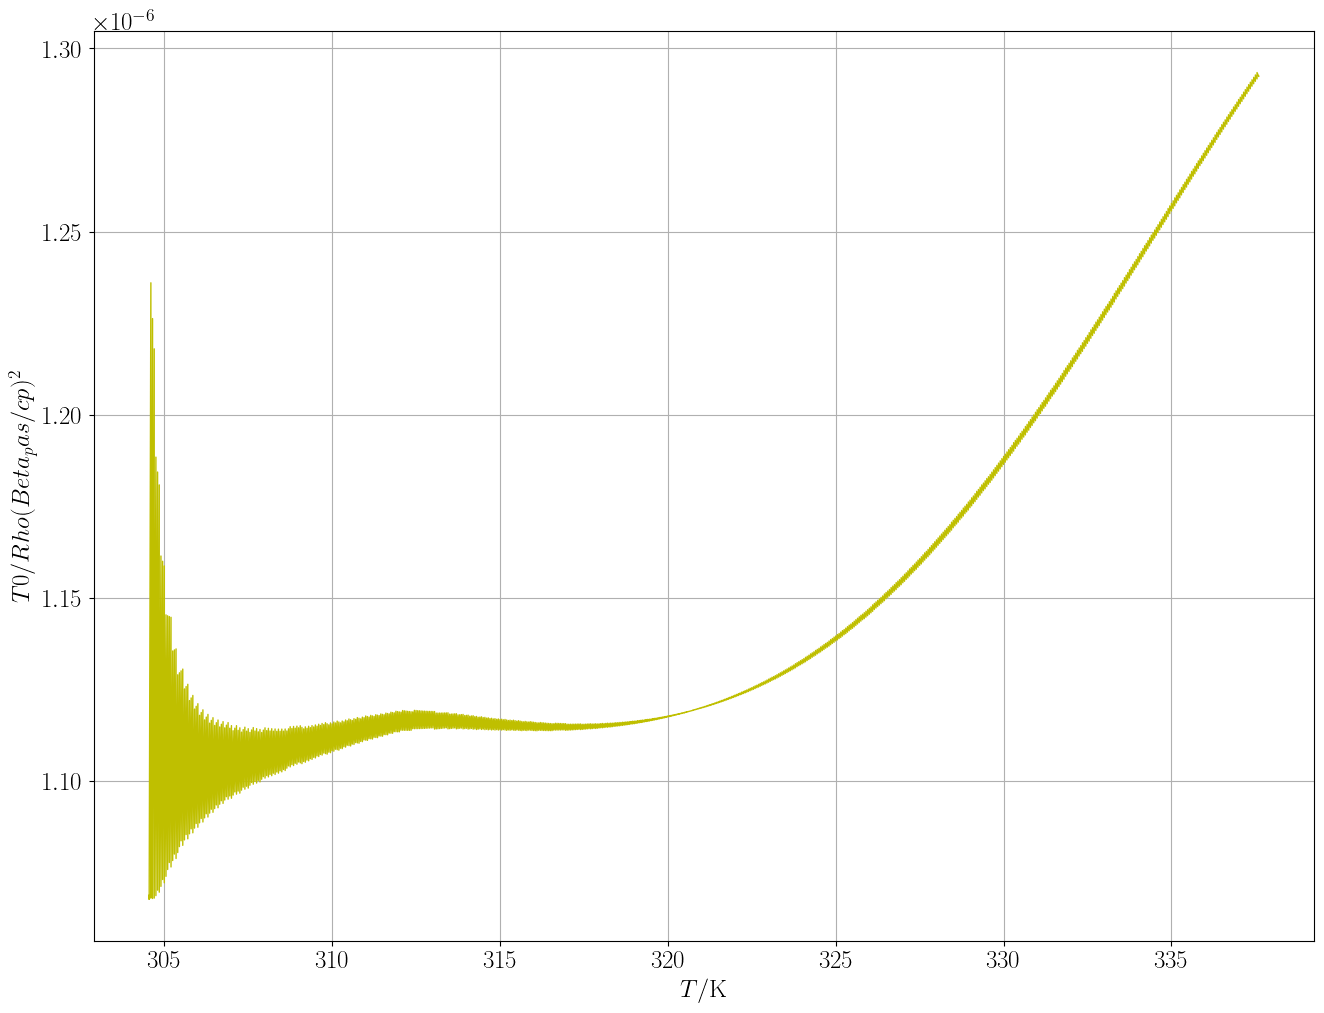

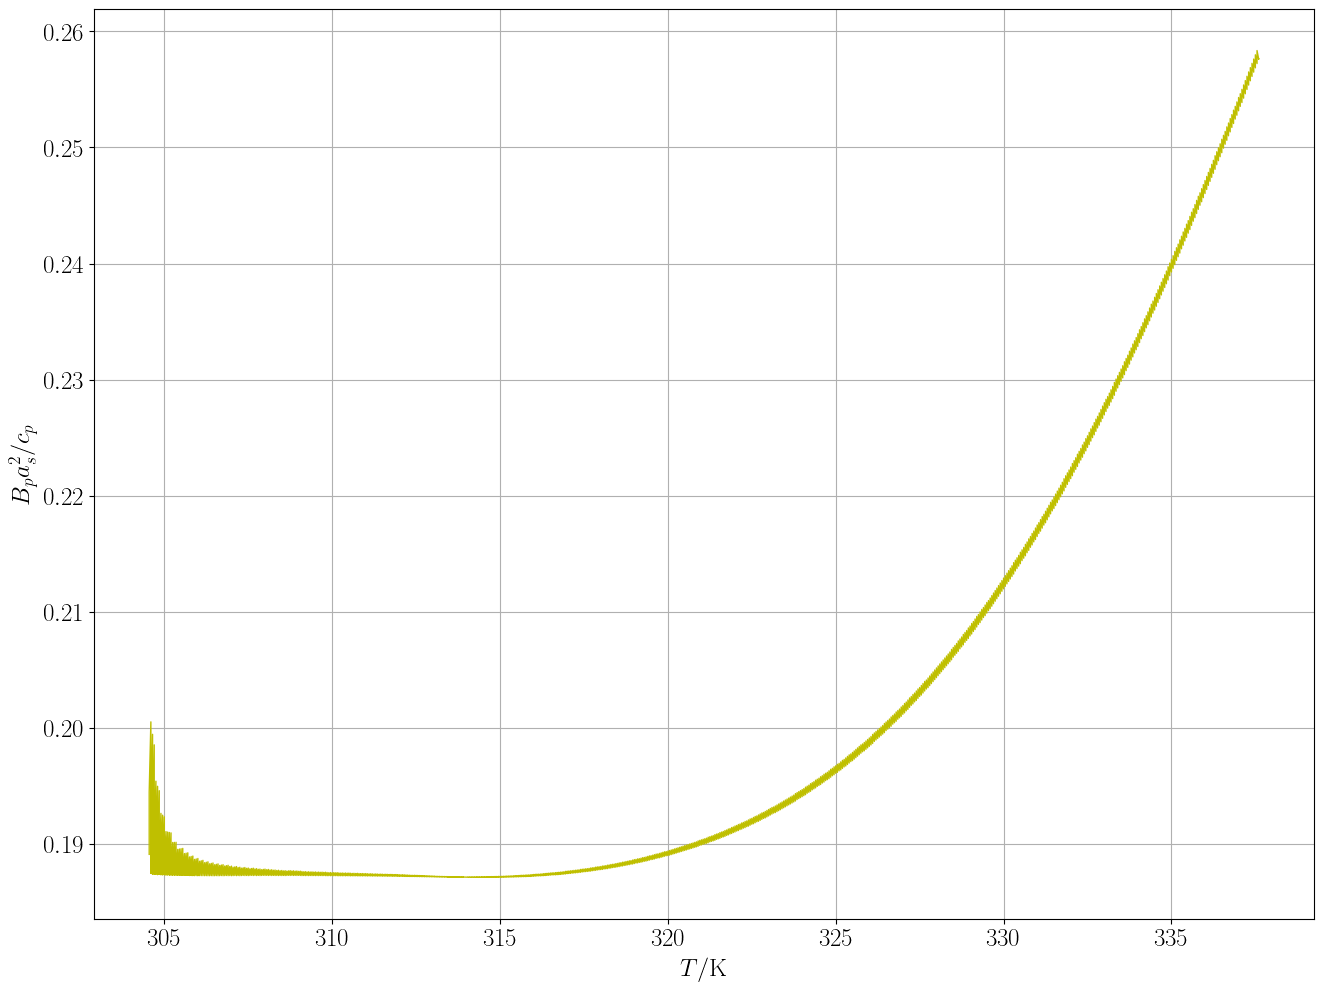

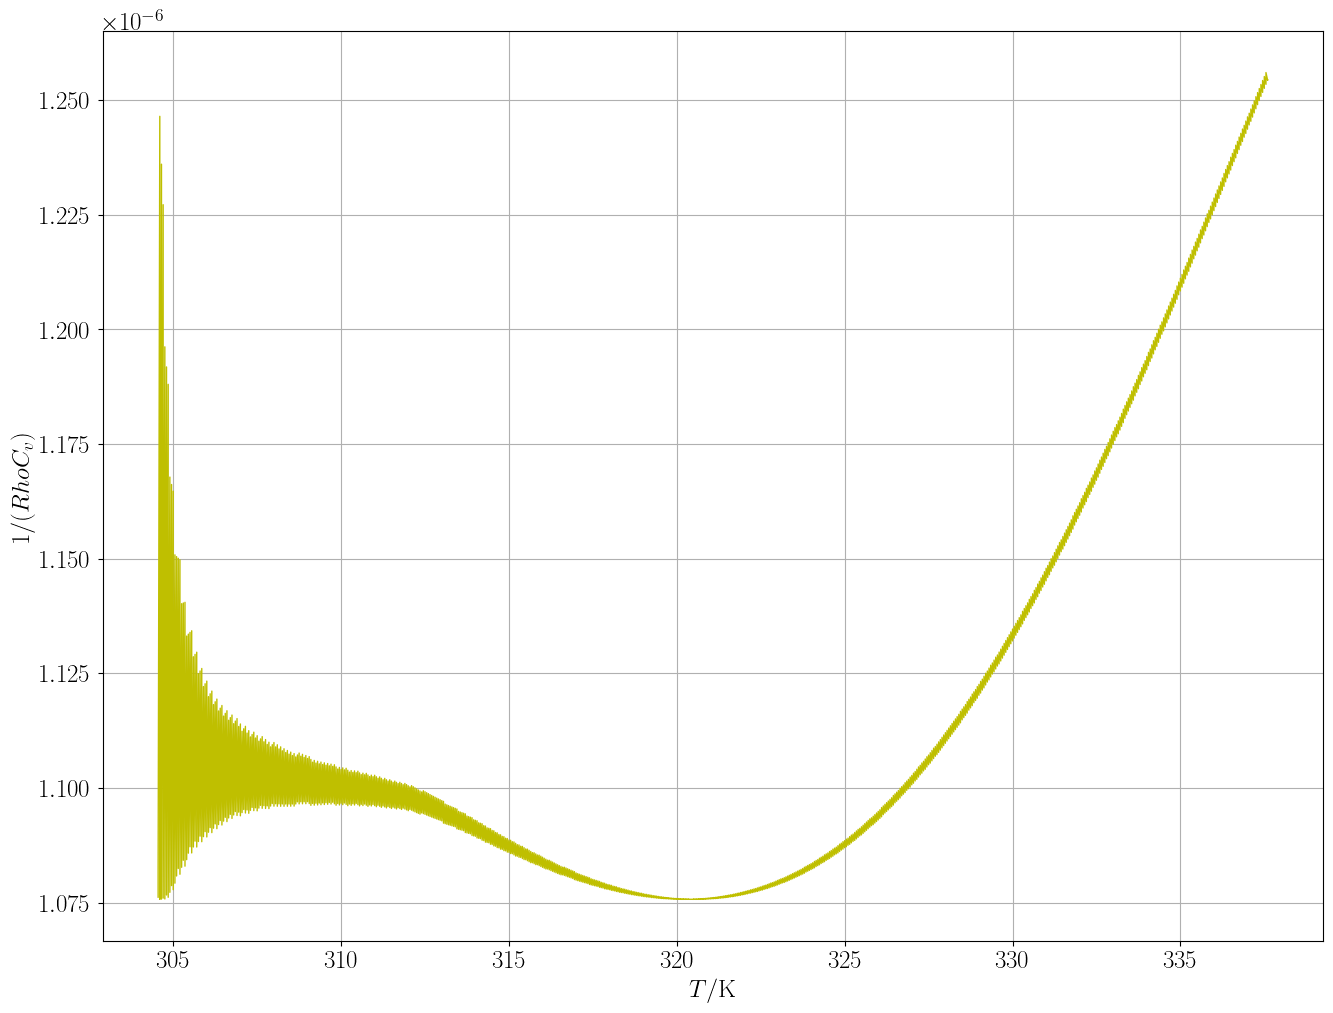

In [93]:


plt.figure(figsize=(40/2.54,30/2.54))
plt.plot(pts_T_cp_Z,Plot_1_cp,c='y', lw=1)
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ T0 / Rho (Beta_p as / cp )^2 $')
plt.xlabel(r'$ T / \rm{K} $')
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.plot(pts_T_cp_Z,Plot_2_cp,c='y', lw=1)
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ B_p a_s^2 / c_p $')
plt.xlabel(r'$ T / \rm{K} $')
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.plot(pts_T_cp_Z,Plot_3_cp,c='y', lw=1)
axes = plt.gca()
plt.grid()
plt.ylabel(r'$1 / (RhoC_v)$')
plt.xlabel(r'$ T / \rm{K} $')
plt.show()

## along betap

In [94]:

rho_nwat = np.zeros(len(pts_p_cp_Z))


for j in tqdm(range(0,len(pts_p_cp_Z))):
    rho_guess  = Rhoc  # starting point
    rho_nwat[j] = newton(
        density_from_pressure,
        rho_guess,
        args=(pts_T_betap_Z[j], pts_p_betap_Z[j]),
        tol=1e-1,
        maxiter=5000
    )

cp_nwat = np.zeros(len(pts_p_cp_Z))
for j in tqdm(range(0,len(pts_p_cp_Z))):
    cp_nwat[j] = get_cp(pts_T_betap_Z[j],rho_nwat[j])

cv_nwat = np.zeros(len(pts_p_cp_Z))
for j in tqdm(range(0,len(pts_p_cp_Z))):
    cv_nwat[j] = get_cv(pts_T_betap_Z[i],rho_nwat[j])

a_s_nwat = np.zeros(len(pts_p_cp_Z))
for j in tqdm(range(0,len(pts_p_cp_Z))):
    a_s_nwat[j] = speed_of_sound(pts_T_betap_Z[i],rho_nwat[j])

mu_JT_nwat = np.zeros(len(pts_p_cp_Z))
for j in tqdm(range(0,len(pts_p_cp_Z))):
    mu_JT_nwat[j] = joule_thompson(pts_T_betap_Z[i],rho_nwat[j])

Beta_p_nwat = np.zeros(len(pts_p_cp_Z))

for j in tqdm(range(0,len(pts_p_cp_Z))):
    Beta_p_nwat[j] = ( mu_JT_nwat[j] * cp_nwat[j] * rho_nwat[j] + 1 ) / pts_T_betap_Z[j]




Plot_1_bp = np.zeros(len(pts_p_cp_Z))
Plot_2_bp = np.zeros(len(pts_p_cp_Z))
Plot_3_bp = np.zeros(len(pts_p_cp_Z))

for j in tqdm(range(len(pts_p_cp_Z))):
    Plot_1_bp[j] = pts_T_betap_Z[j] / rho_nwat[j] * (Beta_p_nwat[j]*a_s_nwat[j]/cp_nwat[j])**2

    Plot_2_bp[j] = Beta_p_nwat[j] * a_s_nwat[j]**2 / cp_nwat[j]

    Plot_3_bp[j] = 1 / (rho_nwat[j]*cv_nwat[j])




100%|██████████| 10000/10000 [00:00<00:00, 294112.15it/s]


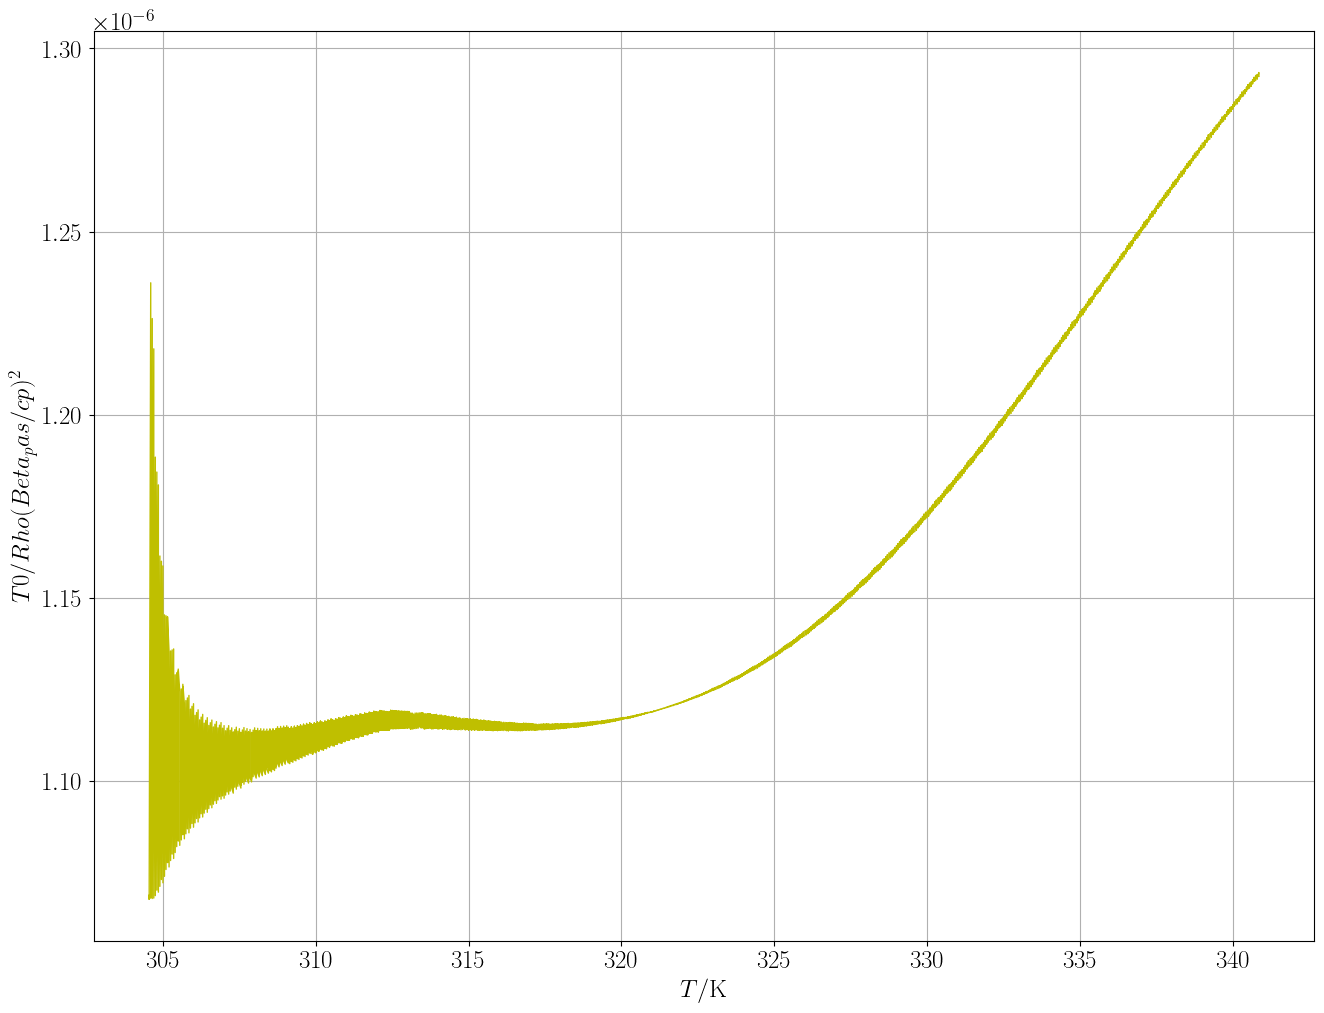

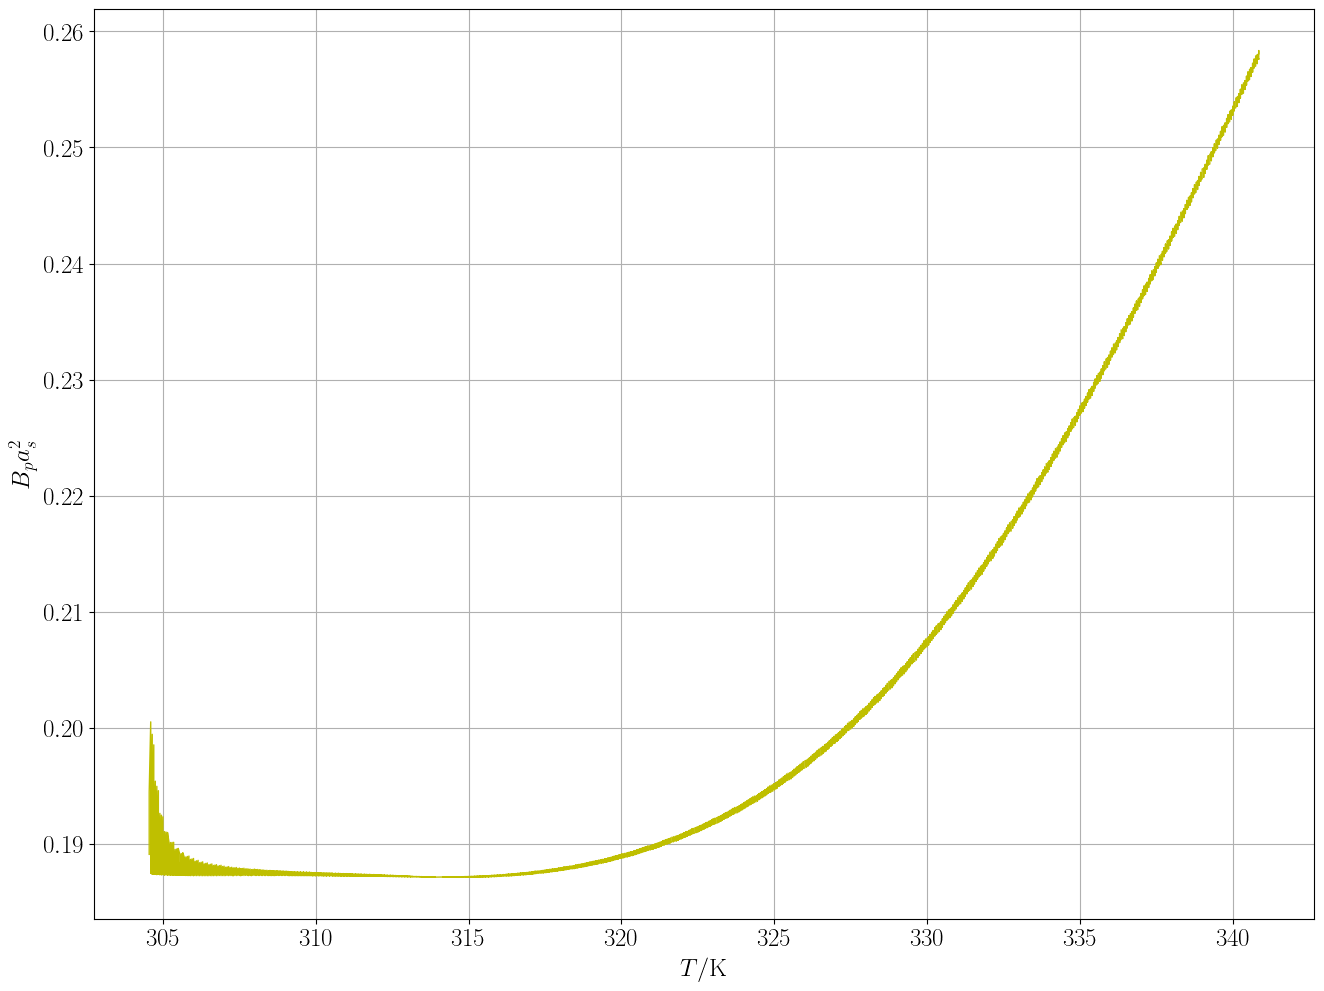

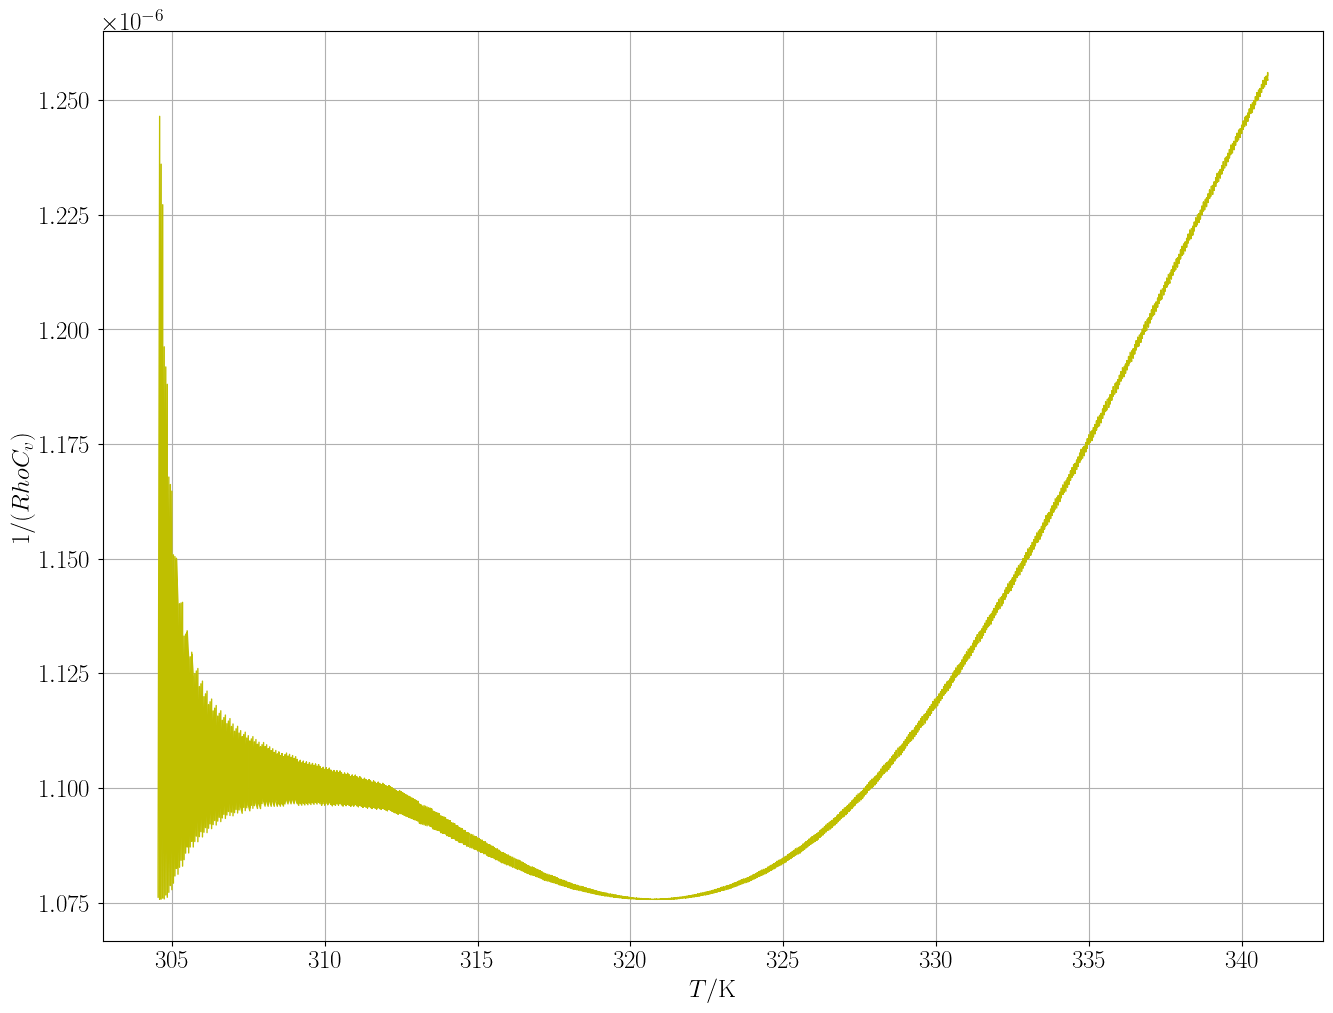

In [95]:
plt.figure(figsize=(40/2.54,30/2.54))
plt.plot(pts_T_betap_Z,Plot_1_cp,c='y', lw=1)
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ T0 / Rho (Beta_p as / cp )^2   $')
plt.xlabel(r'$ T / \rm{K} $')
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.plot(pts_T_betap_Z,Plot_2_cp,c='y', lw=1)
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ B_p a_s^2  $')
plt.xlabel(r'$ T / \rm{K} $')
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.plot(pts_T_betap_Z,Plot_3_cp,c='y', lw=1)
axes = plt.gca()
plt.grid()
plt.ylabel(r'$1 / (RhoC_v)  $')
plt.xlabel(r'$ T / \rm{K} $')
plt.show()

## along as

In [96]:

rho_nwat = np.zeros(len(pts_p_cp_Z))


for j in tqdm(range(0,len(pts_p_cp_Z))):
    rho_guess  = Rhoc  # starting point
    rho_nwat[j] = newton(
        density_from_pressure,
        rho_guess,
        args=(pts_T_as_Z[j], pts_p_as_Z[j]),
        tol=1e-1,
        maxiter=5000
    )

cp_nwat = np.zeros(len(pts_p_cp_Z))
for j in tqdm(range(0,len(pts_p_cp_Z))):
    cp_nwat[j] = get_cp(pts_T_as_Z[j],rho_nwat[j])

cv_nwat = np.zeros(len(pts_p_cp_Z))
for j in tqdm(range(0,len(pts_p_cp_Z))):
    cv_nwat[j] = get_cv(pts_T_as_Z[i],rho_nwat[j])

a_s_nwat = np.zeros(len(pts_p_cp_Z))
for j in tqdm(range(0,len(pts_p_cp_Z))):
    a_s_nwat[j] = speed_of_sound(pts_T_as_Z[i],rho_nwat[j])

mu_JT_nwat = np.zeros(len(pts_p_cp_Z))
for j in tqdm(range(0,len(pts_p_cp_Z))):
    mu_JT_nwat[j] = joule_thompson(pts_T_as_Z[i],rho_nwat[j])

Beta_p_nwat = np.zeros(len(pts_p_cp_Z))

for j in tqdm(range(0,len(pts_p_cp_Z))):
    Beta_p_nwat[j] = ( mu_JT_nwat[j] * cp_nwat[j] * rho_nwat[j] + 1 ) / pts_T_as_Z[j]




Plot_1_as = np.zeros(len(pts_p_cp_Z))
Plot_2_as = np.zeros(len(pts_p_cp_Z))
Plot_3_as = np.zeros(len(pts_p_cp_Z))

for j in tqdm(range(len(pts_p_cp_Z))):
    Plot_1_as[j] = pts_T_as_Z[j] / rho_nwat[j] * (Beta_p_nwat[j]*a_s_nwat[j]/cp_nwat[j])**2

    Plot_2_as[j] = Beta_p_nwat[j] * a_s_nwat[j]**2 / cp_nwat[j]

    Plot_3_as[j] = 1 / (rho_nwat[j]*cv_nwat[j])




100%|██████████| 10000/10000 [00:00<00:00, 200133.79it/s]


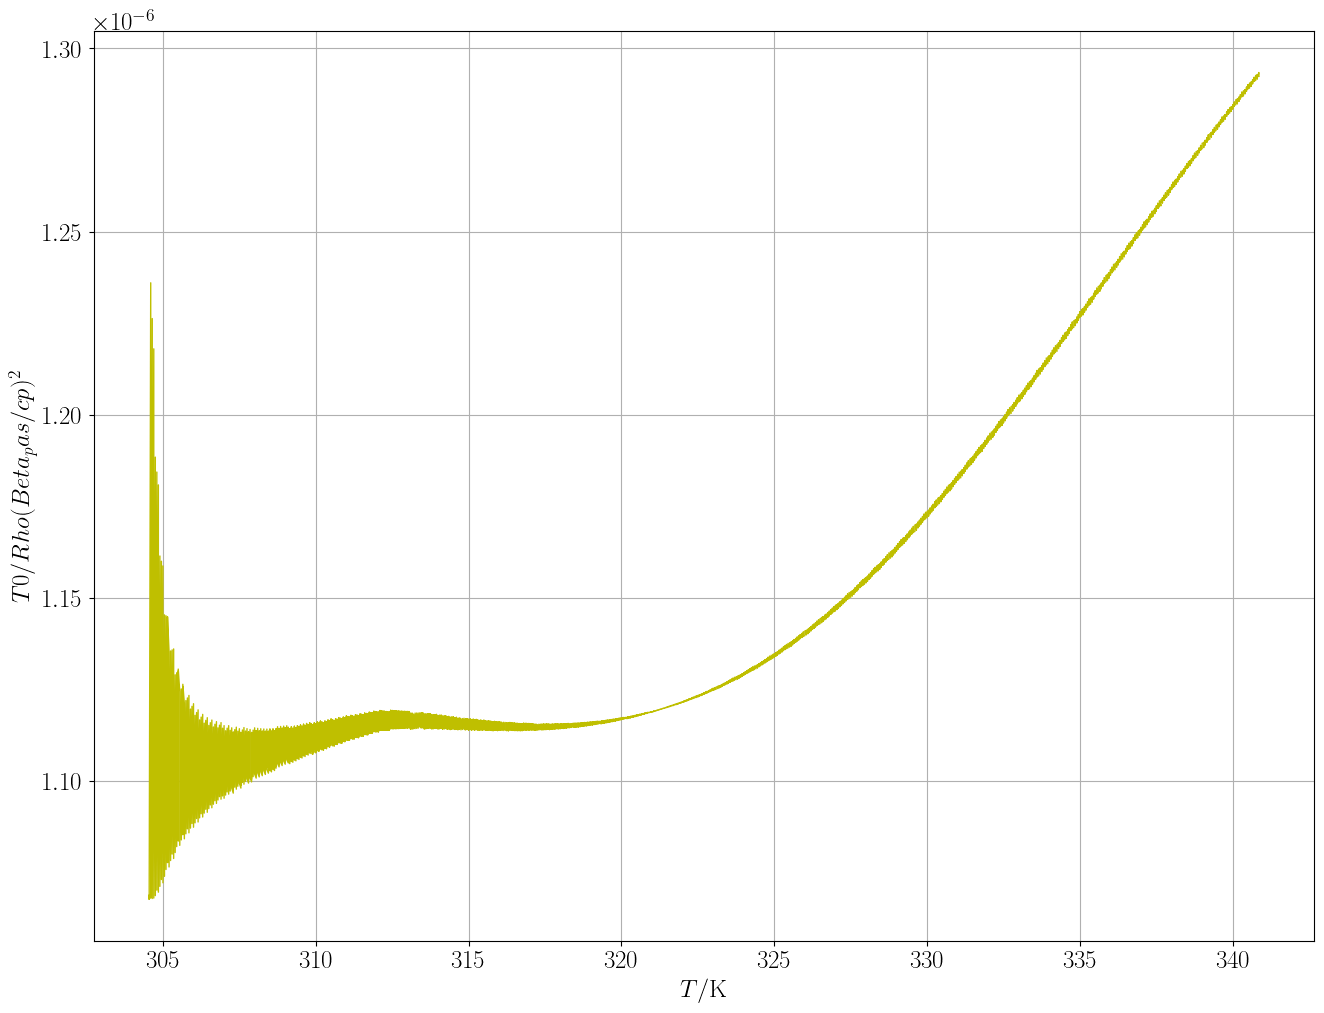

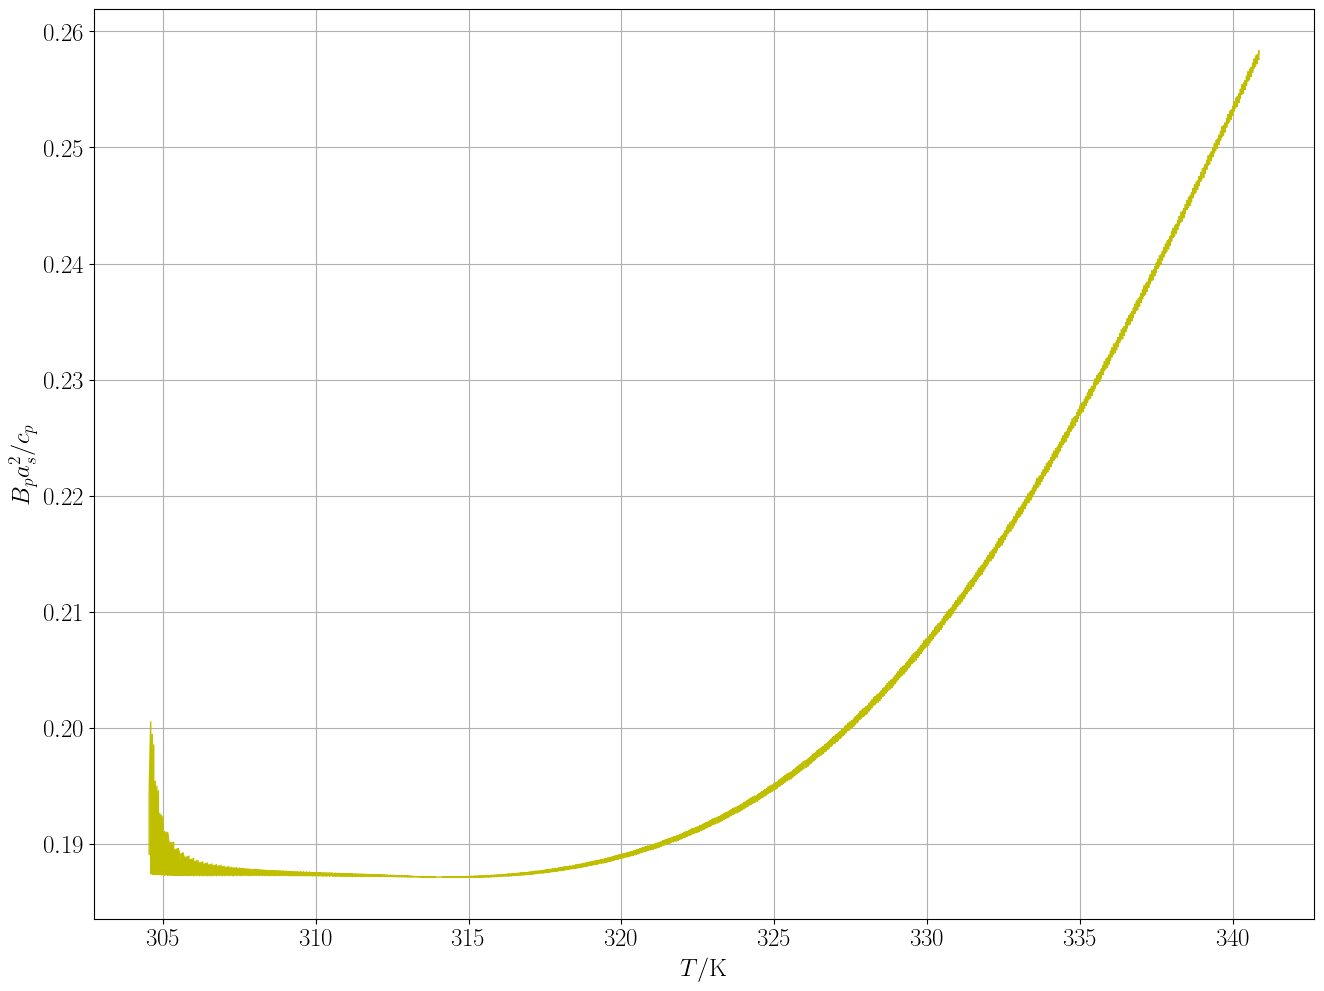

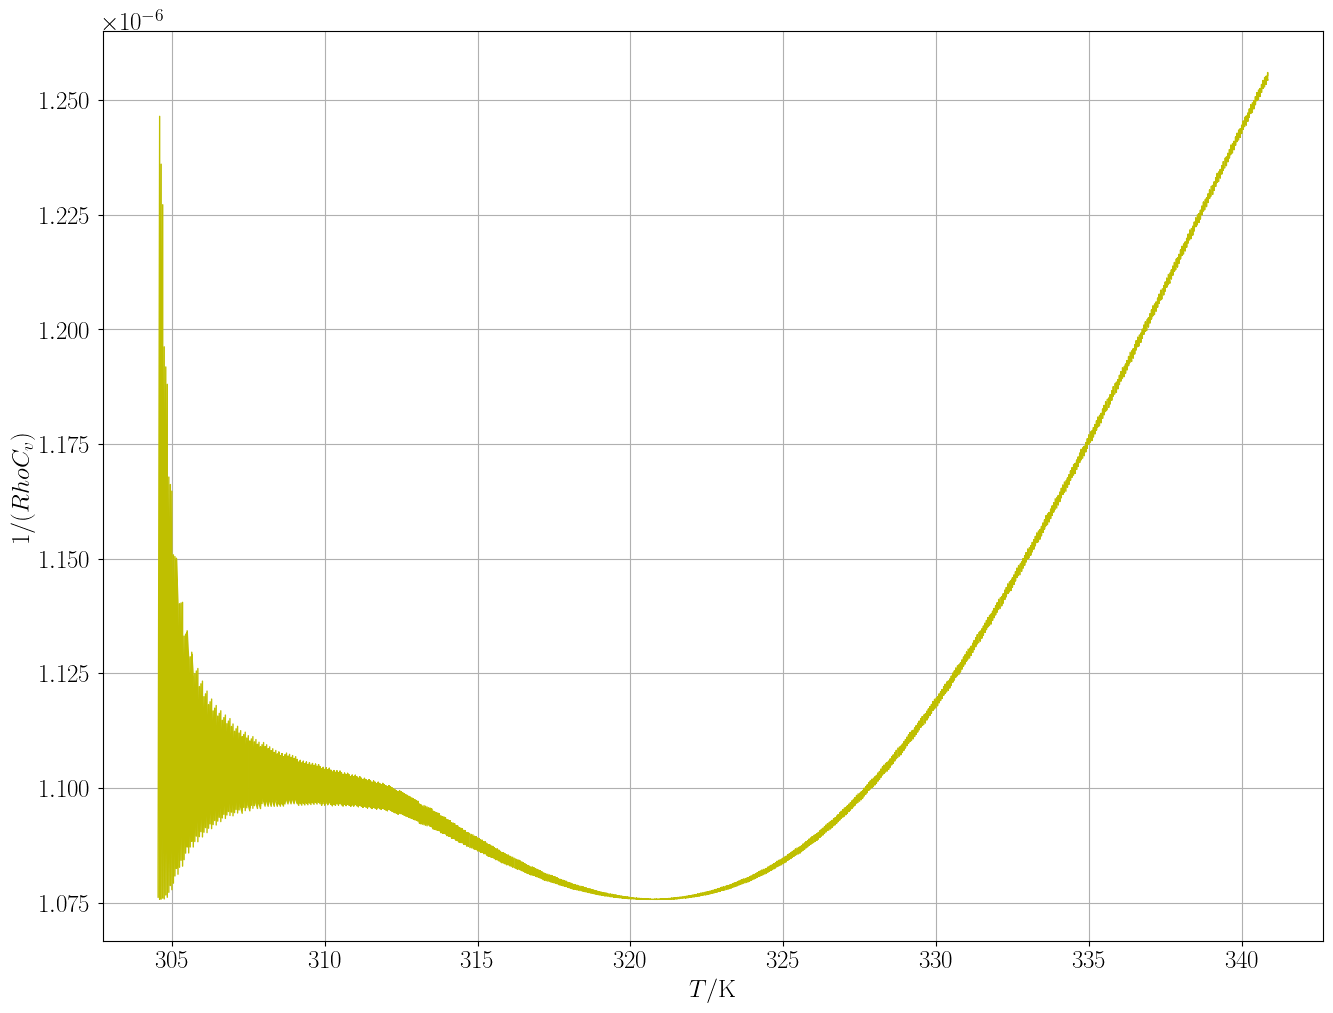

In [97]:
plt.figure(figsize=(40/2.54,30/2.54))
plt.plot(pts_T_betap_Z,Plot_1_cp,c='y', lw=1)
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ T0 / Rho (Beta_p as / cp )^2   $')
plt.xlabel(r'$ T / \rm{K} $')
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.plot(pts_T_betap_Z,Plot_2_cp,c='y', lw=1)
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ B_p a_s^2 / c_p $')
plt.xlabel(r'$ T / \rm{K} $')
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
plt.plot(pts_T_betap_Z,Plot_3_cp,c='y', lw=1)
axes = plt.gca()
plt.grid()
plt.ylabel(r'$1 / (RhoC_v) $')
plt.xlabel(r'$ T / \rm{K} $')
plt.show()

# Chapter 6 - Anyagjellemzők vs NIST

In [98]:

os.chdir('D:/School/7. Félév/Szakdolgozat/NIST')

p_list = [0.8*Pc, 1.05*Pc, 1.2*Pc, 1.35*Pc, 1.5*Pc]

# First read one file to know how many T points we have
with open(f"NIST_CO_2_290_K_486_0.txt", 'r') as f:
    csvReader = list(csv.reader(f, delimiter='\t'))
nT = len(csvReader) - 1

# Preallocate arrays with shape [nPressures, nT]
T_NIST     = np.zeros((len(p_list), nT))
p_NIST     = np.zeros((len(p_list), nT))
rho_sup    = np.zeros((len(p_list), nT))
v_sup      = np.zeros((len(p_list), nT))
e_sup      = np.zeros((len(p_list), nT))
h_sup      = np.zeros((len(p_list), nT))
s_sup      = np.zeros((len(p_list), nT))
c_v_sup    = np.zeros((len(p_list), nT))
c_p_sup    = np.zeros((len(p_list), nT))
a_s_sup    = np.zeros((len(p_list), nT))
mu_JT_sup  = np.zeros((len(p_list), nT))
eta_sup    = np.zeros((len(p_list), nT))
lam_sup    = np.zeros((len(p_list), nT))

# Loop over pressure cases
for i in range(len(p_list)): #len(p_list)
    filename = f"NIST_CO_2_290_K_486_{i}.txt"
    with open(filename, 'r') as f:
        csvReader = list(csv.reader(f, delimiter='\t'))
        nT = len(csvReader) - 1

    for j in range(nT):
        row = csvReader[j+1]  # skip header
        T_NIST[i,j]    = float(row[0])
        p_NIST[i,j]    = float(row[1])
        rho_sup[i,j]   = float(row[2])
        v_sup[i,j]     = float(row[3])
        e_sup[i,j]     = float(row[4])
        h_sup[i,j]     = float(row[5])
        s_sup[i,j]     = float(row[6])
        c_v_sup[i,j]   = 1e3*float(row[7])
        c_p_sup[i,j]   = 1e3*float(row[8])
        a_s_sup[i,j]   = float(row[9])
        mu_JT_sup[i,j] = float(row[10])/1e6
        eta_sup[i,j]   = float(row[11])
        lam_sup[i,j]   = float(row[12])

#print(T_NIST[1])


In [99]:

rho_result = np.zeros((len(p_list), len(T_NIST[1][:-2])))


for j in tqdm(range(0,len(p_list))):
    rho_guess  = Rhoc  # starting point
    for i in range(0,len(T_NIST[1][:-2])):
        try:
            rho_result[j,len(T_NIST[1][:-2])-1-i] = newton(
                density_from_pressure,
                rho_guess,
                args=(T_NIST[1][len(T_NIST[1][:-2])-1-i], p_list[j]),
                tol=1e-6,
                maxiter=50000
            )
        except RuntimeError:
            # Fallback: if Newton fails, try a small perturbation
            rho_result[j,len(T_NIST[1][:-2])-1-i] = newton(
                density_from_pressure,
                rho_guess * 1.05,
                args=(T_NIST[1][:-2][len(T_NIST[1][:-2])-1-i], p_list[j]),
                tol=1e-6,
                maxiter=50000
            )
        rho_guess = rho_result[j,len(T_NIST[1][:-2])-1-i]
    
#ez az 1e-6 os hibahatár volt a lehető legkisebb amivel lefutott
#print(rho_result)
Lambda_result = np.zeros((len(p_list), len(T_NIST[1][:-2])))
for j in range(0,len(p_list)):
    for i in range(0,len(T_NIST[1][:-2])):
        Lambda_result[j,i] = thermal_conductivity(T_NIST[1][i],rho_result[j,i])

cp_result = np.zeros((len(p_list), len(T_NIST[1][:-2])))
for j in range(0,len(p_list)):
    for i in range(0,len(T_NIST[1][:-2])):
        cp_result[j,i] = get_cp(T_NIST[1][i],rho_result[j,i])

i=0
Alpha_sup = np.zeros((len(p_list), len(T_NIST[1][:-2])))
Alpha_result = np.zeros((len(p_list), len(T_NIST[1][:-2])))

for j in range(len(p_list)):
    for i in range(len(T_NIST[1][:-2])):
        Alpha_result[j,i] = Lambda_result[j,i] / (rho_result[j,i] * cp_result[j,i] ) 

for j in range(len(p_list)):
    for i in range(len(T_NIST[1][:-2])):
        Alpha_sup[j,i] = lam_sup[j,i] / (rho_sup[j,i] * c_p_sup[j,i] ) 

cv_result = np.zeros((len(p_list), len(T_NIST[1][:-2])))
for j in range(0,len(p_list)):
    for i in range(0,len(T_NIST[1][:-2])):
        cv_result[j,i] = get_cv(T_NIST[1][i],rho_result[j,i])

a_s_result = np.zeros((len(p_list), len(T_NIST[1][:-2])))
for j in range(0,len(p_list)):
    for i in range(0,len(T_NIST[1][:-2])):
        a_s_result[j,i] = speed_of_sound(T_NIST[1][i],rho_result[j,i])

mu_JT_result = np.zeros((len(p_list), len(T_NIST[1][:-2])))
for j in range(0,len(p_list)):
    for i in range(0,len(T_NIST[1][:-2])):
        mu_JT_result[j,i] = joule_thompson(T_NIST[1][i],rho_result[j,i])

i=0
Beta_p_result = np.zeros((len(p_list), len(T_NIST[1][:-2])))
for j in range(len(p_list)):
    for i in range(len(T_NIST[1][:-2])):
        Beta_p_result[j,i] = ( mu_JT_result[j,i] * cp_result[j,i] * rho_result[j,i] + 1 ) / T_NIST[1][i]
i=0
Beta_p_sup = np.zeros((len(p_list), len(T_NIST[0,:])))
#T_NIST_calc = np.zeros((len(p_list),len(T_NIST[0,:])))
T_NIST_calc = T_NIST[0,:-1]
for j in range(len(p_list)):
    for i in range(len(T_NIST_calc)):
        Beta_p_sup[j,i] = ( mu_JT_sup[j,i] * c_p_sup[j,i] * rho_sup[j,i] + 1 ) / T_NIST_calc[i]

i=0
Khi_T_as_result = np.zeros((len(p_list), len(T_NIST[1][:-2])))
for j in range(len(p_list)):
    for i in range(len(T_NIST[1][:-2])):
        Khi_T_as_result[j,i] = cp_result[j,i] / ( cv_result[j,i] * rho_result[j,i] * a_s_result[j,i]**2 )

i=0
Khi_T_as_sup = np.zeros((len(p_list), len(T_NIST[0,:])))
T_NIST_calc = T_NIST[0,:-1]
for j in range(len(p_list)):
    for i in range(len(T_NIST_calc)):
        Khi_T_as_sup[j,i] = c_p_sup[j,i] / ( c_v_sup[j,i] * rho_sup[j,i] * a_s_sup[j,i]**2 )
    


  0%|          | 0/5 [00:00<?, ?it/s]C:\Users\krist\AppData\Local\Temp\ipykernel_13360\1417689070.py:171: RuntimeWarning: invalid value encountered in log
  Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum
C:\Users\krist\AppData\Local\Temp\ipykernel_13360\1417689070.py:228: RuntimeWarning: overflow encountered in exp
  dFirdDelta_term2 += ni[i] * np.exp(-Delta**ci[i])*(Delta**(di[i]-1)*Tau**ti[i]*(di[i]-ci[i]*Delta**ci[i]))
100%|██████████| 5/5 [00:02<00:00,  1.70it/s]
C:\Users\krist\AppData\Local\Temp\ipykernel_13360\1300329035.py:89: RuntimeWarning: invalid value encountered in scalar divide
  Khi_T_as_sup[j,i] = c_p_sup[j,i] / ( c_v_sup[j,i] * rho_sup[j,i] * a_s_sup[j,i]**2 )


## rho

RuntimeError: latex was not able to process the following string:
b'$0.80 p_c - calculated'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpmgp2nncy b823532d53b5981eca793fe3c86c8d67.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./b823532d53b5981eca793fe3c86c8d67.tex
LaTeX2e <2025-11-01>
L3 programming layer <2025-11-14>
(c:/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(c:/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(c:/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(c:/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(c:/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(c:/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(c:/texlive/2025/texmf-dist/tex/latex/geometry/geometry.sty
(c:/texlive/2025

<Figure size 1574.8x1181.1 with 1 Axes>

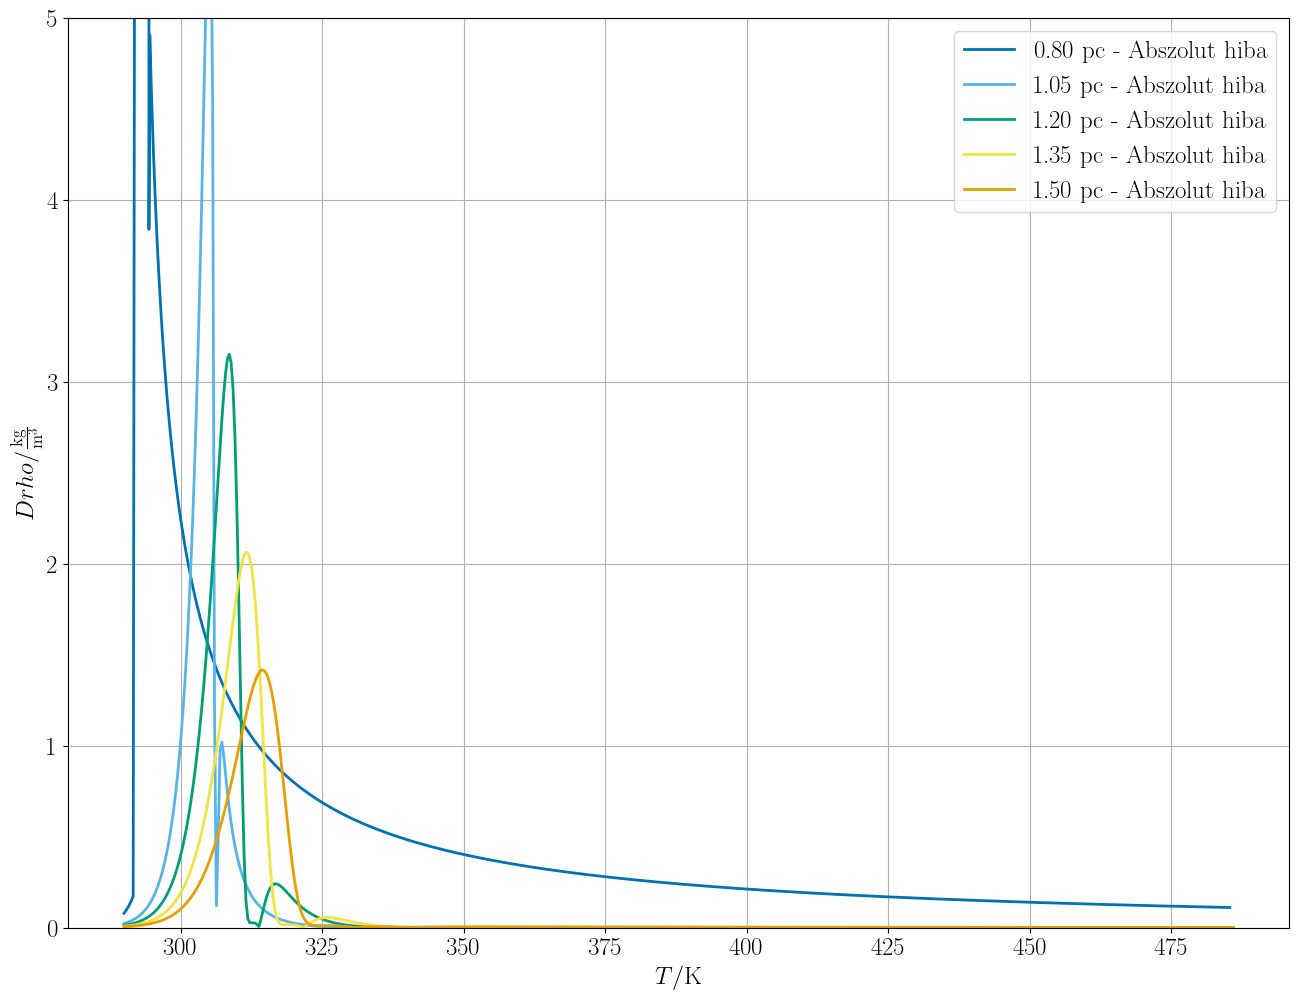

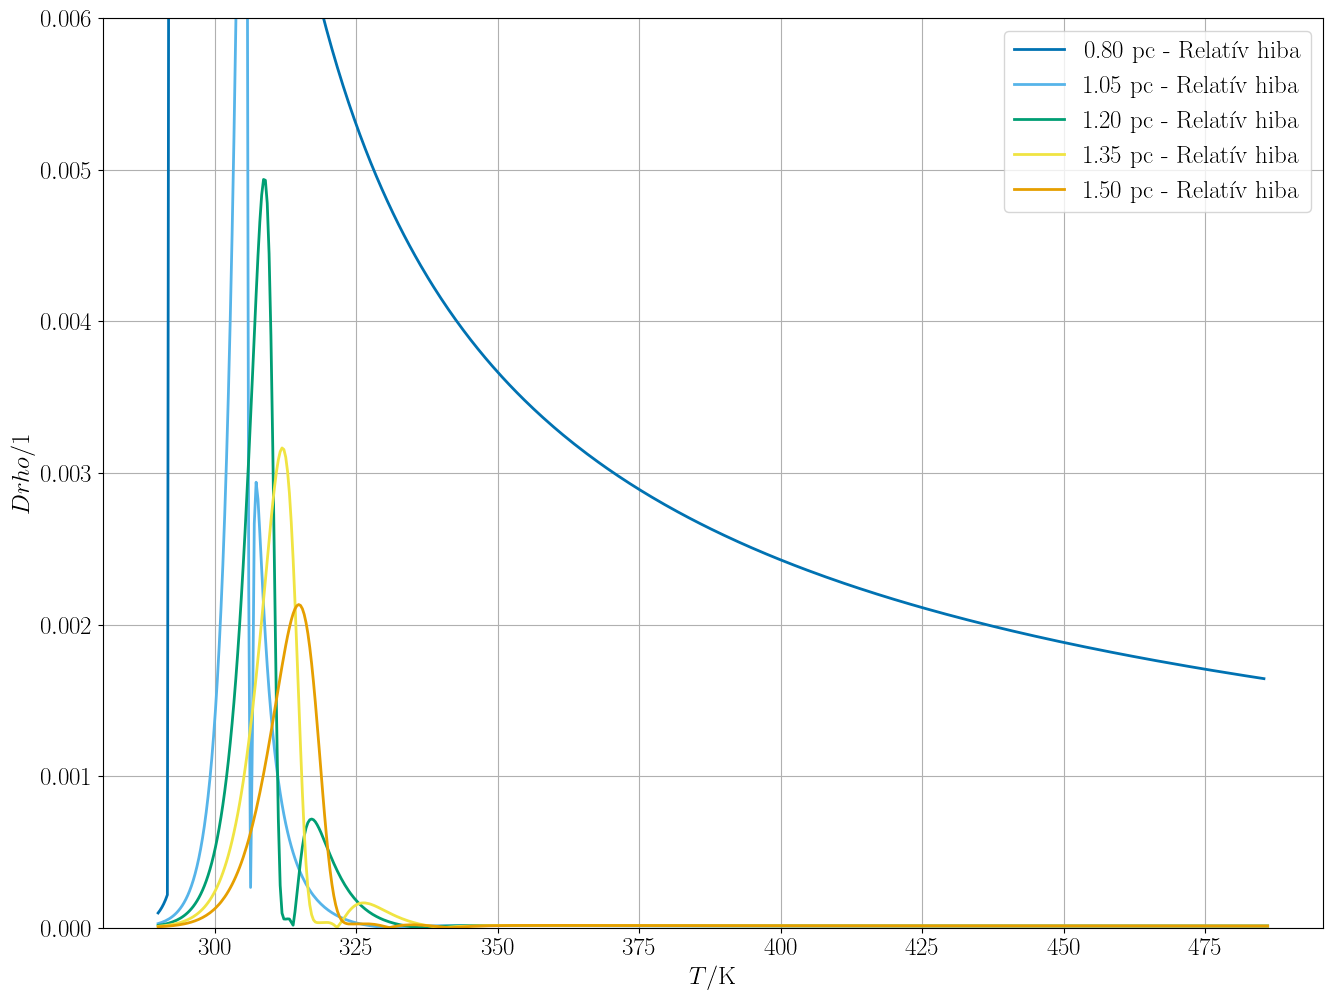

In [100]:
cbforange = (230/255, 159/255, 0/255)
cbfmagenta = (204/255, 121/255, 167/255)
cbfyellow = (240/255, 228/255, 66/255)
cbflightblue = (86/255, 180/255, 233/255)
cbfgreen = (0/255, 158/255, 115/255)
cbfblue = (0/255, 114/255, 178/255) 
cbfred = (213/255, 94/255, 0/255)

rainbow = [cbfblue,cbflightblue,cbfgreen,cbfyellow,cbforange,cbfred]
greys   = [(229/255, 228/255, 226/255),(192/255, 192/255, 192/255),(169/255, 169/255, 169/255),(128/255, 128/255, 128/255),(0,0,0)]

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],rho_sup[i,:-2],lw=2, color=rainbow[i], linestyle='-', label=f'${p_list[i]/Pc:.2f} p_c - NIST$')
#ITT MELLÉ PLOTOLOM A SAJÁT SZÁMÍTÁSOMAT SZAGGTOTT VONALLAL
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],rho_result[i,:],'k',lw=2,ls=(0, (5, 10)), label=f'${p_list[i]/Pc:.2f} p_c - calculated')
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \rho / \rm{\frac{kg}{m^3}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.show()

#ABSZOLUT HIBA
plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(rho_sup[i,:-2]-rho_result[i,:]),lw=2, color=rainbow[i],  linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Abszolut hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ Drho / \rm{\frac{kg}{m^3}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,5)
plt.show()

#RELATÍV HIBA
plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(rho_sup[i,:-2]-rho_result[i,:]) / np.abs(rho_sup[i,:-2]),lw=2,  color=rainbow[i],linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Relatív hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ Drho / \rm{1} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,0.006)
plt.show()






## lambda

<Figure size 1574.8x1181.1 with 0 Axes>

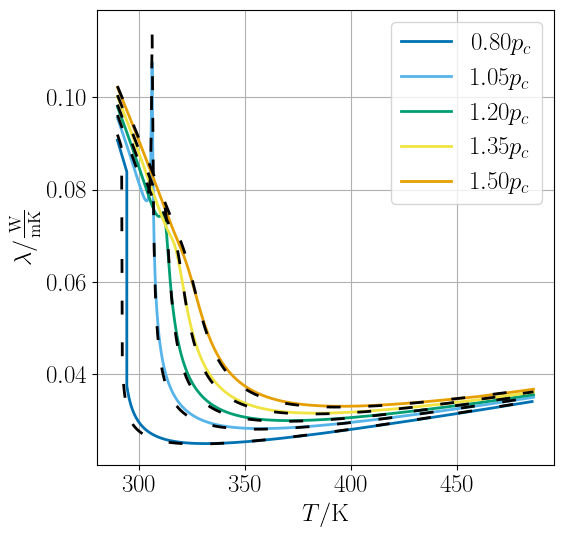

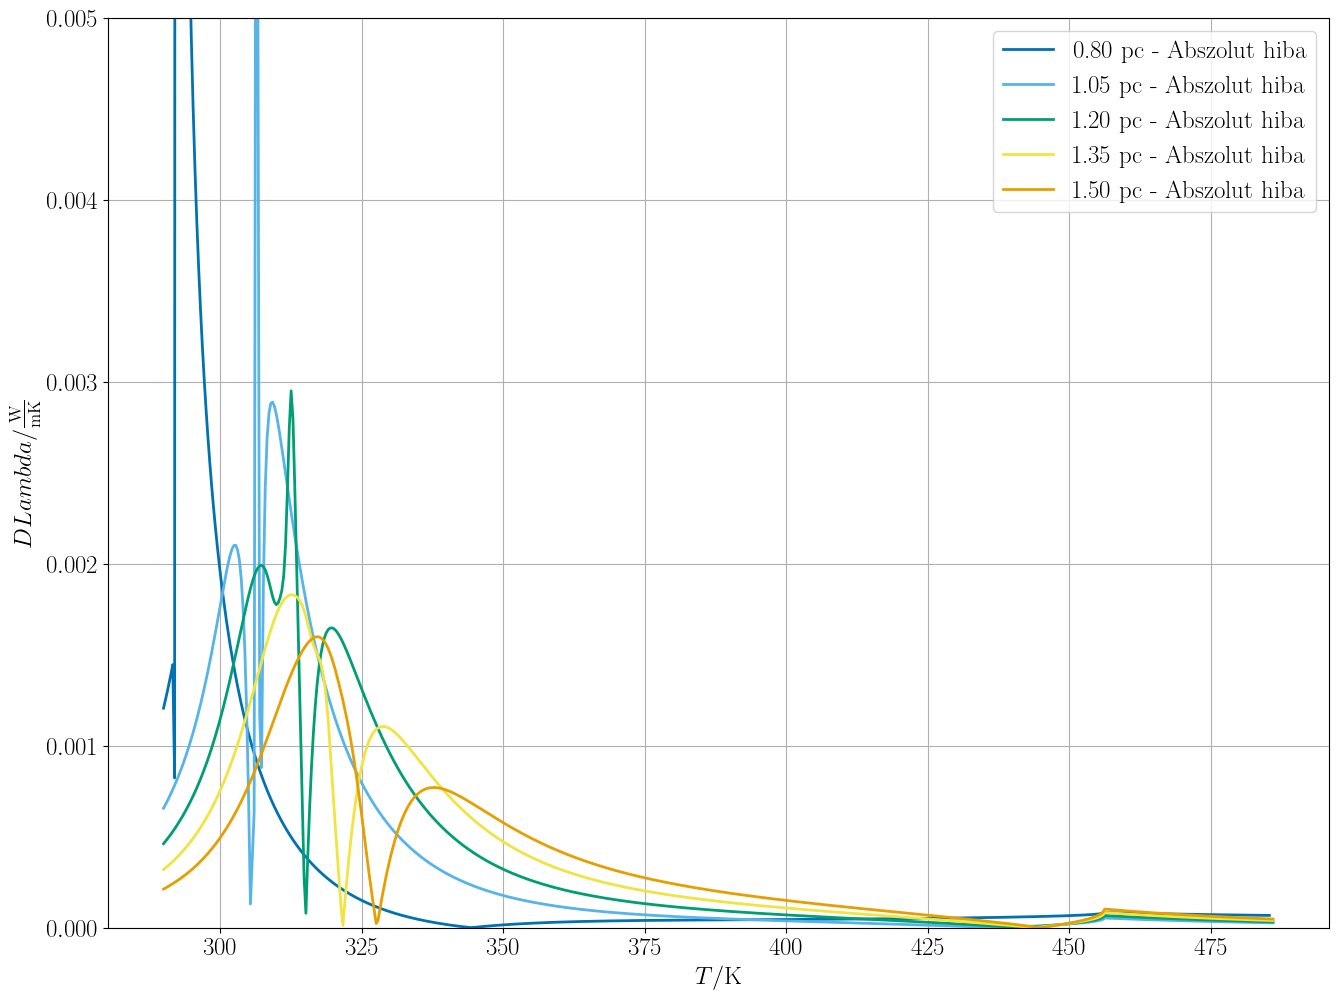

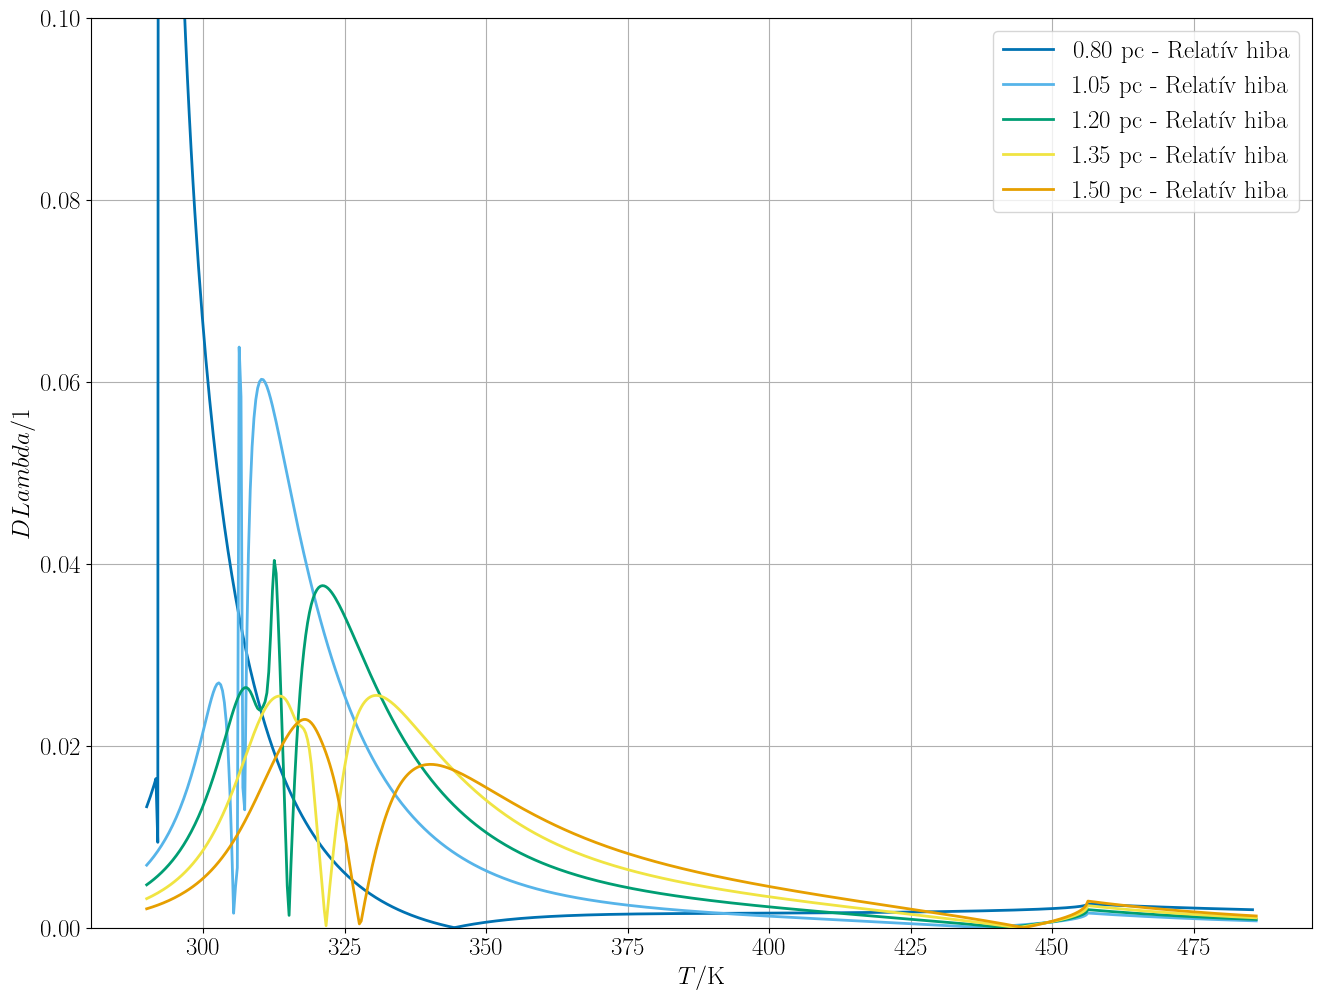

In [101]:
plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],lam_sup[i,:-2],lw=2, color=rainbow[i], linestyle='-', label=f'${p_list[i]/Pc:.2f} p_c$')# - NIST")
#ITT MELLÉ PLOTOLOM A SAJÁT SZÁMÍTÁSOMAT SZAGGTOTT VONALLAL
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],Lambda_result[i,:],color='k',lw=2,ls=(0, (5, 10)) )#,label=f"{p_list[i]/Pc:.2f} pc - számolt")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \lambda / \rm{\frac{W}{m K}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/lambda_vs_nist.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(lam_sup[i,:-2]-Lambda_result[i,:]),lw=2,color=rainbow[i] , linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Abszolut hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ DLambda / \rm{\frac{W}{mK}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,0.005)
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(lam_sup[i,:-2]-Lambda_result[i,:]) / np.abs(lam_sup[i,:-2]),lw=2,color=rainbow[i] ,  linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Relatív hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ DLambda / \rm{1} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,0.1)
plt.show()


## cp

<Figure size 1574.8x1181.1 with 0 Axes>

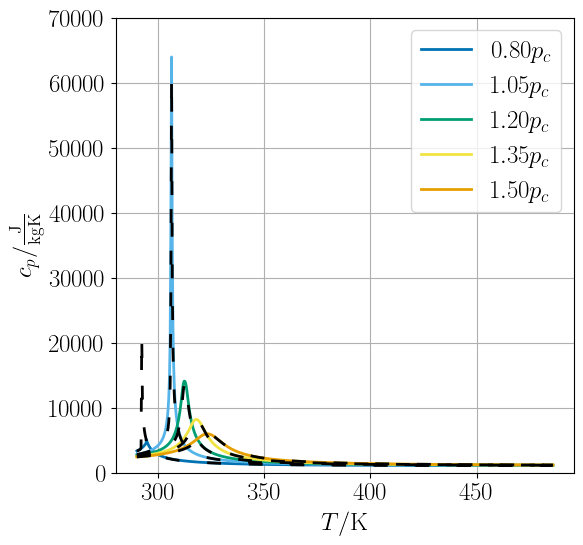

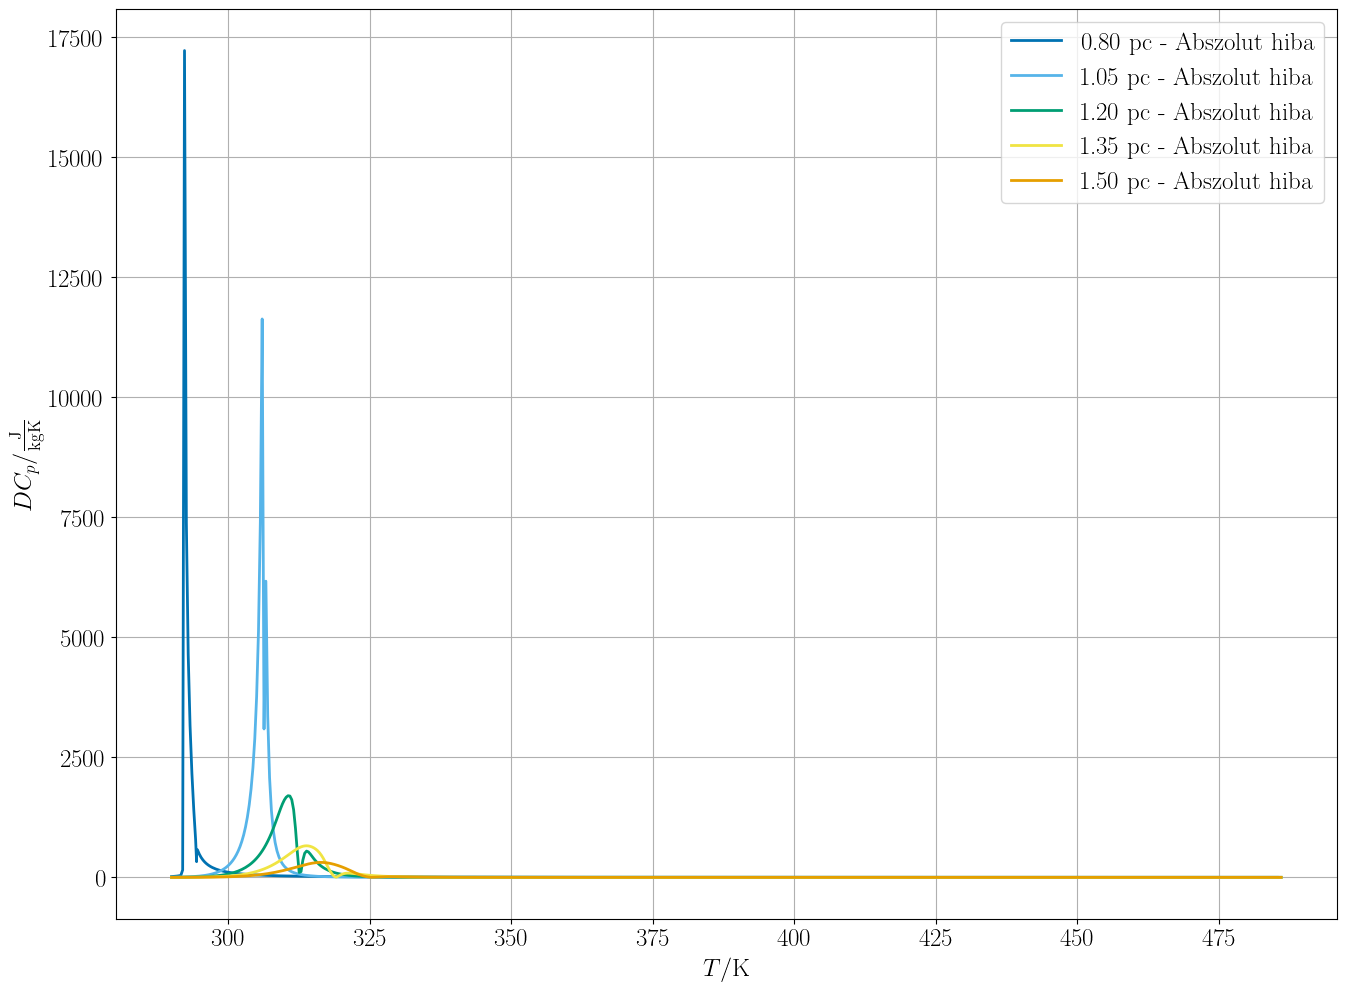

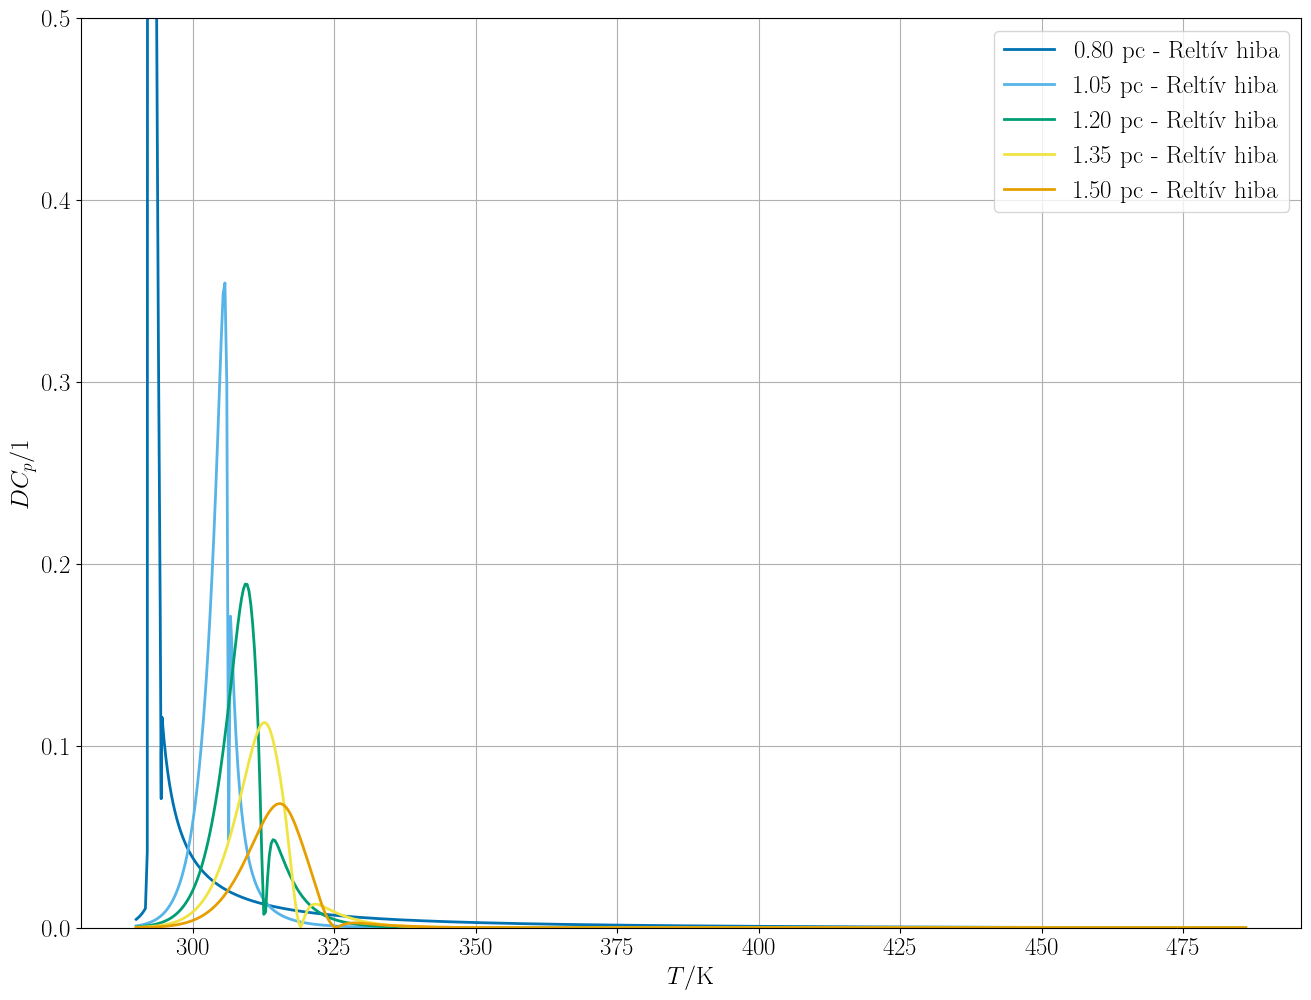

In [102]:
plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],c_p_sup[i,:-2],lw=2, color=rainbow[i], linestyle='-', label=f'${p_list[i]/Pc:.2f} p_c$')# - NIST")
#ITT MELLÉ PLOTOLOM A SAJÁT SZÁMÍTÁSOMAT SZAGGTOTT VONALLAL
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],cp_result[i,:],'k',lw=2,ls=(0, (5, 10)))#, label=f"{p_list[i]/Pc:.2f} pc - számolt")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ c_p / \rm{\frac{J}{kg K}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,70000)
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/cp_vs_nist.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(c_p_sup[i,:-2]-cp_result[i,:]),lw=2,  color=rainbow[i],linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Abszolut hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ DC_p / \rm{\frac{J}{kgK}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
#plt.ylim(-0.0075,0.004)
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(c_p_sup[i,:-2]-cp_result[i,:]) / np.abs(c_p_sup[i,:-2]),lw=2, color=rainbow[i], linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Reltív hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ DC_p / \rm{1} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,0.5)
plt.show()


## alpha

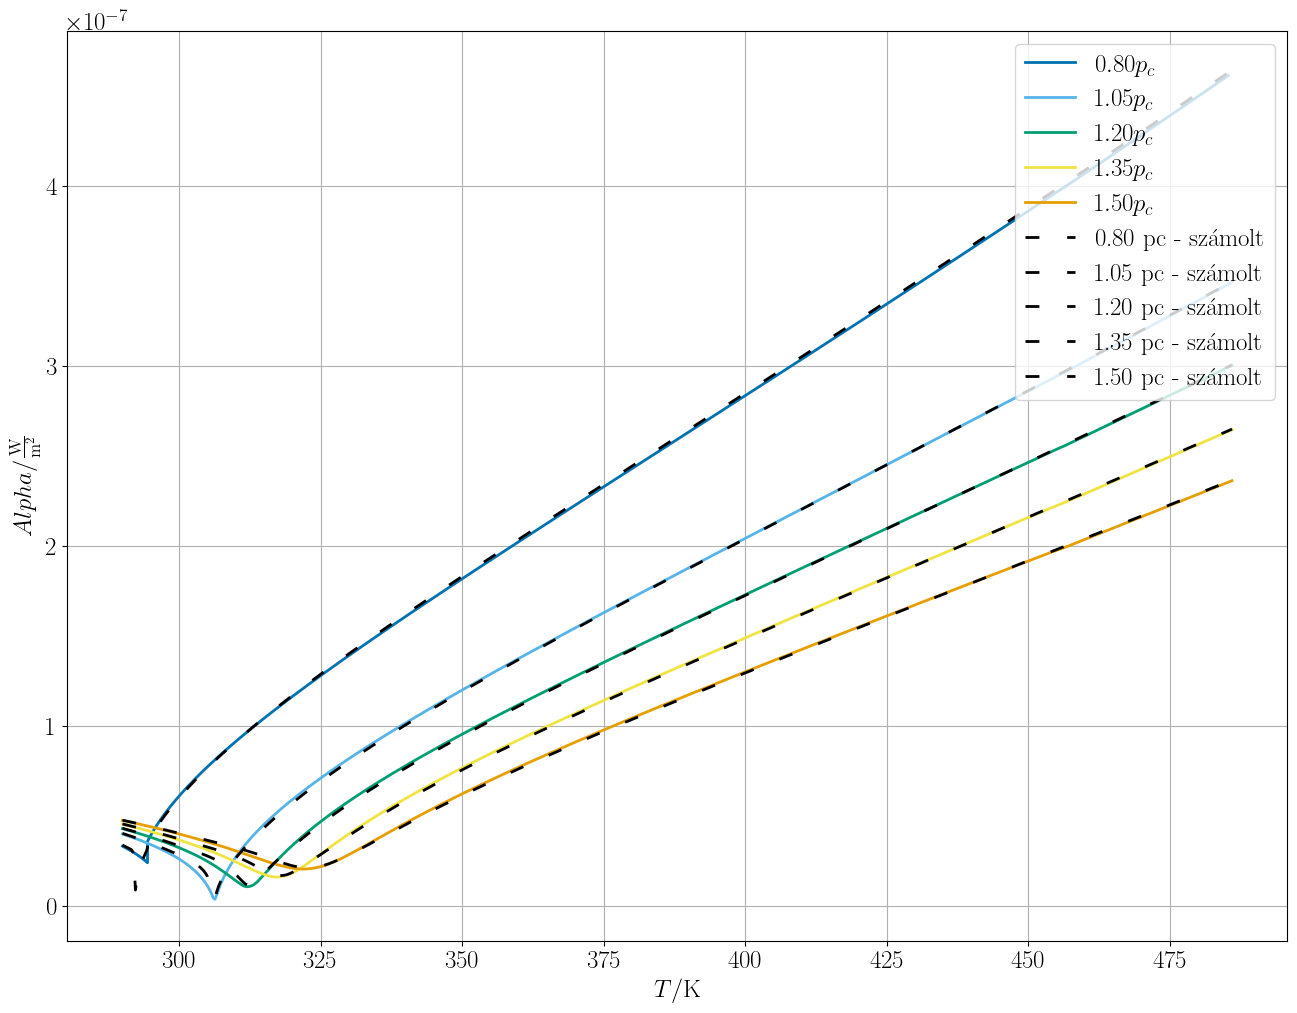

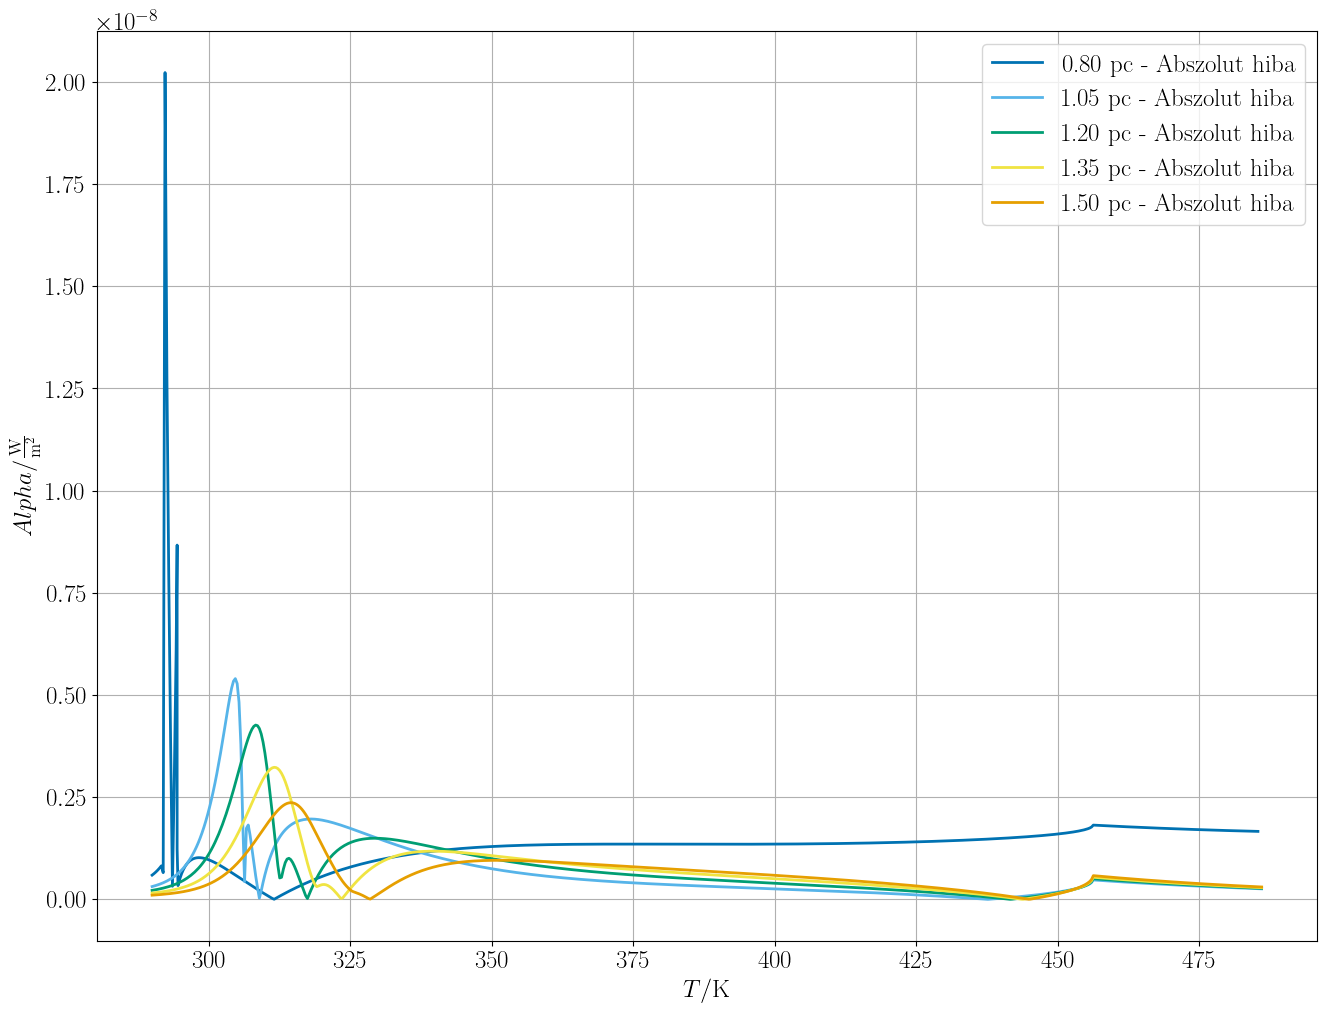

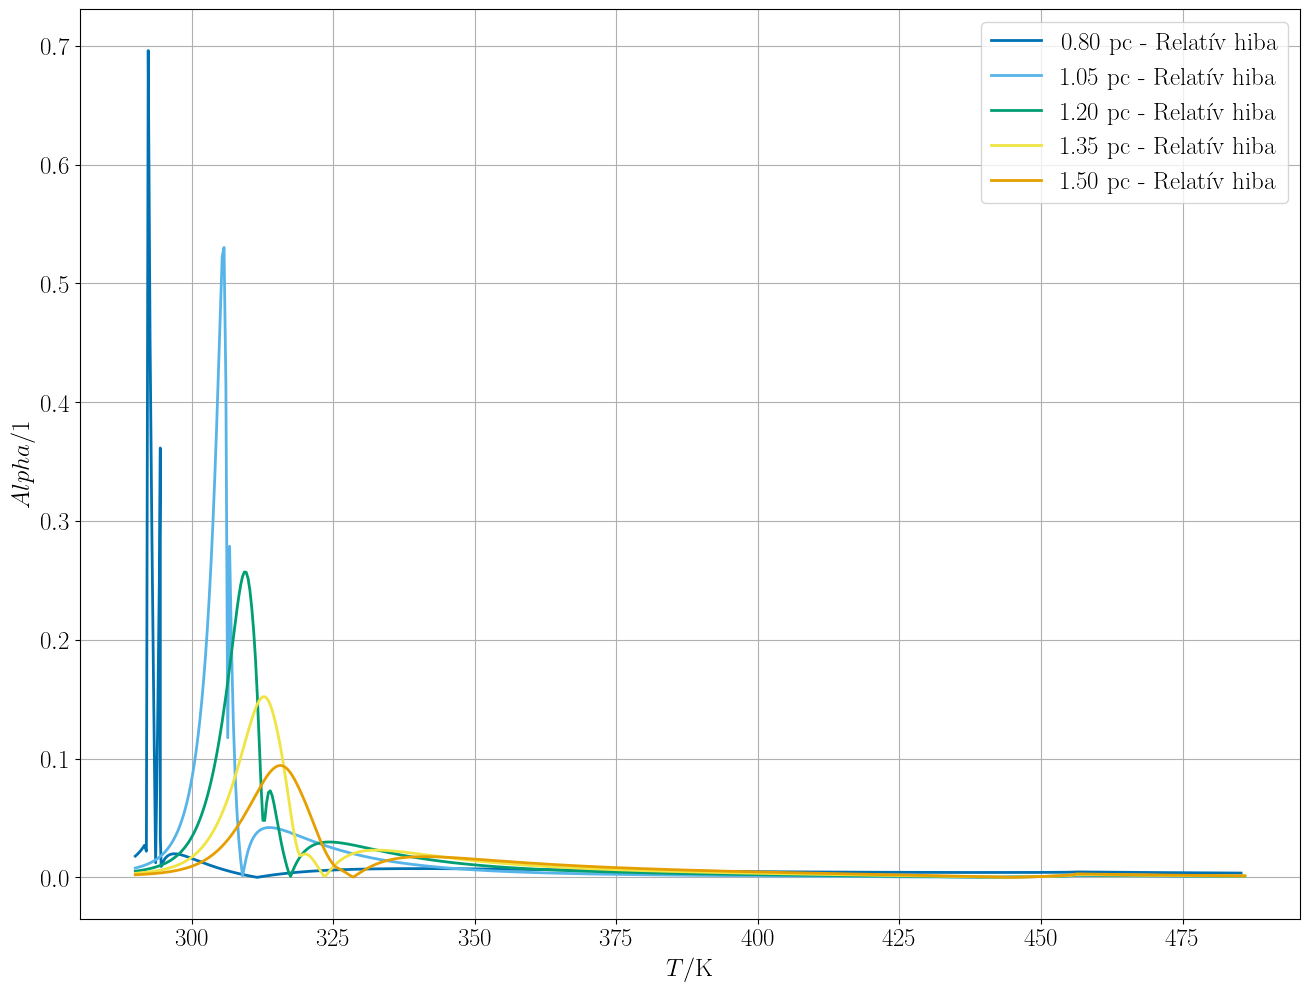

In [103]:
plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],Alpha_sup[i,:],lw=2,color=rainbow[i],  linestyle='-', label=f'${p_list[i]/Pc:.2f} p_c$')
#ITT MELLÉ PLOTOLOM A SAJÁT SZÁMÍTÁSOMAT SZAGGTOTT VONALLAL
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],Alpha_result[i,:],'k',lw=2,ls=(0, (5, 10)), label=f"{p_list[i]/Pc:.2f} pc - számolt")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ Alpha / \rm{\frac{W}{m^2}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
#plt.ylim(0,70000)
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(Alpha_sup[i,:]-Alpha_result[i,:]),lw=2, color=rainbow[i], linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Abszolut hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ Alpha / \rm{\frac{W}{m^2}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
#plt.ylim(0,70000)
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(Alpha_sup[i,:]-Alpha_result[i,:]) / np.abs(Alpha_sup[i,:]) ,lw=2, color=rainbow[i], linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Relatív hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ Alpha / \rm{1} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
#plt.ylim(0,70000)
plt.show()







## cv

<Figure size 1574.8x1181.1 with 0 Axes>

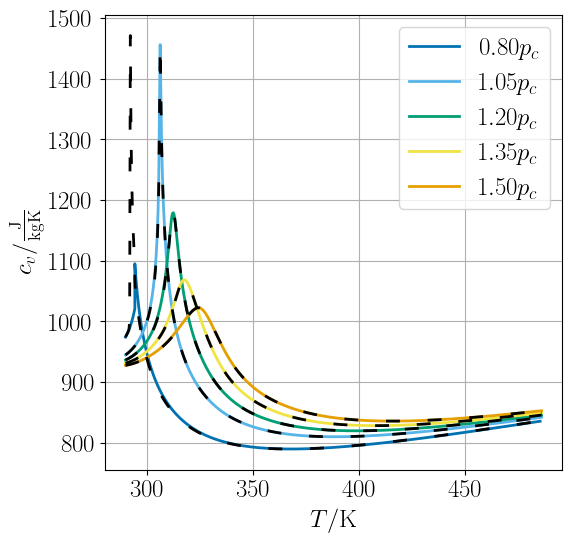

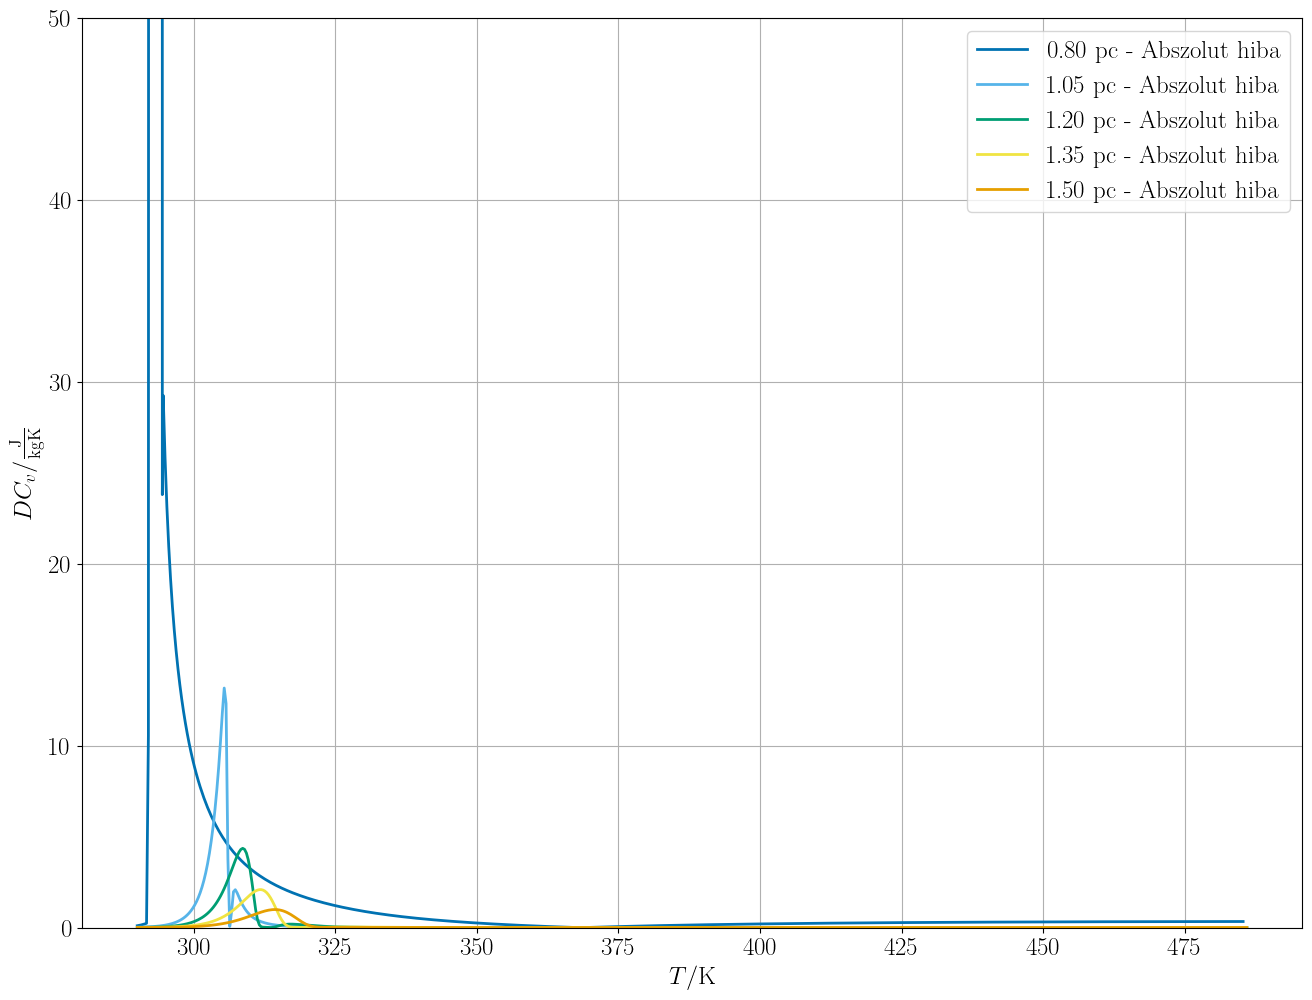

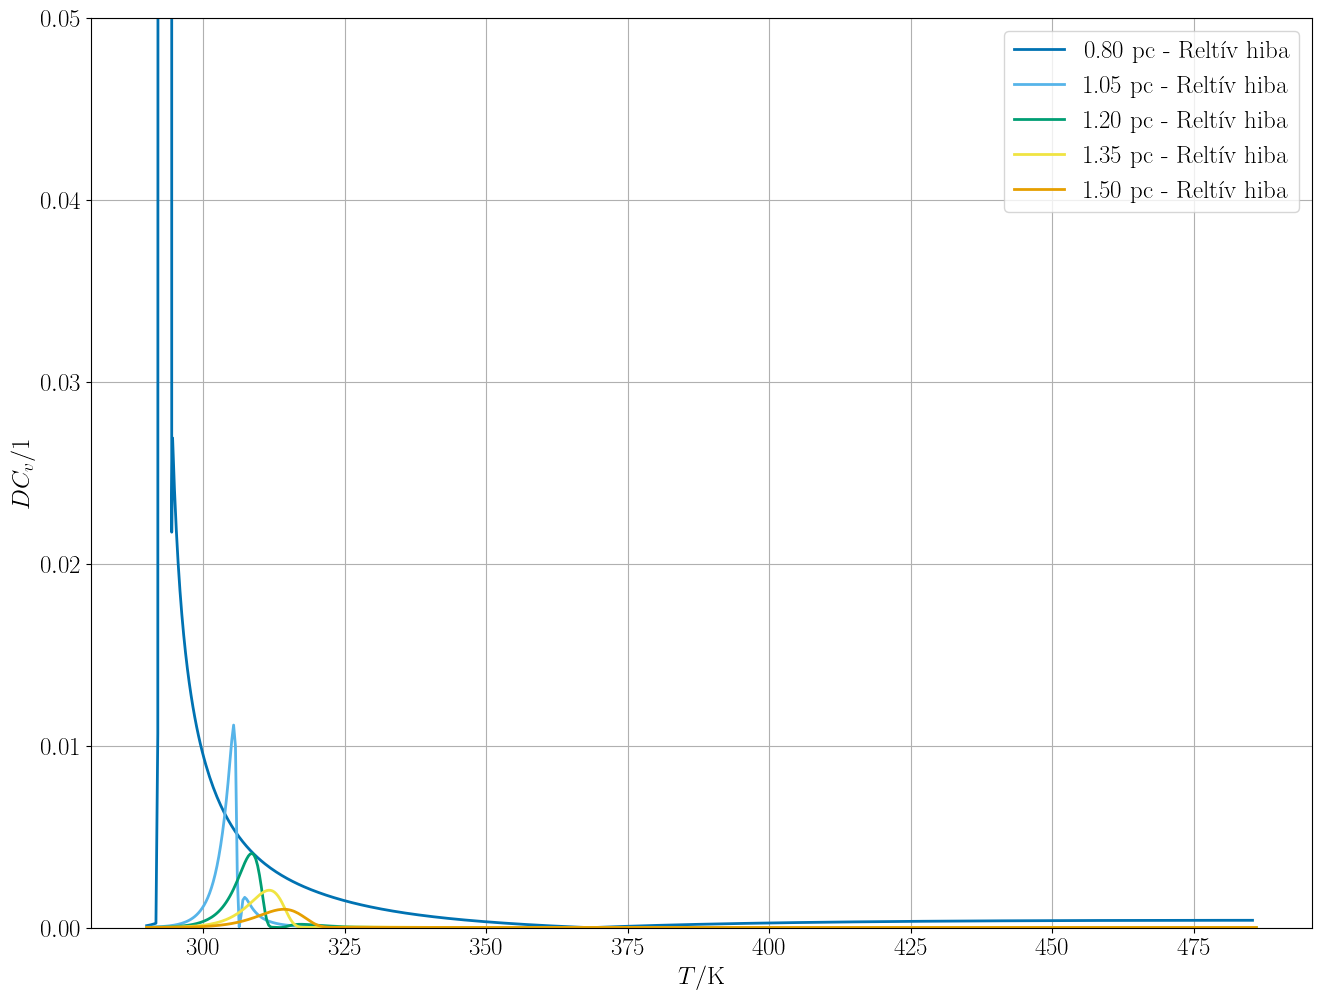

In [104]:
plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],c_v_sup[i,:-2],lw=2, color=rainbow[i], linestyle='-', label=f'${p_list[i]/Pc:.2f} p_c$')# - NIST")
#ITT MELLÉ PLOTOLOM A SAJÁT SZÁMÍTÁSOMAT SZAGGTOTT VONALLAL
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],cv_result[i,:],'k',lw=2,ls=(0, (5, 10)))#, label=f"{p_list[i]/Pc:.2f} pc - számolt")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ c_v / \rm{\frac{J}{kg K}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
#plt.ylim(0,1500)
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/cv_vs_nist.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(c_v_sup[i,:-2]-cv_result[i,:]),lw=2,color=rainbow[i],  linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Abszolut hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ DC_v / \rm{\frac{J}{kgK}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,50)
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(c_v_sup[i,:-2]-cv_result[i,:]) / np.abs(c_v_sup[i,:-2]),lw=2,color=rainbow[i],  linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Reltív hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ DC_v / \rm{1} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,0.05)
plt.show()









## as

<Figure size 1574.8x1181.1 with 0 Axes>

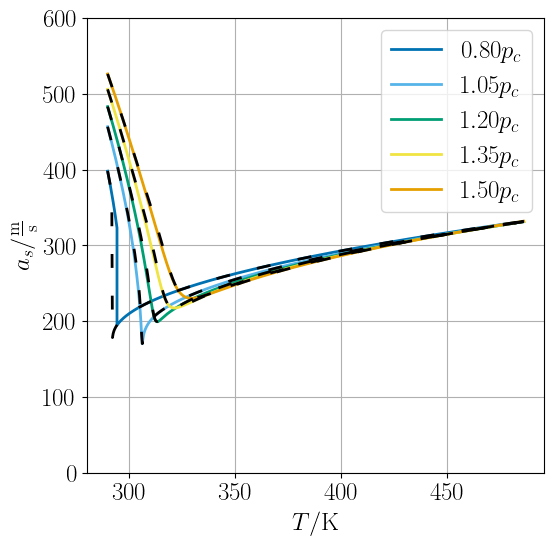

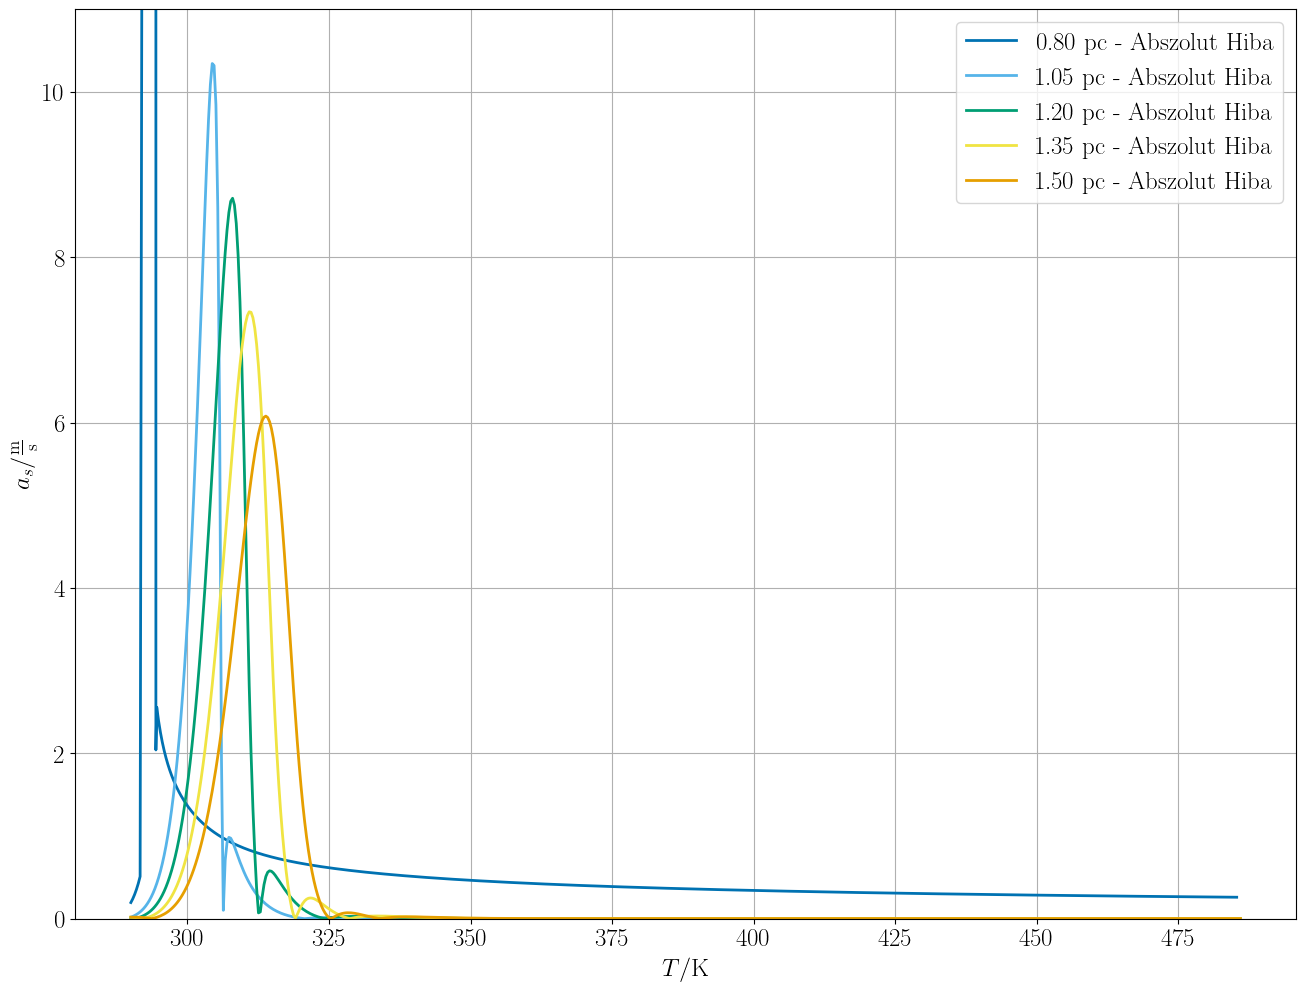

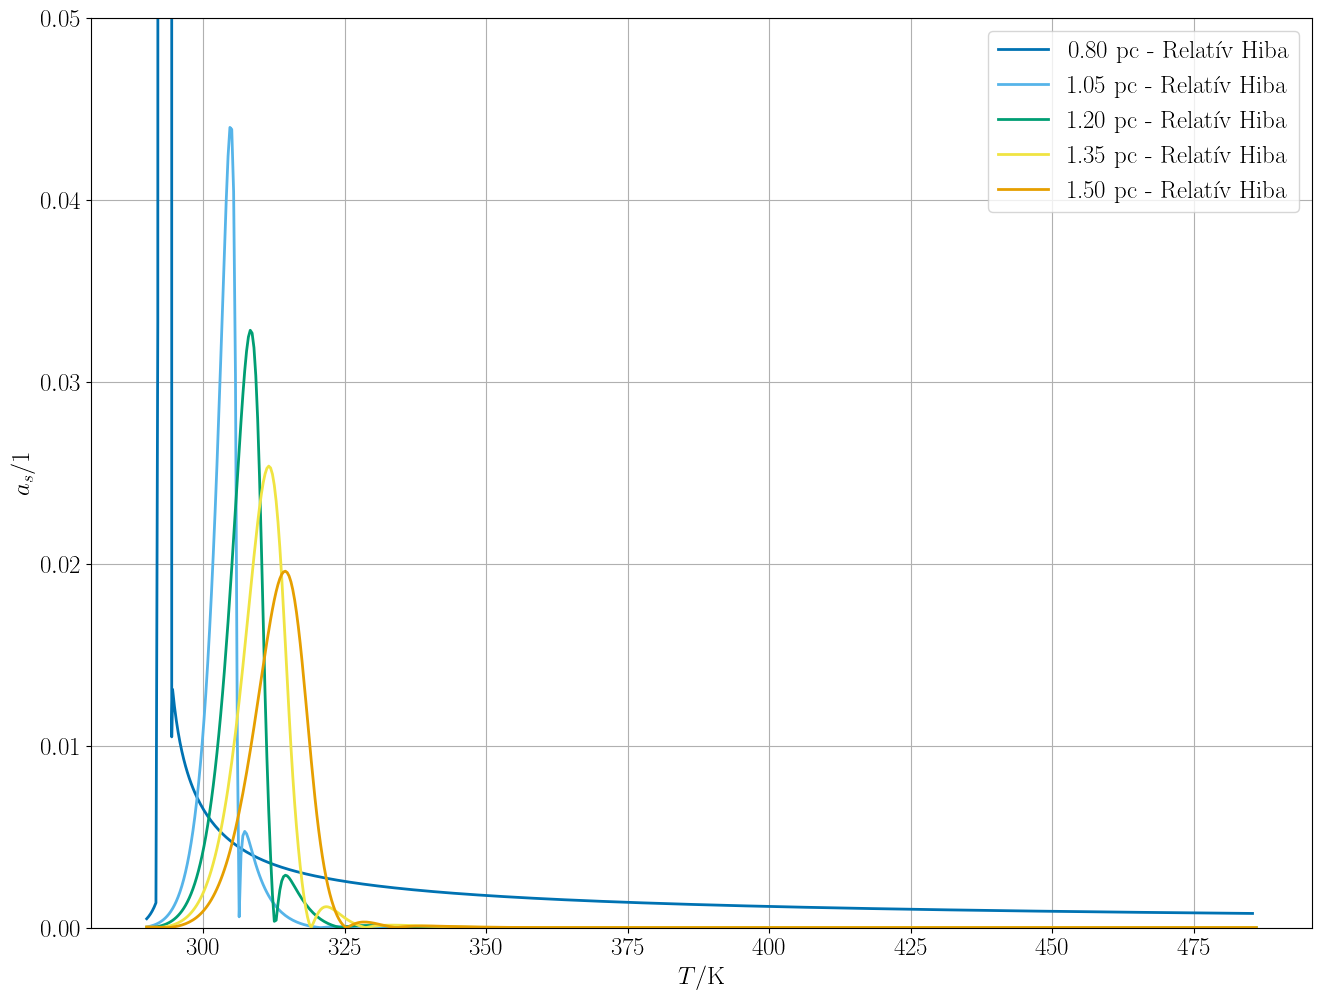

In [105]:
plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],a_s_sup[i,:-2],lw=2,  color=rainbow[i],linestyle='-', label=f'${p_list[i]/Pc:.2f} p_c$')# - NIST")
#ITT MELLÉ PLOTOLOM A SAJÁT SZÁMÍTÁSOMAT SZAGGTOTT VONALLAL
for i in range(len(p_list)):
    plt.plot(T_NIST[1,:-2],a_s_result[i,:],'k',lw=2,ls=(0, (5, 10)))#, label=f"{p_list[i]/Pc:.2f} pc - számolt")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ a_s / \rm{\frac{m}{s}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,600)
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/as_vs_nist.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(a_s_sup[i,:-2]-a_s_result[i,:]),lw=2,  linestyle='-', color=rainbow[i],label=f"{p_list[i]/Pc:.2f} pc - Abszolut Hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ a_s / \rm{\frac{m}{s}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,11)
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(a_s_sup[i,:-2]-a_s_result[i,:]) / np.abs(a_s_sup[i,:-2]),lw=2,  color=rainbow[i],linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Relatív Hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ a_s / \rm{1} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,0.05)
plt.show()





muJT

<Figure size 1574.8x1181.1 with 0 Axes>

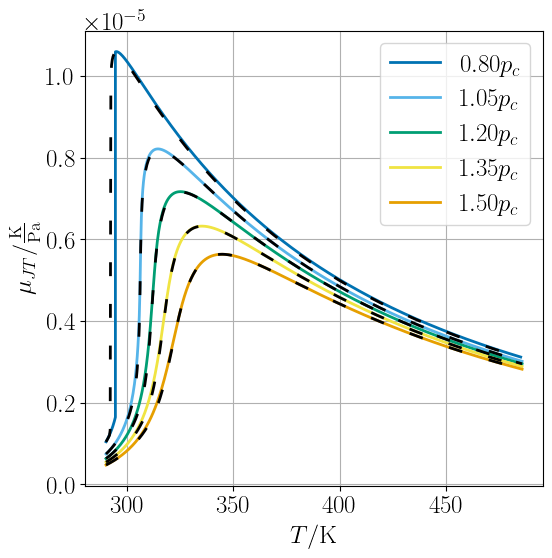

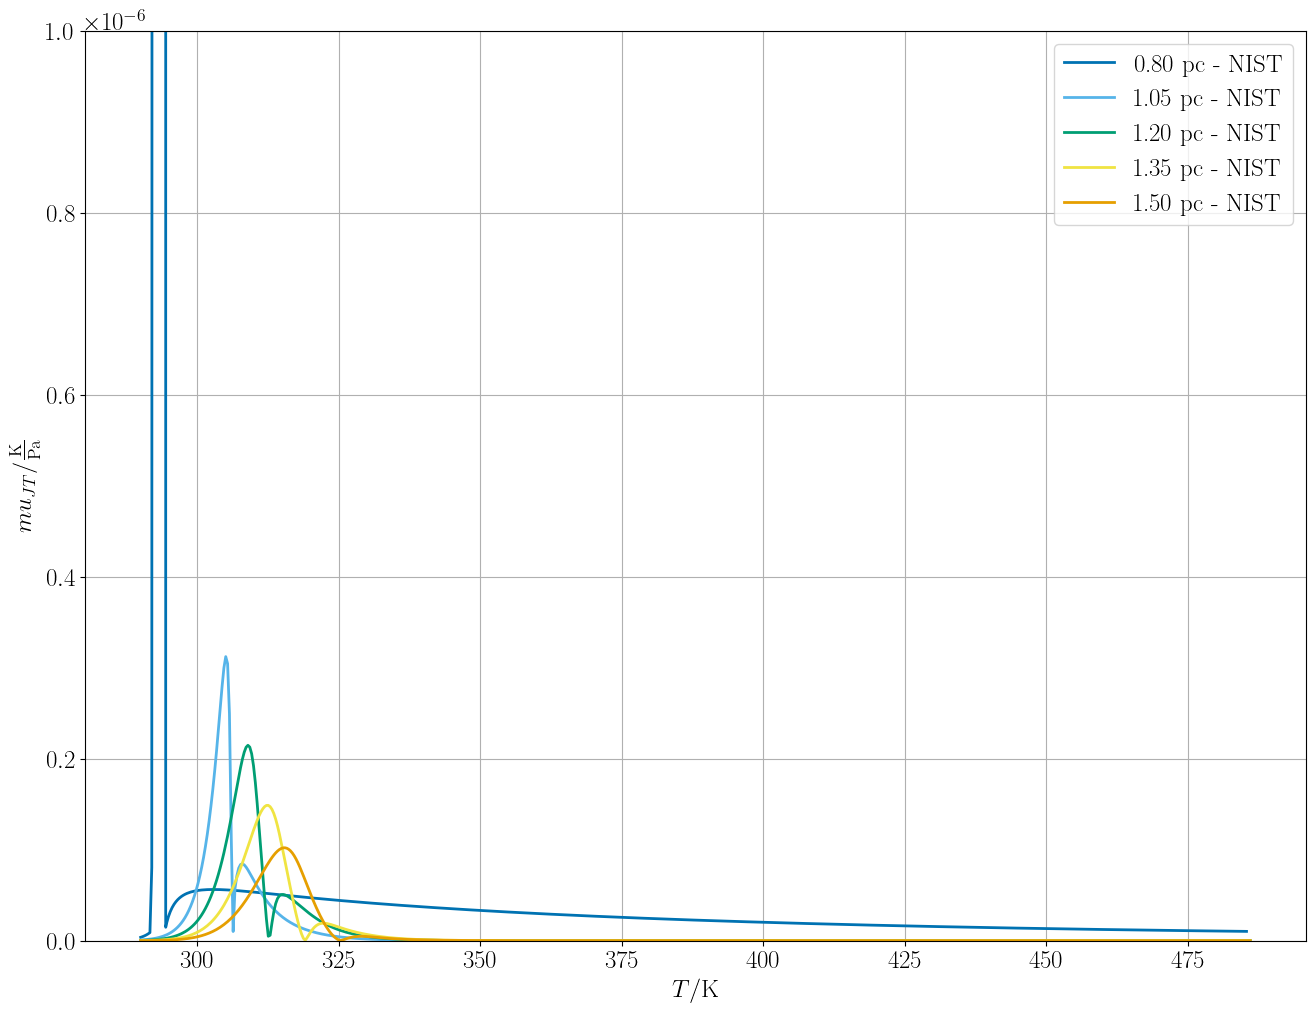

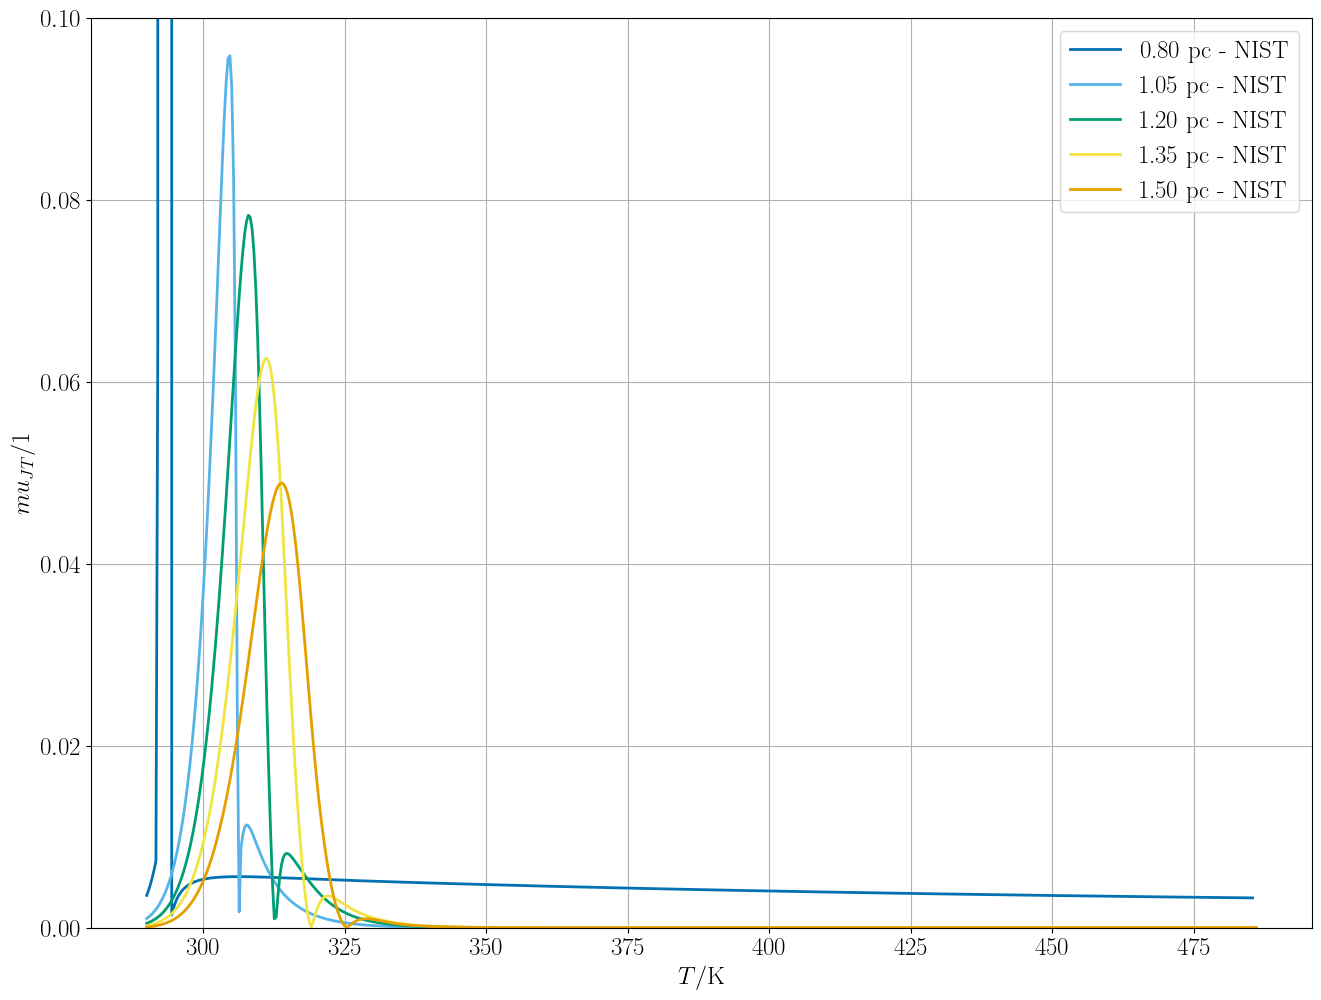

In [106]:
plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],mu_JT_sup[i,:-2],lw=2, color=rainbow[i], linestyle='-', label=f'${p_list[i]/Pc:.2f} p_c$')# - NIST")
#ITT MELLÉ PLOTOLOM A SAJÁT SZÁMÍTÁSOMAT SZAGGTOTT VONALLAL
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],mu_JT_result[i,:],'k',lw=2,ls=(0, (5, 10)))#, label=f"{p_list[i]/Pc:.2f} pc - számolt")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \mu_{JT} / \rm{\frac{K}{Pa}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
#plt.ylim(0,600)
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/JT_vs_nist.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(mu_JT_sup[i,:-2]-mu_JT_result[i,:]),lw=2, color=rainbow[i], linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - NIST")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ mu_{JT} / \rm{\frac{K}{Pa}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,1e-6)
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(mu_JT_sup[i,:-2]-mu_JT_result[i,:]) / np.abs(mu_JT_sup[i,:-2]),lw=2, color=rainbow[i], linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - NIST")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ mu_{JT} / \rm{1} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,0.1)
plt.show()









## Bp

<Figure size 1574.8x1181.1 with 0 Axes>

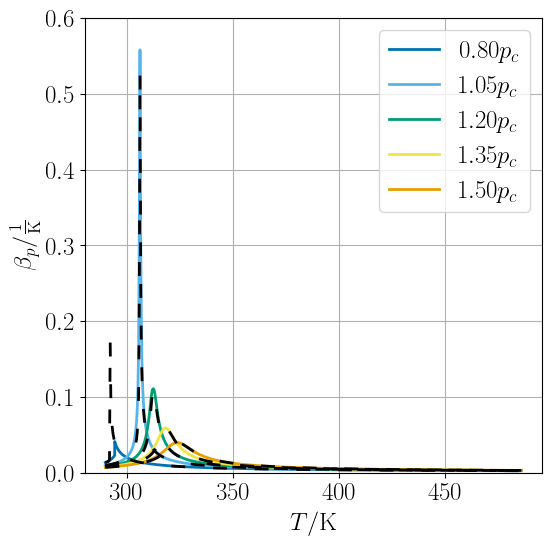

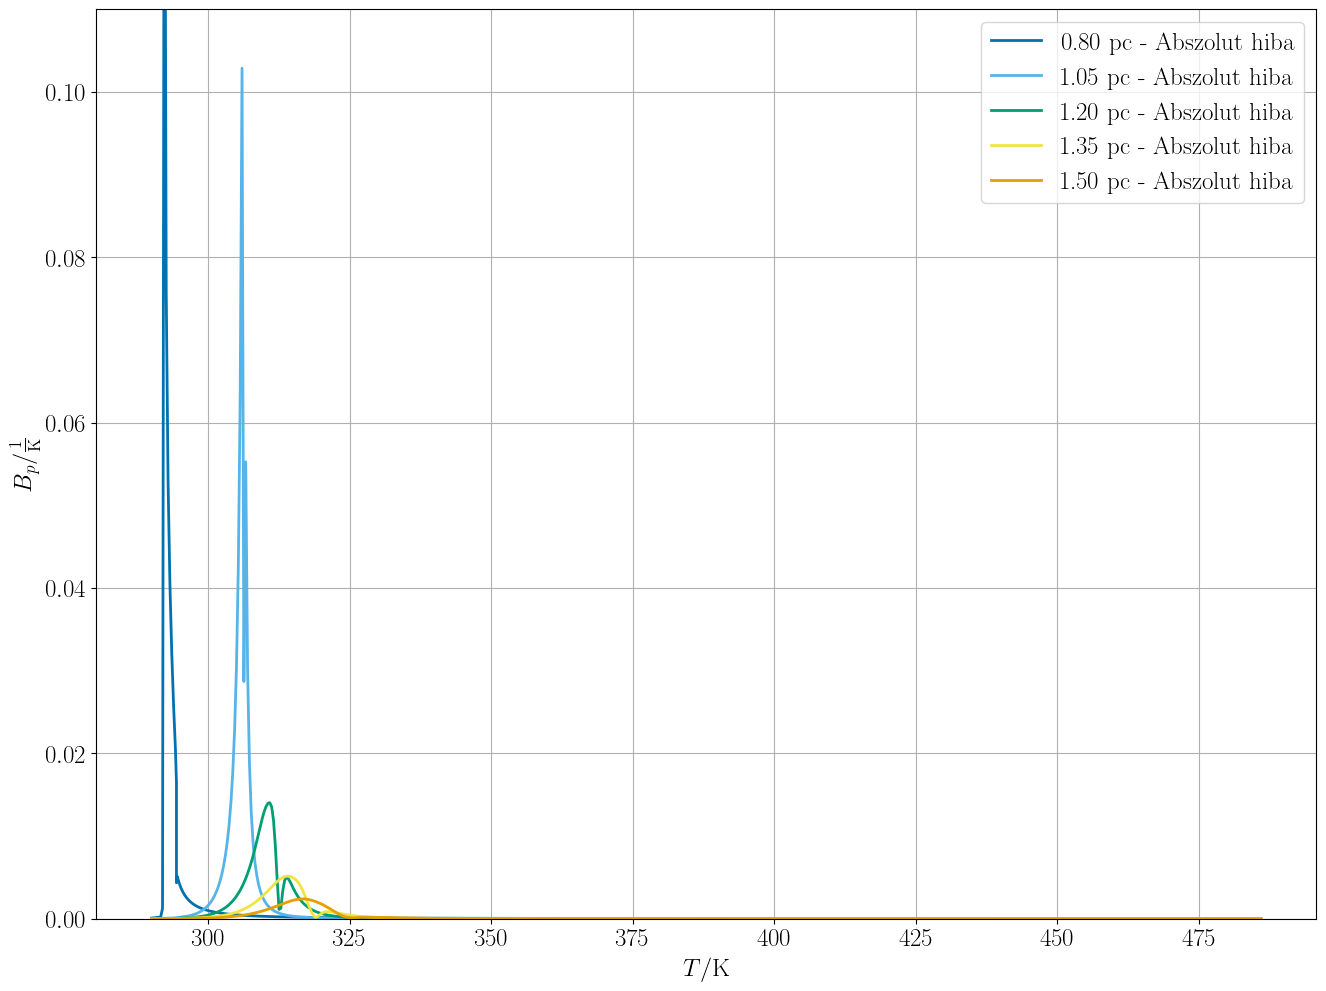

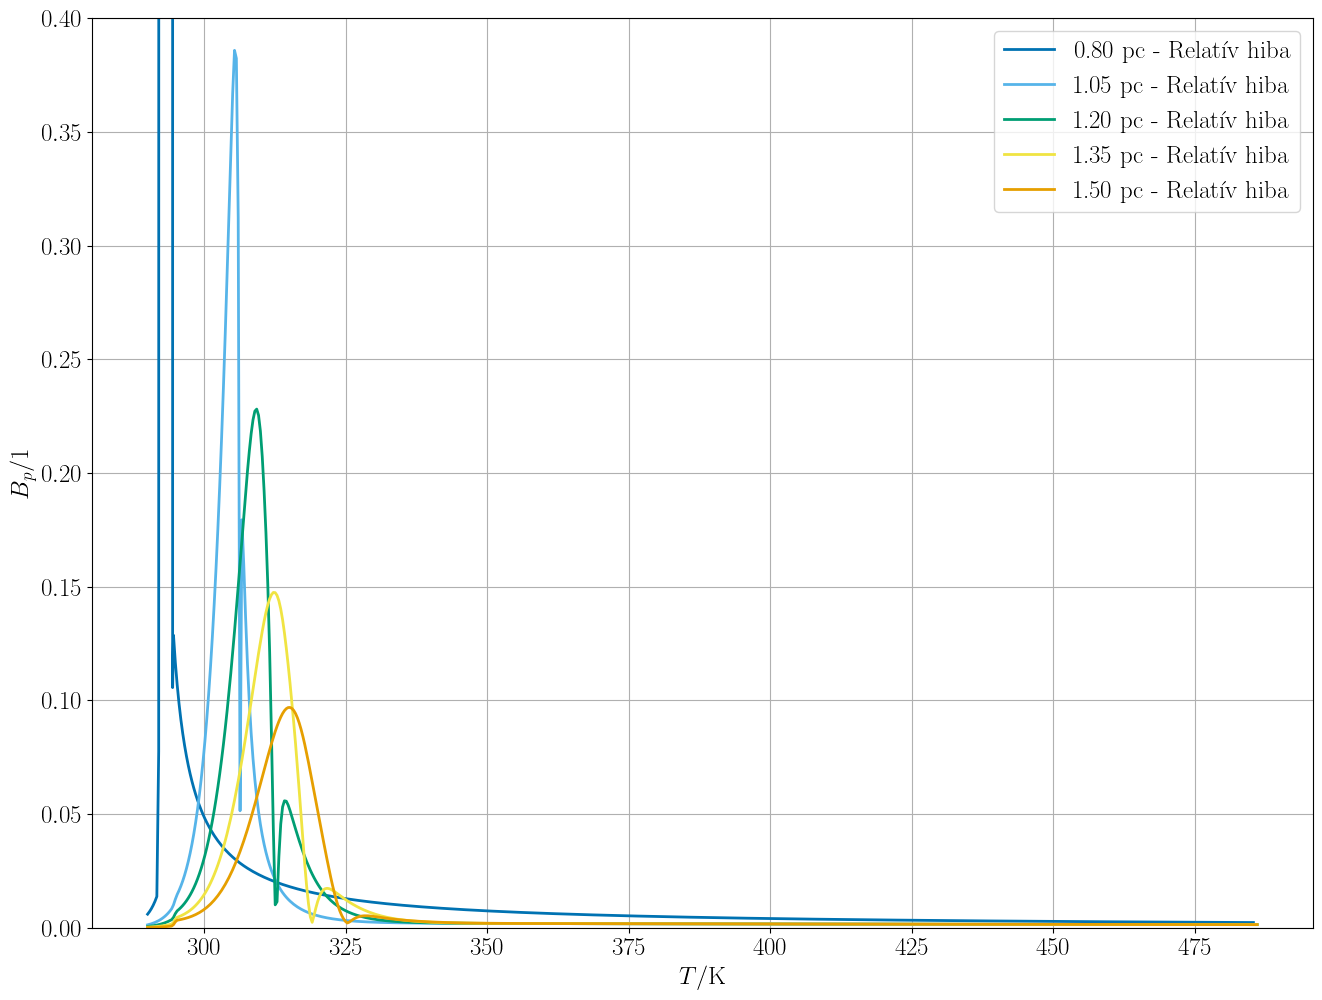

In [107]:
plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],Beta_p_sup[i,:-2],lw=2, color=rainbow[i], linestyle='-', label=f'${p_list[i]/Pc:.2f} p_c$')# - NIST")
#ITT MELLÉ PLOTOLOM A SAJÁT SZÁMÍTÁSOMAT SZAGGTOTT VONALLAL
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],Beta_p_result[i,:],'k',lw=2,ls=(0, (5, 10)))#, label=f"{p_list[i]/Pc:.2f} pc - számolt")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \beta_{p} / \rm{\frac{1}{K}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,0.6)
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/betap_vs_nist.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(Beta_p_sup[i,:-2]-Beta_p_result[i,:]),lw=2, color=rainbow[i], linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Abszolut hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ B_{p} / \rm{\frac{1}{K}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,0.11)
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(Beta_p_sup[i,:-2]-Beta_p_result[i,:]) / np.abs(Beta_p_sup[i,:-2]),lw=2,  color=rainbow[i],linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - Relatív hiba")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ B_{p} / \rm{1} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,0.4)
plt.show()










## KhiT

<Figure size 1574.8x1181.1 with 0 Axes>

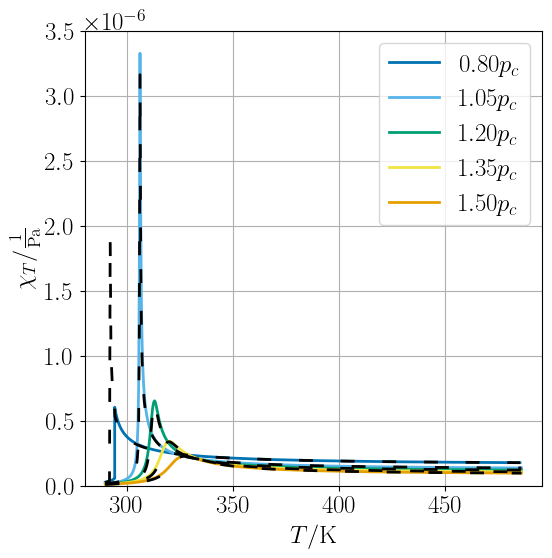

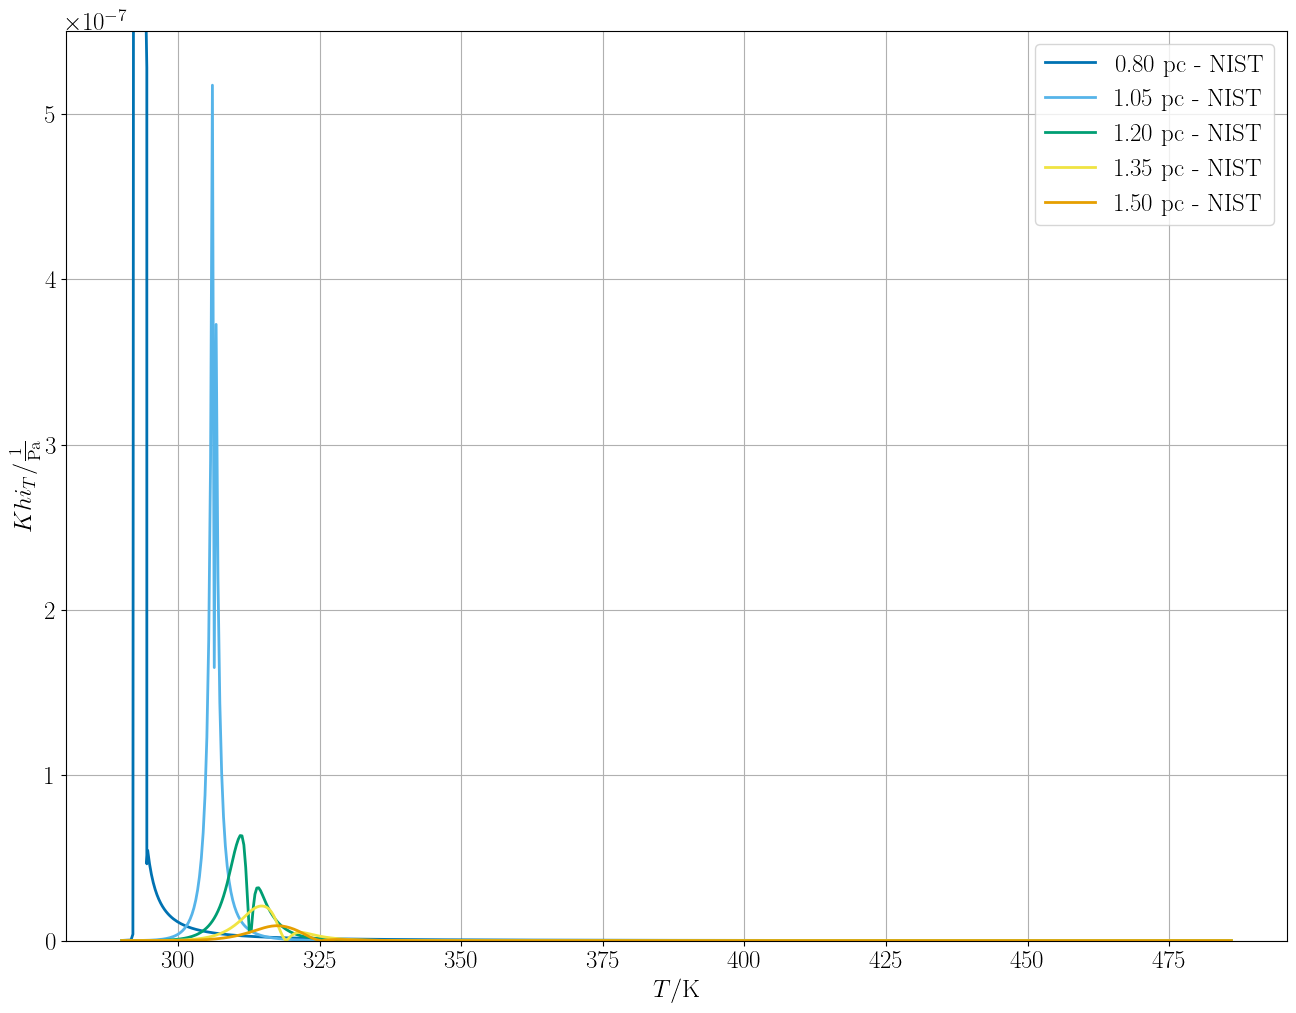

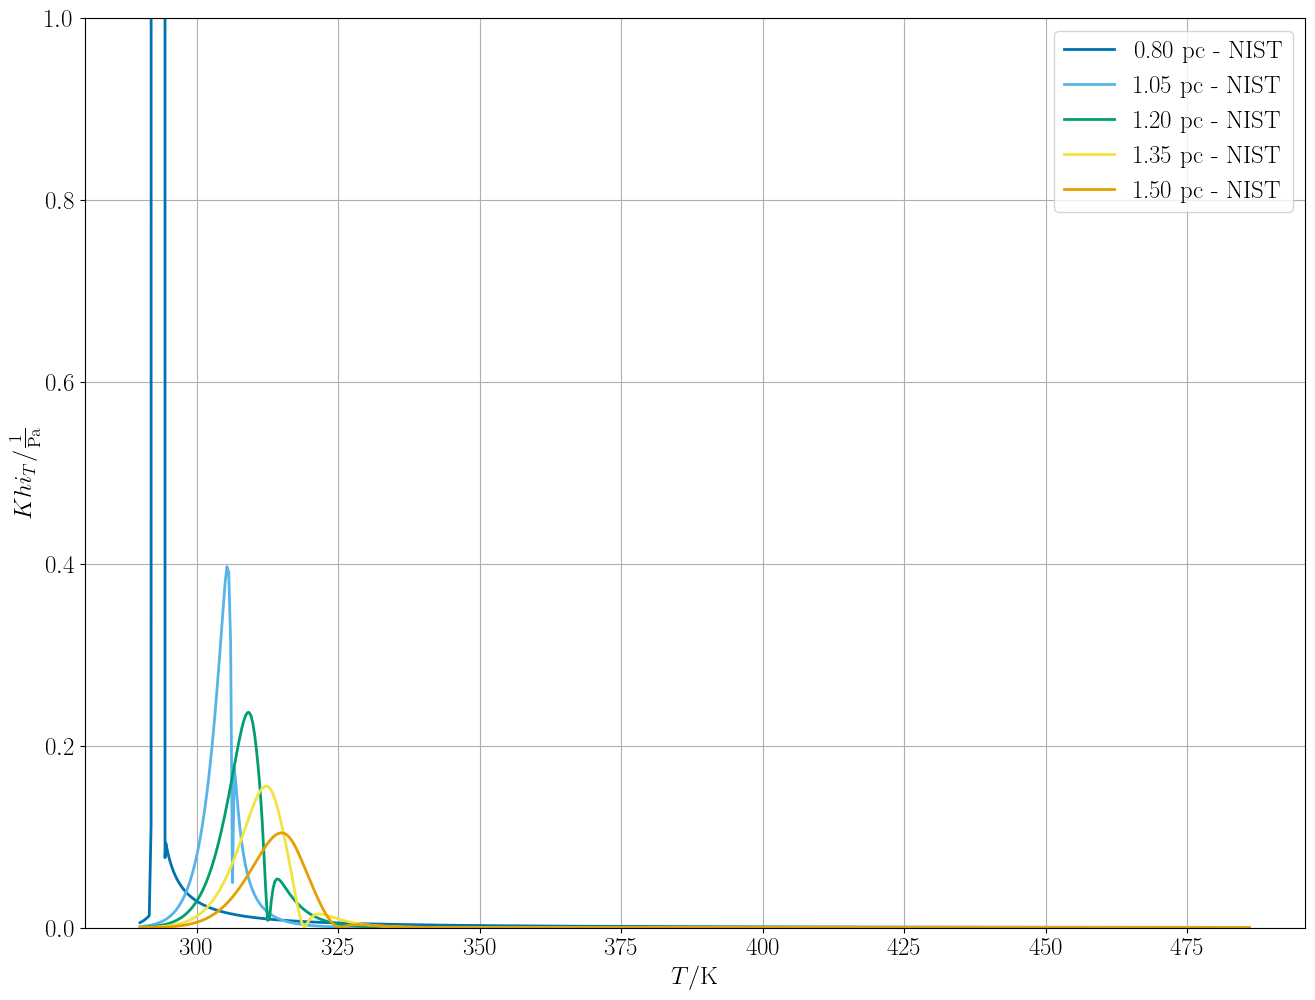

In [108]:
plt.figure(figsize=(40/2.54,30/2.54))
plt.figure(figsize=(15/2.54,15/2.54))
# plt.rcParams.update({
#     "font.size": 18,          # base font size
#     "axes.titlesize": 18,     # title
#     "axes.labelsize": 18,     # x/y labels
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18,
#     "legend.fontsize": 18,
# })
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],Khi_T_as_sup[i,:-2],lw=2,color=rainbow[i],  linestyle='-', label=f'${p_list[i]/Pc:.2f} p_c$')# - NIST")
#ITT MELLÉ PLOTOLOM A SAJÁT SZÁMÍTÁSOMAT SZAGGTOTT VONALLAL
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],Khi_T_as_result[i,:],'k',lw=2,ls=(0, (5, 10)))#, label=f"{p_list[i]/Pc:.2f} pc - számolt")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ \chi_{T} / \rm{\frac{1}{Pa}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,3.5e-6)
plt.savefig("D:/School/7. Félév/Szakdolgozat/figs/khit_vs_nist.pdf", bbox_inches='tight')  # vector, best for LaTeX
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(Khi_T_as_sup[i,:-2]-Khi_T_as_result[i,:]),lw=2,  linestyle='-',color=rainbow[i], label=f"{p_list[i]/Pc:.2f} pc - NIST")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ Khi_{T} / \rm{\frac{1}{Pa}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,0.55e-6)
plt.show()

plt.figure(figsize=(40/2.54,30/2.54))
for i in range(len(p_list)):
    plt.plot(T_NIST[i,:-2],np.abs(Khi_T_as_sup[i,:-2]-Khi_T_as_result[i,:]) / np.abs(Khi_T_as_sup[i,:-2]),lw=2,color=rainbow[i],  linestyle='-', label=f"{p_list[i]/Pc:.2f} pc - NIST")
axes = plt.gca()
plt.grid()
plt.ylabel(r'$ Khi_{T} / \rm{\frac{1}{Pa}} $')
plt.xlabel(r'$ T / \rm{K} $')
plt.legend(loc='upper right')
plt.ylim(0,1)
plt.show()








# Chapter 7 - Span Wagner sűrűség

In [109]:
def pressure_from_density(Rho0, T0):

    Delta = Rho0 / Rhoc
    Tau = Tc / T0

    Fi0_sum = 0
    for i in range (3, 8):
        Fi0_sum += a0i[i] * np.log(1 - np.exp(-Tau*Theta0i[i]))
    Fi0 = np.log(Delta) + a0i[0] + a0i[1] * Tau + a0i[2] * np.log(Tau) + Fi0_sum

    #span wagner eqation 6.3

    #span-wagner table 31

    #i=0
    #Fir_term1 = 0
    #for i in range(0, 7):
     #   Fir_term1 += ni[i] * Delta**di[i]*Tau**ti[i]

    #i=0
    #Fir_term2 = 0
    #for i in range(7, 34):
    #    Fir_term2 += ni[i] * Delta**di[i]*Tau**ti[i]*np.exp(-Delta**ci[i])

    #i=0
    #Fir_term3 = 0
    #for i in range(34, 39):
    #    Fir_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)

    i=0
    Theta = [0] * 42
    for i in range(39,42):
        Theta[i] = (1-Tau) + Ai[i]*((Delta-1)**2)**(1/(2*Betai[i]))

    i=0
    Lapl = [0] * 42
    for i in range(39,42):
        Lapl[i] = Theta[i]**2 + Bi[i]*((Delta-1)**2)**ai[i]

    i=0
    Psi = [0] * 42
    for i in range(39, 42):
        Psi[i] = np.exp(-Ci[i]*(Delta-1)**2-Di[i]*(Tau-1)**2)

    #i=0
    #Fir_term4 = 0
    #for i in range(39, 42):
    #    Fir_term4 += ni[i]*Lapl[i]**bi[i]*Delta*Psi[i]

    #Fir = Fir_term1 + Fir_term2 + Fir_term3 + Fir_term4

    #Fi = Fi0 + Fir

    #span wagener equation 6.5

    #innentől jön a deriváltak meghatározása-------------------------------------------------------

    i=0
    dFirdDelta_term1 = 0
    for i in range(0, 7):
        dFirdDelta_term1 += ni[i] *di[i]* Delta**(di[i]-1)*Tau**ti[i]

    i=0
    dFirdDelta_term2 = 0
    for i in range(7, 34):
        dFirdDelta_term2 += ni[i] * np.exp(-Delta**ci[i])*(Delta**(di[i]-1)*Tau**ti[i]*(di[i]-ci[i]*Delta**ci[i]))

    i=0
    dFirdDelta_term3 = 0
    for i in range(34, 39):
        dFirdDelta_term3 += ni[i]*Delta**di[i]*Tau**ti[i]*np.exp(-Alphai[i]*(Delta-Epsiloni[i])**2-Betai[i]*(Tau-Gammai[i])**2)*(di[i]/Delta-2*Alphai[i]*(Delta-Epsiloni[i]))

    i=0
    dPsidTau = [0]*42
    for i in range(39,42):
        dPsidTau[i] = -2*Di[i]*(Tau-1)*Psi[i]

    i=0
    d2PsidDeltadTau = [0]*42
    for i in range(39,42):
        d2PsidDeltadTau[i] = 4*Ci[i] *Di[i]*(Delta-1)*(Tau-1)*Psi[i]

    i = 0
    dPsidDelta = [0]*42
    for i in range(39,42):
        dPsidDelta[i] = -2*Ci[i]*(Delta-1)*Psi[i]

    i=0
    dLapldDelta = [0]*42
    for i in range(39,42):
        dLapldDelta[i] = (Delta-1)*(Ai[i]*Theta[i]*2/Betai[i]*((Delta-1)**2)**(1/(2*Betai[i])-1)+2*Betai[i]*ai[i]*((Delta-1)**2)**(ai[i]-1))

    i=0
    dLapl_bi_dDelta = [0]*42
    for i in range(39,42):
        dLapl_bi_dDelta[i] = bi[i]*Lapl[i]**(bi[i]-1)*dLapldDelta[i]

    i=0
    dFirdDelta_term4 = 0
    for i in range(39,42):
        dFirdDelta_term4 +=ni[i]*(Lapl[i]**bi[i]*(Psi[i] + Delta*dPsidDelta[i])+dLapl_bi_dDelta[i]*Delta*Psi[i])

    dFirdDelta = dFirdDelta_term1 + dFirdDelta_term2 + dFirdDelta_term3 + dFirdDelta_term4

    p_guess = Rho0*R*T0*(1+Delta*dFirdDelta)
    
    return p_guess #- p0



In [110]:
T0     = [290,295,300,305,310]
rho   = np.linspace(10,800,1000)
p    = np.zeros([len(T0),len(rho)])
p_MPa = np.zeros([len(T0),len(rho)])

p_const = np.zeros(len(rho))
pr_1 = np.zeros(len(rho))


for k in range(0,len(T0)):
    for j in range(0,len(rho)):
        p[k,j] = pressure_from_density(rho[j], T0[k])
        p_MPa[k,j] = p[k,j] / 1e6
        p_const[j] = 7.3
        pr_1 [j] = 1

os.chdir('D:/School/7. Félév/Szakdolgozat/NIST')

T_list = [290,295,300,305,310 ]

# First read one file to know how many T points we have
with open(f"NIST_CO_2_p_density_0.txt", 'r') as f:
    csvReader = list(csv.reader(f, delimiter='\t'))
nT = len(csvReader) - 1

# Preallocate arrays with shape [nPressures, nT]
T_NIST     = np.zeros((len(T_list), nT))
p_NIST     = np.zeros((len(T_list), nT))
rho_sup    = np.zeros((len(T_list), nT))
v_sup      = np.zeros((len(T_list), nT))
e_sup      = np.zeros((len(T_list), nT))
h_sup      = np.zeros((len(T_list), nT))
s_sup      = np.zeros((len(T_list), nT))
c_v_sup    = np.zeros((len(T_list), nT))
c_p_sup    = np.zeros((len(T_list), nT))
a_s_sup    = np.zeros((len(T_list), nT))
mu_JT_sup  = np.zeros((len(T_list), nT))
eta_sup    = np.zeros((len(T_list), nT))
lam_sup    = np.zeros((len(T_list), nT))

# Loop over pressure cases
for i in range(len(T_list)): #len(p_list)
    filename = f"NIST_CO_2_p_density_{i}.txt"
    with open(filename, 'r') as f:
        csvReader = list(csv.reader(f, delimiter='\t'))
        nT = len(csvReader) - 1

    for j in range(nT):
        row = csvReader[j+1]  # skip header
        T_NIST[i,j]    = float(row[0])
        p_NIST[i,j]    = float(row[1])
        rho_sup[i,j]   = float(row[2])
        v_sup[i,j]     = float(row[3])
        e_sup[i,j]     = float(row[4])
        h_sup[i,j]     = float(row[5])
        s_sup[i,j]     = float(row[6])
        c_v_sup[i,j]   = 1e3*float(row[7])
        c_p_sup[i,j]   = 1e3*float(row[8])
        a_s_sup[i,j]   = float(row[9])
        mu_JT_sup[i,j] = float(row[10])/1e6
        eta_sup[i,j]   = float(row[11])
        lam_sup[i,j]   = float(row[12])


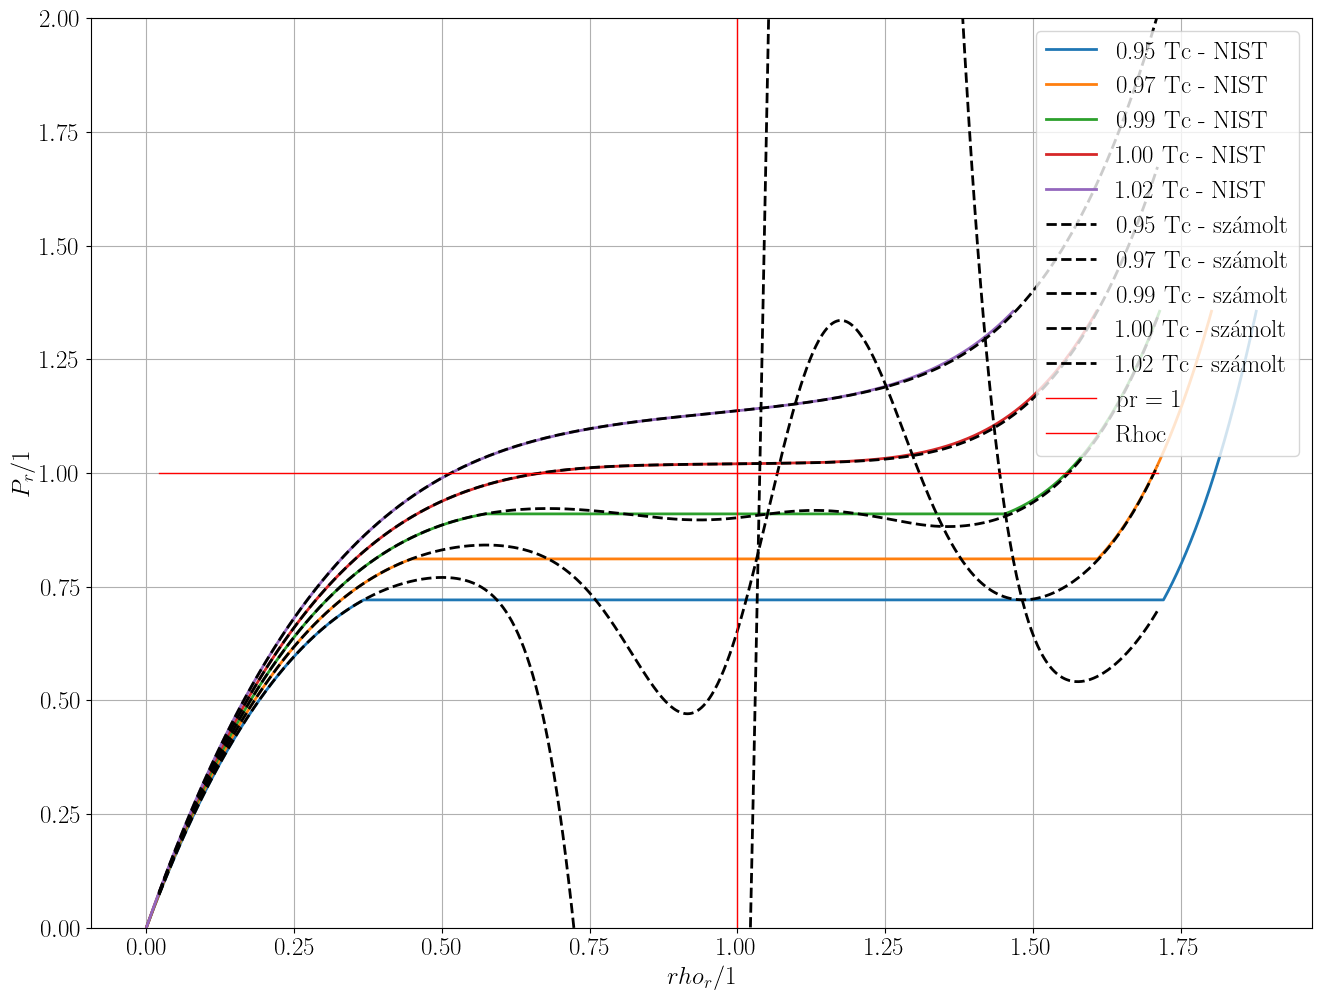

In [111]:
plt.figure(figsize=(40/2.54,30/2.54))

for i in range(len(T_list)):
    plt.plot(rho_sup[i,:] / Rhoc, p_NIST[i,:] /(Pc/1e6),lw=2,  linestyle='-', label=f"{T_list[i]/Tc:.2f} Tc - NIST")


#ITT MELLÉ PLOTOLOM A SAJÁT SZÁMÍTÁSOMAT SZAGGTOTT VONALLAL
for i in range(len(T0)):
    plt.plot(rho / Rhoc ,p_MPa[i,:] / (Pc / 1e6),'k',lw=2,ls='--', label=f"{T0[i]/Tc:.2f} Tc - számolt")


plt.plot(rho / Rhoc, pr_1,'r',lw=1,ls='-', label=f"pr = 1")
plt.axvline(x=1, color='r', linestyle='-', linewidth=1, label='Rhoc')

axes = plt.gca()
plt.grid()

plt.ylabel(r'$ P_r / \rm{ 1} $')
plt.xlabel(r'$ rho_r / \rm{ 1} $')

plt.legend(loc='upper right')

plt.ylim(0,2)

plt.show()





In [112]:
os.chdir('D:/School/7. Félév/Szakdolgozat/NIST')

T_crit_isotherm = [Tc ]

# First read one file to know how many T points we have
with open(f"NIST_CO_2_p_density_5.txt", 'r') as f:
    csvReader = list(csv.reader(f, delimiter='\t'))
nT = len(csvReader) - 1

# Preallocate arrays with shape [nPressures, nT]
T_crit_NIST     = np.zeros((len(T_list), nT))
p_crit_NIST     = np.zeros((len(T_list), nT))
rho_crit_sup    = np.zeros((len(T_list), nT))


# Loop over pressure cases
for i in range(len(T_list)): #len(p_list)
    filename = f"NIST_CO_2_p_density_5.txt"
    with open(filename, 'r') as f:
        csvReader = list(csv.reader(f, delimiter='\t'))
        nT = len(csvReader) - 1

    for j in range(nT):
        row = csvReader[j+1]  # skip header
        T_crit_NIST[i,j]    = float(row[0])
        p_crit_NIST[i,j]    = float(row[1])
        rho_crit_sup[i,j]   = float(row[2])


T0_crit     = [Tc]
rho_crit   = np.linspace(10,800,1000)
p_crit    = np.zeros([len(T0_crit),len(rho_crit)])
p_MPa_crit = np.zeros([len(T0_crit),len(rho_crit)])


for k in range(0,len(T0_crit)):
    for j in range(0,len(rho)):
        p_crit[k,j] = pressure_from_density(rho_crit[j], T0_crit[k])
        p_MPa_crit[k,j] = p_crit[k,j] / 1e6




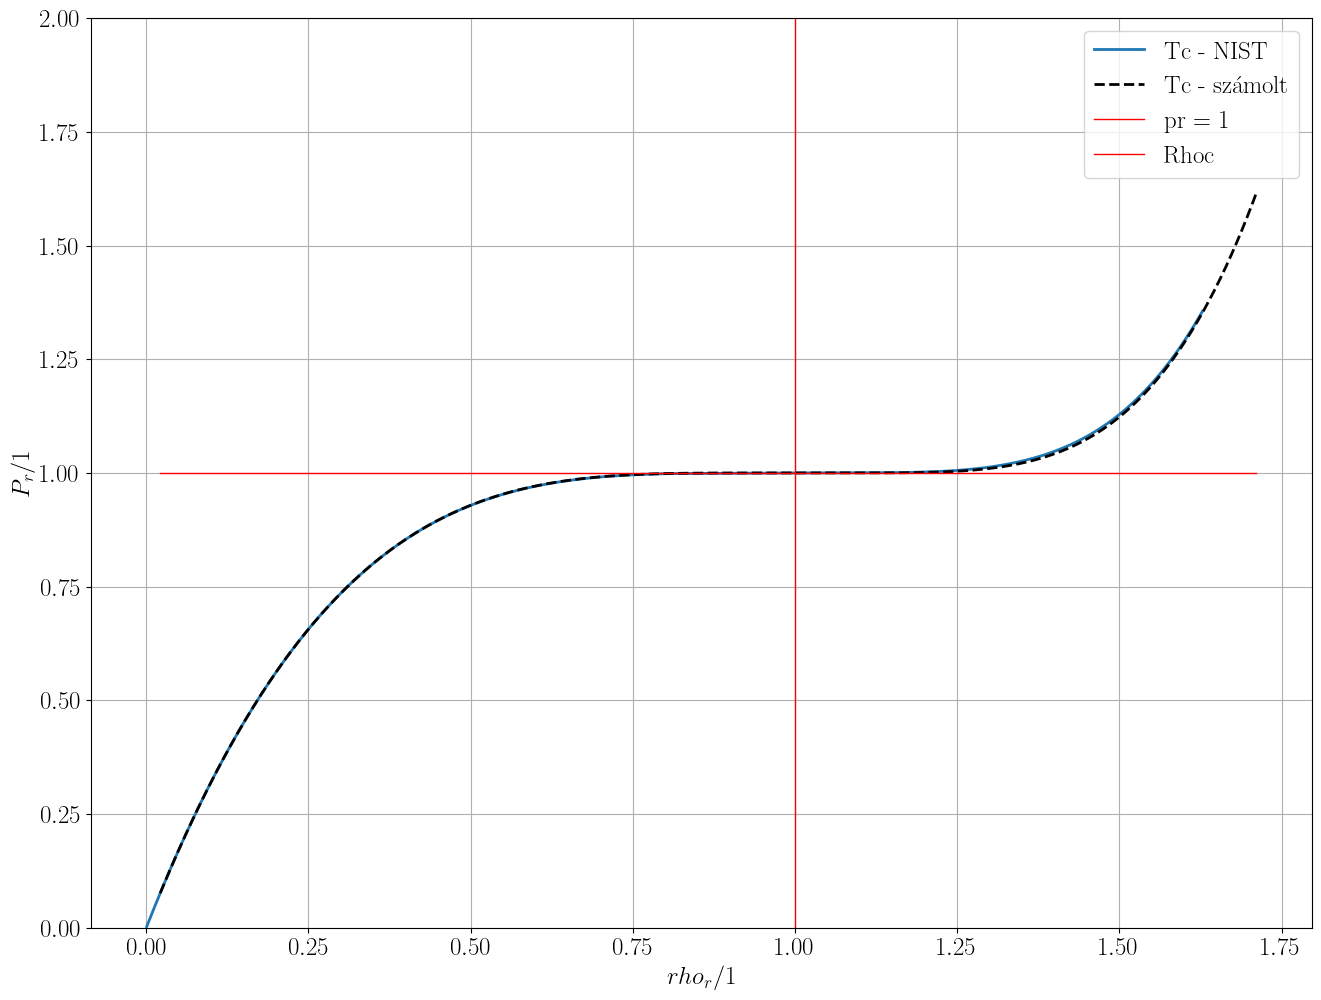

In [113]:
plt.figure(figsize=(40/2.54,30/2.54))

#for i in range(len(T_list)):
#    plt.plot(rho_sup[i,:] / Rhoc, p_NIST[i,:] /(Pc/1e6),lw=2,  linestyle='-', label=f"{T_list[i]/Tc:.2f} Tc - NIST")


#ITT MELLÉ PLOTOLOM A SAJÁT SZÁMÍTÁSOMAT SZAGGTOTT VONALLAL
#for i in range(len(T0)):
#    plt.plot(rho / Rhoc ,p_MPa[i,:] / (Pc / 1e6),'k',lw=2,ls='--', label=f"{T0[i]/Tc:.2f} Tc - számolt")


plt.plot(rho_crit_sup[0,:] / Rhoc, p_crit_NIST[0,:] / (Pc/1e6), lw=2,  linestyle='-', label=f"Tc - NIST" )
plt.plot(rho_crit / Rhoc, p_MPa_crit[0,:] / (Pc/1e6),'k', lw=2,  linestyle='--', label=f"Tc - számolt" )

plt.plot(rho / Rhoc, pr_1,'r',lw=1,ls='-', label=f"pr = 1")
plt.axvline(x=1, color='r', linestyle='-', linewidth=1, label='Rhoc')

axes = plt.gca()
plt.grid()

plt.ylabel(r'$ P_r / \rm{ 1} $')
plt.xlabel(r'$ rho_r / \rm{ 1} $')

plt.legend(loc='upper right')

plt.ylim(0,2)

plt.show()



